<a href="https://colab.research.google.com/github/mardocheeogecime-gif/Rede_Colabora-o_Acad-mica_ECI_UFMG/blob/main/Journal_of_Complex_Networks_Article.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# Parte_0A_Data_Source_Discovery_and_Provenance_Audit.py
#
# Journal of Complex Networks — clean-room laboratory
# Part 0A: Data Source Discovery and Provenance Audit
#
# PURPOSE
#   - Discover the current, actually accessible source files in Google Drive.
#   - Do not assume historical run paths.
#   - Do not build the network yet.
#   - Audit candidate copies of:
#       * producoes_final*.xlsx
#       * autores_final*.xlsx
#       * banco-sucupira_docente-PPGCI*.xlsx
#   - Record path, size, modification time, SHA256, workbook sheets,
#     row/column counts, and schema hints.
#   - Save all outputs to a NEW clean JCN run root.
#   - Print the critical audit tables in Colab.
#
# OUTPUT ROOT
#   /content/drive/MyDrive/tese_doutoral/runs/jcn_pareto_sparsification_20261002/
#
# IMPORTANT
#   This script does NOT choose the analytical dataset and does NOT reconstruct the graph.
#   Selection/freezing happens in Part 0B after this audit is inspected.

from pathlib import Path
import os
import json
import hashlib
import platform
import sys
from datetime import datetime, timezone

import pandas as pd
import numpy as np

# ======================================================================================
# 1. MOUNT GOOGLE DRIVE
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        print("[drive] Google Drive not mounted. Mounting...")
        drive.mount("/content/drive")
    else:
        print("[drive] Google Drive already mounted.")
except Exception as e:
    print(f"[drive] Colab mount helper unavailable or skipped: {e}")

MYDRIVE = Path("/content/drive/MyDrive")
if not MYDRIVE.exists():
    raise FileNotFoundError(
        "/content/drive/MyDrive is not available. "
        "Mount Google Drive and rerun this script."
    )

# ======================================================================================
# 2. CLEAN NEW RUN ROOT
# ======================================================================================

RUN_ROOT = Path(
    "/content/drive/MyDrive/tese_doutoral/runs/"
    "jcn_pareto_sparsification_20261002"
)

OUTDIR = RUN_ROOT / "00_data_provenance" / "0A_source_discovery"
TABLEDIR = OUTDIR / "tables"
ARTDIR = OUTDIR / "artifacts"
LOGDIR = OUTDIR / "logs"

for p in [RUN_ROOT, OUTDIR, TABLEDIR, ARTDIR, LOGDIR]:
    p.mkdir(parents=True, exist_ok=True)

print(f"[run root] {RUN_ROOT}")
print(f"[output]   {OUTDIR}")

# ======================================================================================
# 3. SEARCH SPECIFICATION
# ======================================================================================

SEARCH_ROOTS = [
    Path("/content/drive/MyDrive/tese_doutoral/input"),
    Path("/content/drive/MyDrive/tese_doutoral"),
]

TARGETS = {
    "publications": [
        "producoes_final*.xlsx",
    ],
    "authors_resolved": [
        "autores_final*.xlsx",
    ],
    "roster_sucupira": [
        "banco-sucupira_docente-PPGCI*.xlsx",
    ],
}

# Avoid recursively auditing our newly created JCN run outputs.
EXCLUDE_SUBSTRINGS = [
    "/jcn_pareto_sparsification_20261002/",
]

# ======================================================================================
# 4. UTILITIES
# ======================================================================================

def sha256_file(path, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

def safe_stat(path):
    st = path.stat()
    return {
        "size_bytes": int(st.st_size),
        "size_mb": float(st.st_size / (1024 ** 2)),
        "modified_timestamp": datetime.fromtimestamp(
            st.st_mtime, tz=timezone.utc
        ).isoformat(),
    }

def normalize_colname(c):
    return str(c).strip().lower()

def schema_hints(columns):
    cols = [normalize_colname(c) for c in columns]

    def contains_any(tokens):
        return [c for c in cols if any(t in c for t in tokens)]

    return {
        "identity_hits": " | ".join(
            contains_any(["autor_id", "author", "id_openalex", "openalex"])
        ),
        "publication_id_hits": " | ".join(
            contains_any(["work", "obra", "public", "id_openalex"])
        ),
        "time_hits": " | ".join(
            contains_any(["ano", "year", "data", "date"])
        ),
        "institution_hits": " | ".join(
            contains_any(["instit", "ies", "programa", "ppg"])
        ),
    }

def workbook_audit(path):
    """
    Inspect workbook conservatively.
    Reads workbook metadata and each sheet's first rows for schema,
    then full row/column counts when feasible via pandas.
    """
    try:
        xls = pd.ExcelFile(path)
        sheets = xls.sheet_names
    except Exception as e:
        return {
            "status": "excel_open_error",
            "error": repr(e),
            "n_sheets": np.nan,
            "sheet_names": "",
            "primary_sheet": "",
            "n_rows_primary": np.nan,
            "n_columns_primary": np.nan,
            "columns_primary": "",
            "identity_hits": "",
            "publication_id_hits": "",
            "time_hits": "",
            "institution_hits": "",
        }

    sheet_rows = []
    primary_info = None

    for i, sheet in enumerate(sheets):
        try:
            df = pd.read_excel(path, sheet_name=sheet)
            info = {
                "sheet_name": sheet,
                "n_rows": int(df.shape[0]),
                "n_columns": int(df.shape[1]),
                "columns": [str(c) for c in df.columns],
            }
            sheet_rows.append(info)
            if i == 0:
                primary_info = (df, info)
        except Exception as e:
            sheet_rows.append({
                "sheet_name": sheet,
                "n_rows": np.nan,
                "n_columns": np.nan,
                "columns": [],
                "error": repr(e),
            })

    if primary_info is None:
        return {
            "status": "excel_sheet_read_error",
            "error": "No readable sheet",
            "n_sheets": len(sheets),
            "sheet_names": " | ".join(sheets),
            "primary_sheet": sheets[0] if sheets else "",
            "n_rows_primary": np.nan,
            "n_columns_primary": np.nan,
            "columns_primary": "",
            "identity_hits": "",
            "publication_id_hits": "",
            "time_hits": "",
            "institution_hits": "",
            "sheet_audit": sheet_rows,
        }

    df0, info0 = primary_info
    hints = schema_hints(df0.columns)

    return {
        "status": "OK",
        "error": "",
        "n_sheets": len(sheets),
        "sheet_names": " | ".join(sheets),
        "primary_sheet": info0["sheet_name"],
        "n_rows_primary": info0["n_rows"],
        "n_columns_primary": info0["n_columns"],
        "columns_primary": " | ".join(info0["columns"]),
        **hints,
        "sheet_audit": sheet_rows,
    }

# ======================================================================================
# 5. DISCOVER FILES
# ======================================================================================

discovered = []
seen = set()

for category, patterns in TARGETS.items():
    for root in SEARCH_ROOTS:
        if not root.exists():
            continue

        for pattern in patterns:
            for path in root.rglob(pattern):
                s = str(path)

                if any(x in s for x in EXCLUDE_SUBSTRINGS):
                    continue

                # Deduplicate exact path.
                key = str(path.resolve()) if path.exists() else str(path)
                if key in seen:
                    continue
                seen.add(key)

                discovered.append({
                    "category": category,
                    "path": path,
                })

print(f"[discovery] candidate files found: {len(discovered)}")

if not discovered:
    raise FileNotFoundError(
        "No candidate source files were found for the three required source families. "
        "Check whether the files are currently present under "
        "/content/drive/MyDrive/tese_doutoral/."
    )

# ======================================================================================
# 6. AUDIT EACH CANDIDATE
# ======================================================================================

audit_rows = []
sheet_manifest = []

for i, item in enumerate(discovered, start=1):
    category = item["category"]
    path = item["path"]

    print(
        f"[audit {i:02d}/{len(discovered):02d}] "
        f"{category}: {path}"
    )

    row = {
        "category": category,
        "name": path.name,
        "path": str(path),
        "parent": str(path.parent),
        "exists": path.exists(),
    }

    try:
        row.update(safe_stat(path))
    except Exception as e:
        row.update({
            "size_bytes": np.nan,
            "size_mb": np.nan,
            "modified_timestamp": "",
        })
        row["stat_error"] = repr(e)

    try:
        row["sha256"] = sha256_file(path)
    except Exception as e:
        row["sha256"] = ""
        row["hash_error"] = repr(e)

    wb = workbook_audit(path)
    sheet_audit = wb.pop("sheet_audit", [])
    row.update(wb)

    audit_rows.append(row)

    for srow in sheet_audit:
        sheet_manifest.append({
            "category": category,
            "file_name": path.name,
            "file_path": str(path),
            **srow,
        })

audit = pd.DataFrame(audit_rows)
sheet_df = pd.DataFrame(sheet_manifest)

# ======================================================================================
# 7. EXACT-DUPLICATE GROUPS BY SHA256
# ======================================================================================

if "sha256" in audit.columns:
    counts = (
        audit[audit["sha256"].astype(str) != ""]
        .groupby(["category", "sha256"])
        .size()
        .reset_index(name="n_identical_copies")
    )
    audit = audit.merge(
        counts,
        on=["category", "sha256"],
        how="left",
    )
else:
    audit["n_identical_copies"] = np.nan

# ======================================================================================
# 8. DATASET-FAMILY SUMMARY
# ======================================================================================

summary_rows = []

for category, g in audit.groupby("category"):
    valid = g[g["status"] == "OK"].copy()

    summary_rows.append({
        "category": category,
        "n_candidates": int(len(g)),
        "n_readable": int(len(valid)),
        "n_unique_sha256": int(
            valid["sha256"].replace("", np.nan).nunique(dropna=True)
        ),
        "rows_min": (
            float(valid["n_rows_primary"].min())
            if len(valid)
            else np.nan
        ),
        "rows_max": (
            float(valid["n_rows_primary"].max())
            if len(valid)
            else np.nan
        ),
        "columns_min": (
            float(valid["n_columns_primary"].min())
            if len(valid)
            else np.nan
        ),
        "columns_max": (
            float(valid["n_columns_primary"].max())
            if len(valid)
            else np.nan
        ),
        "all_readable_copies_identical": bool(
            valid["sha256"].nunique() == 1
        ) if len(valid) else False,
    })

summary = pd.DataFrame(summary_rows)

# ======================================================================================
# 9. CANDIDATE PRIORITY TABLE
# ======================================================================================

# Priority here is ONLY a discovery aid.
# Part 0A does NOT freeze/select files.
priority = audit.copy()

def path_priority(path):
    p = str(path)

    # Prefer canonical input folder, then later run folders,
    # but do not select automatically.
    if "/tese_doutoral/input/" in p:
        return 0
    if "/runs/run_20260625_200032/input/" in p:
        return 1
    if "/runs/" in p and "/input/" in p:
        return 2
    return 3

priority["path_priority"] = priority["path"].map(path_priority)

priority = priority.sort_values(
    [
        "category",
        "status",
        "path_priority",
        "modified_timestamp",
        "name",
    ],
    ascending=[True, True, True, False, True],
)

# ======================================================================================
# 10. SAVE OUTPUTS
# ======================================================================================

audit_path = TABLEDIR / "Table_00A_01_source_file_audit.csv"
sheet_path = TABLEDIR / "Table_00A_02_workbook_sheet_manifest.csv"
summary_path = TABLEDIR / "Table_00A_03_source_family_summary.csv"
priority_path = TABLEDIR / "Table_00A_04_candidate_priority_review.csv"

audit.to_csv(audit_path, index=False)
sheet_df.to_csv(sheet_path, index=False)
summary.to_csv(summary_path, index=False)
priority.to_csv(priority_path, index=False)

environment = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "python_version": sys.version,
    "platform": platform.platform(),
    "pandas_version": pd.__version__,
    "numpy_version": np.__version__,
    "run_root": str(RUN_ROOT),
    "search_roots": [str(p) for p in SEARCH_ROOTS],
    "target_patterns": TARGETS,
    "selection_performed": False,
    "note": (
        "Part 0A performs discovery and provenance audit only. "
        "Canonical source selection is deferred to Part 0B."
    ),
}

env_path = ARTDIR / "environment_and_discovery_config.json"
env_path.write_text(
    json.dumps(environment, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

# Human-readable provenance log.
log_path = LOGDIR / "Part_0A_provenance_audit.txt"
with open(log_path, "w", encoding="utf-8") as f:
    f.write("JCN Part 0A — Data Source Discovery and Provenance Audit\n")
    f.write("=" * 100 + "\n\n")
    f.write(f"Created: {environment['created_at_utc']}\n")
    f.write(f"Run root: {RUN_ROOT}\n\n")
    f.write("No source file was selected or frozen in this stage.\n\n")
    f.write("SOURCE FAMILY SUMMARY\n")
    f.write(summary.to_string(index=False))
    f.write("\n\nCANDIDATE PRIORITY REVIEW\n")
    cols = [
        "category",
        "name",
        "size_mb",
        "modified_timestamp",
        "sha256",
        "n_rows_primary",
        "n_columns_primary",
        "status",
        "path",
    ]
    cols = [c for c in cols if c in priority.columns]
    f.write(priority[cols].to_string(index=False))
    f.write("\n")

# ======================================================================================
# 11. PRINT CRITICAL BLOCKS IN COLAB
# ======================================================================================

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 260)
pd.set_option("display.max_colwidth", 140)

print("\n" + "=" * 120)
print("TABLE 00A.1 — SOURCE FAMILY SUMMARY")
print("=" * 120)
print(summary.to_string(index=False))

print("\n" + "=" * 120)
print("TABLE 00A.2 — CANDIDATE SOURCE FILES")
print("=" * 120)

print_cols = [
    "category",
    "name",
    "size_mb",
    "modified_timestamp",
    "sha256",
    "n_identical_copies",
    "n_rows_primary",
    "n_columns_primary",
    "status",
    "path",
]

print_cols = [c for c in print_cols if c in priority.columns]
print(priority[print_cols].to_string(index=False))

print("\n" + "=" * 120)
print("TABLE 00A.3 — SCHEMA HINTS")
print("=" * 120)

schema_cols = [
    "category",
    "name",
    "identity_hits",
    "publication_id_hits",
    "time_hits",
    "institution_hits",
    "columns_primary",
]

schema_cols = [c for c in schema_cols if c in priority.columns]
print(priority[schema_cols].to_string(index=False))

print("\n" + "=" * 120)
print("FILES SAVED")
print("=" * 120)
print(f"[table] {audit_path}")
print(f"[table] {sheet_path}")
print(f"[table] {summary_path}")
print(f"[table] {priority_path}")
print(f"[artifact] {env_path}")
print(f"[log] {log_path}")

print("\n" + "=" * 120)
print("DECISION")
print("=" * 120)

all_three_present = (
    set(TARGETS.keys())
    .issubset(set(audit.loc[audit["status"] == "OK", "category"]))
)

if all_three_present:
    print("STATUS: PROCEED_TO_0B_REVIEW")
    print(
        "All three required source families have at least one readable candidate. "
        "Do NOT build the graph yet. Review the printed candidate table first."
    )
else:
    missing = sorted(
        set(TARGETS.keys())
        - set(audit.loc[audit["status"] == "OK", "category"])
    )
    print("STATUS: SOURCE_GAP")
    print("Missing readable source families:", missing)

print("\n" + "=" * 120)
print("SEND THESE BLOCKS BACK")
print("=" * 120)
print("1) TABLE 00A.1 — SOURCE FAMILY SUMMARY")
print("2) TABLE 00A.2 — CANDIDATE SOURCE FILES")
print("3) TABLE 00A.3 — SCHEMA HINTS")
print("4) DECISION block")


[drive] Google Drive not mounted. Mounting...
Mounted at /content/drive
[run root] /content/drive/MyDrive/tese_doutoral/runs/jcn_pareto_sparsification_20261002
[output]   /content/drive/MyDrive/tese_doutoral/runs/jcn_pareto_sparsification_20261002/00_data_provenance/0A_source_discovery
[discovery] candidate files found: 51
[audit 01/51] publications: /content/drive/MyDrive/tese_doutoral/input/producoes_final.xlsx
[audit 02/51] publications: /content/drive/MyDrive/tese_doutoral/runs/run_20260625_200032/input/producoes_final.xlsx
[audit 03/51] publications: /content/drive/MyDrive/tese_doutoral/runs/run_20260622_200101/input/producoes_final.xlsx
[audit 04/51] publications: /content/drive/MyDrive/tese_doutoral/runs/run_20260622_165452/input/producoes_final.xlsx
[audit 05/51] publications: /content/drive/MyDrive/tese_doutoral/runs/run_20260622_084332/input/producoes_final.xlsx
[audit 06/51] publications: /content/drive/MyDrive/tese_doutoral/runs/run_20260618_215516/input/producoes_final.xls

In [ ]:

# Parte_0B_Canonical_Source_Freezing_and_Network_Reconstruction.py
#
# Journal of Complex Networks — clean-room laboratory
# Part 0B: Canonical Source Freezing and Network Reconstruction
#
# INPUT:
#   Outputs from Part 0A in:
#   .../jcn_pareto_sparsification_20261002/00_data_provenance/0A_source_discovery/
#
# PURPOSE:
#   1) deterministically select one current source file for each source family;
#   2) freeze byte-identical copies inside the clean JCN run;
#   3) audit identifiers and publication linkage;
#   4) reconstruct the weighted undirected co-authorship graph from tabular sources;
#   5) derive the giant connected component (GCC);
#   6) compare the reconstructed analytical graph with historical reference values
#      WITHOUT forcing those values;
#   7) save canonical tables/graphs to Drive and print all critical diagnostics in Colab.
#
# SCIENTIFIC CONSTRUCTION RULE:
#   - target researchers come from autores_final;
#   - publication-author rows come from producoes_final;
#   - a work contributes to the co-authorship network only if at least two DISTINCT
#     target researchers are associated with that work;
#   - each unordered researcher pair receives +1 weight per shared work;
#   - self-loops are impossible by construction;
#   - no backbone extraction is applied;
#   - the empirical analytical network is the GCC of this reconstructed full graph.
#
# IMPORTANT:
#   Historical values are AUDIT REFERENCES only, never hard-coded acceptance criteria.

from pathlib import Path
import json
import hashlib
import shutil
import pickle
import sys
import platform
from datetime import datetime, timezone
from itertools import combinations

import numpy as np
import pandas as pd
import networkx as nx

# ======================================================================================
# 1. PATHS / MOUNT
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        print("[drive] Google Drive not mounted. Mounting...")
        drive.mount("/content/drive")
    else:
        print("[drive] Google Drive already mounted.")
except Exception as e:
    print(f"[drive] Colab mount helper unavailable/skipped: {e}")

RUN_ROOT = Path(
    "/content/drive/MyDrive/tese_doutoral/runs/"
    "jcn_pareto_sparsification_20261002"
)

PART0A = RUN_ROOT / "00_data_provenance" / "0A_source_discovery"
AUDIT_CSV = PART0A / "tables" / "Table_00A_01_source_file_audit.csv"
PRIORITY_CSV = PART0A / "tables" / "Table_00A_04_candidate_priority_review.csv"

OUTDIR = RUN_ROOT / "00_data_provenance" / "0B_canonical_reconstruction"
FROZENDIR = OUTDIR / "input_frozen"
TABLEDIR = OUTDIR / "tables"
GRAPHDIR = OUTDIR / "graphs"
ARTDIR = OUTDIR / "artifacts"
LOGDIR = OUTDIR / "logs"

for p in [OUTDIR, FROZENDIR, TABLEDIR, GRAPHDIR, ARTDIR, LOGDIR]:
    p.mkdir(parents=True, exist_ok=True)

if not AUDIT_CSV.exists() or not PRIORITY_CSV.exists():
    raise FileNotFoundError(
        "Part 0A outputs are missing. Run Part 0A successfully before Part 0B.\n"
        f"Expected:\n{AUDIT_CSV}\n{PRIORITY_CSV}"
    )

# ======================================================================================
# 2. UTILITIES
# ======================================================================================

def sha256_file(path, chunk_size=1024*1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk_size)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

def clean_id(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    if not s or s.lower() in {"nan", "none", "null"}:
        return None
    # Normalize OpenAlex URLs to terminal ID while preserving non-OpenAlex IDs.
    if "openalex.org/" in s.lower():
        s = s.rstrip("/").split("/")[-1]
    return s.upper()

def pick_col(df, exact=(), contains=()):
    cols = list(df.columns)
    low = {str(c).strip().lower(): c for c in cols}
    for name in exact:
        if name.lower() in low:
            return low[name.lower()]
    for token in contains:
        hits = [c for c in cols if token.lower() in str(c).lower()]
        if len(hits) == 1:
            return hits[0]
    return None

def jaccard(a,b):
    a=set(a); b=set(b)
    return len(a&b)/len(a|b) if (a|b) else np.nan

# ======================================================================================
# 3. LOAD PART 0A AUDIT AND SELECT/FREEZE CANONICAL SOURCES
# ======================================================================================

audit = pd.read_csv(AUDIT_CSV)
priority = pd.read_csv(PRIORITY_CSV)

required = ["publications", "authors_resolved", "roster_sucupira"]
selection_rows = []

for category in required:
    g = priority[(priority["category"] == category) & (priority["status"] == "OK")].copy()
    if len(g) == 0:
        raise RuntimeError(f"No readable Part 0A candidate for category={category}")

    # Reconstruct path priority if absent.
    if "path_priority" not in g.columns:
        def pp(s):
            s=str(s)
            if "/tese_doutoral/input/" in s: return 0
            if "/runs/run_20260625_200032/input/" in s: return 1
            if "/runs/" in s and "/input/" in s: return 2
            return 3
        g["path_priority"] = g["path"].map(pp)

    # Deterministic selection:
    #   1. lowest path priority;
    #   2. newest modification timestamp;
    #   3. lexicographically smallest path.
    g["modified_dt"] = pd.to_datetime(g["modified_timestamp"], errors="coerce", utc=True)
    g = g.sort_values(
        ["path_priority", "modified_dt", "path"],
        ascending=[True, False, True],
        na_position="last"
    )
    chosen = g.iloc[0].copy()
    source = Path(str(chosen["path"]))

    if not source.exists():
        raise FileNotFoundError(
            f"Part 0A selected candidate is no longer accessible: {source}"
        )

    frozen_name = {
        "publications": "producoes_final_CANONICAL.xlsx",
        "authors_resolved": "autores_final_CANONICAL.xlsx",
        "roster_sucupira": "banco_sucupira_docente_PPGCI_CANONICAL.xlsx",
    }[category]

    dest = FROZENDIR / frozen_name
    shutil.copy2(source, dest)

    src_hash = sha256_file(source)
    dst_hash = sha256_file(dest)
    if src_hash != dst_hash:
        raise RuntimeError(f"Hash mismatch after freezing {category}")

    # Audit whether other copies share the selected hash.
    n_same_hash = int((g["sha256"].astype(str) == src_hash).sum())
    n_unique_hash = int(g["sha256"].astype(str).nunique())

    selection_rows.append({
        "category": category,
        "selection_rule": "lowest path_priority; newest modified timestamp; lexical path tie-break",
        "source_path": str(source),
        "frozen_path": str(dest),
        "sha256": src_hash,
        "n_readable_candidates": int(len(g)),
        "n_unique_hashes_among_candidates": n_unique_hash,
        "n_candidates_with_selected_hash": n_same_hash,
        "selected_path_priority": int(chosen["path_priority"]),
        "selected_modified_timestamp": str(chosen["modified_timestamp"]),
    })

selection = pd.DataFrame(selection_rows)
selection.to_csv(TABLEDIR / "Table_00B_01_canonical_source_selection.csv", index=False)

print("\n" + "="*120)
print("TABLE 00B.1 — CANONICAL SOURCE SELECTION")
print("="*120)
print(selection.to_string(index=False))

# ======================================================================================
# 4. LOAD FROZEN SOURCES AND RESOLVE SCHEMA
# ======================================================================================

paths = dict(zip(selection["category"], selection["frozen_path"]))
pub = pd.read_excel(paths["publications"])
authors = pd.read_excel(paths["authors_resolved"])
roster = pd.read_excel(paths["roster_sucupira"])

# Publications: historical schema expected autor_id=author and id_openalex=work.
PUB_AUTHOR = pick_col(
    pub,
    exact=("autor_id","author_id","id_autor"),
    contains=("autor_id",)
)
PUB_WORK = pick_col(
    pub,
    exact=("id_openalex","work_id","id_work","obra_id"),
    contains=("work_id",)
)
PUB_YEAR = pick_col(
    pub,
    exact=("ano","year","publication_year"),
    contains=("ano","year")
)

# Authors table: historical schema expected id_openalex to be AUTHOR IDs.
AUTH_ID = pick_col(
    authors,
    exact=("id_openalex","author_id","autor_id"),
    contains=("author_id","autor_id")
)

if PUB_AUTHOR is None or PUB_WORK is None or AUTH_ID is None:
    raise RuntimeError(
        "Could not resolve critical identifier columns.\n"
        f"Publications columns: {list(pub.columns)}\n"
        f"Authors columns: {list(authors.columns)}\n"
        f"Resolved PUB_AUTHOR={PUB_AUTHOR}, PUB_WORK={PUB_WORK}, AUTH_ID={AUTH_ID}"
    )

schema = pd.DataFrame([
    {"dataset":"publications","role":"author identifier","column":PUB_AUTHOR},
    {"dataset":"publications","role":"work identifier","column":PUB_WORK},
    {"dataset":"publications","role":"publication year","column":PUB_YEAR},
    {"dataset":"authors_resolved","role":"target researcher identifier","column":AUTH_ID},
])
schema.to_csv(TABLEDIR / "Table_00B_02_resolved_schema.csv", index=False)

print("\n" + "="*120)
print("TABLE 00B.2 — RESOLVED SCHEMA")
print("="*120)
print(schema.to_string(index=False))

# ======================================================================================
# 5. IDENTIFIER AUDIT
# ======================================================================================

pub_author_ids = pub[PUB_AUTHOR].map(clean_id)
pub_work_ids = pub[PUB_WORK].map(clean_id)
target_author_ids = authors[AUTH_ID].map(clean_id)

target_set = set(target_author_ids.dropna().unique())
pub_author_set = set(pub_author_ids.dropna().unique())
linked_target_set = target_set & pub_author_set

identifier_audit = pd.DataFrame([
    {
        "dataset":"authors_resolved",
        "rows":len(authors),
        "source_column":AUTH_ID,
        "nonmissing_ids":int(target_author_ids.notna().sum()),
        "unique_ids":int(target_author_ids.dropna().nunique()),
    },
    {
        "dataset":"publications_author_role",
        "rows":len(pub),
        "source_column":PUB_AUTHOR,
        "nonmissing_ids":int(pub_author_ids.notna().sum()),
        "unique_ids":int(pub_author_ids.dropna().nunique()),
    },
    {
        "dataset":"publications_work_role",
        "rows":len(pub),
        "source_column":PUB_WORK,
        "nonmissing_ids":int(pub_work_ids.notna().sum()),
        "unique_ids":int(pub_work_ids.dropna().nunique()),
    },
])

identifier_audit.to_csv(TABLEDIR / "Table_00B_03_identifier_audit.csv", index=False)

linkage = pd.DataFrame([{
    "target_unique_authors": len(target_set),
    "publication_unique_authors": len(pub_author_set),
    "target_authors_found_in_publications": len(linked_target_set),
    "target_author_linkage_pct": 100*len(linked_target_set)/len(target_set) if target_set else np.nan,
    "publication_authors_outside_target": len(pub_author_set-target_set),
}])
linkage.to_csv(TABLEDIR / "Table_00B_04_author_linkage_audit.csv", index=False)

print("\n" + "="*120)
print("TABLE 00B.3 — IDENTIFIER AUDIT")
print("="*120)
print(identifier_audit.to_string(index=False))
print("\nTABLE 00B.4 — AUTHOR LINKAGE AUDIT")
print(linkage.to_string(index=False))

# ======================================================================================
# 6. PUBLICATION FILTERING FLOW
# ======================================================================================

work_author = pd.DataFrame({
    "work_id": pub_work_ids,
    "author_id": pub_author_ids,
})

flow_rows = []

flow_rows.append({
    "stage":"raw publication-author rows",
    "rows":len(work_author),
    "unique_works":work_author["work_id"].nunique(dropna=True),
    "unique_authors":work_author["author_id"].nunique(dropna=True),
})

wa = work_author.dropna(subset=["work_id","author_id"]).copy()
flow_rows.append({
    "stage":"nonmissing work and author identifiers",
    "rows":len(wa),
    "unique_works":wa["work_id"].nunique(),
    "unique_authors":wa["author_id"].nunique(),
})

wa = wa[wa["author_id"].isin(target_set)].copy()
flow_rows.append({
    "stage":"rows restricted to target researcher roster",
    "rows":len(wa),
    "unique_works":wa["work_id"].nunique(),
    "unique_authors":wa["author_id"].nunique(),
})

before_dups = len(wa)
wa = wa.drop_duplicates(["work_id","author_id"]).copy()
flow_rows.append({
    "stage":"unique work-author memberships",
    "rows":len(wa),
    "unique_works":wa["work_id"].nunique(),
    "unique_authors":wa["author_id"].nunique(),
})

work_sizes = wa.groupby("work_id")["author_id"].nunique().sort_values()
eligible_works = set(work_sizes[work_sizes >= 2].index)

wa2 = wa[wa["work_id"].isin(eligible_works)].copy()
flow_rows.append({
    "stage":"works with >=2 distinct target researchers",
    "rows":len(wa2),
    "unique_works":wa2["work_id"].nunique(),
    "unique_authors":wa2["author_id"].nunique(),
})

flow = pd.DataFrame(flow_rows)
flow.to_csv(TABLEDIR / "Table_00B_05_publication_filtering_flow.csv", index=False)

work_size_dist = (
    work_sizes.value_counts()
    .sort_index()
    .rename_axis("n_target_authors_on_work")
    .reset_index(name="n_works")
)
work_size_dist["fraction_of_works"] = work_size_dist["n_works"] / work_size_dist["n_works"].sum()
work_size_dist.to_csv(TABLEDIR / "Table_00B_06_work_size_distribution.csv", index=False)

print("\n" + "="*120)
print("TABLE 00B.5 — PUBLICATION FILTERING FLOW")
print("="*120)
print(flow.to_string(index=False))

# ======================================================================================
# 7. RECONSTRUCT FULL TARGET COAUTHORSHIP GRAPH
# ======================================================================================

G_full = nx.Graph()
G_full.add_nodes_from(sorted(target_set))

pair_counts = {}

for work_id, g in wa2.groupby("work_id", sort=False):
    ids = sorted(set(g["author_id"]))
    for u,v in combinations(ids, 2):
        key=(u,v)
        pair_counts[key] = pair_counts.get(key,0) + 1

for (u,v), w in pair_counts.items():
    G_full.add_edge(u,v,weight=int(w))

# Remove target isolates only when extracting components, not from the full frozen graph.
components = sorted(nx.connected_components(G_full), key=len, reverse=True)
gcc_nodes = components[0] if components else set()
G_gcc = G_full.subgraph(gcc_nodes).copy()

# ======================================================================================
# 8. GRAPH AUDITS
# ======================================================================================

def graph_stats(G, label):
    weights = np.array([float(d.get("weight",1.0)) for _,_,d in G.edges(data=True)], dtype=float)
    return {
        "graph":label,
        "n_nodes":G.number_of_nodes(),
        "n_edges":G.number_of_edges(),
        "self_loops":nx.number_of_selfloops(G),
        "components":nx.number_connected_components(G) if G.number_of_nodes() else 0,
        "giant_component_n":len(max(nx.connected_components(G), key=len)) if G.number_of_nodes() and G.number_of_edges() else (1 if G.number_of_nodes() else 0),
        "isolates":nx.number_of_isolates(G) if G.number_of_nodes() else 0,
        "density":nx.density(G) if G.number_of_nodes() > 1 else np.nan,
        "total_weight":float(weights.sum()) if len(weights) else 0.0,
        "mean_weight":float(weights.mean()) if len(weights) else np.nan,
        "median_weight":float(np.median(weights)) if len(weights) else np.nan,
        "max_weight":float(weights.max()) if len(weights) else np.nan,
    }

graph_audit = pd.DataFrame([
    graph_stats(G_full, "full_target_graph"),
    graph_stats(G_gcc, "giant_connected_component"),
])
graph_audit.to_csv(TABLEDIR / "Table_00B_07_graph_reconstruction_audit.csv", index=False)

component_rows = []
for rank,c in enumerate(components, start=1):
    component_rows.append({
        "component_rank":rank,
        "n_nodes":len(c),
        "fraction_of_target_nodes":len(c)/len(target_set) if target_set else np.nan
    })
component_audit = pd.DataFrame(component_rows)
component_audit.to_csv(TABLEDIR / "Table_00B_08_component_audit.csv", index=False)

# Historical audit references — not acceptance constraints.
historical = {
    "historical_total_researchers_reported": 510,
    "historical_publication_rows_reported": 38138,
    "historical_gcc_nodes": 404,
    "historical_stored_edges_including_selfloops": 1609,
    "historical_selfloops": 9,
    "historical_analytic_nonself_edges": 1600,
    "historical_analytic_total_weight": 14062.0,
    "historical_analytic_max_weight": 155.0,
}

gcc_stats = graph_stats(G_gcc, "giant_connected_component")

historical_comparison = pd.DataFrame([
    {"quantity":"publication rows", "historical_reference":38138, "reconstructed":len(pub)},
    {"quantity":"GCC nodes", "historical_reference":404, "reconstructed":gcc_stats["n_nodes"]},
    {"quantity":"analytic non-self edges", "historical_reference":1600, "reconstructed":gcc_stats["n_edges"]},
    {"quantity":"analytic total weight", "historical_reference":14062.0, "reconstructed":gcc_stats["total_weight"]},
    {"quantity":"analytic max weight", "historical_reference":155.0, "reconstructed":gcc_stats["max_weight"]},
])
historical_comparison["difference"] = (
    historical_comparison["reconstructed"] - historical_comparison["historical_reference"]
)
historical_comparison["relative_difference"] = (
    historical_comparison["difference"] / historical_comparison["historical_reference"]
)
historical_comparison.to_csv(TABLEDIR / "Table_00B_09_historical_reference_comparison.csv", index=False)

print("\n" + "="*120)
print("TABLE 00B.7 — GRAPH RECONSTRUCTION AUDIT")
print("="*120)
print(graph_audit.to_string(index=False))

print("\n" + "="*120)
print("TABLE 00B.9 — HISTORICAL REFERENCE COMPARISON")
print("="*120)
print(historical_comparison.to_string(index=False))

# ======================================================================================
# 9. EXPORT CANONICAL NODES / EDGES / GRAPHS
# ======================================================================================

# Node table: preserve author metadata columns by joining on normalized author ID.
authors_export = authors.copy()
authors_export["_canonical_author_id"] = authors_export[AUTH_ID].map(clean_id)
canonical_nodes = authors_export[
    authors_export["_canonical_author_id"].isin(set(G_gcc.nodes()))
].copy()

canonical_nodes.to_csv(
    TABLEDIR / "canonical_empirical_nodes.csv", index=False
)

edge_rows = []
for u,v,d in G_gcc.edges(data=True):
    edge_rows.append({
        "source":u,
        "target":v,
        "weight":float(d.get("weight",1.0)),
    })
canonical_edges = pd.DataFrame(edge_rows).sort_values(
    ["source","target"]
).reset_index(drop=True)
canonical_edges.to_csv(
    TABLEDIR / "canonical_empirical_edges.csv", index=False
)

with open(GRAPHDIR / "empirical_graph_full_target.pkl", "wb") as f:
    pickle.dump(G_full, f, protocol=pickle.HIGHEST_PROTOCOL)

with open(GRAPHDIR / "empirical_graph_canonical_gcc.pkl", "wb") as f:
    pickle.dump(G_gcc, f, protocol=pickle.HIGHEST_PROTOCOL)

nx.write_weighted_edgelist(
    G_gcc,
    GRAPHDIR / "empirical_graph_canonical_gcc.edgelist",
)

# ======================================================================================
# 10. PROVENANCE / DECISION GATE
# ======================================================================================

# We deliberately do not require exact historical equality to save outputs.
# Gate distinguishes exact reproduction from scientifically traceable reconstruction.
exact_historical_reproduction = bool(
    gcc_stats["n_nodes"] == 404
    and gcc_stats["n_edges"] == 1600
    and np.isclose(gcc_stats["total_weight"], 14062.0)
    and np.isclose(gcc_stats["max_weight"], 155.0)
)

near_historical_reproduction = bool(
    gcc_stats["n_nodes"] == 404
    and abs(gcc_stats["n_edges"] - 1600) <= 25
)

if exact_historical_reproduction:
    status = "EXACT_REPRODUCTION_PROCEED"
elif near_historical_reproduction:
    status = "TRACEABLE_RECONSTRUCTION_REVIEW_REQUIRED"
else:
    status = "RECONSTRUCTION_DIVERGENCE_REVIEW_REQUIRED"

gate = pd.DataFrame([{
    "status":status,
    "exact_historical_reproduction":exact_historical_reproduction,
    "near_historical_reproduction":near_historical_reproduction,
    "gcc_nodes":gcc_stats["n_nodes"],
    "gcc_edges":gcc_stats["n_edges"],
    "gcc_total_weight":gcc_stats["total_weight"],
    "gcc_max_weight":gcc_stats["max_weight"],
    "eligible_coauthored_works":len(eligible_works),
    "target_unique_authors":len(target_set),
    "linked_target_authors":len(linked_target_set),
}])
gate.to_csv(TABLEDIR / "Table_00B_10_decision_gate.csv", index=False)

provenance = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "run_root": str(RUN_ROOT),
    "canonical_source_selection": selection.to_dict(orient="records"),
    "resolved_schema": schema.to_dict(orient="records"),
    "construction_rule": {
        "nodes": "researchers in frozen autores_final target roster",
        "eligible_work": ">=2 distinct target researchers associated with same work_id",
        "edge": "unordered pair of distinct target researchers sharing >=1 eligible work",
        "weight": "number of distinct shared works",
        "self_loops": "structurally impossible by combinations of distinct researchers",
        "analytical_graph": "largest connected component of full target coauthorship graph",
        "backbone": "none",
    },
    "historical_reference_values": historical,
    "decision_status": status,
    "python_version": sys.version,
    "platform": platform.platform(),
    "pandas_version": pd.__version__,
    "numpy_version": np.__version__,
    "networkx_version": nx.__version__,
}
(ARTDIR / "canonical_reconstruction_provenance.json").write_text(
    json.dumps(provenance, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

# Human-readable log
with open(LOGDIR / "Part_0B_reconstruction_log.txt", "w", encoding="utf-8") as f:
    f.write("JCN Part 0B — Canonical Source Freezing and Network Reconstruction\n")
    f.write("="*100 + "\n\n")
    f.write(selection.to_string(index=False))
    f.write("\n\n")
    f.write(schema.to_string(index=False))
    f.write("\n\n")
    f.write(flow.to_string(index=False))
    f.write("\n\n")
    f.write(graph_audit.to_string(index=False))
    f.write("\n\n")
    f.write(historical_comparison.to_string(index=False))
    f.write("\n\n")
    f.write(gate.to_string(index=False))
    f.write("\n")

print("\n" + "="*120)
print("TABLE 00B.10 — DECISION GATE")
print("="*120)
print(gate.to_string(index=False))

print("\n" + "="*120)
print("FILES SAVED")
print("="*120)
print(f"[frozen inputs] {FROZENDIR}")
print(f"[tables]        {TABLEDIR}")
print(f"[graphs]        {GRAPHDIR}")
print(f"[artifacts]     {ARTDIR}")
print(f"[logs]          {LOGDIR}")

print("\n" + "="*120)
print("SEND THESE BLOCKS BACK")
print("="*120)
print("1) TABLE 00B.1 — CANONICAL SOURCE SELECTION")
print("2) TABLE 00B.2 — RESOLVED SCHEMA")
print("3) TABLE 00B.3 — IDENTIFIER AUDIT")
print("4) TABLE 00B.4 — AUTHOR LINKAGE AUDIT")
print("5) TABLE 00B.5 — PUBLICATION FILTERING FLOW")
print("6) TABLE 00B.7 — GRAPH RECONSTRUCTION AUDIT")
print("7) TABLE 00B.9 — HISTORICAL REFERENCE COMPARISON")
print("8) TABLE 00B.10 — DECISION GATE")


[drive] Google Drive already mounted.

TABLE 00B.1 — CANONICAL SOURCE SELECTION
        category                                                          selection_rule                                                                  source_path                                                                                                                                                                          frozen_path                                                           sha256  n_readable_candidates  n_unique_hashes_among_candidates  n_candidates_with_selected_hash  selected_path_priority selected_modified_timestamp
    publications lowest path_priority; newest modified timestamp; lexical path tie-break              /content/drive/MyDrive/tese_doutoral/input/producoes_final.xlsx              /content/drive/MyDrive/tese_doutoral/runs/jcn_pareto_sparsification_20261002/00_data_provenance/0B_canonical_reconstruction/input_frozen/producoes_final_CANONICAL.xlsx e299c7f24c6dfb07604

In [ ]:

# Parte_0C_Construction_Semantics_Reconciliation.py
#
# Journal of Complex Networks — clean-room laboratory
# Part 0C: Construction Semantics Reconciliation
#
# WHY THIS PART EXISTS
# Part 0B reconstructed the network from (work_id, autor_id) memberships and produced a graph
# that diverged strongly from the historical graph used in the old laboratory.
#
# The historical pipeline, however, built the network differently:
#   - researcher roster matched by normalized names;
#   - the full 'autores' string in each publication row was parsed;
#   - every DATA ROW was processed;
#   - pairs of matched PPGCI names were counted directly;
#   - duplicated works/rows were not collapsed before edge counting;
#   - duplicated normalized names inside a row could generate self-loops.
#
# Part 0C therefore reconstructs and compares FOUR semantics:
#
#   S1  ID_MEMBERSHIP_UNIQUE_WORK
#       Part 0B logic: unique (work, author_id) memberships.
#
#   S2  LEGACY_ROW_LEVEL_AUTHOR_STRING
#       Exact historical-style row-level name parsing, preserving row multiplicity and
#       within-row duplicate normalized names. This is a provenance replication, NOT the
#       proposed scientific baseline.
#
#   S3  ROW_LEVEL_AUTHOR_STRING_DEDUP_NAMES
#       Same rows as S2, but duplicate matched names within each row are removed.
#       Isolates self-loop inflation from repeated normalized names.
#
#   S4  CLEAN_WORK_LEVEL_AUTHOR_STRING
#       Scientifically preferred candidate: one contribution per DISTINCT OpenAlex work;
#       matched PPGCI names are unioned across duplicate rows and deduplicated; each
#       unordered pair gets +1 per distinct shared work; self-loops impossible.
#
# NO strategy is silently selected as final here.
# The script saves all graphs/tables to Drive and prints the comparison needed to freeze
# the new article baseline in Part 0D.

from pathlib import Path
from itertools import combinations
from collections import Counter, defaultdict
import re
import json
import pickle
import hashlib
import sys
import platform
import unicodedata
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import networkx as nx

# ======================================================================================
# 1. PATHS
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        print("[drive] Google Drive not mounted. Mounting...")
        drive.mount("/content/drive")
    else:
        print("[drive] Google Drive already mounted.")
except Exception as e:
    print(f"[drive] mount helper unavailable/skipped: {e}")

RUN_ROOT = Path(
    "/content/drive/MyDrive/tese_doutoral/runs/"
    "jcn_pareto_sparsification_20261002"
)

PART0B = RUN_ROOT / "00_data_provenance" / "0B_canonical_reconstruction"
FROZENDIR = PART0B / "input_frozen"

PUB_PATH = FROZENDIR / "producoes_final_CANONICAL.xlsx"
AUTH_PATH = FROZENDIR / "autores_final_CANONICAL.xlsx"

for p in [PUB_PATH, AUTH_PATH]:
    if not p.exists():
        raise FileNotFoundError(
            f"Missing frozen Part 0B input: {p}\n"
            "Run Part 0B before Part 0C."
        )

OUTDIR = RUN_ROOT / "00_data_provenance" / "0C_construction_semantics"
TABLEDIR = OUTDIR / "tables"
GRAPHDIR = OUTDIR / "graphs"
ARTDIR = OUTDIR / "artifacts"
LOGDIR = OUTDIR / "logs"

for p in [OUTDIR, TABLEDIR, GRAPHDIR, ARTDIR, LOGDIR]:
    p.mkdir(parents=True, exist_ok=True)

# ======================================================================================
# 2. HISTORICAL REFERENCES (AUDIT ONLY)
# ======================================================================================

HIST = {
    "raw_nodes": 404,
    "raw_edges": 1609,
    "raw_selfloops": 9,
    "analytic_nodes": 404,
    "analytic_edges": 1600,
    "analytic_total_weight": 14062.0,
    "analytic_max_weight": 155.0,
    "historical_rows_with_2plus_ppgci_reference": 8129,
    "later_audit_rows_with_2plus_ppgci": 8122,
}

# ======================================================================================
# 3. HELPERS — EXACT LEGACY NORMALIZATION/PARSING
# ======================================================================================

def normalize_name_token_sort(s):
    """
    Historical token-sort normalizer.
    Example: 'Silva, João' -> 'joao silva'
    """
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return ""
    s = str(s).strip().lower()
    s = "".join(
        c for c in unicodedata.normalize("NFD", s)
        if unicodedata.category(c) != "Mn"
    )
    s = re.sub(r"[^a-z\s]", " ", s)
    toks = [t for t in s.split() if len(t) >= 2]
    toks.sort()
    return " ".join(toks)

def parse_authors_list_legacy(authors_str):
    """
    Historical parser: semicolon, vertical bar, slash delimiters.
    Comma is NOT a delimiter because names may be written 'Surname, Given'.
    Duplicate normalized names are intentionally preserved here.
    """
    if pd.isna(authors_str) or not isinstance(authors_str, str):
        return []
    parts = re.split(r'[;\|/]+', authors_str)
    out = []
    for p in parts:
        p = p.strip()
        if p:
            norm = normalize_name_token_sort(p)
            if norm:
                out.append(norm)
    return out

def clean_id(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    if not s or s.lower() in {"nan","none","null"}:
        return None
    if "openalex.org/" in s.lower():
        s = s.rstrip("/").split("/")[-1]
    return s.upper()

def pick_first_present(columns, choices):
    for x in choices:
        if x in columns:
            return x
    low = {str(c).lower(): c for c in columns}
    for x in choices:
        if str(x).lower() in low:
            return low[str(x).lower()]
    return None

def graph_stats(G, label):
    ws = np.array(
        [float(d.get("weight",1.0)) for _,_,d in G.edges(data=True)],
        dtype=float
    )
    loops = list(nx.selfloop_edges(G, data=True))
    return {
        "strategy": label,
        "n_nodes": G.number_of_nodes(),
        "n_edges": G.number_of_edges(),
        "self_loops": len(loops),
        "components": nx.number_connected_components(nx.Graph(G)) if G.number_of_nodes() else 0,
        "isolates": nx.number_of_isolates(nx.Graph(G)) if G.number_of_nodes() else 0,
        "total_weight": float(ws.sum()) if len(ws) else 0.0,
        "mean_weight": float(ws.mean()) if len(ws) else np.nan,
        "median_weight": float(np.median(ws)) if len(ws) else np.nan,
        "max_weight": float(ws.max()) if len(ws) else np.nan,
    }

def largest_component_graph(G):
    H = nx.Graph(G)
    if H.number_of_nodes() == 0:
        return H
    cc = max(nx.connected_components(H), key=len)
    return H.subgraph(cc).copy()

def remove_selfloops_copy(G):
    H = nx.Graph(G)
    H.remove_edges_from(nx.selfloop_edges(H))
    return H

def save_graph(G, name):
    p = GRAPHDIR / f"{name}.pkl"
    with open(p, "wb") as f:
        pickle.dump(G, f, protocol=pickle.HIGHEST_PROTOCOL)
    return p

# ======================================================================================
# 4. LOAD FROZEN DATA
# ======================================================================================

pub = pd.read_excel(PUB_PATH)
authors = pd.read_excel(AUTH_PATH)

print(f"[input] publications: {pub.shape}")
print(f"[input] authors:      {authors.shape}")

NAME_COL = pick_first_present(
    list(authors.columns),
    ["nome_pesquisado","NM_DOCENTE","nome","name","NOME"]
)
AUTHORS_COL = pick_first_present(
    list(pub.columns),
    ["autores","authors","AUTORES","AUTHORS","lista_autores","author_list"]
)
WORK_ID_COL = pick_first_present(
    list(pub.columns),
    ["id_openalex","work_id","openalex_id","doi","DOI","titulo","title"]
)
AUTHOR_ID_COL = pick_first_present(
    list(pub.columns),
    ["autor_id","author_id","id_autor"]
)
ROSTER_OPENALEX_COL = pick_first_present(
    list(authors.columns),
    ["id_openalex","author_id","autor_id"]
)

critical = {
    "authors_name_column": NAME_COL,
    "publication_authors_string_column": AUTHORS_COL,
    "publication_work_id_column": WORK_ID_COL,
    "publication_author_id_column": AUTHOR_ID_COL,
    "roster_openalex_column": ROSTER_OPENALEX_COL,
}
critical_df = pd.DataFrame(
    [{"role":k,"column":v} for k,v in critical.items()]
)
critical_df.to_csv(TABLEDIR/"Table_00C_01_resolved_columns.csv", index=False)

if NAME_COL is None or AUTHORS_COL is None or WORK_ID_COL is None:
    raise RuntimeError(
        "Cannot perform construction-semantics audit because a critical column is missing.\n"
        + critical_df.to_string(index=False)
    )

print("\n"+"="*120)
print("TABLE 00C.1 — RESOLVED COLUMNS")
print("="*120)
print(critical_df.to_string(index=False))

# ======================================================================================
# 5. NAME-BASED ROSTER AUDIT
# ======================================================================================

authors = authors.copy()
authors["nome_tokensort_norm"] = authors[NAME_COL].map(normalize_name_token_sort)

roster_raw_rows = len(authors)
roster_nonempty = authors[authors["nome_tokensort_norm"] != ""].copy()
roster_unique = roster_nonempty.drop_duplicates("nome_tokensort_norm").copy()
ppgci_set = set(roster_unique["nome_tokensort_norm"])

name_audit = pd.DataFrame([{
    "roster_rows": roster_raw_rows,
    "nonempty_normalized_name_rows": len(roster_nonempty),
    "unique_normalized_names": len(roster_unique),
    "duplicate_normalized_name_rows": len(roster_nonempty)-len(roster_unique),
    "openalex_unique_ids_if_available": (
        authors[ROSTER_OPENALEX_COL].map(clean_id).dropna().nunique()
        if ROSTER_OPENALEX_COL else np.nan
    ),
}])
name_audit.to_csv(TABLEDIR/"Table_00C_02_name_roster_audit.csv", index=False)

print("\n"+"="*120)
print("TABLE 00C.2 — NAME-BASED ROSTER AUDIT")
print("="*120)
print(name_audit.to_string(index=False))

# ======================================================================================
# 6. PARSE FULL AUTHOR STRINGS ON EVERY ROW
# ======================================================================================

print("\n[parse] parsing full author strings on publication rows...")
pub = pub.copy()
pub["_authors_norm_legacy"] = pub[AUTHORS_COL].apply(parse_authors_list_legacy)
pub["_matched_ppgci_legacy"] = pub["_authors_norm_legacy"].apply(
    lambda xs: [x for x in xs if x in ppgci_set]
)
pub["_matched_ppgci_unique"] = pub["_matched_ppgci_legacy"].apply(
    lambda xs: sorted(set(xs))
)
pub["_n_matched_legacy"] = pub["_matched_ppgci_legacy"].map(len)
pub["_n_matched_unique"] = pub["_matched_ppgci_unique"].map(len)
pub["_work_id_clean"] = pub[WORK_ID_COL].map(clean_id)

row_audit = pd.DataFrame([{
    "publication_rows": len(pub),
    "unique_work_ids": pub["_work_id_clean"].nunique(dropna=True),
    "rows_with_any_parsed_author": int(pub["_authors_norm_legacy"].map(len).gt(0).sum()),
    "rows_with_at_least_1_ppgci_name": int(pub["_n_matched_unique"].ge(1).sum()),
    "rows_with_at_least_2_ppgci_names_legacy_count": int(pub["_n_matched_legacy"].ge(2).sum()),
    "rows_with_at_least_2_DISTINCT_ppgci_names": int(pub["_n_matched_unique"].ge(2).sum()),
    "rows_with_duplicate_ppgci_name_within_row": int(
        (pub["_n_matched_legacy"] > pub["_n_matched_unique"]).sum()
    ),
}])
row_audit.to_csv(TABLEDIR/"Table_00C_03_author_string_row_audit.csv", index=False)

print("\n"+"="*120)
print("TABLE 00C.3 — AUTHOR-STRING ROW AUDIT")
print("="*120)
print(row_audit.to_string(index=False))

# ======================================================================================
# 7. DUPLICATE WORK AUDIT
# ======================================================================================

valid_work = pub.dropna(subset=["_work_id_clean"]).copy()

work_row_counts = valid_work.groupby("_work_id_clean").size()
duplicate_work_ids = set(work_row_counts[work_row_counts > 1].index)

# How consistent are matched author sets across duplicate rows of the same work?
consistency_rows=[]
for work_id, g in valid_work.groupby("_work_id_clean", sort=False):
    if len(g) <= 1:
        continue
    sets = [tuple(x) for x in g["_matched_ppgci_unique"]]
    n_distinct_sets = len(set(sets))
    consistency_rows.append({
        "work_id":work_id,
        "n_rows":len(g),
        "n_distinct_matched_ppgci_sets":n_distinct_sets,
        "consistent_matched_ppgci_set":n_distinct_sets == 1,
        "max_distinct_ppgci_authors_in_any_row":max((len(x) for x in g["_matched_ppgci_unique"]), default=0),
    })

consistency = pd.DataFrame(consistency_rows)

duplicate_audit = pd.DataFrame([{
    "unique_work_ids": int(valid_work["_work_id_clean"].nunique()),
    "work_ids_with_multiple_rows": int(len(duplicate_work_ids)),
    "publication_rows_belonging_to_duplicate_work_ids": int(
        valid_work["_work_id_clean"].isin(duplicate_work_ids).sum()
    ),
    "max_rows_per_work": int(work_row_counts.max()) if len(work_row_counts) else 0,
    "duplicate_work_ids_with_consistent_ppgci_author_set": int(
        consistency["consistent_matched_ppgci_set"].sum()
    ) if len(consistency) else 0,
    "duplicate_work_ids_with_inconsistent_ppgci_author_set": int(
        (~consistency["consistent_matched_ppgci_set"]).sum()
    ) if len(consistency) else 0,
}])
duplicate_audit.to_csv(TABLEDIR/"Table_00C_04_duplicate_work_audit.csv", index=False)
if len(consistency):
    consistency.to_csv(TABLEDIR/"Table_00C_05_duplicate_work_author_set_consistency.csv", index=False)

print("\n"+"="*120)
print("TABLE 00C.4 — DUPLICATE WORK AUDIT")
print("="*120)
print(duplicate_audit.to_string(index=False))

# ======================================================================================
# 8. S1 — PART 0B ID-MEMBERSHIP / UNIQUE WORK
# ======================================================================================

S1 = nx.Graph()

if AUTHOR_ID_COL is not None and ROSTER_OPENALEX_COL is not None:
    target_ids = set(authors[ROSTER_OPENALEX_COL].map(clean_id).dropna().unique())
    wa = pd.DataFrame({
        "work": pub["_work_id_clean"],
        "author": pub[AUTHOR_ID_COL].map(clean_id),
    }).dropna().drop_duplicates()

    wa = wa[wa["author"].isin(target_ids)]
    wsizes = wa.groupby("work")["author"].nunique()
    eligible = set(wsizes[wsizes >= 2].index)
    wa = wa[wa["work"].isin(eligible)]

    S1.add_nodes_from(target_ids)
    ec=Counter()
    for work,g in wa.groupby("work", sort=False):
        ids=sorted(set(g["author"]))
        for u,v in combinations(ids,2):
            ec[(u,v)] += 1
    for (u,v),w in ec.items():
        S1.add_edge(u,v,weight=int(w))

# ======================================================================================
# 9. S2 — EXACT LEGACY ROW-LEVEL AUTHOR-STRING SEMANTICS
# ======================================================================================

S2 = nx.Graph()
ec2 = Counter()
eligible_rows_legacy = 0

for xs in pub["_matched_ppgci_legacy"]:
    if len(xs) >= 2:
        eligible_rows_legacy += 1
        # EXACT legacy behavior: no deduplication before combinations.
        for u,v in combinations(sorted(xs),2):
            ec2[(u,v)] += 1

for (u,v),w in ec2.items():
    S2.add_edge(u,v,weight=int(w))

# raw graph includes self-loops if duplicate normalized names occurred within rows
S2_raw = S2.copy()
S2_analytic = remove_selfloops_copy(S2_raw)
S2_gcc = largest_component_graph(S2_analytic)

# ======================================================================================
# 10. S3 — ROW-LEVEL AUTHOR-STRING, DEDUP NAMES WITHIN ROW
# ======================================================================================

S3 = nx.Graph()
ec3 = Counter()
eligible_rows_distinct = 0

for xs in pub["_matched_ppgci_unique"]:
    if len(xs) >= 2:
        eligible_rows_distinct += 1
        for u,v in combinations(xs,2):
            ec3[(u,v)] += 1

for (u,v),w in ec3.items():
    S3.add_edge(u,v,weight=int(w))

S3_gcc = largest_component_graph(S3)

# ======================================================================================
# 11. S4 — CLEAN DISTINCT-WORK AUTHOR-STRING SEMANTICS
# ======================================================================================

S4 = nx.Graph()
ec4 = Counter()
work_union_sizes=[]
eligible_unique_works=0

# Union matched PPGCI authors across all rows carrying the same unique work ID.
for work_id, g in valid_work.groupby("_work_id_clean", sort=False):
    union_authors=set()
    for xs in g["_matched_ppgci_unique"]:
        union_authors.update(xs)
    union_authors=sorted(union_authors)
    work_union_sizes.append((work_id,len(g),len(union_authors)))

    if len(union_authors) >= 2:
        eligible_unique_works += 1
        for u,v in combinations(union_authors,2):
            ec4[(u,v)] += 1

for (u,v),w in ec4.items():
    S4.add_edge(u,v,weight=int(w))

S4_gcc = largest_component_graph(S4)

work_union_df=pd.DataFrame(
    work_union_sizes,
    columns=["work_id","n_source_rows","n_distinct_matched_ppgci_authors"]
)
work_union_df.to_csv(TABLEDIR/"Table_00C_06_work_level_union_audit.csv",index=False)

# ======================================================================================
# 12. COMPARISON TABLE
# ======================================================================================

comparison_rows=[]

for label,G in [
    ("S1_ID_membership_full", S1),
    ("S1_ID_membership_GCC", largest_component_graph(S1)),
    ("S2_legacy_row_level_RAW", S2_raw),
    ("S2_legacy_row_level_analytic_no_loops", S2_analytic),
    ("S2_legacy_row_level_GCC", S2_gcc),
    ("S3_row_level_dedup_names_GCC", S3_gcc),
    ("S4_clean_distinct_work_GCC", S4_gcc),
]:
    comparison_rows.append(graph_stats(G,label))

comparison=pd.DataFrame(comparison_rows)
comparison.to_csv(TABLEDIR/"Table_00C_07_construction_semantics_comparison.csv",index=False)

print("\n"+"="*120)
print("TABLE 00C.7 — CONSTRUCTION SEMANTICS COMPARISON")
print("="*120)
print(comparison.to_string(index=False))

# ======================================================================================
# 13. HISTORICAL REPLICATION AUDIT
# ======================================================================================

s2_raw_stats=graph_stats(S2_raw,"S2_raw")
s2_an_stats=graph_stats(S2_gcc,"S2_gcc")

hist_audit = pd.DataFrame([
    {"quantity":"rows with >=2 PPGCI names (legacy semantics)",
     "historical_reference":HIST["later_audit_rows_with_2plus_ppgci"],
     "reconstructed":eligible_rows_legacy},
    {"quantity":"raw GCC nodes",
     "historical_reference":HIST["raw_nodes"],
     "reconstructed":s2_an_stats["n_nodes"]},
    {"quantity":"raw graph edges incl loops",
     "historical_reference":HIST["raw_edges"],
     "reconstructed":s2_raw_stats["n_edges"]},
    {"quantity":"raw self-loops",
     "historical_reference":HIST["raw_selfloops"],
     "reconstructed":s2_raw_stats["self_loops"]},
    {"quantity":"analytic GCC nonself edges",
     "historical_reference":HIST["analytic_edges"],
     "reconstructed":s2_an_stats["n_edges"]},
    {"quantity":"analytic GCC total weight",
     "historical_reference":HIST["analytic_total_weight"],
     "reconstructed":s2_an_stats["total_weight"]},
    {"quantity":"analytic GCC max weight",
     "historical_reference":HIST["analytic_max_weight"],
     "reconstructed":s2_an_stats["max_weight"]},
])
hist_audit["difference"]=hist_audit["reconstructed"]-hist_audit["historical_reference"]
hist_audit["relative_difference"]=hist_audit["difference"]/hist_audit["historical_reference"]
hist_audit.to_csv(TABLEDIR/"Table_00C_08_historical_replication_audit.csv",index=False)

print("\n"+"="*120)
print("TABLE 00C.8 — HISTORICAL REPLICATION AUDIT")
print("="*120)
print(hist_audit.to_string(index=False))

# ======================================================================================
# 14. EDGE-SET / WEIGHT COMPARISON BETWEEN LEGACY AND CLEAN GRAPH
# ======================================================================================

def nonloop_edge_map(G):
    out={}
    for u,v,d in G.edges(data=True):
        if u==v:
            continue
        key=tuple(sorted((u,v)))
        out[key]=float(d.get("weight",1.0))
    return out

legacy_map=nonloop_edge_map(S2_gcc)
clean_map=nonloop_edge_map(S4_gcc)

legacy_edges=set(legacy_map)
clean_edges=set(clean_map)
shared=legacy_edges & clean_edges

weight_ratios=[]
weight_diffs=[]
for e in shared:
    lw=legacy_map[e]; cw=clean_map[e]
    if cw>0:
        weight_ratios.append(lw/cw)
    weight_diffs.append(lw-cw)

edge_compare=pd.DataFrame([{
    "legacy_edges":len(legacy_edges),
    "clean_edges":len(clean_edges),
    "shared_edges":len(shared),
    "edge_jaccard":(
        len(shared)/len(legacy_edges|clean_edges)
        if (legacy_edges|clean_edges) else np.nan
    ),
    "clean_edges_missing_from_legacy":len(clean_edges-legacy_edges),
    "legacy_edges_absent_from_clean":len(legacy_edges-clean_edges),
    "median_legacy_to_clean_weight_ratio_shared_edges":(
        float(np.median(weight_ratios)) if weight_ratios else np.nan
    ),
    "mean_legacy_to_clean_weight_ratio_shared_edges":(
        float(np.mean(weight_ratios)) if weight_ratios else np.nan
    ),
    "max_legacy_to_clean_weight_ratio_shared_edges":(
        float(np.max(weight_ratios)) if weight_ratios else np.nan
    ),
}])
edge_compare.to_csv(TABLEDIR/"Table_00C_09_legacy_vs_clean_edge_weight_audit.csv",index=False)

print("\n"+"="*120)
print("TABLE 00C.9 — LEGACY VS CLEAN EDGE/WEIGHT AUDIT")
print("="*120)
print(edge_compare.to_string(index=False))

# ======================================================================================
# 15. SAVE GRAPHS
# ======================================================================================

saved = {
    "S1_ID_membership_GCC": save_graph(largest_component_graph(S1),"S1_ID_membership_GCC"),
    "S2_legacy_row_level_RAW": save_graph(S2_raw,"S2_legacy_row_level_RAW"),
    "S2_legacy_row_level_GCC": save_graph(S2_gcc,"S2_legacy_row_level_GCC"),
    "S3_row_level_dedup_names_GCC": save_graph(S3_gcc,"S3_row_level_dedup_names_GCC"),
    "S4_clean_distinct_work_GCC": save_graph(S4_gcc,"S4_clean_distinct_work_GCC"),
}

# Save clean nodes/edges for inspection
pd.DataFrame(sorted(S4_gcc.nodes()),columns=["nome_tokensort_norm"]).to_csv(
    TABLEDIR/"S4_clean_distinct_work_GCC_nodes.csv",index=False
)
pd.DataFrame([
    {"u":u,"v":v,"weight":float(d.get("weight",1.0))}
    for u,v,d in S4_gcc.edges(data=True)
]).to_csv(
    TABLEDIR/"S4_clean_distinct_work_GCC_edges.csv",index=False
)

# ======================================================================================
# 16. DECISION GATE
# ======================================================================================

legacy_exact = bool(
    s2_an_stats["n_nodes"] == HIST["analytic_nodes"]
    and s2_raw_stats["n_edges"] == HIST["raw_edges"]
    and s2_raw_stats["self_loops"] == HIST["raw_selfloops"]
    and s2_an_stats["n_edges"] == HIST["analytic_edges"]
    and np.isclose(s2_an_stats["total_weight"], HIST["analytic_total_weight"])
    and np.isclose(s2_an_stats["max_weight"], HIST["analytic_max_weight"])
)

clean_stats=graph_stats(S4_gcc,"S4_clean")

if legacy_exact:
    status="LEGACY_PROVENANCE_REPRODUCED__CLEAN_BASELINE_REVIEW_NEXT"
else:
    status="LEGACY_PROVENANCE_PARTIAL__REVIEW_BEFORE_FREEZE"

gate=pd.DataFrame([{
    "status":status,
    "legacy_exact_historical_replication":legacy_exact,
    "legacy_eligible_rows":eligible_rows_legacy,
    "clean_unique_eligible_works":eligible_unique_works,
    "clean_gcc_nodes":clean_stats["n_nodes"],
    "clean_gcc_edges":clean_stats["n_edges"],
    "clean_gcc_total_weight":clean_stats["total_weight"],
    "clean_gcc_max_weight":clean_stats["max_weight"],
    "recommended_scientific_candidate":"S4_clean_distinct_work_GCC",
    "reason":"one edge-weight increment per distinct shared publication; duplicate rows and within-row duplicate names do not inflate weights",
}])
gate.to_csv(TABLEDIR/"Table_00C_10_decision_gate.csv",index=False)

print("\n"+"="*120)
print("TABLE 00C.10 — DECISION GATE")
print("="*120)
print(gate.to_string(index=False))

# ======================================================================================
# 17. PROVENANCE
# ======================================================================================

prov={
    "created_at_utc":datetime.now(timezone.utc).isoformat(),
    "source_publications":str(PUB_PATH),
    "source_authors":str(AUTH_PATH),
    "resolved_columns":critical,
    "historical_replication_semantics":{
        "name_normalization":"lowercase, accent removal, nonletters removed, tokens len>=2 sorted",
        "author_string_delimiters":"semicolon | slash",
        "row_level_counting":True,
        "deduplicate_work_rows":False,
        "deduplicate_names_within_row":False,
    },
    "clean_candidate_semantics":{
        "work_identifier":WORK_ID_COL,
        "one_contribution_per_distinct_work":True,
        "union_author_sets_across_duplicate_work_rows":True,
        "deduplicate_names_within_work":True,
        "self_loops_allowed":False,
    },
    "decision_status":status,
    "python":sys.version,
    "platform":platform.platform(),
    "pandas":pd.__version__,
    "numpy":np.__version__,
    "networkx":nx.__version__,
}
(ARTDIR/"Part_0C_provenance.json").write_text(
    json.dumps(prov,indent=2,ensure_ascii=False),
    encoding="utf-8"
)

with open(LOGDIR/"Part_0C_summary.txt","w",encoding="utf-8") as f:
    f.write("JCN Part 0C — Construction Semantics Reconciliation\n")
    f.write("="*100+"\n\n")
    f.write(critical_df.to_string(index=False)+"\n\n")
    f.write(name_audit.to_string(index=False)+"\n\n")
    f.write(row_audit.to_string(index=False)+"\n\n")
    f.write(duplicate_audit.to_string(index=False)+"\n\n")
    f.write(comparison.to_string(index=False)+"\n\n")
    f.write(hist_audit.to_string(index=False)+"\n\n")
    f.write(edge_compare.to_string(index=False)+"\n\n")
    f.write(gate.to_string(index=False)+"\n")

print("\n"+"="*120)
print("FILES SAVED")
print("="*120)
print(f"[tables]    {TABLEDIR}")
print(f"[graphs]    {GRAPHDIR}")
print(f"[artifacts] {ARTDIR}")
print(f"[logs]      {LOGDIR}")

print("\n"+"="*120)
print("SEND THESE BLOCKS BACK")
print("="*120)
print("1) TABLE 00C.2 — NAME-BASED ROSTER AUDIT")
print("2) TABLE 00C.3 — AUTHOR-STRING ROW AUDIT")
print("3) TABLE 00C.4 — DUPLICATE WORK AUDIT")
print("4) TABLE 00C.7 — CONSTRUCTION SEMANTICS COMPARISON")
print("5) TABLE 00C.8 — HISTORICAL REPLICATION AUDIT")
print("6) TABLE 00C.9 — LEGACY VS CLEAN EDGE/WEIGHT AUDIT")
print("7) TABLE 00C.10 — DECISION GATE")


[drive] Google Drive already mounted.
[input] publications: (38138, 9)
[input] authors:      (543, 7)

TABLE 00C.1 — RESOLVED COLUMNS
                             role          column
              authors_name_column nome_pesquisado
publication_authors_string_column         autores
       publication_work_id_column     id_openalex
     publication_author_id_column        autor_id
           roster_openalex_column     id_openalex

TABLE 00C.2 — NAME-BASED ROSTER AUDIT
 roster_rows  nonempty_normalized_name_rows  unique_normalized_names  duplicate_normalized_name_rows  openalex_unique_ids_if_available
         543                            543                      510                              33                               500

[parse] parsing full author strings on publication rows...

TABLE 00C.3 — AUTHOR-STRING ROW AUDIT
 publication_rows  unique_work_ids  rows_with_any_parsed_author  rows_with_at_least_1_ppgci_name  rows_with_at_least_2_ppgci_names_legacy_count  rows_with_at_

In [ ]:

# Parte_0C2_Author_String_Forensic_Diagnostic.py
#
# JCN clean-room laboratory
# Part 0C2 — Forensic diagnosis of publication-author string encoding
#
# Purpose:
#   The first 0C run produced zero name-based matches. Before reconstructing any graph,
#   this diagnostic identifies how the 'autores' field is actually encoded and which
#   deterministic parser reproduces the historical PPGCI-author matching behavior.
#
# This script DOES NOT build/freeze the final graph.
# It:
#   - reads the frozen canonical inputs from Part 0B;
#   - prints representative raw author strings;
#   - audits delimiter/serialization patterns;
#   - evaluates several explicit parser variants;
#   - compares roster-name coverage and counts of rows with >=1 / >=2 PPGCI authors;
#   - saves all diagnostics to Drive;
#   - prints the critical tables in Colab.

from pathlib import Path
import ast
import json
import re
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd

# ======================================================================================
# 1. PATHS / DRIVE
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        print("[drive] Google Drive not mounted. Mounting...")
        drive.mount("/content/drive")
    else:
        print("[drive] Google Drive already mounted.")
except Exception as e:
    print(f"[drive] mount helper unavailable/skipped: {e}")

RUN_ROOT = Path(
    "/content/drive/MyDrive/tese_doutoral/runs/"
    "jcn_pareto_sparsification_20261002"
)

PART0B = RUN_ROOT / "00_data_provenance" / "0B_canonical_reconstruction"
FROZENDIR = PART0B / "input_frozen"

PUB_PATH = FROZENDIR / "producoes_final_CANONICAL.xlsx"
AUTH_PATH = FROZENDIR / "autores_final_CANONICAL.xlsx"

OUTDIR = RUN_ROOT / "00_data_provenance" / "0C2_author_string_diagnostic"
TABLEDIR = OUTDIR / "tables"
ARTDIR = OUTDIR / "artifacts"
LOGDIR = OUTDIR / "logs"

for p in [OUTDIR, TABLEDIR, ARTDIR, LOGDIR]:
    p.mkdir(parents=True, exist_ok=True)

for p in [PUB_PATH, AUTH_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Missing frozen input: {p}")

# ======================================================================================
# 2. HELPERS
# ======================================================================================

def normalize_name_token_sort(s):
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return ""
    s = str(s).strip().lower()
    s = "".join(
        c for c in unicodedata.normalize("NFD", s)
        if unicodedata.category(c) != "Mn"
    )
    s = re.sub(r"[^a-z\s]", " ", s)
    toks = [t for t in s.split() if len(t) >= 2]
    toks.sort()
    return " ".join(toks)

def pick_first_present(columns, choices):
    for x in choices:
        if x in columns:
            return x
    low = {str(c).lower(): c for c in columns}
    for x in choices:
        if str(x).lower() in low:
            return low[str(x).lower()]
    return None

def parse_regex(s, pattern):
    if pd.isna(s) or not isinstance(s, str):
        return []
    out=[]
    for p in re.split(pattern, s):
        p=p.strip().strip("[](){}'\"")
        if p:
            n=normalize_name_token_sort(p)
            if n:
                out.append(n)
    return out

def parse_literal_list(s):
    if pd.isna(s) or not isinstance(s, str):
        return []
    st=s.strip()
    try:
        obj=ast.literal_eval(st)
    except Exception:
        return []
    if isinstance(obj, (list,tuple,set)):
        out=[]
        for x in obj:
            n=normalize_name_token_sort(x)
            if n:
                out.append(n)
        return out
    return []

def parse_json_list(s):
    if pd.isna(s) or not isinstance(s, str):
        return []
    st=s.strip()
    try:
        obj=json.loads(st)
    except Exception:
        return []
    if isinstance(obj, list):
        out=[]
        for x in obj:
            n=normalize_name_token_sort(x)
            if n:
                out.append(n)
        return out
    return []

# Explicit candidates. We are testing encodings, not choosing post hoc based on desired graph metrics.
PARSERS = {
    "semicolon_pipe_slash": lambda s: parse_regex(s, r"[;\|/]+"),
    "semicolon_comma_pipe_slash": lambda s: parse_regex(s, r"[;,\|/]+"),
    "semicolon_only": lambda s: parse_regex(s, r";+"),
    "pipe_only": lambda s: parse_regex(s, r"\|+"),
    "comma_only": lambda s: parse_regex(s, r",+"),
    "literal_python_list": parse_literal_list,
    "json_list": parse_json_list,
}

# ======================================================================================
# 3. LOAD DATA / RESOLVE COLUMNS
# ======================================================================================

pub = pd.read_excel(PUB_PATH)
authors = pd.read_excel(AUTH_PATH)

NAME_COL = pick_first_present(
    list(authors.columns),
    ["nome_pesquisado","NM_DOCENTE","nome","name","NOME"]
)
AUTHORS_COL = pick_first_present(
    list(pub.columns),
    ["autores","authors","AUTORES","AUTHORS","lista_autores","author_list"]
)

if NAME_COL is None or AUTHORS_COL is None:
    raise RuntimeError(
        f"Could not resolve NAME_COL={NAME_COL}, AUTHORS_COL={AUTHORS_COL}\n"
        f"authors cols={list(authors.columns)}\n"
        f"pub cols={list(pub.columns)}"
    )

authors = authors.copy()
authors["_norm_name"] = authors[NAME_COL].map(normalize_name_token_sort)
roster = authors[authors["_norm_name"]!=""].drop_duplicates("_norm_name")
ppgci_set = set(roster["_norm_name"])

print(f"[input] publications rows: {len(pub)}")
print(f"[input] unique roster normalized names: {len(ppgci_set)}")
print(f"[columns] NAME_COL={NAME_COL}; AUTHORS_COL={AUTHORS_COL}")

# ======================================================================================
# 4. RAW ENCODING AUDIT
# ======================================================================================

series = pub[AUTHORS_COL]

encoding = pd.DataFrame([{
    "publication_rows": len(pub),
    "nonmissing_author_strings": int(series.notna().sum()),
    "contains_semicolon": int(series.astype(str).str.contains(";", regex=False).sum()),
    "contains_pipe": int(series.astype(str).str.contains("|", regex=False).sum()),
    "contains_slash": int(series.astype(str).str.contains("/", regex=False).sum()),
    "contains_comma": int(series.astype(str).str.contains(",", regex=False).sum()),
    "starts_square_bracket": int(series.astype(str).str.strip().str.startswith("[").sum()),
    "contains_single_quote": int(series.astype(str).str.contains("'", regex=False).sum()),
    "contains_double_quote": int(series.astype(str).str.contains('"', regex=False).sum()),
}])

encoding.to_csv(TABLEDIR/"Table_00C2_01_raw_encoding_audit.csv", index=False)

# Deterministic representative sample: first 25 nonmissing distinct values + shortest/longest examples
vals = series.dropna().astype(str).drop_duplicates()
sample_parts = []
if len(vals):
    sample_parts.extend(vals.head(25).tolist())
    lens = vals.str.len()
    sample_parts.extend(vals.loc[lens.nsmallest(min(10,len(vals))).index].tolist())
    sample_parts.extend(vals.loc[lens.nlargest(min(10,len(vals))).index].tolist())

seen=set()
sample=[]
for x in sample_parts:
    if x not in seen:
        sample.append(x); seen.add(x)

sample_df = pd.DataFrame({
    "sample_index": range(1,len(sample)+1),
    "raw_authors_string": sample
})
sample_df.to_csv(TABLEDIR/"Table_00C2_02_raw_author_string_examples.csv", index=False)

# ======================================================================================
# 5. PARSER BENCHMARK AGAINST ROSTER
# ======================================================================================

rows=[]
parsed_cache={}

for parser_name, parser in PARSERS.items():
    parsed = series.apply(parser)
    parsed_cache[parser_name]=parsed

    matched = parsed.apply(lambda xs: [x for x in xs if x in ppgci_set])
    matched_unique = matched.apply(lambda xs: sorted(set(xs)))

    all_parsed_names = set()
    all_matched_names = set()
    for xs in parsed:
        all_parsed_names.update(xs)
    for xs in matched_unique:
        all_matched_names.update(xs)

    rows.append({
        "parser":parser_name,
        "rows_with_any_parsed_name":int(parsed.map(len).gt(0).sum()),
        "unique_parsed_names":len(all_parsed_names),
        "unique_roster_names_matched":len(all_matched_names),
        "roster_name_coverage":len(all_matched_names)/len(ppgci_set) if ppgci_set else np.nan,
        "rows_with_at_least_1_ppgci":int(matched_unique.map(len).ge(1).sum()),
        "rows_with_at_least_2_distinct_ppgci":int(matched_unique.map(len).ge(2).sum()),
        "max_distinct_ppgci_on_row":int(matched_unique.map(len).max()) if len(matched_unique) else 0,
        "mean_distinct_ppgci_per_row":float(matched_unique.map(len).mean()),
    })

parser_summary=pd.DataFrame(rows).sort_values(
    ["rows_with_at_least_2_distinct_ppgci","unique_roster_names_matched"],
    ascending=False
)
parser_summary.to_csv(TABLEDIR/"Table_00C2_03_parser_benchmark.csv", index=False)

# ======================================================================================
# 6. TOP PARSER — MATCHED EXAMPLES AND UNMATCHED ROSTER
# ======================================================================================

best_name = parser_summary.iloc[0]["parser"]
best_parsed = parsed_cache[best_name]
best_matched = best_parsed.apply(lambda xs: sorted(set(x for x in xs if x in ppgci_set)))

match_examples=[]
for i,(raw,xs,ms) in enumerate(zip(series,best_parsed,best_matched)):
    if len(ms)>=1 and len(match_examples)<30:
        match_examples.append({
            "row_index":i,
            "raw_authors_string":raw,
            "parsed_names":" || ".join(xs),
            "matched_ppgci_names":" || ".join(ms),
            "n_matched":len(ms),
        })
match_examples_df=pd.DataFrame(match_examples)
match_examples_df.to_csv(TABLEDIR/"Table_00C2_04_best_parser_match_examples.csv", index=False)

matched_roster=set()
for xs in best_matched:
    matched_roster.update(xs)
unmatched=sorted(ppgci_set-matched_roster)
pd.DataFrame({"unmatched_roster_name":unmatched}).to_csv(
    TABLEDIR/"Table_00C2_05_unmatched_roster_names_best_parser.csv",index=False
)

# ======================================================================================
# 7. HISTORICAL COUNT COMPARISON
# ======================================================================================

hist_refs = [8122,8129]
parser_hist = parser_summary.copy()
for ref in hist_refs:
    parser_hist[f"diff_vs_{ref}"] = parser_hist["rows_with_at_least_2_distinct_ppgci"] - ref
    parser_hist[f"rel_diff_vs_{ref}"] = parser_hist[f"diff_vs_{ref}"] / ref

parser_hist.to_csv(TABLEDIR/"Table_00C2_06_parser_vs_historical_counts.csv",index=False)

# ======================================================================================
# 8. PRINT
# ======================================================================================

pd.set_option("display.max_colwidth", 220)
pd.set_option("display.width", 300)
pd.set_option("display.max_columns", 50)

print("\n"+"="*120)
print("TABLE 00C2.1 — RAW AUTHOR-STRING ENCODING")
print("="*120)
print(encoding.to_string(index=False))

print("\n"+"="*120)
print("TABLE 00C2.2 — RAW AUTHOR-STRING EXAMPLES")
print("="*120)
print(sample_df.head(30).to_string(index=False))

print("\n"+"="*120)
print("TABLE 00C2.3 — PARSER BENCHMARK")
print("="*120)
print(parser_summary.to_string(index=False))

print("\n"+"="*120)
print("TABLE 00C2.4 — PARSER VS HISTORICAL COUNTS")
print("="*120)
print(parser_hist.to_string(index=False))

print("\n"+"="*120)
print("BEST PARSER MATCH EXAMPLES")
print("="*120)
print(match_examples_df.to_string(index=False) if len(match_examples_df) else "(none)")

# ======================================================================================
# 9. DECISION GATE
# ======================================================================================

best = parser_summary.iloc[0]
close_to_history = (
    abs(int(best["rows_with_at_least_2_distinct_ppgci"]) - 8122) <= 50
    or abs(int(best["rows_with_at_least_2_distinct_ppgci"]) - 8129) <= 50
)

if int(best["rows_with_at_least_2_distinct_ppgci"]) == 0:
    status="NO_PARSER_LINKAGE__DO_NOT_RECONSTRUCT"
elif close_to_history:
    status="PARSER_ENCODING_IDENTIFIED__PROCEED_TO_0C3"
else:
    status="PARSER_LINKAGE_FOUND_BUT_HISTORY_NOT_REPRODUCED__REVIEW"

gate=pd.DataFrame([{
    "status":status,
    "best_parser":best_name,
    "best_rows_ge2_distinct_ppgci":int(best["rows_with_at_least_2_distinct_ppgci"]),
    "best_unique_roster_names_matched":int(best["unique_roster_names_matched"]),
    "best_roster_name_coverage":float(best["roster_name_coverage"]),
    "close_to_historical_8122_or_8129":bool(close_to_history),
}])
gate.to_csv(TABLEDIR/"Table_00C2_07_decision_gate.csv",index=False)

print("\n"+"="*120)
print("TABLE 00C2.7 — DECISION GATE")
print("="*120)
print(gate.to_string(index=False))

meta={
    "source_publications":str(PUB_PATH),
    "source_authors":str(AUTH_PATH),
    "name_column":NAME_COL,
    "authors_column":AUTHORS_COL,
    "tested_parsers":list(PARSERS.keys()),
    "best_parser":best_name,
    "decision_status":status,
}
(ARTDIR/"Part_0C2_diagnostic_manifest.json").write_text(
    json.dumps(meta,indent=2,ensure_ascii=False),encoding="utf-8"
)

with open(LOGDIR/"Part_0C2_diagnostic_log.txt","w",encoding="utf-8") as f:
    f.write("JCN Part 0C2 — Author String Forensic Diagnostic\n")
    f.write("="*100+"\n\n")
    f.write(encoding.to_string(index=False)+"\n\n")
    f.write(parser_summary.to_string(index=False)+"\n\n")
    f.write(gate.to_string(index=False)+"\n")

print("\n"+"="*120)
print("FILES SAVED")
print("="*120)
print(f"[tables]    {TABLEDIR}")
print(f"[artifacts] {ARTDIR}")
print(f"[logs]      {LOGDIR}")

print("\n"+"="*120)
print("SEND THESE BLOCKS BACK")
print("="*120)
print("1) TABLE 00C2.1 — RAW AUTHOR-STRING ENCODING")
print("2) TABLE 00C2.2 — first 15 RAW AUTHOR-STRING EXAMPLES")
print("3) TABLE 00C2.3 — PARSER BENCHMARK")
print("4) TABLE 00C2.4 — PARSER VS HISTORICAL COUNTS")
print("5) TABLE 00C2.7 — DECISION GATE")


[drive] Google Drive already mounted.
[input] publications rows: 38138
[input] unique roster normalized names: 510
[columns] NAME_COL=nome_pesquisado; AUTHORS_COL=autores

TABLE 00C2.1 — RAW AUTHOR-STRING ENCODING
 publication_rows  nonmissing_author_strings  contains_semicolon  contains_pipe  contains_slash  contains_comma  starts_square_bracket  contains_single_quote  contains_double_quote
            38138                      38138                   0              0               0           33153                      0                     53                      0

TABLE 00C2.2 — RAW AUTHOR-STRING EXAMPLES
 sample_index                                                                                                                      raw_authors_string
            1                                                                   Valdenise César Garcia, Franciele Marques Redígolo, Alegria Benchimol
            2                                                                    

In [ ]:

# Parte_0C3_Legacy_Replication_and_Clean_Baseline_Comparison.py
#
# Journal of Complex Networks — clean-room laboratory
# Part 0C3: Legacy Replication and Clean Baseline Comparison
#
# INPUTS
#   Frozen canonical source files from Part 0B.
#
# ESTABLISHED BY PART 0C2
#   - The publication 'autores' field is comma-delimited.
#   - The historical-style parser that reproduces the known publication count is comma splitting.
#   - 8,122 rows contain >=2 DISTINCT PPGCI names, matching the later historical audit exactly.
#
# PURPOSE
#   A) Reconstruct the historical row-level graph as faithfully as possible.
#   B) Construct a scientifically cleaner distinct-work graph.
#   C) Quantify exactly how row duplication and within-row name duplication affect:
#        * edge set
#        * edge weights
#        * self-loops
#        * GCC size
#        * total weight
#   D) Do NOT silently freeze the final JCN baseline.
#      This part produces the evidence needed for Part 0D (baseline freeze).
#
# TWO PRIMARY NETWORK SEMANTICS
#
# LEGACY_ROW:
#   - parse authors by comma from every publication DATA ROW;
#   - normalize names with the historical token-sort normalizer;
#   - retain names belonging to the normalized PPGCI roster;
#   - preserve repeated matched names within a row;
#   - for every row with >=2 matched names, count all pair combinations;
#   - repeated data rows for the same OpenAlex work contribute repeatedly;
#   - self-loops may occur if the same normalized PPGCI name appears twice in a row.
#
# CLEAN_WORK:
#   - one contribution per DISTINCT OpenAlex work;
#   - union matched PPGCI names across all rows of the same work;
#   - deduplicate names;
#   - count each unordered pair once per distinct work;
#   - self-loops impossible by construction.
#
# All outputs are saved to Drive and key results are printed in Colab.

from pathlib import Path
from itertools import combinations
from collections import Counter, defaultdict
import re
import json
import pickle
import hashlib
import unicodedata
from datetime import datetime, timezone
import sys
import platform

import numpy as np
import pandas as pd
import networkx as nx

# ======================================================================================
# 1. DRIVE / PATHS
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        print("[drive] Google Drive not mounted. Mounting...")
        drive.mount("/content/drive")
    else:
        print("[drive] Google Drive already mounted.")
except Exception as e:
    print(f"[drive] mount helper unavailable/skipped: {e}")

RUN_ROOT = Path(
    "/content/drive/MyDrive/tese_doutoral/runs/"
    "jcn_pareto_sparsification_20261002"
)

PART0B = RUN_ROOT / "00_data_provenance" / "0B_canonical_reconstruction"
FROZENDIR = PART0B / "input_frozen"

PUB_PATH = FROZENDIR / "producoes_final_CANONICAL.xlsx"
AUTH_PATH = FROZENDIR / "autores_final_CANONICAL.xlsx"

OUTDIR = RUN_ROOT / "00_data_provenance" / "0C3_legacy_vs_clean"
TABLEDIR = OUTDIR / "tables"
GRAPHDIR = OUTDIR / "graphs"
ARTDIR = OUTDIR / "artifacts"
LOGDIR = OUTDIR / "logs"

for p in [OUTDIR, TABLEDIR, GRAPHDIR, ARTDIR, LOGDIR]:
    p.mkdir(parents=True, exist_ok=True)

for p in [PUB_PATH, AUTH_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Missing frozen input: {p}")

# ======================================================================================
# 2. HISTORICAL AUDIT REFERENCES — NEVER FORCED
# ======================================================================================

HIST = {
    "publication_rows": 38138,
    "rows_ge2_ppgci_later_audit": 8122,
    "rows_ge2_ppgci_earlier_reference": 8129,
    "raw_graph_nodes": 404,
    "raw_graph_edges_including_selfloops": 1609,
    "raw_selfloops": 9,
    "analytic_nodes": 404,
    "analytic_nonself_edges": 1600,
    "analytic_total_weight": 14062.0,
    "analytic_max_weight": 155.0,
}

# ======================================================================================
# 3. HELPERS
# ======================================================================================

def normalize_name_token_sort(s):
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return ""
    s = str(s).strip().lower()
    s = "".join(
        c for c in unicodedata.normalize("NFD", s)
        if unicodedata.category(c) != "Mn"
    )
    s = re.sub(r"[^a-z\s]", " ", s)
    toks = [t for t in s.split() if len(t) >= 2]
    toks.sort()
    return " ".join(toks)

def parse_comma_authors(s):
    if pd.isna(s) or not isinstance(s, str):
        return []
    out=[]
    for p in s.split(","):
        p=p.strip()
        if not p:
            continue
        n=normalize_name_token_sort(p)
        if n:
            out.append(n)
    return out

def clean_id(x):
    if pd.isna(x):
        return None
    s=str(x).strip()
    if not s or s.lower() in {"nan","none","null"}:
        return None
    if "openalex.org/" in s.lower():
        s=s.rstrip("/").split("/")[-1]
    return s.upper()

def pick_first_present(columns, choices):
    for x in choices:
        if x in columns:
            return x
    low={str(c).lower():c for c in columns}
    for x in choices:
        if str(x).lower() in low:
            return low[str(x).lower()]
    return None

def edge_weight_sum(G):
    return float(sum(float(d.get("weight",1.0)) for _,_,d in G.edges(data=True)))

def graph_stats(G,label):
    H=nx.Graph(G)
    ws=np.array([float(d.get("weight",1.0)) for _,_,d in G.edges(data=True)],dtype=float)
    n=G.number_of_nodes()
    m=G.number_of_edges()
    comps=list(nx.connected_components(H)) if n else []
    gcc_n=max(map(len,comps)) if comps else 0
    return {
        "graph":label,
        "n_nodes":n,
        "n_edges":m,
        "self_loops":nx.number_of_selfloops(G),
        "components":len(comps),
        "gcc_n":gcc_n,
        "isolates":nx.number_of_isolates(H) if n else 0,
        "density":nx.density(H) if n>1 else np.nan,
        "total_weight":float(ws.sum()) if len(ws) else 0.0,
        "mean_weight":float(ws.mean()) if len(ws) else np.nan,
        "median_weight":float(np.median(ws)) if len(ws) else np.nan,
        "max_weight":float(ws.max()) if len(ws) else np.nan,
    }

def largest_component(G):
    H=nx.Graph(G)
    if H.number_of_nodes()==0:
        return H
    cc=max(nx.connected_components(H),key=len)
    return H.subgraph(cc).copy()

def remove_selfloops(G):
    H=nx.Graph(G)
    H.remove_edges_from(nx.selfloop_edges(H))
    return H

def edge_map(G):
    out={}
    for u,v,d in G.edges(data=True):
        if u==v:
            continue
        key=tuple(sorted((u,v)))
        out[key]=float(d.get("weight",1.0))
    return out

def save_graph(G,name):
    path=GRAPHDIR/f"{name}.pkl"
    with open(path,"wb") as f:
        pickle.dump(G,f,protocol=pickle.HIGHEST_PROTOCOL)
    return path

def graph_hash(G):
    rows=[]
    for u,v,d in G.edges(data=True):
        a,b=sorted((str(u),str(v)))
        rows.append((a,b,float(d.get("weight",1.0))))
    rows.sort()
    return hashlib.sha256(repr(rows).encode("utf-8")).hexdigest()

# ======================================================================================
# 4. LOAD DATA / RESOLVE SCHEMA
# ======================================================================================

pub=pd.read_excel(PUB_PATH)
authors=pd.read_excel(AUTH_PATH)

NAME_COL=pick_first_present(
    list(authors.columns),
    ["nome_pesquisado","NM_DOCENTE","nome","name","NOME"]
)
AUTHORS_COL=pick_first_present(
    list(pub.columns),
    ["autores","authors","AUTORES","AUTHORS","lista_autores","author_list"]
)
WORK_ID_COL=pick_first_present(
    list(pub.columns),
    ["id_openalex","work_id","openalex_id","doi","DOI","titulo","title"]
)

if NAME_COL is None or AUTHORS_COL is None or WORK_ID_COL is None:
    raise RuntimeError(
        f"Critical schema unresolved: NAME={NAME_COL}, AUTHORS={AUTHORS_COL}, WORK={WORK_ID_COL}"
    )

authors=authors.copy()
authors["_norm_name"]=authors[NAME_COL].map(normalize_name_token_sort)
roster=authors[authors["_norm_name"]!=""].drop_duplicates("_norm_name").copy()
ppgci_set=set(roster["_norm_name"])

print(f"[input] publication rows={len(pub)}")
print(f"[input] unique normalized PPGCI names={len(ppgci_set)}")
print(f"[schema] name={NAME_COL}; authors={AUTHORS_COL}; work={WORK_ID_COL}")

# ======================================================================================
# 5. PARSE / MATCH EVERY ROW
# ======================================================================================

pub=pub.copy()
pub["_authors_norm"]=pub[AUTHORS_COL].apply(parse_comma_authors)
pub["_matched_legacy"]=pub["_authors_norm"].apply(
    lambda xs:[x for x in xs if x in ppgci_set]
)
pub["_matched_unique"]=pub["_matched_legacy"].apply(
    lambda xs:sorted(set(xs))
)
pub["_work_id"]=pub[WORK_ID_COL].map(clean_id)

pub["_n_match_legacy"]=pub["_matched_legacy"].map(len)
pub["_n_match_unique"]=pub["_matched_unique"].map(len)

row_audit=pd.DataFrame([{
    "publication_rows":len(pub),
    "unique_work_ids":pub["_work_id"].nunique(dropna=True),
    "rows_ge1_ppgci":int(pub["_n_match_unique"].ge(1).sum()),
    "rows_ge2_ppgci_legacy_count":int(pub["_n_match_legacy"].ge(2).sum()),
    "rows_ge2_distinct_ppgci":int(pub["_n_match_unique"].ge(2).sum()),
    "rows_with_duplicate_matched_name":int(
        (pub["_n_match_legacy"]>pub["_n_match_unique"]).sum()
    ),
    "unique_matched_roster_names":len(
        set(x for xs in pub["_matched_unique"] for x in xs)
    ),
}])
row_audit.to_csv(TABLEDIR/"Table_00C3_01_row_matching_audit.csv",index=False)

# ======================================================================================
# 6. LEGACY ROW-LEVEL GRAPH
# ======================================================================================

legacy_counts=Counter()
legacy_eligible_rows=0
legacy_rows_with_selfloop_potential=0

for xs in pub["_matched_legacy"]:
    if len(xs)>=2:
        legacy_eligible_rows += 1
        if len(xs)!=len(set(xs)):
            legacy_rows_with_selfloop_potential += 1
        for u,v in combinations(sorted(xs),2):
            legacy_counts[(u,v)] += 1

G_legacy_raw=nx.Graph()
for (u,v),w in legacy_counts.items():
    G_legacy_raw.add_edge(u,v,weight=int(w))

G_legacy_no_loops=remove_selfloops(G_legacy_raw)
G_legacy_gcc=largest_component(G_legacy_no_loops)

# ======================================================================================
# 7. ROW-LEVEL DEDUP-NAME GRAPH
# ======================================================================================

row_dedup_counts=Counter()

for xs in pub["_matched_unique"]:
    if len(xs)>=2:
        for u,v in combinations(xs,2):
            row_dedup_counts[(u,v)] += 1

G_row_dedup=nx.Graph()
for (u,v),w in row_dedup_counts.items():
    G_row_dedup.add_edge(u,v,weight=int(w))

G_row_dedup_gcc=largest_component(G_row_dedup)

# ======================================================================================
# 8. CLEAN DISTINCT-WORK GRAPH
# ======================================================================================

valid=pub.dropna(subset=["_work_id"]).copy()

clean_counts=Counter()
eligible_unique_works=0
work_level_rows=[]

for work_id,g in valid.groupby("_work_id",sort=False):
    union_names=set()
    for xs in g["_matched_unique"]:
        union_names.update(xs)
    names=sorted(union_names)

    work_level_rows.append({
        "work_id":work_id,
        "source_rows":len(g),
        "n_distinct_ppgci_names":len(names),
    })

    if len(names)>=2:
        eligible_unique_works += 1
        for u,v in combinations(names,2):
            clean_counts[(u,v)] += 1

G_clean=nx.Graph()
for (u,v),w in clean_counts.items():
    G_clean.add_edge(u,v,weight=int(w))

G_clean_gcc=largest_component(G_clean)

work_level=pd.DataFrame(work_level_rows)
work_level.to_csv(TABLEDIR/"Table_00C3_02_work_level_audit.csv",index=False)

# ======================================================================================
# 9. GRAPH COMPARISON
# ======================================================================================

graphs=[
    ("legacy_raw_row_level",G_legacy_raw),
    ("legacy_no_selfloops",G_legacy_no_loops),
    ("legacy_analytic_GCC",G_legacy_gcc),
    ("row_level_dedup_names_GCC",G_row_dedup_gcc),
    ("clean_distinct_work_GCC",G_clean_gcc),
]
stats=pd.DataFrame([graph_stats(G,label) for label,G in graphs])
stats.to_csv(TABLEDIR/"Table_00C3_03_graph_semantics_comparison.csv",index=False)

# Historical replication audit
legacy_raw_s=graph_stats(G_legacy_raw,"legacy_raw")
legacy_gcc_s=graph_stats(G_legacy_gcc,"legacy_gcc")

hist_rows=[
    ("publication rows",HIST["publication_rows"],len(pub)),
    ("rows >=2 PPGCI later audit",HIST["rows_ge2_ppgci_later_audit"],legacy_eligible_rows),
    ("raw graph edges incl selfloops",HIST["raw_graph_edges_including_selfloops"],legacy_raw_s["n_edges"]),
    ("raw selfloops",HIST["raw_selfloops"],legacy_raw_s["self_loops"]),
    ("analytic GCC nodes",HIST["analytic_nodes"],legacy_gcc_s["n_nodes"]),
    ("analytic GCC nonself edges",HIST["analytic_nonself_edges"],legacy_gcc_s["n_edges"]),
    ("analytic GCC total weight",HIST["analytic_total_weight"],legacy_gcc_s["total_weight"]),
    ("analytic GCC max weight",HIST["analytic_max_weight"],legacy_gcc_s["max_weight"]),
]
hist=pd.DataFrame(hist_rows,columns=["quantity","historical_reference","reconstructed"])
hist["difference"]=hist["reconstructed"]-hist["historical_reference"]
hist["relative_difference"]=hist["difference"]/hist["historical_reference"]
hist.to_csv(TABLEDIR/"Table_00C3_04_historical_replication_audit.csv",index=False)

# Legacy vs clean edge/weight comparison
lm=edge_map(G_legacy_gcc)
cm=edge_map(G_clean_gcc)
le=set(lm); ce=set(cm); shared=le&ce

ratio=[]
diff=[]
for e in shared:
    if cm[e]>0:
        ratio.append(lm[e]/cm[e])
    diff.append(lm[e]-cm[e])

edgecmp=pd.DataFrame([{
    "legacy_edges":len(le),
    "clean_edges":len(ce),
    "shared_edges":len(shared),
    "edge_jaccard":len(shared)/len(le|ce) if (le|ce) else np.nan,
    "legacy_only_edges":len(le-ce),
    "clean_only_edges":len(ce-le),
    "median_legacy_to_clean_weight_ratio":float(np.median(ratio)) if ratio else np.nan,
    "mean_legacy_to_clean_weight_ratio":float(np.mean(ratio)) if ratio else np.nan,
    "p95_legacy_to_clean_weight_ratio":float(np.quantile(ratio,.95)) if ratio else np.nan,
    "max_legacy_to_clean_weight_ratio":float(np.max(ratio)) if ratio else np.nan,
    "mean_weight_difference_legacy_minus_clean":float(np.mean(diff)) if diff else np.nan,
}])
edgecmp.to_csv(TABLEDIR/"Table_00C3_05_legacy_vs_clean_edge_weight_comparison.csv",index=False)

# Weight inflation distribution for shared edges
if shared:
    wdetail=pd.DataFrame([
        {
            "u":e[0],"v":e[1],
            "legacy_weight":lm[e],
            "clean_weight":cm[e],
            "difference":lm[e]-cm[e],
            "ratio":lm[e]/cm[e] if cm[e]>0 else np.nan
        }
        for e in shared
    ]).sort_values(["ratio","difference"],ascending=False)
else:
    wdetail=pd.DataFrame()
wdetail.to_csv(TABLEDIR/"Table_00C3_06_shared_edge_weight_inflation.csv",index=False)

# ======================================================================================
# 10. DUPLICATION CONTRIBUTION DECOMPOSITION
# ======================================================================================

# Compare row-dedup vs clean to isolate repeated-work inflation.
rd=edge_map(G_row_dedup_gcc)
shared_rd_clean=set(rd)&set(cm)

rd_ratios=[
    rd[e]/cm[e]
    for e in shared_rd_clean
    if cm[e]>0
]

dup_effect=pd.DataFrame([{
    "publication_rows":len(pub),
    "unique_work_ids":pub["_work_id"].nunique(dropna=True),
    "duplicate_extra_rows":len(pub)-pub["_work_id"].nunique(dropna=True),
    "legacy_eligible_rows":legacy_eligible_rows,
    "eligible_unique_works_clean":eligible_unique_works,
    "rows_with_duplicate_matched_name":legacy_rows_with_selfloop_potential,
    "legacy_raw_selfloops":nx.number_of_selfloops(G_legacy_raw),
    "median_rowdedup_to_clean_weight_ratio":float(np.median(rd_ratios)) if rd_ratios else np.nan,
    "mean_rowdedup_to_clean_weight_ratio":float(np.mean(rd_ratios)) if rd_ratios else np.nan,
}])
dup_effect.to_csv(TABLEDIR/"Table_00C3_07_duplication_effect_decomposition.csv",index=False)

# ======================================================================================
# 11. SAVE GRAPHS / NODE & EDGE TABLES
# ======================================================================================

saved={}
for label,G in graphs:
    saved[label]=str(save_graph(G,label))

for label,G in [
    ("legacy_analytic_GCC",G_legacy_gcc),
    ("clean_distinct_work_GCC",G_clean_gcc)
]:
    pd.DataFrame(
        [{"u":u,"v":v,"weight":float(d.get("weight",1.0))}
         for u,v,d in G.edges(data=True)]
    ).to_csv(TABLEDIR/f"{label}_edges.csv",index=False)

    pd.DataFrame(
        [{"node":n,"degree":G.degree(n),"strength":G.degree(n,weight="weight")}
         for n in G.nodes()]
    ).to_csv(TABLEDIR/f"{label}_nodes.csv",index=False)

# ======================================================================================
# 12. DECISION GATE
# ======================================================================================

legacy_exact = bool(
    legacy_raw_s["n_edges"] == HIST["raw_graph_edges_including_selfloops"]
    and legacy_raw_s["self_loops"] == HIST["raw_selfloops"]
    and legacy_gcc_s["n_nodes"] == HIST["analytic_nodes"]
    and legacy_gcc_s["n_edges"] == HIST["analytic_nonself_edges"]
    and np.isclose(legacy_gcc_s["total_weight"],HIST["analytic_total_weight"])
    and np.isclose(legacy_gcc_s["max_weight"],HIST["analytic_max_weight"])
)

clean_s=graph_stats(G_clean_gcc,"clean")
row_s=graph_stats(G_row_dedup_gcc,"row_dedup")

if legacy_exact:
    status="LEGACY_EXACTLY_REPRODUCED__READY_FOR_0D_BASELINE_FREEZE"
else:
    # Still allow advancement if topology is effectively reproduced but some weight accounting differs.
    edge_close = abs(legacy_gcc_s["n_edges"]-HIST["analytic_nonself_edges"]) <= 10
    node_close = legacy_gcc_s["n_nodes"] == HIST["analytic_nodes"]
    if edge_close and node_close:
        status="LEGACY_TOPOLOGY_NEAR_REPRODUCED__REVIEW_WEIGHTS_BEFORE_0D"
    else:
        status="LEGACY_NOT_REPRODUCED__DO_NOT_FREEZE_BASELINE"

gate=pd.DataFrame([{
    "status":status,
    "legacy_exact_historical_replication":legacy_exact,
    "legacy_eligible_rows":legacy_eligible_rows,
    "legacy_gcc_nodes":legacy_gcc_s["n_nodes"],
    "legacy_gcc_edges":legacy_gcc_s["n_edges"],
    "legacy_gcc_total_weight":legacy_gcc_s["total_weight"],
    "legacy_gcc_max_weight":legacy_gcc_s["max_weight"],
    "legacy_raw_selfloops":legacy_raw_s["self_loops"],
    "clean_eligible_unique_works":eligible_unique_works,
    "clean_gcc_nodes":clean_s["n_nodes"],
    "clean_gcc_edges":clean_s["n_edges"],
    "clean_gcc_total_weight":clean_s["total_weight"],
    "clean_gcc_max_weight":clean_s["max_weight"],
    "provisional_preferred_new_article_baseline":"clean_distinct_work_GCC",
    "freeze_now":False,
}])
gate.to_csv(TABLEDIR/"Table_00C3_08_decision_gate.csv",index=False)

# ======================================================================================
# 13. MANIFEST
# ======================================================================================

manifest={
    "created_at_utc":datetime.now(timezone.utc).isoformat(),
    "inputs":{
        "publications":str(PUB_PATH),
        "authors":str(AUTH_PATH),
    },
    "columns":{
        "name":NAME_COL,
        "authors":AUTHORS_COL,
        "work_id":WORK_ID_COL,
    },
    "parser":"comma-delimited full author string + historical token-sort normalization",
    "legacy_semantics":{
        "unit":"publication data row",
        "deduplicate_work_rows":False,
        "deduplicate_matched_names_within_row":False,
        "self_loops_possible":True,
    },
    "clean_semantics":{
        "unit":"distinct OpenAlex work",
        "union_names_across_duplicate_rows":True,
        "deduplicate_names":True,
        "self_loops_possible":False,
    },
    "graph_hashes":{
        "legacy_analytic_GCC":graph_hash(G_legacy_gcc),
        "clean_distinct_work_GCC":graph_hash(G_clean_gcc),
    },
    "decision_status":status,
    "python":sys.version,
    "platform":platform.platform(),
    "pandas":pd.__version__,
    "numpy":np.__version__,
    "networkx":nx.__version__,
}
(ARTDIR/"Part_0C3_manifest.json").write_text(
    json.dumps(manifest,indent=2,ensure_ascii=False),
    encoding="utf-8"
)

# ======================================================================================
# 14. PRINT CRITICAL RESULTS
# ======================================================================================

pd.set_option("display.max_columns",50)
pd.set_option("display.width",300)

print("\n"+"="*120)
print("TABLE 00C3.1 — ROW MATCHING AUDIT")
print("="*120)
print(row_audit.to_string(index=False))

print("\n"+"="*120)
print("TABLE 00C3.3 — GRAPH SEMANTICS COMPARISON")
print("="*120)
print(stats.to_string(index=False))

print("\n"+"="*120)
print("TABLE 00C3.4 — HISTORICAL REPLICATION AUDIT")
print("="*120)
print(hist.to_string(index=False))

print("\n"+"="*120)
print("TABLE 00C3.5 — LEGACY VS CLEAN EDGE/WEIGHT COMPARISON")
print("="*120)
print(edgecmp.to_string(index=False))

print("\n"+"="*120)
print("TABLE 00C3.7 — DUPLICATION EFFECT DECOMPOSITION")
print("="*120)
print(dup_effect.to_string(index=False))

print("\n"+"="*120)
print("TABLE 00C3.8 — DECISION GATE")
print("="*120)
print(gate.to_string(index=False))

print("\n"+"="*120)
print("FILES SAVED")
print("="*120)
print(f"[tables]    {TABLEDIR}")
print(f"[graphs]    {GRAPHDIR}")
print(f"[artifacts] {ARTDIR}")

print("\n"+"="*120)
print("SEND THESE BLOCKS BACK")
print("="*120)
print("1) TABLE 00C3.1 — ROW MATCHING AUDIT")
print("2) TABLE 00C3.3 — GRAPH SEMANTICS COMPARISON")
print("3) TABLE 00C3.4 — HISTORICAL REPLICATION AUDIT")
print("4) TABLE 00C3.5 — LEGACY VS CLEAN EDGE/WEIGHT COMPARISON")
print("5) TABLE 00C3.7 — DUPLICATION EFFECT DECOMPOSITION")
print("6) TABLE 00C3.8 — DECISION GATE")


[drive] Google Drive already mounted.
[input] publication rows=38138
[input] unique normalized PPGCI names=510
[schema] name=nome_pesquisado; authors=autores; work=id_openalex

TABLE 00C3.1 — ROW MATCHING AUDIT
 publication_rows  unique_work_ids  rows_ge1_ppgci  rows_ge2_ppgci_legacy_count  rows_ge2_distinct_ppgci  rows_with_duplicate_matched_name  unique_matched_roster_names
            38138            30503           28387                         8129                     8122                                12                          458

TABLE 00C3.3 — GRAPH SEMANTICS COMPARISON
                    graph  n_nodes  n_edges  self_loops  components  gcc_n  isolates  density  total_weight  mean_weight  median_weight  max_weight
     legacy_raw_row_level      419     1619          10           8    404         0 0.018488       14098.0     8.707844            4.0       155.0
      legacy_no_selfloops      419     1609           0           8    404         1 0.018374       14086.0     8.

In [ ]:

# Parte_0D_Canonical_Baseline_Freeze.py
#
# Journal of Complex Networks — clean-room laboratory
# Part 0D: Canonical Baseline Freeze
#
# SCIENTIFIC DECISION
# -------------------
# The clean JCN baseline is the DISTINCT-WORK co-authorship graph:
#
#   w_ij = number of DISTINCT OpenAlex works jointly authored by researchers i and j.
#
# Why this graph is frozen:
#   - it uses the same 404-node / 1600-edge topology recovered by the historical row-level graph;
#   - it prevents duplicated publication rows from inflating edge weights;
#   - it removes within-record duplicated names by construction;
#   - it makes self-loops impossible;
#   - it aligns the mathematical edge-weight definition with "number of shared publications".
#
# The historical row-level graph is NOT deleted. It is preserved as a provenance comparator.
#
# INPUT:
#   Part 0C3 graphs:
#     clean_distinct_work_GCC.pkl
#     legacy_analytic_GCC.pkl
#
# OUTPUT:
#   A single canonical baseline directory used by ALL later JCN laboratory parts:
#
#   .../jcn_pareto_sparsification_20261002/00_canonical_baseline/
#
#   graphs/
#       empirical_graph_canonical.pkl
#       empirical_graph_legacy_comparator.pkl
#   tables/
#       canonical_nodes.csv
#       canonical_edges.csv
#       baseline_comparison.csv
#       node_strength_comparison.csv
#       edge_weight_comparison.csv
#   artifacts/
#       canonical_baseline_manifest.json
#       environment.json
#
# This script also performs final invariance/sensitivity checks:
#   - topology equality
#   - edge-weight inflation
#   - node-strength rank preservation
#   - degree equality
#   - normalized-Laplacian spectral difference
#   - Leiden partition similarity (NMI), if leidenalg is available
#
# IMPORTANT:
#   Later scripts must load ONLY:
#   .../00_canonical_baseline/graphs/empirical_graph_canonical.pkl

from pathlib import Path
import json
import pickle
import hashlib
import platform
import sys
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import networkx as nx
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import normalized_mutual_info_score

# ======================================================================================
# 1. DRIVE / PATHS
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        print("[drive] Google Drive not mounted. Mounting...")
        drive.mount("/content/drive")
    else:
        print("[drive] Google Drive already mounted.")
except Exception as e:
    print(f"[drive] mount helper unavailable/skipped: {e}")

RUN_ROOT = Path(
    "/content/drive/MyDrive/tese_doutoral/runs/"
    "jcn_pareto_sparsification_20261002"
)

SRC = RUN_ROOT / "00_data_provenance" / "0C3_legacy_vs_clean" / "graphs"
CLEAN_SRC = SRC / "clean_distinct_work_GCC.pkl"
LEGACY_SRC = SRC / "legacy_analytic_GCC.pkl"

for p in [CLEAN_SRC, LEGACY_SRC]:
    if not p.exists():
        raise FileNotFoundError(
            f"Required Part 0C3 graph missing: {p}\n"
            "Run Part 0C3 before Part 0D."
        )

BASE = RUN_ROOT / "00_canonical_baseline"
GRAPHDIR = BASE / "graphs"
TABLEDIR = BASE / "tables"
ARTDIR = BASE / "artifacts"
LOGDIR = BASE / "logs"

for p in [BASE, GRAPHDIR, TABLEDIR, ARTDIR, LOGDIR]:
    p.mkdir(parents=True, exist_ok=True)

# ======================================================================================
# 2. HELPERS
# ======================================================================================

def edge_key(u,v):
    return tuple(sorted((str(u),str(v))))

def graph_hash(G):
    rows=[]
    for u,v,d in G.edges(data=True):
        a,b=edge_key(u,v)
        rows.append((a,b,float(d.get("weight",1.0))))
    rows.sort()
    return hashlib.sha256(repr(rows).encode("utf-8")).hexdigest()

def topology_hash(G):
    rows=sorted(edge_key(u,v) for u,v in G.edges() if u!=v)
    return hashlib.sha256(repr(rows).encode("utf-8")).hexdigest()

def graph_stats(G,label):
    weights=np.array(
        [float(d.get("weight",1.0)) for _,_,d in G.edges(data=True)],
        dtype=float
    )
    return {
        "graph":label,
        "n_nodes":G.number_of_nodes(),
        "n_edges":G.number_of_edges(),
        "self_loops":nx.number_of_selfloops(G),
        "components":nx.number_connected_components(G),
        "isolates":nx.number_of_isolates(G),
        "density":nx.density(G),
        "total_weight":float(weights.sum()),
        "mean_weight":float(weights.mean()),
        "median_weight":float(np.median(weights)),
        "max_weight":float(weights.max()),
        "min_weight":float(weights.min()),
    }

def normalized_laplacian_eigs(G, nodelist):
    A=nx.to_numpy_array(G,nodelist=nodelist,weight="weight",dtype=float)
    s=A.sum(axis=1)
    inv=np.zeros_like(s)
    mask=s>0
    inv[mask]=1/np.sqrt(s[mask])
    L=np.eye(len(nodelist)) - np.diag(inv) @ A @ np.diag(inv)
    iso=~mask
    if iso.any():
        L[iso,iso]=0
    return np.sort(np.clip(np.linalg.eigvalsh(L),0,None))

def best_leiden_membership(G,nodelist,repeats=20,seed=20261002):
    try:
        import igraph as ig
        import leidenalg
    except Exception:
        return None, None

    idx={n:i for i,n in enumerate(nodelist)}
    edges=[(idx[u],idx[v]) for u,v in G.edges()]
    weights=[float(G[u][v].get("weight",1.0)) for u,v in G.edges()]
    igg=ig.Graph(n=len(nodelist),edges=edges,directed=False)

    best=None
    best_q=-np.inf
    for r in range(repeats):
        p=leidenalg.find_partition(
            igg,
            leidenalg.RBConfigurationVertexPartition,
            weights=weights,
            resolution_parameter=1.0,
            seed=int(seed+r)
        )
        q=float(p.quality())
        if q>best_q:
            best_q=q
            best=np.array(p.membership,dtype=int)
    return best,best_q

# ======================================================================================
# 3. LOAD / VALIDATE INPUT GRAPHS
# ======================================================================================

with open(CLEAN_SRC,"rb") as f:
    G_clean=nx.Graph(pickle.load(f))

with open(LEGACY_SRC,"rb") as f:
    G_legacy=nx.Graph(pickle.load(f))

# Defensive loop policy.
G_clean.remove_edges_from(nx.selfloop_edges(G_clean))
G_legacy.remove_edges_from(nx.selfloop_edges(G_legacy))

clean_nodes=set(G_clean.nodes())
legacy_nodes=set(G_legacy.nodes())
clean_edges={edge_key(u,v) for u,v in G_clean.edges()}
legacy_edges={edge_key(u,v) for u,v in G_legacy.edges()}

same_nodes=(clean_nodes==legacy_nodes)
same_edges=(clean_edges==legacy_edges)

if not same_nodes or not same_edges:
    raise RuntimeError(
        "Part 0D refuses to freeze the baseline because clean and legacy topologies differ.\n"
        f"same_nodes={same_nodes}; same_edges={same_edges}; "
        f"clean={G_clean.number_of_nodes()}/{G_clean.number_of_edges()}; "
        f"legacy={G_legacy.number_of_nodes()}/{G_legacy.number_of_edges()}"
    )

if G_clean.number_of_nodes()!=404 or G_clean.number_of_edges()!=1600:
    raise RuntimeError(
        "Clean candidate does not have the reconciled 404-node / 1600-edge topology. "
        "Review Part 0C3 before freezing."
    )

if nx.number_connected_components(G_clean)!=1 or nx.number_of_isolates(G_clean)!=0:
    raise RuntimeError("Clean candidate must be a single connected component with no isolates.")

nodes=sorted(G_clean.nodes(), key=str)

# ======================================================================================
# 4. BASELINE SUMMARY
# ======================================================================================

baseline_summary=pd.DataFrame([
    graph_stats(G_clean,"canonical_clean_distinct_work"),
    graph_stats(G_legacy,"legacy_row_level_comparator"),
])
baseline_summary.to_csv(TABLEDIR/"Table_00D_01_baseline_summary.csv",index=False)

# ======================================================================================
# 5. EDGE-WEIGHT COMPARISON
# ======================================================================================

edge_rows=[]
for u,v in G_clean.edges():
    wc=float(G_clean[u][v].get("weight",1.0))
    wl=float(G_legacy[u][v].get("weight",1.0))
    edge_rows.append({
        "u":u,
        "v":v,
        "clean_weight":wc,
        "legacy_weight":wl,
        "legacy_minus_clean":wl-wc,
        "legacy_to_clean_ratio":wl/wc if wc>0 else np.nan,
        "inflated_in_legacy":bool(wl>wc),
        "identical_weight":bool(np.isclose(wl,wc)),
    })

edge_weight_df=pd.DataFrame(edge_rows)
edge_weight_df.to_csv(TABLEDIR/"Table_00D_02_edge_weight_comparison.csv",index=False)

edge_weight_summary=pd.DataFrame([{
    "n_edges":len(edge_weight_df),
    "edges_identical_weight":int(edge_weight_df["identical_weight"].sum()),
    "edges_inflated_in_legacy":int(edge_weight_df["inflated_in_legacy"].sum()),
    "fraction_edges_inflated_in_legacy":float(edge_weight_df["inflated_in_legacy"].mean()),
    "median_legacy_to_clean_ratio":float(edge_weight_df["legacy_to_clean_ratio"].median()),
    "mean_legacy_to_clean_ratio":float(edge_weight_df["legacy_to_clean_ratio"].mean()),
    "p95_legacy_to_clean_ratio":float(edge_weight_df["legacy_to_clean_ratio"].quantile(.95)),
    "max_legacy_to_clean_ratio":float(edge_weight_df["legacy_to_clean_ratio"].max()),
    "legacy_total_weight":float(edge_weight_df["legacy_weight"].sum()),
    "clean_total_weight":float(edge_weight_df["clean_weight"].sum()),
    "legacy_total_weight_excess":float(
        edge_weight_df["legacy_weight"].sum()-edge_weight_df["clean_weight"].sum()
    ),
}])
edge_weight_summary.to_csv(TABLEDIR/"Table_00D_03_edge_weight_summary.csv",index=False)

# ======================================================================================
# 6. NODE-LEVEL TOPOLOGY / STRENGTH COMPARISON
# ======================================================================================

node_rows=[]
for n in nodes:
    dc=G_clean.degree(n)
    dl=G_legacy.degree(n)
    sc=float(G_clean.degree(n,weight="weight"))
    sl=float(G_legacy.degree(n,weight="weight"))
    node_rows.append({
        "node":n,
        "degree_clean":dc,
        "degree_legacy":dl,
        "strength_clean":sc,
        "strength_legacy":sl,
        "strength_legacy_minus_clean":sl-sc,
        "strength_ratio_legacy_to_clean":sl/sc if sc>0 else np.nan,
    })

node_df=pd.DataFrame(node_rows)
node_df.to_csv(TABLEDIR/"Table_00D_04_node_strength_comparison.csv",index=False)

rho_strength=float(
    spearmanr(node_df["strength_clean"],node_df["strength_legacy"]).statistic
)
pear_strength=float(
    pearsonr(node_df["strength_clean"],node_df["strength_legacy"]).statistic
)
degree_equal=bool((node_df["degree_clean"]==node_df["degree_legacy"]).all())

node_summary=pd.DataFrame([{
    "degree_vectors_identical":degree_equal,
    "strength_spearman_clean_vs_legacy":rho_strength,
    "strength_pearson_clean_vs_legacy":pear_strength,
    "median_node_strength_ratio_legacy_to_clean":float(
        node_df["strength_ratio_legacy_to_clean"].median()
    ),
    "mean_node_strength_ratio_legacy_to_clean":float(
        node_df["strength_ratio_legacy_to_clean"].mean()
    ),
    "max_node_strength_ratio_legacy_to_clean":float(
        node_df["strength_ratio_legacy_to_clean"].max()
    ),
}])
node_summary.to_csv(TABLEDIR/"Table_00D_05_node_metric_invariance.csv",index=False)

# ======================================================================================
# 7. SPECTRAL COMPARISON
# ======================================================================================

eig_clean=normalized_laplacian_eigs(G_clean,nodes)
eig_legacy=normalized_laplacian_eigs(G_legacy,nodes)

spectral_rows=[]
for K in [10,25,50,100,200,403]:
    k=min(K,len(eig_clean))
    denom=np.linalg.norm(eig_clean[:k])
    rel=float(
        np.linalg.norm(eig_legacy[:k]-eig_clean[:k])/denom
    ) if denom>0 else np.nan

    spectral_rows.append({
        "K":k,
        "relative_eigenvalue_L2_legacy_vs_clean":rel,
        "max_abs_eigenvalue_difference":float(
            np.max(np.abs(eig_legacy[:k]-eig_clean[:k]))
        ),
    })

spectral_df=pd.DataFrame(spectral_rows)
spectral_df.to_csv(TABLEDIR/"Table_00D_06_spectral_clean_vs_legacy.csv",index=False)

# ======================================================================================
# 8. COMMUNITY-PARTITION COMPARISON
# ======================================================================================

clean_mem,clean_q=best_leiden_membership(G_clean,nodes)
legacy_mem,legacy_q=best_leiden_membership(G_legacy,nodes)

if clean_mem is not None and legacy_mem is not None:
    community_nmi=float(normalized_mutual_info_score(clean_mem,legacy_mem))
    community_rows=[{
        "algorithm":"Leiden RBConfiguration",
        "runs_per_graph":20,
        "resolution":1.0,
        "clean_best_quality":clean_q,
        "legacy_best_quality":legacy_q,
        "clean_n_communities":len(np.unique(clean_mem)),
        "legacy_n_communities":len(np.unique(legacy_mem)),
        "clean_vs_legacy_NMI":community_nmi,
    }]
else:
    community_rows=[{
        "algorithm":"Leiden RBConfiguration",
        "runs_per_graph":20,
        "resolution":1.0,
        "clean_best_quality":np.nan,
        "legacy_best_quality":np.nan,
        "clean_n_communities":np.nan,
        "legacy_n_communities":np.nan,
        "clean_vs_legacy_NMI":np.nan,
    }]

community_df=pd.DataFrame(community_rows)
community_df.to_csv(TABLEDIR/"Table_00D_07_community_clean_vs_legacy.csv",index=False)

# ======================================================================================
# 9. CANONICAL EXPORT
# ======================================================================================

CANON_PATH=GRAPHDIR/"empirical_graph_canonical.pkl"
LEGACY_PATH=GRAPHDIR/"empirical_graph_legacy_comparator.pkl"

with open(CANON_PATH,"wb") as f:
    pickle.dump(G_clean,f,protocol=pickle.HIGHEST_PROTOCOL)

with open(LEGACY_PATH,"wb") as f:
    pickle.dump(G_legacy,f,protocol=pickle.HIGHEST_PROTOCOL)

canonical_edges=pd.DataFrame([
    {
        "u":u,
        "v":v,
        "weight":float(d.get("weight",1.0))
    }
    for u,v,d in G_clean.edges(data=True)
]).sort_values(["u","v"],key=lambda s:s.astype(str)).reset_index(drop=True)

canonical_nodes=pd.DataFrame([
    {
        "node":n,
        "degree":G_clean.degree(n),
        "strength":float(G_clean.degree(n,weight="weight"))
    }
    for n in nodes
])

canonical_edges.to_csv(TABLEDIR/"canonical_edges.csv",index=False)
canonical_nodes.to_csv(TABLEDIR/"canonical_nodes.csv",index=False)

# ======================================================================================
# 10. FINAL FREEZE MANIFEST
# ======================================================================================

manifest={
    "created_at_utc":datetime.now(timezone.utc).isoformat(),
    "laboratory_root":str(RUN_ROOT),
    "canonical_graph_path":str(CANON_PATH),
    "legacy_comparator_path":str(LEGACY_PATH),
    "canonical_graph_definition":{
        "network_type":"undirected weighted co-authorship network",
        "node":"normalized PPGCI researcher name in the reconciled 404-node GCC",
        "edge":"at least one DISTINCT OpenAlex work jointly authored by the researcher pair",
        "edge_weight":"number of DISTINCT shared OpenAlex works",
        "duplicate_work_rows":"collapsed by work ID before edge-weight counting",
        "duplicate_researcher_names_within_work":"deduplicated",
        "self_loops":"prohibited by construction",
        "connected_component_policy":"largest connected component",
    },
    "scientific_rationale":[
        "The clean and historical graphs have identical 404-node/1600-edge topology.",
        "The historical row-level representation reproduces the old analytical total weight (14062) but repeated rows inflate weights.",
        "The clean graph counts distinct publications, matching the intended edge-weight definition.",
        "All subsequent JCN analyses must use the clean canonical graph; the legacy graph is retained only for provenance/sensitivity comparison."
    ],
    "canonical_stats":graph_stats(G_clean,"canonical"),
    "legacy_stats":graph_stats(G_legacy,"legacy"),
    "canonical_edge_weight_hash":graph_hash(G_clean),
    "canonical_topology_hash":topology_hash(G_clean),
    "legacy_edge_weight_hash":graph_hash(G_legacy),
    "legacy_topology_hash":topology_hash(G_legacy),
    "topology_hashes_identical":bool(topology_hash(G_clean)==topology_hash(G_legacy)),
    "node_strength_spearman_clean_vs_legacy":rho_strength,
    "community_clean_vs_legacy_nmi":(
        float(community_df.iloc[0]["clean_vs_legacy_NMI"])
        if pd.notna(community_df.iloc[0]["clean_vs_legacy_NMI"])
        else None
    ),
    "freeze_status":"FROZEN_CANONICAL_BASELINE_V1",
    "python":sys.version,
    "platform":platform.platform(),
    "numpy":np.__version__,
    "pandas":pd.__version__,
    "networkx":nx.__version__,
}

manifest_path=ARTDIR/"canonical_baseline_manifest.json"
manifest_path.write_text(
    json.dumps(manifest,indent=2,ensure_ascii=False),
    encoding="utf-8"
)

environment={
    "created_at_utc":datetime.now(timezone.utc).isoformat(),
    "python":sys.version,
    "platform":platform.platform(),
    "numpy":np.__version__,
    "pandas":pd.__version__,
    "networkx":nx.__version__,
}
(ARTDIR/"environment.json").write_text(
    json.dumps(environment,indent=2),
    encoding="utf-8"
)

# Read-back verification
with open(CANON_PATH,"rb") as f:
    Gcheck=nx.Graph(pickle.load(f))

assert Gcheck.number_of_nodes()==404
assert Gcheck.number_of_edges()==1600
assert nx.number_of_selfloops(Gcheck)==0
assert nx.number_connected_components(Gcheck)==1
assert topology_hash(Gcheck)==topology_hash(G_clean)
assert graph_hash(Gcheck)==graph_hash(G_clean)

# ======================================================================================
# 11. PRINT
# ======================================================================================

pd.set_option("display.max_columns",50)
pd.set_option("display.width",300)

print("\n"+"="*120)
print("TABLE 00D.1 — BASELINE SUMMARY")
print("="*120)
print(baseline_summary.to_string(index=False))

print("\n"+"="*120)
print("TABLE 00D.3 — EDGE WEIGHT SUMMARY")
print("="*120)
print(edge_weight_summary.to_string(index=False))

print("\n"+"="*120)
print("TABLE 00D.5 — NODE METRIC INVARIANCE")
print("="*120)
print(node_summary.to_string(index=False))

print("\n"+"="*120)
print("TABLE 00D.6 — SPECTRAL CLEAN VS LEGACY")
print("="*120)
print(spectral_df.to_string(index=False))

print("\n"+"="*120)
print("TABLE 00D.7 — COMMUNITY CLEAN VS LEGACY")
print("="*120)
print(community_df.to_string(index=False))

print("\n"+"="*120)
print("CANONICAL BASELINE FREEZE")
print("="*120)
print("STATUS: FROZEN_CANONICAL_BASELINE_V1")
print(f"canonical graph: {CANON_PATH}")
print(f"legacy comparator: {LEGACY_PATH}")
print(f"canonical hash: {manifest['canonical_edge_weight_hash']}")
print(f"topology hash:  {manifest['canonical_topology_hash']}")
print(f"manifest:       {manifest_path}")

print("\n"+"="*120)
print("RULE FOR ALL FOLLOWING PARTS")
print("="*120)
print("LOAD ONLY:")
print(CANON_PATH)

print("\n"+"="*120)
print("SEND THESE BLOCKS BACK")
print("="*120)
print("1) TABLE 00D.1 — BASELINE SUMMARY")
print("2) TABLE 00D.3 — EDGE WEIGHT SUMMARY")
print("3) TABLE 00D.5 — NODE METRIC INVARIANCE")
print("4) TABLE 00D.6 — SPECTRAL CLEAN VS LEGACY")
print("5) TABLE 00D.7 — COMMUNITY CLEAN VS LEGACY")
print("6) CANONICAL BASELINE FREEZE")


[drive] Google Drive already mounted.

TABLE 00D.1 — BASELINE SUMMARY
                        graph  n_nodes  n_edges  self_loops  components  isolates  density  total_weight  mean_weight  median_weight  max_weight  min_weight
canonical_clean_distinct_work      404     1600           0           1         0 0.019655        5259.0     3.286875            2.0        72.0         1.0
  legacy_row_level_comparator      404     1600           0           1         0 0.019655       14062.0     8.788750            4.0       155.0         1.0

TABLE 00D.3 — EDGE WEIGHT SUMMARY
 n_edges  edges_identical_weight  edges_inflated_in_legacy  fraction_edges_inflated_in_legacy  median_legacy_to_clean_ratio  mean_legacy_to_clean_ratio  p95_legacy_to_clean_ratio  max_legacy_to_clean_ratio  legacy_total_weight  clean_total_weight  legacy_total_weight_excess
    1600                     168                      1432                              0.895                      2.281746                    2.9469

In [ ]:

# Parte_1_Baseline_Structural_Characterization.py
#
# Journal of Complex Networks — clean-room laboratory
# Part 1: Baseline Structural Characterization
#
# INPUT (and ONLY analytical graph input):
#   .../00_canonical_baseline/graphs/empirical_graph_canonical.pkl
#
# PURPOSE
#   1) verify the frozen canonical baseline;
#   2) characterize topology, weight distribution, degree, strength, clustering,
#      assortativity, path structure and normalized-Laplacian spectrum;
#   3) establish a reproducible baseline community partition WITHOUT "best-of-N" cherry-picking:
#      use the MEDOID Leiden partition across repeated runs, where the medoid maximizes
#      mean pairwise NMI to the other runs;
#   4) quantify within-algorithm stability;
#   5) save all tables, artifacts and figures to Drive;
#   6) print manuscript-critical results in Colab.
#
# IMPORTANT
#   - No sparsification happens in Part 1.
#   - No historical run paths are used.
#   - No legacy graph is used as an analytical input.
#   - The community baseline uses a medoid partition, not maximum modularity.
#
# OUTPUT ROOT
#   .../jcn_pareto_sparsification_20261002/01_baseline_characterization/

from pathlib import Path
import json
import pickle
import hashlib
import subprocess
import sys
import platform
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
from sklearn.metrics import normalized_mutual_info_score

# ======================================================================================
# 1. DRIVE / PATHS
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        print("[drive] Google Drive not mounted. Mounting...")
        drive.mount("/content/drive")
    else:
        print("[drive] Google Drive already mounted.")
except Exception as e:
    print(f"[drive] mount helper unavailable/skipped: {e}")

RUN_ROOT = Path(
    "/content/drive/MyDrive/tese_doutoral/runs/"
    "jcn_pareto_sparsification_20261002"
)

GRAPH_PATH = (
    RUN_ROOT / "00_canonical_baseline" / "graphs" /
    "empirical_graph_canonical.pkl"
)

MANIFEST_PATH = (
    RUN_ROOT / "00_canonical_baseline" / "artifacts" /
    "canonical_baseline_manifest.json"
)

OUTDIR = RUN_ROOT / "01_baseline_characterization"
TABLEDIR = OUTDIR / "tables"
ARTDIR = OUTDIR / "artifacts"
FIGDIR = OUTDIR / "figures"
LOGDIR = OUTDIR / "logs"

for p in [OUTDIR, TABLEDIR, ARTDIR, FIGDIR, LOGDIR]:
    p.mkdir(parents=True, exist_ok=True)

if not GRAPH_PATH.exists():
    raise FileNotFoundError(
        f"Frozen canonical graph not found: {GRAPH_PATH}\n"
        "Run Part 0D before Part 1."
    )

# ======================================================================================
# 2. DEPENDENCY GUARD — LEIDEN
# ======================================================================================

def ensure_leiden():
    try:
        import igraph as ig
        import leidenalg
        return ig, leidenalg, False
    except Exception:
        print("[dependency] python-igraph/leidenalg not available. Installing once...")
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q",
            "python-igraph", "leidenalg"
        ])
        import igraph as ig
        import leidenalg
        return ig, leidenalg, True

ig, leidenalg, leiden_installed_now = ensure_leiden()

# ======================================================================================
# 3. LOAD / VERIFY FROZEN BASELINE
# ======================================================================================

with open(GRAPH_PATH, "rb") as f:
    G = nx.Graph(pickle.load(f))

G.remove_edges_from(nx.selfloop_edges(G))

if G.number_of_nodes() != 404 or G.number_of_edges() != 1600:
    raise RuntimeError(
        "Frozen baseline topology changed unexpectedly: "
        f"N={G.number_of_nodes()}, M={G.number_of_edges()}"
    )

if nx.number_connected_components(G) != 1:
    raise RuntimeError("Frozen canonical baseline is no longer connected.")

nodes = sorted(G.nodes(), key=str)
N = G.number_of_nodes()
M = G.number_of_edges()

def edge_weight(G,u,v):
    return float(G[u][v].get("weight",1.0))

def graph_hash(G):
    rows=[]
    for u,v,d in G.edges(data=True):
        a,b=sorted((str(u),str(v)))
        rows.append((a,b,float(d.get("weight",1.0))))
    rows.sort()
    return hashlib.sha256(repr(rows).encode("utf-8")).hexdigest()

current_hash = graph_hash(G)

manifest = {}
if MANIFEST_PATH.exists():
    manifest = json.loads(MANIFEST_PATH.read_text(encoding="utf-8"))
    expected_hash = manifest.get("canonical_edge_weight_hash")
    if expected_hash and expected_hash != current_hash:
        raise RuntimeError(
            "Canonical graph hash mismatch. "
            f"Expected={expected_hash}, observed={current_hash}"
        )

print(f"[graph] canonical baseline loaded: {GRAPH_PATH}")
print(f"[graph] N={N}, M={M}, hash={current_hash[:16]}...")

# ======================================================================================
# 4. GLOBAL STRUCTURAL CHARACTERIZATION
# ======================================================================================

degrees = np.array([G.degree(n) for n in nodes], dtype=float)
strengths = np.array([G.degree(n, weight="weight") for n in nodes], dtype=float)
weights = np.array([edge_weight(G,u,v) for u,v in G.edges()], dtype=float)

# Clustering
clust_unweighted = nx.clustering(G, weight=None)
clust_weighted = nx.clustering(G, weight="weight")
clust_u = np.array([clust_unweighted[n] for n in nodes], dtype=float)
clust_w = np.array([clust_weighted[n] for n in nodes], dtype=float)

# Assortativity
degree_assort = float(nx.degree_assortativity_coefficient(G))
try:
    strength_assort = float(
        nx.numeric_assortativity_coefficient(
            G,
            "strength_tmp"
        )
    )
except Exception:
    # assign node strengths as temporary numeric attribute
    nx.set_node_attributes(
        G,
        {n: float(G.degree(n,weight="weight")) for n in nodes},
        "strength_tmp"
    )
    strength_assort = float(
        nx.numeric_assortativity_coefficient(G, "strength_tmp")
    )

# Paths
avg_path_unweighted = float(nx.average_shortest_path_length(G))
diameter_unweighted = int(nx.diameter(G))
radius_unweighted = int(nx.radius(G))

# Inverse-weight distances: collaboration intensity -> distance = 1/w
Gdist = nx.Graph()
Gdist.add_nodes_from(G.nodes())
for u,v,d in G.edges(data=True):
    w=float(d.get("weight",1.0))
    Gdist.add_edge(u,v,distance=1.0/w)

avg_path_inverse_weight = float(
    nx.average_shortest_path_length(Gdist, weight="distance")
)

# Global clustering/transitivity
transitivity = float(nx.transitivity(G))
avg_clustering_unweighted = float(np.mean(clust_u))
avg_clustering_weighted = float(np.mean(clust_w))

# Global summary
global_summary = pd.DataFrame([{
    "n_nodes": N,
    "n_edges": M,
    "connected": nx.is_connected(G),
    "components": nx.number_connected_components(G),
    "isolates": nx.number_of_isolates(G),
    "density": nx.density(G),
    "total_weight": float(weights.sum()),
    "mean_edge_weight": float(weights.mean()),
    "median_edge_weight": float(np.median(weights)),
    "max_edge_weight": float(weights.max()),
    "min_edge_weight": float(weights.min()),
    "mean_degree": float(degrees.mean()),
    "median_degree": float(np.median(degrees)),
    "max_degree": float(degrees.max()),
    "mean_strength": float(strengths.mean()),
    "median_strength": float(np.median(strengths)),
    "max_strength": float(strengths.max()),
    "degree_assortativity": degree_assort,
    "strength_assortativity": strength_assort,
    "transitivity": transitivity,
    "avg_clustering_unweighted": avg_clustering_unweighted,
    "avg_clustering_weighted": avg_clustering_weighted,
    "avg_shortest_path_unweighted": avg_path_unweighted,
    "diameter_unweighted": diameter_unweighted,
    "radius_unweighted": radius_unweighted,
    "avg_shortest_path_inverse_weight": avg_path_inverse_weight,
}])

global_summary.to_csv(
    TABLEDIR / "Table_01_01_global_network_summary.csv",
    index=False
)

# ======================================================================================
# 5. DISTRIBUTION SUMMARY
# ======================================================================================

def summarize_array(name, x):
    x=np.asarray(x,dtype=float)
    return {
        "metric":name,
        "n":len(x),
        "mean":float(np.mean(x)),
        "sd":float(np.std(x,ddof=1)),
        "min":float(np.min(x)),
        "q05":float(np.quantile(x,.05)),
        "q25":float(np.quantile(x,.25)),
        "median":float(np.median(x)),
        "q75":float(np.quantile(x,.75)),
        "q95":float(np.quantile(x,.95)),
        "max":float(np.max(x)),
        "skewness":float(skew(x,bias=False)),
        "kurtosis_excess":float(kurtosis(x,bias=False)),
    }

distribution_summary = pd.DataFrame([
    summarize_array("degree", degrees),
    summarize_array("strength", strengths),
    summarize_array("edge_weight", weights),
    summarize_array("clustering_unweighted", clust_u),
    summarize_array("clustering_weighted", clust_w),
])

distribution_summary.to_csv(
    TABLEDIR / "Table_01_02_distribution_summary.csv",
    index=False
)

# Node metrics
node_metrics = pd.DataFrame({
    "node": nodes,
    "degree": degrees.astype(int),
    "strength": strengths,
    "clustering_unweighted": clust_u,
    "clustering_weighted": clust_w,
})
node_metrics.to_csv(
    TABLEDIR / "Table_01_03_node_metrics.csv",
    index=False
)

# Edge table
edge_table = pd.DataFrame([
    {
        "u":u,
        "v":v,
        "weight":edge_weight(G,u,v)
    }
    for u,v in G.edges()
])
edge_table.to_csv(
    TABLEDIR / "Table_01_04_edge_weights.csv",
    index=False
)

# ======================================================================================
# 6. NORMALIZED LAPLACIAN SPECTRUM
# ======================================================================================

A = nx.to_numpy_array(G, nodelist=nodes, weight="weight", dtype=float)
s = A.sum(axis=1)

inv_sqrt = np.zeros_like(s)
mask = s > 0
inv_sqrt[mask] = 1.0 / np.sqrt(s[mask])

Lnorm = np.eye(N) - np.diag(inv_sqrt) @ A @ np.diag(inv_sqrt)

if (~mask).any():
    Lnorm[~mask,~mask] = 0.0

eigs = np.sort(np.clip(np.linalg.eigvalsh(Lnorm),0,None))

spectrum = pd.DataFrame({
    "index": np.arange(len(eigs)),
    "eigenvalue": eigs
})
spectrum.to_csv(
    TABLEDIR / "Table_01_05_normalized_laplacian_spectrum.csv",
    index=False
)

spectral_summary = pd.DataFrame([{
    "lambda_1": float(eigs[0]),
    "lambda_2_algebraic_connectivity": float(eigs[1]),
    "lambda_3": float(eigs[2]),
    "lambda_10": float(eigs[9]),
    "lambda_25": float(eigs[24]),
    "lambda_max": float(eigs[-1]),
    "spectral_gap_lambda2": float(eigs[1]),
    "trace_normalized_laplacian": float(eigs.sum()),
    "K_primary_for_future_spectral_error": 25,
}])
spectral_summary.to_csv(
    TABLEDIR / "Table_01_06_spectral_summary.csv",
    index=False
)

np.save(ARTDIR / "baseline_normalized_laplacian_eigenvalues.npy", eigs)

# ======================================================================================
# 7. LEIDEN BASELINE — MEDOID, NOT MAXIMUM MODULARITY
# ======================================================================================

N_LEIDEN_RUNS = 50
BASE_SEED = 20261002

node_index = {n:i for i,n in enumerate(nodes)}
ig_edges = [(node_index[u],node_index[v]) for u,v in G.edges()]
ig_weights = [edge_weight(G,u,v) for u,v in G.edges()]

igg = ig.Graph(n=N, edges=ig_edges, directed=False)

partitions=[]
qualities=[]
seeds=[]

print(f"[Leiden] running {N_LEIDEN_RUNS} baseline partitions...")

for r in range(N_LEIDEN_RUNS):
    seed=BASE_SEED+r
    part=leidenalg.find_partition(
        igg,
        leidenalg.RBConfigurationVertexPartition,
        weights=ig_weights,
        resolution_parameter=1.0,
        seed=int(seed)
    )
    partitions.append(np.array(part.membership,dtype=int))
    qualities.append(float(part.quality()))
    seeds.append(seed)

# Pairwise NMI matrix
R=len(partitions)
nmi_matrix=np.eye(R,dtype=float)

for i in range(R):
    for j in range(i+1,R):
        nmi=float(
            normalized_mutual_info_score(
                partitions[i],
                partitions[j]
            )
        )
        nmi_matrix[i,j]=nmi
        nmi_matrix[j,i]=nmi

mean_nmi_per_run=nmi_matrix.mean(axis=1)
medoid_idx=int(np.argmax(mean_nmi_per_run))
medoid_membership=partitions[medoid_idx]
medoid_seed=seeds[medoid_idx]
medoid_quality=qualities[medoid_idx]
medoid_mean_nmi=float(mean_nmi_per_run[medoid_idx])

# For transparent contrast only:
maxq_idx=int(np.argmax(qualities))
maxq_membership=partitions[maxq_idx]

medoid_vs_maxq_nmi=float(
    normalized_mutual_info_score(
        medoid_membership,
        maxq_membership
    )
)

upper=nmi_matrix[np.triu_indices(R,k=1)]

run_table=pd.DataFrame({
    "run_index":np.arange(R),
    "seed":seeds,
    "quality":qualities,
    "n_communities":[len(np.unique(p)) for p in partitions],
    "mean_pairwise_nmi_to_other_runs":mean_nmi_per_run,
    "is_medoid":[i==medoid_idx for i in range(R)],
    "is_max_quality":[i==maxq_idx for i in range(R)],
})
run_table.to_csv(
    TABLEDIR / "Table_01_07_leiden_runs.csv",
    index=False
)

stability_summary=pd.DataFrame([{
    "n_runs":R,
    "medoid_run_index":medoid_idx,
    "medoid_seed":medoid_seed,
    "medoid_quality":medoid_quality,
    "medoid_n_communities":len(np.unique(medoid_membership)),
    "medoid_mean_pairwise_nmi":medoid_mean_nmi,
    "pairwise_nmi_mean":float(np.mean(upper)),
    "pairwise_nmi_sd":float(np.std(upper,ddof=1)),
    "pairwise_nmi_min":float(np.min(upper)),
    "pairwise_nmi_q05":float(np.quantile(upper,.05)),
    "pairwise_nmi_median":float(np.median(upper)),
    "pairwise_nmi_q95":float(np.quantile(upper,.95)),
    "pairwise_nmi_max":float(np.max(upper)),
    "max_quality_run_index":maxq_idx,
    "max_quality":float(qualities[maxq_idx]),
    "medoid_vs_max_quality_nmi":medoid_vs_maxq_nmi,
}])
stability_summary.to_csv(
    TABLEDIR / "Table_01_08_leiden_stability_summary.csv",
    index=False
)

# Community assignment
community_assignment=pd.DataFrame({
    "node":nodes,
    "community":medoid_membership
})
community_assignment.to_csv(
    TABLEDIR / "Table_01_09_baseline_community_assignment.csv",
    index=False
)

# Community sizes and internal weighted volume
community_rows=[]
for c in sorted(np.unique(medoid_membership)):
    members=[
        nodes[i]
        for i,z in enumerate(medoid_membership)
        if z==c
    ]
    H=G.subgraph(members)
    community_rows.append({
        "community":int(c),
        "n_nodes":len(members),
        "fraction_nodes":len(members)/N,
        "internal_edges":H.number_of_edges(),
        "internal_total_weight":float(
            sum(
                float(d.get("weight",1.0))
                for _,_,d in H.edges(data=True)
            )
        ),
    })

community_summary=pd.DataFrame(community_rows).sort_values(
    "n_nodes",
    ascending=False
)
community_summary.to_csv(
    TABLEDIR / "Table_01_10_baseline_community_summary.csv",
    index=False
)

np.save(
    ARTDIR / "baseline_leiden_medoid_membership.npy",
    medoid_membership
)

with open(
    ARTDIR / "baseline_leiden_medoid_membership.pkl",
    "wb"
) as f:
    pickle.dump(
        dict(zip(nodes,medoid_membership.tolist())),
        f,
        protocol=pickle.HIGHEST_PROTOCOL
    )

np.save(
    ARTDIR / "baseline_leiden_pairwise_nmi_matrix.npy",
    nmi_matrix
)

# ======================================================================================
# 8. FIGURES
# ======================================================================================

# Degree distribution
fig,ax=plt.subplots(figsize=(7,5))
vals,counts=np.unique(degrees.astype(int),return_counts=True)
ax.scatter(vals,counts)
ax.set_xlabel("Degree")
ax.set_ylabel("Number of nodes")
ax.set_title("Degree distribution — canonical empirical network")
fig.tight_layout()
fig.savefig(FIGDIR/"Figure_01_01_degree_distribution.png",dpi=300,bbox_inches="tight")
plt.close(fig)

# Strength distribution
fig,ax=plt.subplots(figsize=(7,5))
ax.hist(strengths,bins=30)
ax.set_xlabel("Strength")
ax.set_ylabel("Number of nodes")
ax.set_title("Strength distribution — canonical empirical network")
fig.tight_layout()
fig.savefig(FIGDIR/"Figure_01_02_strength_distribution.png",dpi=300,bbox_inches="tight")
plt.close(fig)

# Edge-weight distribution
fig,ax=plt.subplots(figsize=(7,5))
ax.hist(weights,bins=np.arange(weights.min(),weights.max()+2)-0.5)
ax.set_xlabel("Edge weight: distinct shared works")
ax.set_ylabel("Number of edges")
ax.set_title("Edge-weight distribution — canonical empirical network")
fig.tight_layout()
fig.savefig(FIGDIR/"Figure_01_03_edge_weight_distribution.png",dpi=300,bbox_inches="tight")
plt.close(fig)

# Spectrum
fig,ax=plt.subplots(figsize=(7,5))
ax.plot(np.arange(1,len(eigs)+1),eigs)
ax.set_xlabel("Eigenvalue index")
ax.set_ylabel("Normalized-Laplacian eigenvalue")
ax.set_title("Normalized-Laplacian spectrum")
fig.tight_layout()
fig.savefig(FIGDIR/"Figure_01_04_normalized_laplacian_spectrum.png",dpi=300,bbox_inches="tight")
plt.close(fig)

# Leiden stability
fig,ax=plt.subplots(figsize=(7,5))
ax.hist(upper,bins=25)
ax.set_xlabel("Pairwise NMI")
ax.set_ylabel("Number of run pairs")
ax.set_title("Leiden baseline stability across runs")
fig.tight_layout()
fig.savefig(FIGDIR/"Figure_01_05_leiden_pairwise_nmi.png",dpi=300,bbox_inches="tight")
plt.close(fig)

# ======================================================================================
# 9. MANIFEST / AUDIT
# ======================================================================================

analysis_manifest={
    "created_at_utc":datetime.now(timezone.utc).isoformat(),
    "input_graph":str(GRAPH_PATH),
    "input_graph_hash":current_hash,
    "n_nodes":N,
    "n_edges":M,
    "community_baseline":{
        "algorithm":"Leiden RBConfigurationVertexPartition",
        "resolution_parameter":1.0,
        "runs":N_LEIDEN_RUNS,
        "seed_start":BASE_SEED,
        "selection_rule":"medoid partition maximizing mean pairwise NMI across all runs",
        "medoid_seed":medoid_seed,
        "medoid_quality":medoid_quality,
        "medoid_n_communities":int(len(np.unique(medoid_membership))),
    },
    "spectral_baseline":{
        "matrix":"weighted normalized Laplacian",
        "full_spectrum_saved":True,
        "primary_K_for_later_sparsification_error":25,
    },
    "weighted_distance_definition":"distance = 1 / collaboration weight",
    "dependencies":{
        "python":sys.version,
        "platform":platform.platform(),
        "numpy":np.__version__,
        "pandas":pd.__version__,
        "networkx":nx.__version__,
        "igraph":ig.__version__,
        "leidenalg_installed_during_run":leiden_installed_now,
    },
}
(ARTDIR/"Part_1_manifest.json").write_text(
    json.dumps(analysis_manifest,indent=2,ensure_ascii=False),
    encoding="utf-8"
)

with open(LOGDIR/"Part_1_summary.txt","w",encoding="utf-8") as f:
    f.write("JCN Part 1 — Baseline Structural Characterization\n")
    f.write("="*100+"\n\n")
    f.write(global_summary.to_string(index=False)+"\n\n")
    f.write(distribution_summary.to_string(index=False)+"\n\n")
    f.write(spectral_summary.to_string(index=False)+"\n\n")
    f.write(stability_summary.to_string(index=False)+"\n\n")
    f.write(community_summary.to_string(index=False)+"\n")

# ======================================================================================
# 10. PRINT CRITICAL BLOCKS
# ======================================================================================

pd.set_option("display.max_columns",60)
pd.set_option("display.width",320)

print("\n"+"="*120)
print("TABLE 01.1 — GLOBAL NETWORK SUMMARY")
print("="*120)
print(global_summary.to_string(index=False))

print("\n"+"="*120)
print("TABLE 01.2 — DISTRIBUTION SUMMARY")
print("="*120)
print(distribution_summary.to_string(index=False))

print("\n"+"="*120)
print("TABLE 01.6 — SPECTRAL SUMMARY")
print("="*120)
print(spectral_summary.to_string(index=False))

print("\n"+"="*120)
print("TABLE 01.8 — LEIDEN MEDOID / STABILITY SUMMARY")
print("="*120)
print(stability_summary.to_string(index=False))

print("\n"+"="*120)
print("TABLE 01.10 — BASELINE COMMUNITY SUMMARY")
print("="*120)
print(community_summary.to_string(index=False))

print("\n"+"="*120)
print("BASELINE CHARACTERIZATION STATUS")
print("="*120)
print("STATUS: PART_1_COMPLETE")
print(f"canonical graph: {GRAPH_PATH}")
print(f"baseline community artifact: {ARTDIR/'baseline_leiden_medoid_membership.pkl'}")
print(f"baseline spectrum artifact:  {ARTDIR/'baseline_normalized_laplacian_eigenvalues.npy'}")
print(f"output root:                 {OUTDIR}")

print("\n"+"="*120)
print("SEND THESE BLOCKS BACK")
print("="*120)
print("1) TABLE 01.1 — GLOBAL NETWORK SUMMARY")
print("2) TABLE 01.2 — DISTRIBUTION SUMMARY")
print("3) TABLE 01.6 — SPECTRAL SUMMARY")
print("4) TABLE 01.8 — LEIDEN MEDOID / STABILITY SUMMARY")
print("5) TABLE 01.10 — BASELINE COMMUNITY SUMMARY")
print("6) BASELINE CHARACTERIZATION STATUS")


[drive] Google Drive already mounted.
[dependency] python-igraph/leidenalg not available. Installing once...
[graph] canonical baseline loaded: /content/drive/MyDrive/tese_doutoral/runs/jcn_pareto_sparsification_20261002/00_canonical_baseline/graphs/empirical_graph_canonical.pkl
[graph] N=404, M=1600, hash=003ce9f7cee381f5...
[Leiden] running 50 baseline partitions...

TABLE 01.1 — GLOBAL NETWORK SUMMARY
 n_nodes  n_edges  connected  components  isolates  density  total_weight  mean_edge_weight  median_edge_weight  max_edge_weight  min_edge_weight  mean_degree  median_degree  max_degree  mean_strength  median_strength  max_strength  degree_assortativity  strength_assortativity  transitivity  avg_clustering_unweighted  avg_clustering_weighted  avg_shortest_path_unweighted  diameter_unweighted  radius_unweighted  avg_shortest_path_inverse_weight
     404     1600       True           1         0 0.019655        5259.0          3.286875                 2.0             72.0              1.

In [ ]:

# Parte_2_Deterministic_Sparsifier_Candidate_Generation.py
#
# Journal of Complex Networks — clean-room laboratory
# Part 2: Deterministic Sparsifier Candidate Generation at Matched Exact Budgets
#
# INPUTS
#   Canonical graph:
#     .../00_canonical_baseline/graphs/empirical_graph_canonical.pkl
#
#   Baseline community:
#     .../01_baseline_characterization/artifacts/baseline_leiden_medoid_membership.pkl
#
# PURPOSE
#   Generate a complete, reproducible candidate library for deterministic sparsification
#   under matched EXACT edge budgets.
#
# PRIMARY DETERMINISTIC FAMILIES
#   1. global_weight
#      Keep the m highest-weight edges.
#
#   2. mst_plus_weight
#      Compute one deterministic maximum spanning tree, then add the highest-weight
#      remaining edges until the exact budget m is reached.
#
#   3. effective_resistance
#      Deterministic top-m ranking by leverage-like score:
#          score_e = w_e * R_eff(e)
#      IMPORTANT: this is NOT randomized/reweighted Spielman-Srivastava sparsification
#      and no spectral approximation guarantee is claimed.
#
#   4. disparity_significance
#      Exact-budget adaptation of the disparity-filter local significance idea.
#      For edge (i,j), compute local significance at both endpoints and rank by the
#      stronger endpoint evidence:
#          score = max(-log10(alpha_ij), -log10(alpha_ji))
#      where alpha_ij = (1 - p_ij)^(k_i - 1) for k_i > 1.
#      This is a budget-calibrated ranking, NOT a fixed-alpha hypothesis test.
#
#   5. local_degree
#      Exact-budget adaptation of Local Degree: for every node u, incident edges are
#      locally ranked by the degree of the opposite endpoint. Edge score is the best
#      normalized local rank achieved at either endpoint. This preserves the local
#      "important-neighbour" principle while enforcing a common exact m.
#
#   6. local_similarity
#      Exact-budget adaptation of Local Similarity: each edge is scored by Jaccard
#      similarity of the open neighbourhoods of its endpoints, then locally rank-normalized
#      at both endpoints; the best local rank becomes the edge score.
#
# MATCHED EXACT BUDGETS
#   retention r in {0.275, 0.300, ..., 0.900}
#   Since M=1600, all budgets are exact multiples of 40 edges.
#
# OUTPUT
#   For every method x budget:
#     - sparse graph pickle
#     - audit row with exact m, retention, connectedness, GCC fraction, weight retention,
#       degree/strength correlations, edge Jaccard to other methods at same budget
#
#   Also saves:
#     - static method score tables
#     - candidate manifest
#     - one compact figure showing retained-edge overlap across methods
#
# NOTE
#   Part 2 does NOT compute the final Pareto objectives yet.
#   Part 3 will evaluate spectral error, community NMI and feasibility constraints
#   on this frozen candidate library.

from pathlib import Path
from collections import defaultdict
import json
import pickle
import hashlib
import math
import sys
import platform
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# ======================================================================================
# 1. DRIVE / PATHS
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        print("[drive] Google Drive not mounted. Mounting...")
        drive.mount("/content/drive")
    else:
        print("[drive] Google Drive already mounted.")
except Exception as e:
    print(f"[drive] mount helper unavailable/skipped: {e}")

RUN_ROOT = Path(
    "/content/drive/MyDrive/tese_doutoral/runs/"
    "jcn_pareto_sparsification_20261002"
)

GRAPH_PATH = (
    RUN_ROOT / "00_canonical_baseline" / "graphs" /
    "empirical_graph_canonical.pkl"
)

OUTDIR = RUN_ROOT / "02_deterministic_sparsifiers"
TABLEDIR = OUTDIR / "tables"
GRAPHDIR = OUTDIR / "graphs"
ARTDIR = OUTDIR / "artifacts"
FIGDIR = OUTDIR / "figures"
LOGDIR = OUTDIR / "logs"

for p in [OUTDIR, TABLEDIR, GRAPHDIR, ARTDIR, FIGDIR, LOGDIR]:
    p.mkdir(parents=True, exist_ok=True)

if not GRAPH_PATH.exists():
    raise FileNotFoundError(
        f"Canonical graph missing: {GRAPH_PATH}\n"
        "Run Part 0D and Part 1 first."
    )

# ======================================================================================
# 2. LOAD / VERIFY GRAPH
# ======================================================================================

with open(GRAPH_PATH, "rb") as f:
    G = nx.Graph(pickle.load(f))

G.remove_edges_from(nx.selfloop_edges(G))

N = G.number_of_nodes()
M = G.number_of_edges()

if (N, M) != (404, 1600):
    raise RuntimeError(f"Unexpected canonical topology: N={N}, M={M}")

if not nx.is_connected(G):
    raise RuntimeError("Canonical graph must be connected.")

nodes = sorted(G.nodes(), key=str)
node_idx = {n:i for i,n in enumerate(nodes)}

def ew(u,v):
    return float(G[u][v].get("weight", 1.0))

def edge_key(u,v):
    return tuple(sorted((u,v), key=str))

all_edges = [edge_key(u,v) for u,v in G.edges()]
all_edges = sorted(set(all_edges), key=lambda e:(str(e[0]),str(e[1])))

assert len(all_edges) == M

base_degree = dict(G.degree())
base_strength = dict(G.degree(weight="weight"))
base_total_weight = float(sum(ew(u,v) for u,v in G.edges()))

# ======================================================================================
# 3. EXACT BUDGET GRID
# ======================================================================================

RETENTIONS = np.round(np.arange(0.275, 0.900 + 1e-12, 0.025), 3)
BUDGETS = []

for r in RETENTIONS:
    m_float = r * M
    m = int(round(m_float))
    if not np.isclose(m_float, m, atol=1e-9):
        raise RuntimeError(f"Retention {r} does not map to an exact integer budget.")
    BUDGETS.append((float(r), m))

budget_df = pd.DataFrame(BUDGETS, columns=["retention","m_edges"])
budget_df["compression"] = 1.0 - budget_df["retention"]
budget_df.to_csv(TABLEDIR/"Table_02_01_exact_budget_grid.csv", index=False)

# ======================================================================================
# 4. DETERMINISTIC TIE BREAK
# ======================================================================================

def sort_edges_by_score(score_map, descending=True):
    """
    Deterministic ordering:
      1) score
      2) edge weight
      3) lexical edge key
    """
    return sorted(
        all_edges,
        key=lambda e: (
            -float(score_map[e]) if descending else float(score_map[e]),
            -ew(*e),
            str(e[0]),
            str(e[1]),
        )
    )

# ======================================================================================
# 5. METHOD 1 — GLOBAL WEIGHT
# ======================================================================================

score_global = {e: ew(*e) for e in all_edges}
rank_global = sort_edges_by_score(score_global, descending=True)

# ======================================================================================
# 6. METHOD 2 — DETERMINISTIC MAXIMUM SPANNING TREE + WEIGHT
# ======================================================================================

# NetworkX maximum_spanning_tree can depend on iteration ordering under ties.
# We therefore implement deterministic Kruskal with lexical tie-breaking.
parent = {n:n for n in nodes}
rank_uf = {n:0 for n in nodes}

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(a,b):
    ra, rb = find(a), find(b)
    if ra == rb:
        return False
    if rank_uf[ra] < rank_uf[rb]:
        parent[ra] = rb
    elif rank_uf[ra] > rank_uf[rb]:
        parent[rb] = ra
    else:
        parent[rb] = ra
        rank_uf[ra] += 1
    return True

mst_order = sorted(
    all_edges,
    key=lambda e:(-ew(*e), str(e[0]), str(e[1]))
)

mst_edges = []
for e in mst_order:
    if union(*e):
        mst_edges.append(e)
        if len(mst_edges) == N - 1:
            break

if len(mst_edges) != N - 1:
    raise RuntimeError("Deterministic maximum spanning tree construction failed.")

mst_set = set(mst_edges)
remaining_weight_order = [e for e in rank_global if e not in mst_set]

# ======================================================================================
# 7. METHOD 3 — EFFECTIVE RESISTANCE
# ======================================================================================

print("[Part 2] computing effective-resistance scores...")

A = nx.to_numpy_array(G, nodelist=nodes, weight="weight", dtype=float)
d = A.sum(axis=1)
L = np.diag(d) - A

# Dense Moore-Penrose pseudoinverse is acceptable for N=404.
Lplus = np.linalg.pinv(L, hermitian=True)

score_er = {}
resistance_rows = []

for u,v in all_edges:
    i,j = node_idx[u], node_idx[v]
    r_eff = float(Lplus[i,i] + Lplus[j,j] - 2.0*Lplus[i,j])
    leverage = ew(u,v) * r_eff
    score_er[(u,v)] = leverage
    resistance_rows.append({
        "u":u,
        "v":v,
        "weight":ew(u,v),
        "effective_resistance":r_eff,
        "leverage_score_wR":leverage,
    })

er_df = pd.DataFrame(resistance_rows)
er_df.to_csv(TABLEDIR/"Table_02_02_effective_resistance_scores.csv", index=False)
rank_er = sort_edges_by_score(score_er, descending=True)

# ======================================================================================
# 8. METHOD 4 — DISPARITY SIGNIFICANCE RANKING
# ======================================================================================

print("[Part 2] computing disparity-significance scores...")

degree = dict(G.degree())
strength = dict(G.degree(weight="weight"))

def disparity_alpha(u,v):
    k = degree[u]
    s = float(strength[u])
    w = ew(u,v)
    if k <= 1:
        return 0.0
    p = w / s if s > 0 else 0.0
    p = min(max(p,0.0),1.0)
    # Serrano-style tail probability under uniform random partition of node strength.
    return float((1.0 - p) ** (k - 1))

score_disparity = {}
disparity_rows = []

for u,v in all_edges:
    au = disparity_alpha(u,v)
    av = disparity_alpha(v,u)

    su = -math.log10(max(au, 1e-300))
    sv = -math.log10(max(av, 1e-300))

    score = max(su, sv)
    score_disparity[(u,v)] = score

    disparity_rows.append({
        "u":u,
        "v":v,
        "weight":ew(u,v),
        "alpha_u_to_v":au,
        "alpha_v_to_u":av,
        "sig_u_minuslog10":su,
        "sig_v_minuslog10":sv,
        "exact_budget_score":score,
    })

disparity_df = pd.DataFrame(disparity_rows)
disparity_df.to_csv(TABLEDIR/"Table_02_03_disparity_significance_scores.csv",index=False)
rank_disparity = sort_edges_by_score(score_disparity, descending=True)

# ======================================================================================
# 9. METHOD 5 — LOCAL DEGREE EXACT-BUDGET ADAPTATION
# ======================================================================================

print("[Part 2] computing local-degree exact-budget ranking...")

# For each node u, rank incident edges by degree of the opposite endpoint.
# Local score = 1 - (rank-1)/k_u, in (0,1].
# Edge score = max(local_score at u, local_score at v).
local_degree_scores_by_endpoint = defaultdict(dict)

for u in nodes:
    nbrs = list(G.neighbors(u))
    ordered = sorted(
        nbrs,
        key=lambda v:(-degree[v], -ew(u,v), str(v))
    )
    ku = len(ordered)
    for rnk,v in enumerate(ordered, start=1):
        score = 1.0 - (rnk - 1) / ku
        local_degree_scores_by_endpoint[u][v] = float(score)

score_local_degree = {}
local_degree_rows = []

for u,v in all_edges:
    su = local_degree_scores_by_endpoint[u][v]
    sv = local_degree_scores_by_endpoint[v][u]
    score = max(su, sv)
    score_local_degree[(u,v)] = score

    local_degree_rows.append({
        "u":u,
        "v":v,
        "weight":ew(u,v),
        "degree_u":degree[u],
        "degree_v":degree[v],
        "local_rank_score_at_u":su,
        "local_rank_score_at_v":sv,
        "exact_budget_score":score,
    })

local_degree_df = pd.DataFrame(local_degree_rows)
local_degree_df.to_csv(TABLEDIR/"Table_02_04_local_degree_scores.csv",index=False)
rank_local_degree = sort_edges_by_score(score_local_degree, descending=True)

# ======================================================================================
# 10. METHOD 6 — LOCAL SIMILARITY EXACT-BUDGET ADAPTATION
# ======================================================================================

print("[Part 2] computing local-similarity exact-budget ranking...")

neighbors = {u:set(G.neighbors(u)) for u in nodes}

raw_similarity = {}
for u,v in all_edges:
    Nu = neighbors[u] - {v}
    Nv = neighbors[v] - {u}
    union_n = Nu | Nv
    jac = len(Nu & Nv) / len(union_n) if union_n else 0.0
    raw_similarity[(u,v)] = float(jac)

# Local rank-normalization by raw similarity.
local_sim_scores_by_endpoint = defaultdict(dict)

for u in nodes:
    nbrs = list(G.neighbors(u))
    ordered = sorted(
        nbrs,
        key=lambda v:(
            -raw_similarity[edge_key(u,v)],
            -ew(u,v),
            str(v)
        )
    )
    ku = len(ordered)
    for rnk,v in enumerate(ordered,start=1):
        score = 1.0 - (rnk - 1) / ku
        local_sim_scores_by_endpoint[u][v] = float(score)

score_local_similarity = {}
local_similarity_rows = []

for u,v in all_edges:
    su = local_sim_scores_by_endpoint[u][v]
    sv = local_sim_scores_by_endpoint[v][u]
    score = max(su,sv)
    score_local_similarity[(u,v)] = score

    local_similarity_rows.append({
        "u":u,
        "v":v,
        "weight":ew(u,v),
        "jaccard_neighborhood_similarity":raw_similarity[(u,v)],
        "local_rank_score_at_u":su,
        "local_rank_score_at_v":sv,
        "exact_budget_score":score,
    })

local_similarity_df = pd.DataFrame(local_similarity_rows)
local_similarity_df.to_csv(TABLEDIR/"Table_02_05_local_similarity_scores.csv",index=False)
rank_local_similarity = sort_edges_by_score(score_local_similarity,descending=True)

# ======================================================================================
# 11. GENERATION UTILITIES
# ======================================================================================

METHODS = [
    "global_weight",
    "mst_plus_weight",
    "effective_resistance",
    "disparity_significance",
    "local_degree",
    "local_similarity",
]

STATIC_RANKINGS = {
    "global_weight": rank_global,
    "effective_resistance": rank_er,
    "disparity_significance": rank_disparity,
    "local_degree": rank_local_degree,
    "local_similarity": rank_local_similarity,
}

def build_subgraph_from_edges(selected_edges):
    H = nx.Graph()
    H.add_nodes_from(G.nodes(data=True))
    for u,v in selected_edges:
        H.add_edge(u,v,**G[u][v])
    return H

def select_edges(method,m):
    if method == "mst_plus_weight":
        if m < N - 1:
            raise ValueError(
                f"MST baseline cannot satisfy m={m}<N-1={N-1}"
            )
        selected = mst_edges + remaining_weight_order[:m-(N-1)]
        assert len(selected) == m
        return selected

    ranking = STATIC_RANKINGS[method]
    selected = ranking[:m]
    assert len(selected) == m
    return selected

def candidate_stats(H,method,r,m):
    n=N
    gcc_n=max(len(c) for c in nx.connected_components(H))
    gcc_frac=gcc_n/n
    isolates=nx.number_of_isolates(H)
    comps=nx.number_connected_components(H)

    h_strength = dict(H.degree(weight="weight"))
    h_degree = dict(H.degree())

    base_s=np.array([base_strength[x] for x in nodes],dtype=float)
    sparse_s=np.array([h_strength.get(x,0.0) for x in nodes],dtype=float)
    base_d=np.array([base_degree[x] for x in nodes],dtype=float)
    sparse_d=np.array([h_degree.get(x,0.0) for x in nodes],dtype=float)

    rho_s=spearmanr(base_s,sparse_s).statistic
    rho_d=spearmanr(base_d,sparse_d).statistic

    sparse_weight=float(
        sum(float(d.get("weight",1.0)) for _,_,d in H.edges(data=True))
    )

    return {
        "method":method,
        "retention":r,
        "compression":1-r,
        "m_edges":m,
        "exact_budget_ok":H.number_of_edges()==m,
        "n_nodes":H.number_of_nodes(),
        "n_edges":H.number_of_edges(),
        "connected":nx.is_connected(H),
        "n_components":comps,
        "n_isolates":isolates,
        "gcc_n":gcc_n,
        "gcc_fraction":gcc_frac,
        "retained_total_weight":sparse_weight,
        "weight_retention_fraction":sparse_weight/base_total_weight,
        "degree_spearman":float(rho_d),
        "strength_spearman":float(rho_s),
    }

# ======================================================================================
# 12. GENERATE / SAVE ALL CANDIDATES
# ======================================================================================

candidate_rows=[]
candidate_edge_sets={}
candidate_manifest=[]

print("\n[Part 2] generating deterministic matched-budget candidates...")

for method in METHODS:
    method_dir = GRAPHDIR / method
    method_dir.mkdir(parents=True,exist_ok=True)

    for r,m in BUDGETS:
        selected=select_edges(method,m)
        H=build_subgraph_from_edges(selected)

        if H.number_of_edges()!=m:
            raise RuntimeError(
                f"Exact-budget failure: method={method}, r={r}, "
                f"expected={m}, got={H.number_of_edges()}"
            )

        tag=f"r{r:.3f}_m{m:04d}"
        outpath=method_dir/f"{method}__{tag}.pkl"

        with open(outpath,"wb") as f:
            pickle.dump(H,f,protocol=pickle.HIGHEST_PROTOCOL)

        stats=candidate_stats(H,method,r,m)
        candidate_rows.append(stats)

        eset=set(edge_key(u,v) for u,v in H.edges())
        candidate_edge_sets[(method,r)] = eset

        candidate_manifest.append({
            "method":method,
            "retention":r,
            "m_edges":m,
            "graph_path":str(outpath),
        })

        print(
            f"  {method:24s} r={r:.3f} m={m:4d} "
            f"GCC={stats['gcc_fraction']:.3f} "
            f"rho_s={stats['strength_spearman']:.3f}"
        )

candidate_df=pd.DataFrame(candidate_rows)
candidate_df.to_csv(TABLEDIR/"Table_02_06_candidate_structural_audit.csv",index=False)

# ======================================================================================
# 13. MATCHED-BUDGET EDGE OVERLAP
# ======================================================================================

overlap_rows=[]

for r,m in BUDGETS:
    for i,a in enumerate(METHODS):
        Aset=candidate_edge_sets[(a,r)]
        for b in METHODS[i+1:]:
            Bset=candidate_edge_sets[(b,r)]
            inter=len(Aset&Bset)
            union=len(Aset|Bset)
            overlap_rows.append({
                "retention":r,
                "m_edges":m,
                "method_a":a,
                "method_b":b,
                "intersection_edges":inter,
                "union_edges":union,
                "jaccard":inter/union if union else np.nan,
                "fraction_of_budget_shared":inter/m,
            })

overlap_df=pd.DataFrame(overlap_rows)
overlap_df.to_csv(TABLEDIR/"Table_02_07_matched_budget_edge_overlap.csv",index=False)

# ======================================================================================
# 14. EARLIEST CONNECTIVITY / STRUCTURAL RETENTION DIAGNOSTIC
# ======================================================================================

threshold_rows=[]

for method,g in candidate_df.groupby("method"):
    g=g.sort_values("retention")
    connected_rows=g[g["connected"]]
    gcc95_rows=g[g["gcc_fraction"]>=0.95]
    rho90_rows=g[g["strength_spearman"]>=0.90]
    joint_rows=g[
        (g["gcc_fraction"]>=0.95) &
        (g["strength_spearman"]>=0.90)
    ]

    def first_or_nan(df,col):
        return float(df.iloc[0][col]) if len(df) else np.nan

    threshold_rows.append({
        "method":method,
        "earliest_connected_retention":first_or_nan(connected_rows,"retention"),
        "earliest_gcc95_retention":first_or_nan(gcc95_rows,"retention"),
        "earliest_strength_rho90_retention":first_or_nan(rho90_rows,"retention"),
        "earliest_joint_gcc95_rho90_retention":first_or_nan(joint_rows,"retention"),
    })

threshold_df=pd.DataFrame(threshold_rows)
threshold_df.to_csv(TABLEDIR/"Table_02_08_earliest_structural_thresholds.csv",index=False)

# ======================================================================================
# 15. METHOD DEFINITIONS TABLE
# ======================================================================================

method_defs=pd.DataFrame([
    {
        "method":"global_weight",
        "implementation":"top-m edge weight",
        "exact_budget":True,
        "interpretation":"global intensity baseline",
    },
    {
        "method":"mst_plus_weight",
        "implementation":"deterministic maximum spanning tree + highest-weight remaining edges",
        "exact_budget":True,
        "interpretation":"connectivity-first weighted baseline",
    },
    {
        "method":"effective_resistance",
        "implementation":"deterministic top-m by w_e * R_eff(e), dense Laplacian pseudoinverse",
        "exact_budget":True,
        "interpretation":"leverage-like spectral relevance ranking; no randomized spectral guarantee claimed",
    },
    {
        "method":"disparity_significance",
        "implementation":"top-m by maximum endpoint -log10 disparity alpha",
        "exact_budget":True,
        "interpretation":"budget-calibrated disparity-significance ranking; not fixed-alpha hypothesis testing",
    },
    {
        "method":"local_degree",
        "implementation":"exact-budget adaptation using best normalized endpoint-local rank by opposite-node degree",
        "exact_budget":True,
        "interpretation":"local important-neighbour degree principle under matched m",
    },
    {
        "method":"local_similarity",
        "implementation":"exact-budget adaptation using local ranks of Jaccard neighbourhood similarity",
        "exact_budget":True,
        "interpretation":"local structural-redundancy/similarity baseline under matched m",
    },
])
method_defs.to_csv(TABLEDIR/"Table_02_09_method_definitions.csv",index=False)

# ======================================================================================
# 16. FIGURE — MEDIAN PAIRWISE OVERLAP BY BUDGET
# ======================================================================================

overlap_median=(
    overlap_df.groupby("retention")["jaccard"]
    .median()
    .reset_index()
)

fig,ax=plt.subplots(figsize=(7,5))
ax.plot(overlap_median["retention"],overlap_median["jaccard"],marker="o")
ax.set_xlabel("Edge-retention fraction")
ax.set_ylabel("Median pairwise edge Jaccard")
ax.set_title("Cross-method edge-selection overlap")
fig.tight_layout()
fig.savefig(
    FIGDIR/"Figure_02_01_cross_method_edge_overlap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close(fig)

# ======================================================================================
# 17. MANIFEST
# ======================================================================================

manifest={
    "created_at_utc":datetime.now(timezone.utc).isoformat(),
    "canonical_graph":str(GRAPH_PATH),
    "n_nodes":N,
    "n_edges":M,
    "retention_grid":[float(r) for r,_ in BUDGETS],
    "edge_budgets":[int(m) for _,m in BUDGETS],
    "methods":METHODS,
    "method_definitions":method_defs.to_dict(orient="records"),
    "candidate_count":len(candidate_df),
    "exact_budget_all":bool(candidate_df["exact_budget_ok"].all()),
    "mst_tree_edges":len(mst_edges),
    "effective_resistance":{
        "implementation":"dense Moore-Penrose pseudoinverse",
        "score":"w_e * R_eff(e)",
        "randomized":False,
        "reweighted":False,
        "spectral_guarantee_claimed":False,
    },
    "disparity":{
        "implementation":"exact-budget significance ranking",
        "fixed_alpha_test":False,
    },
    "later_stochastic_comparators":[
        "random edge exact-m",
        "randomized leverage-proportional effective-resistance sampling with reweighting"
    ],
    "python":sys.version,
    "platform":platform.platform(),
    "numpy":np.__version__,
    "pandas":pd.__version__,
    "networkx":nx.__version__,
}
manifest_path=ARTDIR/"Part_2_candidate_manifest.json"
manifest_path.write_text(
    json.dumps(manifest,indent=2,ensure_ascii=False),
    encoding="utf-8"
)

pd.DataFrame(candidate_manifest).to_csv(
    TABLEDIR/"Table_02_10_candidate_file_manifest.csv",
    index=False
)

with open(LOGDIR/"Part_2_summary.txt","w",encoding="utf-8") as f:
    f.write("JCN Part 2 — Deterministic Sparsifier Candidate Generation\n")
    f.write("="*100+"\n\n")
    f.write(budget_df.to_string(index=False)+"\n\n")
    f.write(method_defs.to_string(index=False)+"\n\n")
    f.write(threshold_df.to_string(index=False)+"\n\n")

# ======================================================================================
# 18. PRINT CRITICAL RESULTS
# ======================================================================================

pd.set_option("display.max_columns",60)
pd.set_option("display.width",320)
pd.set_option("display.max_colwidth",160)

print("\n"+"="*120)
print("TABLE 02.1 — EXACT BUDGET GRID")
print("="*120)
print(budget_df.to_string(index=False))

print("\n"+"="*120)
print("TABLE 02.8 — EARLIEST STRUCTURAL THRESHOLDS")
print("="*120)
print(threshold_df.to_string(index=False))

print("\n"+"="*120)
print("TABLE 02.9 — METHOD DEFINITIONS")
print("="*120)
print(method_defs.to_string(index=False))

print("\n"+"="*120)
print("PART 2 AUDIT")
print("="*120)
print(f"deterministic methods: {len(METHODS)}")
print(f"budgets per method:    {len(BUDGETS)}")
print(f"candidate graphs:      {len(candidate_df)}")
print(f"all exact budgets:     {candidate_df['exact_budget_ok'].all()}")
print(f"MST edge floor:        {N-1}/{M} = {(N-1)/M:.6f}")
print(f"output root:           {OUTDIR}")
print(f"manifest:              {manifest_path}")
print("STATUS: PART_2_COMPLETE")

print("\n"+"="*120)
print("SEND THESE BLOCKS BACK")
print("="*120)
print("1) TABLE 02.1 — EXACT BUDGET GRID")
print("2) TABLE 02.8 — EARLIEST STRUCTURAL THRESHOLDS")
print("3) TABLE 02.9 — METHOD DEFINITIONS")
print("4) PART 2 AUDIT")


[drive] Google Drive already mounted.
[Part 2] computing effective-resistance scores...
[Part 2] computing disparity-significance scores...
[Part 2] computing local-degree exact-budget ranking...
[Part 2] computing local-similarity exact-budget ranking...

[Part 2] generating deterministic matched-budget candidates...
  global_weight            r=0.275 m= 440 GCC=0.644 rho_s=0.941
  global_weight            r=0.300 m= 480 GCC=0.698 rho_s=0.952
  global_weight            r=0.325 m= 520 GCC=0.723 rho_s=0.955
  global_weight            r=0.350 m= 560 GCC=0.743 rho_s=0.958
  global_weight            r=0.375 m= 600 GCC=0.762 rho_s=0.959
  global_weight            r=0.400 m= 640 GCC=0.780 rho_s=0.964
  global_weight            r=0.425 m= 680 GCC=0.800 rho_s=0.969
  global_weight            r=0.450 m= 720 GCC=0.812 rho_s=0.972
  global_weight            r=0.475 m= 760 GCC=0.837 rho_s=0.975
  global_weight            r=0.500 m= 800 GCC=0.851 rho_s=0.977
  global_weight            r=0.525 m= 84

In [ ]:

# Parte_3_Primary_Constrained_Pareto_Evaluation.py
#
# Journal of Complex Networks — clean-room laboratory
# Part 3: Primary Constrained Pareto Evaluation
#
# INPUTS
#   Canonical graph:
#     .../00_canonical_baseline/graphs/empirical_graph_canonical.pkl
#
#   Baseline normalized-Laplacian eigenvalues:
#     .../01_baseline_characterization/artifacts/baseline_normalized_laplacian_eigenvalues.npy
#
#   Baseline Leiden medoid partition:
#     .../01_baseline_characterization/artifacts/baseline_leiden_medoid_membership.pkl
#
#   Deterministic candidate library:
#     .../02_deterministic_sparsifiers/graphs/<method>/*.pkl
#
# PRIMARY CONSTRAINED MULTIOBJECTIVE PROBLEM
#
#   minimize   r_E
#   minimize   E_spectral
#   maximize   NMI_community
#
#   subject to GCC_fraction >= 0.95
#              Spearman(strength_sparse, strength_full) >= 0.90
#
# where:
#
#   r_E = |E_H| / |E_G|
#
#   E_spectral =
#       || lambda_H[0:K] - lambda_G[0:K] ||_2 /
#       || lambda_G[0:K] ||_2
#
#   with K = 25 and lambda from the WEIGHTED normalized Laplacian.
#
#   NMI_community compares the baseline Leiden MEDOID partition from Part 1
#   with the sparse-graph Leiden MEDOID partition.
#
# IMPORTANT COMMUNITY POLICY
#   - No "best modularity" partition is used.
#   - Each candidate receives repeated Leiden runs.
#   - The candidate partition is the MEDOID partition:
#       argmax_i mean_j NMI(P_i, P_j)
#   - This removes the previous best-of-N selection issue.
#
# PARETO POLICY
#   - Only feasible candidates enter the constrained Pareto comparison.
#   - No weighted-sum scalarization is used.
#   - A candidate is dominated iff another feasible candidate is:
#       no worse in all three objectives and strictly better in at least one.
#
# OUTPUT
#   - full objective table for all 156 deterministic candidates
#   - feasibility audit
#   - exact constrained Pareto front
#   - front composition by method
#   - earliest feasible candidate per method
#   - method-level feasible summaries
#   - reproducible figures
#
# This part intentionally DOES NOT choose a single "best" operating point.
# Formal knee / epsilon preference analysis belongs to a later part.

from pathlib import Path
import json
import pickle
import subprocess
import sys
import platform
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.metrics import normalized_mutual_info_score

# ======================================================================================
# 1. DRIVE / PATHS
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        print("[drive] Google Drive not mounted. Mounting...")
        drive.mount("/content/drive")
    else:
        print("[drive] Google Drive already mounted.")
except Exception as e:
    print(f"[drive] mount helper unavailable/skipped: {e}")

RUN_ROOT = Path(
    "/content/drive/MyDrive/tese_doutoral/runs/"
    "jcn_pareto_sparsification_20261002"
)

GRAPH_PATH = (
    RUN_ROOT / "00_canonical_baseline" / "graphs" /
    "empirical_graph_canonical.pkl"
)

BASE_EIG_PATH = (
    RUN_ROOT / "01_baseline_characterization" / "artifacts" /
    "baseline_normalized_laplacian_eigenvalues.npy"
)

BASE_PART_PATH = (
    RUN_ROOT / "01_baseline_characterization" / "artifacts" /
    "baseline_leiden_medoid_membership.pkl"
)

CANDIDATE_ROOT = (
    RUN_ROOT / "02_deterministic_sparsifiers" / "graphs"
)

PART2_MANIFEST = (
    RUN_ROOT / "02_deterministic_sparsifiers" / "tables" /
    "Table_02_10_candidate_file_manifest.csv"
)

OUTDIR = RUN_ROOT / "03_primary_constrained_pareto"
TABLEDIR = OUTDIR / "tables"
ARTDIR = OUTDIR / "artifacts"
FIGDIR = OUTDIR / "figures"
LOGDIR = OUTDIR / "logs"
CHECKPOINTDIR = OUTDIR / "checkpoints"

for p in [OUTDIR, TABLEDIR, ARTDIR, FIGDIR, LOGDIR, CHECKPOINTDIR]:
    p.mkdir(parents=True, exist_ok=True)

for p in [GRAPH_PATH, BASE_EIG_PATH, BASE_PART_PATH, PART2_MANIFEST]:
    if not p.exists():
        raise FileNotFoundError(
            f"Required input missing: {p}\n"
            "Run Parts 0D, 1 and 2 before Part 3."
        )

# ======================================================================================
# 2. DEPENDENCY GUARD — LEIDEN
# ======================================================================================

def ensure_leiden():
    try:
        import igraph as ig
        import leidenalg
        return ig, leidenalg, False
    except Exception:
        print("[dependency] python-igraph/leidenalg missing. Installing...")
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q",
            "python-igraph", "leidenalg"
        ])
        import igraph as ig
        import leidenalg
        return ig, leidenalg, True

ig, leidenalg, leiden_installed_now = ensure_leiden()

# ======================================================================================
# 3. CONFIG
# ======================================================================================

K_PRIMARY = 25
GCC_THRESHOLD = 0.95
STRENGTH_RHO_THRESHOLD = 0.90

N_LEIDEN_RUNS_PER_CANDIDATE = 20
BASE_SEED = 20261100

# Checkpoint permits safe reruns after interruption.
CHECKPOINT_CSV = CHECKPOINTDIR / "candidate_objectives_checkpoint.csv"

# ======================================================================================
# 4. LOAD CANONICAL BASELINE
# ======================================================================================

with open(GRAPH_PATH, "rb") as f:
    G = nx.Graph(pickle.load(f))

G.remove_edges_from(nx.selfloop_edges(G))

nodes = sorted(G.nodes(), key=str)
N = G.number_of_nodes()
M = G.number_of_edges()

if (N, M) != (404, 1600):
    raise RuntimeError(f"Unexpected baseline topology: N={N}, M={M}")
if not nx.is_connected(G):
    raise RuntimeError("Canonical baseline must be connected.")

baseline_strength = dict(G.degree(weight="weight"))
baseline_strength_vec = np.array(
    [baseline_strength[n] for n in nodes],
    dtype=float
)

baseline_eigs = np.load(BASE_EIG_PATH)
if len(baseline_eigs) != N:
    raise RuntimeError(
        f"Baseline spectrum length mismatch: {len(baseline_eigs)} != {N}"
    )

with open(BASE_PART_PATH, "rb") as f:
    base_part_obj = pickle.load(f)

if isinstance(base_part_obj, dict):
    baseline_membership = np.array(
        [base_part_obj[n] for n in nodes],
        dtype=int
    )
else:
    raise TypeError(
        "Baseline community artifact must be a dict node -> community."
    )

# ======================================================================================
# 5. CANDIDATE MANIFEST
# ======================================================================================

manifest = pd.read_csv(PART2_MANIFEST)

required_cols = {"method", "retention", "m_edges", "graph_path"}
if not required_cols.issubset(manifest.columns):
    raise RuntimeError(
        f"Part 2 manifest missing columns: {required_cols - set(manifest.columns)}"
    )

manifest = manifest.sort_values(
    ["method", "retention", "m_edges"]
).reset_index(drop=True)

print(f"[Part 3] deterministic candidates in manifest: {len(manifest)}")

# ======================================================================================
# 6. METRIC HELPERS
# ======================================================================================

def normalized_laplacian_eigs(H):
    A = nx.to_numpy_array(
        H,
        nodelist=nodes,
        weight="weight",
        dtype=float
    )
    s = A.sum(axis=1)
    inv = np.zeros_like(s)
    mask = s > 0
    inv[mask] = 1.0 / np.sqrt(s[mask])

    L = np.eye(N) - np.diag(inv) @ A @ np.diag(inv)

    # NetworkX normalized-Laplacian convention for isolates:
    # diagonal becomes zero.
    if (~mask).any():
        iso = np.where(~mask)[0]
        L[iso, iso] = 0.0

    vals = np.sort(
        np.clip(
            np.linalg.eigvalsh(L),
            0.0,
            None
        )
    )
    return vals

def spectral_error(H, K=K_PRIMARY):
    vals = normalized_laplacian_eigs(H)
    b = baseline_eigs[:K]
    h = vals[:K]
    denom = np.linalg.norm(b)
    err = (
        float(np.linalg.norm(h - b) / denom)
        if denom > 0 else np.nan
    )
    return err, vals

def graph_to_igraph(H):
    idx = {n:i for i,n in enumerate(nodes)}
    edges = [(idx[u], idx[v]) for u,v in H.edges()]
    weights = [
        float(H[u][v].get("weight",1.0))
        for u,v in H.edges()
    ]
    igg = ig.Graph(
        n=N,
        edges=edges,
        directed=False
    )
    return igg, weights

def leiden_medoid_partition(H, seed_offset):
    """
    Repeated Leiden -> medoid partition.
    Returns:
      medoid_membership
      medoid quality
      number of communities
      medoid mean NMI
      mean pairwise NMI
      minimum pairwise NMI
    """
    igg, weights = graph_to_igraph(H)

    parts = []
    qualities = []

    for r in range(N_LEIDEN_RUNS_PER_CANDIDATE):
        seed = BASE_SEED + seed_offset * 100 + r

        p = leidenalg.find_partition(
            igg,
            leidenalg.RBConfigurationVertexPartition,
            weights=weights,
            resolution_parameter=1.0,
            seed=int(seed)
        )

        parts.append(
            np.asarray(p.membership, dtype=int)
        )
        qualities.append(float(p.quality()))

    R = len(parts)
    nmi_mat = np.eye(R, dtype=float)

    for i in range(R):
        for j in range(i+1,R):
            z = float(
                normalized_mutual_info_score(
                    parts[i],
                    parts[j]
                )
            )
            nmi_mat[i,j] = z
            nmi_mat[j,i] = z

    mean_to_all = nmi_mat.mean(axis=1)
    medoid_idx = int(np.argmax(mean_to_all))
    upper = nmi_mat[np.triu_indices(R,k=1)]

    return {
        "membership": parts[medoid_idx],
        "quality": qualities[medoid_idx],
        "n_communities": int(
            len(np.unique(parts[medoid_idx]))
        ),
        "medoid_mean_nmi": float(
            mean_to_all[medoid_idx]
        ),
        "pairwise_nmi_mean": float(
            upper.mean()
        ),
        "pairwise_nmi_min": float(
            upper.min()
        ),
        "pairwise_nmi_q05": float(
            np.quantile(upper,0.05)
        ),
        "pairwise_nmi_median": float(
            np.median(upper)
        ),
    }

def structural_metrics(H):
    comps = list(nx.connected_components(H))
    gcc_n = max(len(c) for c in comps) if comps else 0
    gcc_fraction = gcc_n / N

    sH = dict(H.degree(weight="weight"))
    sparse_strength_vec = np.array(
        [sH.get(n,0.0) for n in nodes],
        dtype=float
    )

    rho = float(
        spearmanr(
            baseline_strength_vec,
            sparse_strength_vec
        ).statistic
    )

    return {
        "gcc_n":gcc_n,
        "gcc_fraction":gcc_fraction,
        "strength_spearman":rho,
        "n_components":len(comps),
        "n_isolates":nx.number_of_isolates(H),
        "connected":nx.is_connected(H),
    }

# ======================================================================================
# 7. RESUME CHECKPOINT IF PRESENT
# ======================================================================================

if CHECKPOINT_CSV.exists():
    checkpoint = pd.read_csv(CHECKPOINT_CSV)
    completed = set(
        zip(
            checkpoint["method"].astype(str),
            checkpoint["retention"].round(6)
        )
    )
    result_rows = checkpoint.to_dict(orient="records")
    print(
        f"[checkpoint] loaded {len(checkpoint)} completed candidates."
    )
else:
    completed = set()
    result_rows = []

# ======================================================================================
# 8. EVALUATE ALL CANDIDATES
# ======================================================================================

for idx,row in manifest.iterrows():
    method = str(row["method"])
    retention = float(row["retention"])
    m_edges = int(row["m_edges"])
    graph_path = Path(str(row["graph_path"]))

    key = (method, round(retention,6))
    if key in completed:
        continue

    if not graph_path.exists():
        raise FileNotFoundError(
            f"Candidate graph missing: {graph_path}"
        )

    with open(graph_path,"rb") as f:
        H = nx.Graph(pickle.load(f))

    H.remove_edges_from(nx.selfloop_edges(H))

    if H.number_of_nodes() != N:
        raise RuntimeError(
            f"Candidate {method} r={retention}: "
            f"node count {H.number_of_nodes()} != {N}"
        )

    if H.number_of_edges() != m_edges:
        raise RuntimeError(
            f"Candidate {method} r={retention}: "
            f"edge count {H.number_of_edges()} != {m_edges}"
        )

    structural = structural_metrics(H)
    spec_err, sparse_eigs = spectral_error(H)

    community = leiden_medoid_partition(
        H,
        seed_offset=idx
    )

    nmi_baseline = float(
        normalized_mutual_info_score(
            baseline_membership,
            community["membership"]
        )
    )

    feasible_gcc = (
        structural["gcc_fraction"] >= GCC_THRESHOLD
    )
    feasible_strength = (
        structural["strength_spearman"]
        >= STRENGTH_RHO_THRESHOLD
    )
    feasible = bool(
        feasible_gcc and feasible_strength
    )

    out = {
        "method":method,
        "retention":retention,
        "compression":1.0-retention,
        "m_edges":m_edges,
        "spectral_error_K25":spec_err,
        "community_nmi_to_baseline_medoid":nmi_baseline,
        **structural,
        "leiden_medoid_quality":community["quality"],
        "leiden_medoid_n_communities":community["n_communities"],
        "leiden_medoid_mean_nmi":community["medoid_mean_nmi"],
        "leiden_pairwise_nmi_mean":community["pairwise_nmi_mean"],
        "leiden_pairwise_nmi_min":community["pairwise_nmi_min"],
        "leiden_pairwise_nmi_q05":community["pairwise_nmi_q05"],
        "leiden_pairwise_nmi_median":community["pairwise_nmi_median"],
        "feasible_gcc":bool(feasible_gcc),
        "feasible_strength":bool(feasible_strength),
        "feasible":feasible,
        "graph_path":str(graph_path),
    }

    result_rows.append(out)

    # Save candidate medoid membership for later robustness analysis.
    part_dir = ARTDIR / "candidate_medoid_partitions" / method
    part_dir.mkdir(parents=True, exist_ok=True)
    tag = f"r{retention:.3f}_m{m_edges:04d}"
    with open(
        part_dir / f"{method}__{tag}__medoid_partition.pkl",
        "wb"
    ) as f:
        pickle.dump(
            dict(zip(nodes,community["membership"].tolist())),
            f,
            protocol=pickle.HIGHEST_PROTOCOL
        )

    # Save sparse spectrum too; later K-sensitivity can reuse it.
    spec_dir = ARTDIR / "candidate_spectra" / method
    spec_dir.mkdir(parents=True, exist_ok=True)
    np.save(
        spec_dir / f"{method}__{tag}__spectrum.npy",
        sparse_eigs
    )

    # Checkpoint after each candidate.
    pd.DataFrame(result_rows).to_csv(
        CHECKPOINT_CSV,
        index=False
    )

    print(
        f"[{idx+1:03d}/{len(manifest):03d}] "
        f"{method:24s} r={retention:.3f} "
        f"spec={spec_err:.4f} "
        f"NMI={nmi_baseline:.4f} "
        f"GCC={structural['gcc_fraction']:.3f} "
        f"rhoS={structural['strength_spearman']:.3f} "
        f"F={int(feasible)}"
    )

# ======================================================================================
# 9. FINAL OBJECTIVE TABLE
# ======================================================================================

results = pd.DataFrame(result_rows).sort_values(
    ["method","retention"]
).reset_index(drop=True)

if len(results) != len(manifest):
    raise RuntimeError(
        f"Objective table incomplete: {len(results)} of {len(manifest)} candidates."
    )

results.to_csv(
    TABLEDIR / "Table_03_01_all_candidate_objectives.csv",
    index=False
)

# ======================================================================================
# 10. CONSTRAINED PARETO FRONT
# ======================================================================================

feasible = results[results["feasible"]].copy().reset_index(drop=True)

def dominates(a,b,eps=1e-12):
    """
    Objectives:
      retention: minimize
      spectral_error_K25: minimize
      community_nmi_to_baseline_medoid: maximize
    """
    no_worse = (
        a["retention"] <= b["retention"] + eps
        and a["spectral_error_K25"] <= b["spectral_error_K25"] + eps
        and a["community_nmi_to_baseline_medoid"]
            >= b["community_nmi_to_baseline_medoid"] - eps
    )

    strictly_better = (
        a["retention"] < b["retention"] - eps
        or a["spectral_error_K25"] < b["spectral_error_K25"] - eps
        or a["community_nmi_to_baseline_medoid"]
            > b["community_nmi_to_baseline_medoid"] + eps
    )

    return bool(no_worse and strictly_better)

pareto_flags = []

for i,b in feasible.iterrows():
    dominated = False

    for j,a in feasible.iterrows():
        if i == j:
            continue

        if dominates(a,b):
            dominated = True
            break

    pareto_flags.append(not dominated)

feasible["pareto"] = pareto_flags

front = feasible[feasible["pareto"]].copy().sort_values(
    ["retention","spectral_error_K25",
     "community_nmi_to_baseline_medoid"],
    ascending=[True,True,False]
).reset_index(drop=True)

feasible.to_csv(
    TABLEDIR / "Table_03_02_feasible_candidates_with_pareto_flag.csv",
    index=False
)

front.to_csv(
    TABLEDIR / "Table_03_03_constrained_pareto_front.csv",
    index=False
)

# Audit: every front candidate must actually be nondominated.
for i,b in front.iterrows():
    for j,a in feasible.iterrows():
        if dominates(a,b):
            raise AssertionError(
                f"Pareto audit failed: {a['method']} dominates {b['method']}"
            )

# ======================================================================================
# 11. FEASIBILITY / FRONT SUMMARIES
# ======================================================================================

feasibility_summary = (
    results.groupby("method")
    .agg(
        n_candidates=("retention","size"),
        n_feasible=("feasible","sum"),
        min_retention=("retention","min"),
        max_retention=("retention","max"),
    )
    .reset_index()
)

earliest_rows = []
for method,g in results.groupby("method"):
    gf = g[g["feasible"]].sort_values("retention")

    if len(gf):
        x = gf.iloc[0]
        earliest_rows.append({
            "method":method,
            "earliest_feasible_retention":x["retention"],
            "m_edges":x["m_edges"],
            "spectral_error_K25":x["spectral_error_K25"],
            "community_nmi_to_baseline_medoid":
                x["community_nmi_to_baseline_medoid"],
            "gcc_fraction":x["gcc_fraction"],
            "strength_spearman":x["strength_spearman"],
        })
    else:
        earliest_rows.append({
            "method":method,
            "earliest_feasible_retention":np.nan,
            "m_edges":np.nan,
            "spectral_error_K25":np.nan,
            "community_nmi_to_baseline_medoid":np.nan,
            "gcc_fraction":np.nan,
            "strength_spearman":np.nan,
        })

earliest = pd.DataFrame(earliest_rows)

front_composition = (
    front.groupby("method")
    .agg(
        n_front_points=("retention","size"),
        min_front_retention=("retention","min"),
        max_front_retention=("retention","max"),
        min_front_spectral_error=("spectral_error_K25","min"),
        max_front_community_nmi=(
            "community_nmi_to_baseline_medoid","max"
        ),
    )
    .reset_index()
)

feasibility_summary.to_csv(
    TABLEDIR / "Table_03_04_feasibility_summary_by_method.csv",
    index=False
)

earliest.to_csv(
    TABLEDIR / "Table_03_05_earliest_feasible_by_method.csv",
    index=False
)

front_composition.to_csv(
    TABLEDIR / "Table_03_06_pareto_front_composition.csv",
    index=False
)

# ======================================================================================
# 12. METHOD-LEVEL FEASIBLE DESCRIPTIVE SUMMARY
# ======================================================================================

method_feasible_summary = (
    feasible.groupby("method")
    .agg(
        n_feasible=("retention","size"),
        retention_min=("retention","min"),
        retention_median=("retention","median"),
        spectral_error_min=("spectral_error_K25","min"),
        spectral_error_median=("spectral_error_K25","median"),
        community_nmi_max=(
            "community_nmi_to_baseline_medoid","max"
        ),
        community_nmi_median=(
            "community_nmi_to_baseline_medoid","median"
        ),
        leiden_stability_median=(
            "leiden_pairwise_nmi_mean","median"
        ),
    )
    .reset_index()
)

method_feasible_summary.to_csv(
    TABLEDIR / "Table_03_07_method_feasible_descriptive_summary.csv",
    index=False
)

# ======================================================================================
# 13. FIGURES
# ======================================================================================

# Figure A: retention vs spectral error
fig,ax = plt.subplots(figsize=(8,6))

for method,g in results.groupby("method"):
    ax.scatter(
        g["retention"],
        g["spectral_error_K25"],
        label=method,
        alpha=.65
    )

ax.scatter(
    front["retention"],
    front["spectral_error_K25"],
    marker="x",
    s=90,
    label="constrained Pareto"
)

ax.set_xlabel("Edge-retention fraction $r_E$")
ax.set_ylabel("Relative spectral error (K=25)")
ax.set_title("Deterministic sparsification: retention vs spectral fidelity")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(
    FIGDIR / "Figure_03_01_retention_vs_spectral_error.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close(fig)

# Figure B: retention vs community NMI
fig,ax = plt.subplots(figsize=(8,6))

for method,g in results.groupby("method"):
    ax.scatter(
        g["retention"],
        g["community_nmi_to_baseline_medoid"],
        label=method,
        alpha=.65
    )

ax.scatter(
    front["retention"],
    front["community_nmi_to_baseline_medoid"],
    marker="x",
    s=90,
    label="constrained Pareto"
)

ax.set_xlabel("Edge-retention fraction $r_E$")
ax.set_ylabel("NMI to baseline medoid partition")
ax.set_title("Deterministic sparsification: retention vs community fidelity")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(
    FIGDIR / "Figure_03_02_retention_vs_community_nmi.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close(fig)

# Figure C: spectral vs community objective, feasible only
fig,ax = plt.subplots(figsize=(8,6))

for method,g in feasible.groupby("method"):
    ax.scatter(
        g["spectral_error_K25"],
        g["community_nmi_to_baseline_medoid"],
        label=method,
        alpha=.7
    )

ax.scatter(
    front["spectral_error_K25"],
    front["community_nmi_to_baseline_medoid"],
    marker="x",
    s=90,
    label="constrained Pareto"
)

ax.set_xlabel("Relative spectral error (K=25)")
ax.set_ylabel("NMI to baseline medoid partition")
ax.set_title("Feasible deterministic candidates")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(
    FIGDIR / "Figure_03_03_spectral_vs_community_feasible.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close(fig)

# ======================================================================================
# 14. MANIFEST
# ======================================================================================

analysis_manifest = {
    "created_at_utc":datetime.now(timezone.utc).isoformat(),
    "canonical_graph":str(GRAPH_PATH),
    "candidate_manifest":str(PART2_MANIFEST),
    "n_candidates":int(len(results)),
    "n_feasible":int(len(feasible)),
    "n_pareto":int(len(front)),
    "methods":sorted(results["method"].unique().tolist()),
    "primary_objectives":{
        "retention":{
            "column":"retention",
            "direction":"minimize"
        },
        "spectral_error":{
            "column":"spectral_error_K25",
            "direction":"minimize",
            "K":K_PRIMARY,
            "laplacian":"weighted normalized Laplacian"
        },
        "community_fidelity":{
            "column":"community_nmi_to_baseline_medoid",
            "direction":"maximize",
            "baseline_partition":"Part 1 Leiden medoid"
        },
    },
    "constraints":{
        "gcc_fraction_min":GCC_THRESHOLD,
        "strength_spearman_min":STRENGTH_RHO_THRESHOLD,
    },
    "community_estimation":{
        "algorithm":"Leiden RBConfigurationVertexPartition",
        "resolution_parameter":1.0,
        "runs_per_candidate":N_LEIDEN_RUNS_PER_CANDIDATE,
        "selection_rule":"medoid partition maximizing mean pairwise NMI",
        "best_of_modularity_used":False,
    },
    "pareto":{
        "selection_domain":"feasible candidates only",
        "scalarization_used":False,
        "dominance":"weakly no worse in all objectives and strictly better in >=1"
    },
    "python":sys.version,
    "platform":platform.platform(),
    "numpy":np.__version__,
    "pandas":pd.__version__,
    "networkx":nx.__version__,
    "igraph":ig.__version__,
    "leidenalg_installed_during_run":leiden_installed_now,
}

manifest_path = ARTDIR / "Part_3_primary_pareto_manifest.json"
manifest_path.write_text(
    json.dumps(
        analysis_manifest,
        indent=2,
        ensure_ascii=False
    ),
    encoding="utf-8"
)

with open(LOGDIR/"Part_3_summary.txt","w",encoding="utf-8") as f:
    f.write("JCN Part 3 — Primary Constrained Pareto Evaluation\n")
    f.write("="*100+"\n\n")
    f.write(feasibility_summary.to_string(index=False)+"\n\n")
    f.write(earliest.to_string(index=False)+"\n\n")
    f.write(front_composition.to_string(index=False)+"\n\n")
    f.write(front.to_string(index=False)+"\n")

# ======================================================================================
# 15. PRINT CRITICAL BLOCKS
# ======================================================================================

pd.set_option("display.max_columns",80)
pd.set_option("display.width",360)
pd.set_option("display.max_colwidth",120)

print("\n"+"="*120)
print("TABLE 03.4 — FEASIBILITY SUMMARY BY METHOD")
print("="*120)
print(feasibility_summary.to_string(index=False))

print("\n"+"="*120)
print("TABLE 03.5 — EARLIEST FEASIBLE BY METHOD")
print("="*120)
print(earliest.to_string(index=False))

print("\n"+"="*120)
print("TABLE 03.6 — PARETO FRONT COMPOSITION")
print("="*120)
print(front_composition.to_string(index=False))

print("\n"+"="*120)
print("TABLE 03.3 — CONSTRAINED PARETO FRONT")
print("="*120)
print(front[
    [
        "method",
        "retention",
        "m_edges",
        "spectral_error_K25",
        "community_nmi_to_baseline_medoid",
        "gcc_fraction",
        "strength_spearman",
        "leiden_pairwise_nmi_mean"
    ]
].to_string(index=False))

print("\n"+"="*120)
print("PART 3 AUDIT")
print("="*120)
print(f"all deterministic candidates: {len(results)}")
print(f"feasible candidates:          {len(feasible)}")
print(f"Pareto-front candidates:      {len(front)}")
print(f"methods on Pareto front:      {sorted(front['method'].unique().tolist())}")
print(f"scalarization used:           False")
print(f"community selection:          medoid over {N_LEIDEN_RUNS_PER_CANDIDATE} Leiden runs")
print(f"constraints:                  GCC >= {GCC_THRESHOLD}, rho_strength >= {STRENGTH_RHO_THRESHOLD}")
print(f"manifest:                     {manifest_path}")
print("STATUS: PART_3_COMPLETE")

print("\n"+"="*120)
print("SEND THESE BLOCKS BACK")
print("="*120)
print("1) TABLE 03.4 — FEASIBILITY SUMMARY BY METHOD")
print("2) TABLE 03.5 — EARLIEST FEASIBLE BY METHOD")
print("3) TABLE 03.6 — PARETO FRONT COMPOSITION")
print("4) TABLE 03.3 — CONSTRAINED PARETO FRONT")
print("5) PART 3 AUDIT")


[drive] Google Drive already mounted.
[Part 3] deterministic candidates in manifest: 156
[001/156] disparity_significance   r=0.275 spec=1.0000 NMI=0.7006 GCC=0.725 rhoS=0.948 F=0
[002/156] disparity_significance   r=0.300 spec=1.0000 NMI=0.7092 GCC=0.790 rhoS=0.960 F=0
[003/156] disparity_significance   r=0.325 spec=1.0000 NMI=0.7170 GCC=0.832 rhoS=0.967 F=0
[004/156] disparity_significance   r=0.350 spec=1.0000 NMI=0.7097 GCC=0.869 rhoS=0.972 F=0
[005/156] disparity_significance   r=0.375 spec=1.0000 NMI=0.7218 GCC=0.876 rhoS=0.975 F=0
[006/156] disparity_significance   r=0.400 spec=1.0000 NMI=0.7293 GCC=0.879 rhoS=0.978 F=0
[007/156] disparity_significance   r=0.425 spec=1.0000 NMI=0.7541 GCC=0.884 rhoS=0.980 F=0
[008/156] disparity_significance   r=0.450 spec=0.9703 NMI=0.7889 GCC=0.899 rhoS=0.982 F=0
[009/156] disparity_significance   r=0.475 spec=0.8831 NMI=0.7928 GCC=0.916 rhoS=0.983 F=0
[010/156] disparity_significance   r=0.500 spec=0.7730 NMI=0.7981 GCC=0.958 rhoS=0.985 F=1
[

In [ ]:

# Parte_4_Feasibility_Threshold_Sensitivity.py
#
# Journal of Complex Networks — clean-room laboratory
# Part 4: Feasibility-Threshold Sensitivity
#
# INPUT
#   Part 3 objective table:
#     .../03_primary_constrained_pareto/tables/Table_03_01_all_candidate_objectives.csv
#
# PURPOSE
#   Address sensitivity of the feasibility constraints:
#
#       GCC_fraction >= tau_GCC
#       strength_spearman >= tau_strength
#
#   across a prespecified grid:
#
#       tau_GCC      in {0.85, 0.90, 0.95, 0.99, 1.00}
#       tau_strength in {0.80, 0.85, 0.90, 0.95}
#
#   The PRIMARY specification remains:
#
#       tau_GCC = 0.95
#       tau_strength = 0.90
#
#   For every threshold pair this script:
#     1) recomputes feasibility;
#     2) recomputes the constrained Pareto front using the SAME three objectives:
#          minimize retention
#          minimize spectral_error_K25
#          maximize community_nmi_to_baseline_medoid
#     3) compares the resulting front with the primary front;
#     4) records method composition;
#     5) records earliest feasible retention per method;
#     6) computes candidate-level front survival across the entire grid.
#
# IMPORTANT
#   - NO objectives are recalculated.
#   - NO Leiden runs are repeated.
#   - NO scalarization is introduced.
#   - This is a pure feasibility-threshold sensitivity analysis.
#
# OUTPUT
#   .../04_feasibility_threshold_sensitivity/

from pathlib import Path
import json
import sys
import platform
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ======================================================================================
# 1. DRIVE / PATHS
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        print("[drive] Google Drive not mounted. Mounting...")
        drive.mount("/content/drive")
    else:
        print("[drive] Google Drive already mounted.")
except Exception as e:
    print(f"[drive] mount helper unavailable/skipped: {e}")

RUN_ROOT = Path(
    "/content/drive/MyDrive/tese_doutoral/runs/"
    "jcn_pareto_sparsification_20261002"
)

INPUT_CSV = (
    RUN_ROOT / "03_primary_constrained_pareto" / "tables" /
    "Table_03_01_all_candidate_objectives.csv"
)

OUTDIR = RUN_ROOT / "04_feasibility_threshold_sensitivity"
TABLEDIR = OUTDIR / "tables"
FIGDIR = OUTDIR / "figures"
ARTDIR = OUTDIR / "artifacts"
LOGDIR = OUTDIR / "logs"

for p in [OUTDIR, TABLEDIR, FIGDIR, ARTDIR, LOGDIR]:
    p.mkdir(parents=True, exist_ok=True)

if not INPUT_CSV.exists():
    raise FileNotFoundError(
        f"Part 3 objective table missing: {INPUT_CSV}\n"
        "Run Part 3 before Part 4."
    )

# ======================================================================================
# 2. CONFIG
# ======================================================================================

GCC_THRESHOLDS = [0.85, 0.90, 0.95, 0.99, 1.00]
STRENGTH_THRESHOLDS = [0.80, 0.85, 0.90, 0.95]

PRIMARY_GCC = 0.95
PRIMARY_STRENGTH = 0.90

OBJECTIVE_COLUMNS = [
    "retention",
    "spectral_error_K25",
    "community_nmi_to_baseline_medoid",
]

# ======================================================================================
# 3. LOAD / VALIDATE
# ======================================================================================

df = pd.read_csv(INPUT_CSV)

required = {
    "method",
    "retention",
    "m_edges",
    "spectral_error_K25",
    "community_nmi_to_baseline_medoid",
    "gcc_fraction",
    "strength_spearman",
}

missing = required - set(df.columns)
if missing:
    raise RuntimeError(f"Part 3 table missing required columns: {missing}")

# Stable candidate id
df["candidate_id"] = (
    df["method"].astype(str)
    + "__r"
    + df["retention"].map(lambda x: f"{float(x):.3f}")
    + "__m"
    + df["m_edges"].astype(int).map(lambda x: f"{x:04d}")
)

if df["candidate_id"].duplicated().any():
    raise RuntimeError("Candidate IDs are not unique.")

print(f"[Part 4] loaded deterministic candidates: {len(df)}")

# ======================================================================================
# 4. PARETO HELPERS
# ======================================================================================

def dominates(a, b, eps=1e-12):
    """
    Objectives:
      retention: minimize
      spectral_error_K25: minimize
      community_nmi_to_baseline_medoid: maximize
    """
    no_worse = (
        a["retention"] <= b["retention"] + eps
        and a["spectral_error_K25"] <= b["spectral_error_K25"] + eps
        and a["community_nmi_to_baseline_medoid"]
            >= b["community_nmi_to_baseline_medoid"] - eps
    )

    strictly_better = (
        a["retention"] < b["retention"] - eps
        or a["spectral_error_K25"] < b["spectral_error_K25"] - eps
        or a["community_nmi_to_baseline_medoid"]
            > b["community_nmi_to_baseline_medoid"] + eps
    )

    return bool(no_worse and strictly_better)

def pareto_front(feasible_df):
    if len(feasible_df) == 0:
        out = feasible_df.copy()
        out["pareto"] = False
        return out

    f = feasible_df.reset_index(drop=True).copy()
    flags = []

    for i, b in f.iterrows():
        dom = False
        for j, a in f.iterrows():
            if i == j:
                continue
            if dominates(a, b):
                dom = True
                break
        flags.append(not dom)

    f["pareto"] = flags
    return f[f["pareto"]].copy()

def jaccard(A, B):
    A, B = set(A), set(B)
    return len(A & B) / len(A | B) if (A | B) else np.nan

# ======================================================================================
# 5. PRIMARY REFERENCE FRONT
# ======================================================================================

primary_feasible = df[
    (df["gcc_fraction"] >= PRIMARY_GCC)
    & (df["strength_spearman"] >= PRIMARY_STRENGTH)
].copy()

primary_front = pareto_front(primary_feasible)
primary_front_ids = set(primary_front["candidate_id"])

primary_front.to_csv(
    TABLEDIR / "Table_04_01_primary_front_reference.csv",
    index=False
)

print(
    f"[primary] feasible={len(primary_feasible)} "
    f"front={len(primary_front)}"
)

# ======================================================================================
# 6. FULL THRESHOLD GRID
# ======================================================================================

grid_rows = []
front_membership_rows = []
method_composition_rows = []
earliest_rows = []

for gcc_thr in GCC_THRESHOLDS:
    for rho_thr in STRENGTH_THRESHOLDS:

        feasible = df[
            (df["gcc_fraction"] >= gcc_thr)
            & (df["strength_spearman"] >= rho_thr)
        ].copy()

        front = pareto_front(feasible)
        front_ids = set(front["candidate_id"])

        grid_rows.append({
            "gcc_threshold": gcc_thr,
            "strength_threshold": rho_thr,
            "is_primary_specification": (
                np.isclose(gcc_thr, PRIMARY_GCC)
                and np.isclose(rho_thr, PRIMARY_STRENGTH)
            ),
            "n_feasible": len(feasible),
            "fraction_feasible": len(feasible) / len(df),
            "n_pareto": len(front),
            "n_methods_on_front": front["method"].nunique() if len(front) else 0,
            "front_jaccard_vs_primary": jaccard(front_ids, primary_front_ids),
            "primary_front_points_retained": len(front_ids & primary_front_ids),
            "primary_front_retention_fraction": (
                len(front_ids & primary_front_ids) / len(primary_front_ids)
                if primary_front_ids else np.nan
            ),
            "new_front_points_vs_primary": len(front_ids - primary_front_ids),
            "lost_primary_front_points": len(primary_front_ids - front_ids),
        })

        # Candidate membership
        for cid in df["candidate_id"]:
            front_membership_rows.append({
                "gcc_threshold": gcc_thr,
                "strength_threshold": rho_thr,
                "candidate_id": cid,
                "on_pareto_front": cid in front_ids,
                "feasible": cid in set(feasible["candidate_id"]),
            })

        # Method composition
        for method in sorted(df["method"].unique()):
            fm = front[front["method"] == method]
            method_composition_rows.append({
                "gcc_threshold": gcc_thr,
                "strength_threshold": rho_thr,
                "method": method,
                "n_front_points": len(fm),
                "on_front": len(fm) > 0,
                "min_front_retention": (
                    float(fm["retention"].min()) if len(fm) else np.nan
                ),
                "max_front_retention": (
                    float(fm["retention"].max()) if len(fm) else np.nan
                ),
            })

        # Earliest feasible by method
        for method, g in df.groupby("method"):
            gf = g[
                (g["gcc_fraction"] >= gcc_thr)
                & (g["strength_spearman"] >= rho_thr)
            ].sort_values("retention")

            if len(gf):
                x = gf.iloc[0]
                earliest_rows.append({
                    "gcc_threshold": gcc_thr,
                    "strength_threshold": rho_thr,
                    "method": method,
                    "earliest_feasible_retention": float(x["retention"]),
                    "m_edges": int(x["m_edges"]),
                    "spectral_error_K25": float(x["spectral_error_K25"]),
                    "community_nmi_to_baseline_medoid": float(
                        x["community_nmi_to_baseline_medoid"]
                    ),
                    "gcc_fraction": float(x["gcc_fraction"]),
                    "strength_spearman": float(x["strength_spearman"]),
                })
            else:
                earliest_rows.append({
                    "gcc_threshold": gcc_thr,
                    "strength_threshold": rho_thr,
                    "method": method,
                    "earliest_feasible_retention": np.nan,
                    "m_edges": np.nan,
                    "spectral_error_K25": np.nan,
                    "community_nmi_to_baseline_medoid": np.nan,
                    "gcc_fraction": np.nan,
                    "strength_spearman": np.nan,
                })

grid_df = pd.DataFrame(grid_rows)
membership_df = pd.DataFrame(front_membership_rows)
composition_df = pd.DataFrame(method_composition_rows)
earliest_df = pd.DataFrame(earliest_rows)

grid_df.to_csv(
    TABLEDIR / "Table_04_02_threshold_grid_summary.csv",
    index=False
)
membership_df.to_csv(
    TABLEDIR / "Table_04_03_candidate_front_membership_grid.csv",
    index=False
)
composition_df.to_csv(
    TABLEDIR / "Table_04_04_method_front_composition_grid.csv",
    index=False
)
earliest_df.to_csv(
    TABLEDIR / "Table_04_05_earliest_feasible_grid.csv",
    index=False
)

# ======================================================================================
# 7. CANDIDATE-LEVEL ROBUST PARETO SURVIVAL
# ======================================================================================

survival = (
    membership_df
    .groupby("candidate_id")
    .agg(
        feasible_grid_count=("feasible", "sum"),
        pareto_grid_count=("on_pareto_front", "sum"),
    )
    .reset_index()
)

n_grid = len(GCC_THRESHOLDS) * len(STRENGTH_THRESHOLDS)

survival["feasible_grid_fraction"] = survival["feasible_grid_count"] / n_grid
survival["pareto_grid_fraction"] = survival["pareto_grid_count"] / n_grid
survival["pareto_given_feasible_fraction"] = np.where(
    survival["feasible_grid_count"] > 0,
    survival["pareto_grid_count"] / survival["feasible_grid_count"],
    np.nan
)

survival = survival.merge(
    df[
        [
            "candidate_id",
            "method",
            "retention",
            "m_edges",
            "spectral_error_K25",
            "community_nmi_to_baseline_medoid",
            "gcc_fraction",
            "strength_spearman",
        ]
    ],
    on="candidate_id",
    how="left"
)

survival = survival.sort_values(
    ["pareto_grid_fraction", "pareto_given_feasible_fraction", "retention"],
    ascending=[False, False, True]
)

survival.to_csv(
    TABLEDIR / "Table_04_06_candidate_threshold_robustness.csv",
    index=False
)

# ======================================================================================
# 8. METHOD-LEVEL ROBUSTNESS SUMMARY
# ======================================================================================

method_robust = (
    survival.groupby("method")
    .agg(
        n_candidates=("candidate_id","size"),
        mean_feasible_grid_fraction=("feasible_grid_fraction","mean"),
        max_feasible_grid_fraction=("feasible_grid_fraction","max"),
        mean_pareto_grid_fraction=("pareto_grid_fraction","mean"),
        max_pareto_grid_fraction=("pareto_grid_fraction","max"),
        max_pareto_given_feasible_fraction=(
            "pareto_given_feasible_fraction","max"
        ),
        n_candidates_ever_on_front=(
            "pareto_grid_count",
            lambda x: int((x > 0).sum())
        ),
        n_candidates_on_front_all_20=(
            "pareto_grid_count",
            lambda x: int((x == n_grid).sum())
        ),
    )
    .reset_index()
)

method_robust.to_csv(
    TABLEDIR / "Table_04_07_method_threshold_robustness.csv",
    index=False
)

# ======================================================================================
# 9. PRIMARY-SPECIFICATION METHOD COMPARISON
# ======================================================================================

primary_comp = composition_df[
    np.isclose(composition_df["gcc_threshold"], PRIMARY_GCC)
    & np.isclose(composition_df["strength_threshold"], PRIMARY_STRENGTH)
].copy()

primary_earliest = earliest_df[
    np.isclose(earliest_df["gcc_threshold"], PRIMARY_GCC)
    & np.isclose(earliest_df["strength_threshold"], PRIMARY_STRENGTH)
].copy()

primary_comp.to_csv(
    TABLEDIR / "Table_04_08_primary_front_method_composition.csv",
    index=False
)

primary_earliest.to_csv(
    TABLEDIR / "Table_04_09_primary_earliest_feasible_reference.csv",
    index=False
)

# ======================================================================================
# 10. FRONT-COMPOSITION PIVOTS
# ======================================================================================

pivot_npareto = grid_df.pivot(
    index="gcc_threshold",
    columns="strength_threshold",
    values="n_pareto"
)
pivot_nfeasible = grid_df.pivot(
    index="gcc_threshold",
    columns="strength_threshold",
    values="n_feasible"
)
pivot_jaccard = grid_df.pivot(
    index="gcc_threshold",
    columns="strength_threshold",
    values="front_jaccard_vs_primary"
)

pivot_npareto.to_csv(
    TABLEDIR / "Table_04_10_grid_n_pareto_pivot.csv"
)
pivot_nfeasible.to_csv(
    TABLEDIR / "Table_04_11_grid_n_feasible_pivot.csv"
)
pivot_jaccard.to_csv(
    TABLEDIR / "Table_04_12_grid_front_jaccard_pivot.csv"
)

# ======================================================================================
# 11. FIGURES
# ======================================================================================

# Figure 1 — feasible candidate count
fig, ax = plt.subplots(figsize=(7,5))
for rho_thr, g in grid_df.groupby("strength_threshold"):
    g = g.sort_values("gcc_threshold")
    ax.plot(
        g["gcc_threshold"],
        g["n_feasible"],
        marker="o",
        label=f"rho >= {rho_thr:.2f}"
    )
ax.set_xlabel("GCC threshold")
ax.set_ylabel("Number of feasible candidates")
ax.set_title("Feasibility sensitivity to structural thresholds")
ax.legend()
fig.tight_layout()
fig.savefig(
    FIGDIR / "Figure_04_01_feasible_count_sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close(fig)

# Figure 2 — Pareto-front size
fig, ax = plt.subplots(figsize=(7,5))
for rho_thr, g in grid_df.groupby("strength_threshold"):
    g = g.sort_values("gcc_threshold")
    ax.plot(
        g["gcc_threshold"],
        g["n_pareto"],
        marker="o",
        label=f"rho >= {rho_thr:.2f}"
    )
ax.set_xlabel("GCC threshold")
ax.set_ylabel("Number of Pareto-front candidates")
ax.set_title("Pareto-front size under feasibility sensitivity")
ax.legend()
fig.tight_layout()
fig.savefig(
    FIGDIR / "Figure_04_02_pareto_size_sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close(fig)

# Figure 3 — Jaccard to primary front
fig, ax = plt.subplots(figsize=(7,5))
for rho_thr, g in grid_df.groupby("strength_threshold"):
    g = g.sort_values("gcc_threshold")
    ax.plot(
        g["gcc_threshold"],
        g["front_jaccard_vs_primary"],
        marker="o",
        label=f"rho >= {rho_thr:.2f}"
    )
ax.set_xlabel("GCC threshold")
ax.set_ylabel("Jaccard similarity to primary Pareto front")
ax.set_title("Pareto-front stability relative to primary constraints")
ax.legend()
fig.tight_layout()
fig.savefig(
    FIGDIR / "Figure_04_03_front_jaccard_sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close(fig)

# Figure 4 — candidate survival by method
top_survival = (
    survival
    .sort_values(
        ["pareto_grid_fraction","pareto_given_feasible_fraction"],
        ascending=False
    )
    .head(30)
    .copy()
)

fig, ax = plt.subplots(figsize=(9,7))
y = np.arange(len(top_survival))
ax.barh(y, top_survival["pareto_grid_fraction"])
ax.set_yticks(y)
ax.set_yticklabels(
    [
        f"{m} r={r:.3f}"
        for m,r in zip(
            top_survival["method"],
            top_survival["retention"]
        )
    ],
    fontsize=8
)
ax.invert_yaxis()
ax.set_xlabel("Fraction of 20 threshold specifications on Pareto front")
ax.set_title("Threshold-robust Pareto membership")
fig.tight_layout()
fig.savefig(
    FIGDIR / "Figure_04_04_candidate_threshold_robustness.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close(fig)

# ======================================================================================
# 12. MANIFEST
# ======================================================================================

manifest = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "input_objective_table": str(INPUT_CSV),
    "n_candidates": int(len(df)),
    "gcc_thresholds": GCC_THRESHOLDS,
    "strength_thresholds": STRENGTH_THRESHOLDS,
    "n_threshold_specifications": n_grid,
    "primary_specification": {
        "gcc_threshold": PRIMARY_GCC,
        "strength_threshold": PRIMARY_STRENGTH,
    },
    "objectives_held_fixed": {
        "retention": "minimize",
        "spectral_error_K25": "minimize",
        "community_nmi_to_baseline_medoid": "maximize",
    },
    "objectives_recomputed": False,
    "community_recomputed": False,
    "scalarization_used": False,
    "sensitivity_type": "feasibility-threshold sensitivity only",
    "python": sys.version,
    "platform": platform.platform(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
}

manifest_path = ARTDIR / "Part_4_threshold_sensitivity_manifest.json"
manifest_path.write_text(
    json.dumps(manifest, indent=2, ensure_ascii=False),
    encoding="utf-8"
)

with open(LOGDIR/"Part_4_summary.txt","w",encoding="utf-8") as f:
    f.write("JCN Part 4 — Feasibility-Threshold Sensitivity\n")
    f.write("="*100+"\n\n")
    f.write(grid_df.to_string(index=False)+"\n\n")
    f.write(method_robust.to_string(index=False)+"\n\n")
    f.write(survival.head(30).to_string(index=False)+"\n")

# ======================================================================================
# 13. PRINT CRITICAL BLOCKS
# ======================================================================================

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 360)
pd.set_option("display.max_colwidth", 120)

print("\n" + "="*120)
print("TABLE 04.2 — THRESHOLD GRID SUMMARY")
print("="*120)
print(grid_df.to_string(index=False))

print("\n" + "="*120)
print("TABLE 04.7 — METHOD THRESHOLD ROBUSTNESS")
print("="*120)
print(method_robust.to_string(index=False))

print("\n" + "="*120)
print("TABLE 04.6 — TOP 20 THRESHOLD-ROBUST CANDIDATES")
print("="*120)
print(
    survival[
        [
            "method",
            "retention",
            "m_edges",
            "feasible_grid_fraction",
            "pareto_grid_fraction",
            "pareto_given_feasible_fraction",
            "spectral_error_K25",
            "community_nmi_to_baseline_medoid",
            "gcc_fraction",
            "strength_spearman",
        ]
    ].head(20).to_string(index=False)
)

print("\n" + "="*120)
print("TABLE 04.10 — NUMBER OF PARETO POINTS BY THRESHOLD PAIR")
print("="*120)
print(pivot_npareto.to_string())

print("\n" + "="*120)
print("TABLE 04.12 — FRONT JACCARD VS PRIMARY SPECIFICATION")
print("="*120)
print(pivot_jaccard.to_string())

print("\n" + "="*120)
print("PART 4 AUDIT")
print("="*120)
print(f"threshold specifications:     {n_grid}")
print(f"primary GCC threshold:        {PRIMARY_GCC}")
print(f"primary strength threshold:   {PRIMARY_STRENGTH}")
print(f"primary feasible candidates:  {len(primary_feasible)}")
print(f"primary Pareto candidates:    {len(primary_front)}")
print(f"objectives recomputed:        False")
print(f"Leiden rerun:                 False")
print(f"scalarization used:           False")
print(f"manifest:                     {manifest_path}")
print("STATUS: PART_4_COMPLETE")

print("\n" + "="*120)
print("SEND THESE BLOCKS BACK")
print("="*120)
print("1) TABLE 04.2 — THRESHOLD GRID SUMMARY")
print("2) TABLE 04.7 — METHOD THRESHOLD ROBUSTNESS")
print("3) TABLE 04.6 — TOP 20 THRESHOLD-ROBUST CANDIDATES")
print("4) TABLE 04.10 — NUMBER OF PARETO POINTS BY THRESHOLD PAIR")
print("5) TABLE 04.12 — FRONT JACCARD VS PRIMARY SPECIFICATION")
print("6) PART 4 AUDIT")


[drive] Google Drive already mounted.
[Part 4] loaded deterministic candidates: 156
[primary] feasible=105 front=45

TABLE 04.2 — THRESHOLD GRID SUMMARY
 gcc_threshold  strength_threshold  is_primary_specification  n_feasible  fraction_feasible  n_pareto  n_methods_on_front  front_jaccard_vs_primary  primary_front_points_retained  primary_front_retention_fraction  new_front_points_vs_primary  lost_primary_front_points
          0.85                0.80                     False         132           0.846154        57                   4                  0.789474                             45                          1.000000                           12                          0
          0.85                0.85                     False         130           0.833333        55                   4                  0.818182                             45                          1.000000                           10                          0
          0.85                0.90      

In [ ]:

# Parte_5_Spectral_Metric_Robustness.py
#
# Journal of Complex Networks — clean-room laboratory
# Part 5: Spectral Metric Robustness
#
# PURPOSE
# -------
# Address reviewer concerns that the primary top-K eigenvalue L2 metric may be too narrow.
#
# This part performs TWO complementary analyses:
#
# A) K-SENSITIVITY OF THE PRIMARY SPECTRAL OBJECTIVE
#    Recompute:
#
#       E_spec(K) =
#       ||lambda_H[0:K] - lambda_G[0:K]||_2 /
#       ||lambda_G[0:K]||_2
#
#    for:
#       K in {10, 25, 50, 100}
#
#    K=25 remains the PRIMARY manuscript specification.
#
#    For each K:
#      - retain the SAME feasibility constraints from Part 3;
#      - retain the SAME community NMI objective from Part 3;
#      - recompute the constrained Pareto front using:
#            minimize retention
#            minimize E_spec(K)
#            maximize community NMI
#      - compare each front to the K=25 primary front.
#
# B) QUADRATIC-FORM DISTORTION (EXTERNAL SPECTRAL ROBUSTNESS)
#
#    For 256 fixed centered Gaussian probe vectors x:
#
#       d(x;H,G) =
#       | (x^T L_H x)/(x^T L_G x) - 1 |
#
#    using the WEIGHTED COMBINATORIAL LAPLACIAN.
#
#    Report per candidate:
#       mean, median, p90, p95, p99, max distortion.
#
#    IMPORTANT:
#      Quadratic-form distortion is an EXTERNAL robustness metric.
#      It does NOT replace the primary K=25 objective and is NOT added as a fourth
#      Pareto objective.
#
# INPUTS
# ------
# Canonical graph:
#   .../00_canonical_baseline/graphs/empirical_graph_canonical.pkl
#
# Baseline full normalized-Laplacian spectrum:
#   .../01_baseline_characterization/artifacts/baseline_normalized_laplacian_eigenvalues.npy
#
# Candidate objective table:
#   .../03_primary_constrained_pareto/tables/Table_03_01_all_candidate_objectives.csv
#
# Candidate saved spectra:
#   .../03_primary_constrained_pareto/artifacts/candidate_spectra/<method>/*.npy
#
# Candidate graphs:
#   paths already stored in Part 3 objective table
#
# OUTPUT
# ------
# .../05_spectral_metric_robustness/

from pathlib import Path
import json
import pickle
import sys
import platform
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, kendalltau

# ======================================================================================
# 1. DRIVE / PATHS
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        print("[drive] Google Drive not mounted. Mounting...")
        drive.mount("/content/drive")
    else:
        print("[drive] Google Drive already mounted.")
except Exception as e:
    print(f"[drive] mount helper unavailable/skipped: {e}")

RUN_ROOT = Path(
    "/content/drive/MyDrive/tese_doutoral/runs/"
    "jcn_pareto_sparsification_20261002"
)

GRAPH_PATH = (
    RUN_ROOT / "00_canonical_baseline" / "graphs" /
    "empirical_graph_canonical.pkl"
)

BASE_EIG_PATH = (
    RUN_ROOT / "01_baseline_characterization" / "artifacts" /
    "baseline_normalized_laplacian_eigenvalues.npy"
)

PART3_CSV = (
    RUN_ROOT / "03_primary_constrained_pareto" / "tables" /
    "Table_03_01_all_candidate_objectives.csv"
)

SPECTRA_ROOT = (
    RUN_ROOT / "03_primary_constrained_pareto" / "artifacts" /
    "candidate_spectra"
)

OUTDIR = RUN_ROOT / "05_spectral_metric_robustness"
TABLEDIR = OUTDIR / "tables"
FIGDIR = OUTDIR / "figures"
ARTDIR = OUTDIR / "artifacts"
LOGDIR = OUTDIR / "logs"

for p in [OUTDIR, TABLEDIR, FIGDIR, ARTDIR, LOGDIR]:
    p.mkdir(parents=True, exist_ok=True)

for p in [GRAPH_PATH, BASE_EIG_PATH, PART3_CSV]:
    if not p.exists():
        raise FileNotFoundError(
            f"Required input missing: {p}\n"
            "Run Parts 0D, 1, 2 and 3 first."
        )

# ======================================================================================
# 2. CONFIG
# ======================================================================================

K_VALUES = [10, 25, 50, 100]
PRIMARY_K = 25

GCC_THRESHOLD = 0.95
STRENGTH_THRESHOLD = 0.90

N_QF_PROBES = 256
QF_SEED = 20261002
QF_EPS = 1e-12

# ======================================================================================
# 3. LOAD BASELINE
# ======================================================================================

with open(GRAPH_PATH, "rb") as f:
    G = nx.Graph(pickle.load(f))

G.remove_edges_from(nx.selfloop_edges(G))

nodes = sorted(G.nodes(), key=str)
N = G.number_of_nodes()
M = G.number_of_edges()

if (N, M) != (404, 1600):
    raise RuntimeError(f"Unexpected canonical graph: N={N}, M={M}")

baseline_eigs = np.load(BASE_EIG_PATH)

if len(baseline_eigs) != N:
    raise RuntimeError(
        f"Baseline spectrum length {len(baseline_eigs)} != N={N}"
    )

df = pd.read_csv(PART3_CSV)

required = {
    "method",
    "retention",
    "m_edges",
    "spectral_error_K25",
    "community_nmi_to_baseline_medoid",
    "gcc_fraction",
    "strength_spearman",
    "graph_path",
}

missing = required - set(df.columns)
if missing:
    raise RuntimeError(f"Part 3 table missing columns: {missing}")

df["candidate_id"] = (
    df["method"].astype(str)
    + "__r"
    + df["retention"].map(lambda x: f"{float(x):.3f}")
    + "__m"
    + df["m_edges"].astype(int).map(lambda x: f"{x:04d}")
)

# ======================================================================================
# 4. HELPERS
# ======================================================================================

def candidate_spectrum_path(method, retention, m_edges):
    tag = f"r{float(retention):.3f}_m{int(m_edges):04d}"
    return (
        SPECTRA_ROOT / str(method) /
        f"{method}__{tag}__spectrum.npy"
    )

def relative_eigen_error(candidate_eigs, K):
    b = baseline_eigs[:K]
    h = candidate_eigs[:K]
    denom = np.linalg.norm(b)
    return (
        float(np.linalg.norm(h - b) / denom)
        if denom > 0
        else np.nan
    )

def dominates(row_a, row_b, spectral_col, eps=1e-12):
    # minimize retention, minimize spectral, maximize community NMI
    no_worse = (
        row_a["retention"] <= row_b["retention"] + eps
        and row_a[spectral_col] <= row_b[spectral_col] + eps
        and row_a["community_nmi_to_baseline_medoid"]
            >= row_b["community_nmi_to_baseline_medoid"] - eps
    )

    strictly_better = (
        row_a["retention"] < row_b["retention"] - eps
        or row_a[spectral_col] < row_b[spectral_col] - eps
        or row_a["community_nmi_to_baseline_medoid"]
            > row_b["community_nmi_to_baseline_medoid"] + eps
    )

    return bool(no_worse and strictly_better)

def pareto_front(data, spectral_col):
    f = data.reset_index(drop=True).copy()
    flags = []

    for i, b in f.iterrows():
        dominated = False
        for j, a in f.iterrows():
            if i == j:
                continue
            if dominates(a, b, spectral_col=spectral_col):
                dominated = True
                break
        flags.append(not dominated)

    f["pareto"] = flags
    return f[f["pareto"]].copy()

def jaccard(A, B):
    A = set(A)
    B = set(B)
    return len(A & B) / len(A | B) if (A | B) else np.nan

def combinatorial_laplacian_dense(H):
    A = nx.to_numpy_array(
        H,
        nodelist=nodes,
        weight="weight",
        dtype=float
    )
    d = A.sum(axis=1)
    return np.diag(d) - A

# ======================================================================================
# 5. K-SENSITIVITY
# ======================================================================================

print("[Part 5] loading saved candidate spectra...")

spectral_rows = []

for idx, row in df.iterrows():
    spath = candidate_spectrum_path(
        row["method"],
        row["retention"],
        row["m_edges"]
    )

    if not spath.exists():
        raise FileNotFoundError(
            f"Saved candidate spectrum missing: {spath}"
        )

    eigs = np.load(spath)

    if len(eigs) != N:
        raise RuntimeError(
            f"Spectrum length mismatch for {row['candidate_id']}"
        )

    out = {
        "candidate_id": row["candidate_id"],
        "method": row["method"],
        "retention": float(row["retention"]),
        "m_edges": int(row["m_edges"]),
    }

    for K in K_VALUES:
        out[f"spectral_error_K{K}"] = relative_eigen_error(eigs, K)

    spectral_rows.append(out)

spectral_df = pd.DataFrame(spectral_rows)

merged = df.merge(
    spectral_df,
    on=["candidate_id", "method", "retention", "m_edges"],
    how="left",
    validate="one_to_one"
)

# Validate exact reproduction of Part 3 K=25 metric.
k25_diff = np.abs(
    merged["spectral_error_K25_x"]
    - merged["spectral_error_K25_y"]
)

if float(k25_diff.max()) > 1e-10:
    raise RuntimeError(
        "K=25 metric reconstructed from saved spectra does not reproduce Part 3."
    )

# Clean duplicated K25 columns
merged["spectral_error_K25"] = merged["spectral_error_K25_y"]
merged = merged.drop(
    columns=["spectral_error_K25_x", "spectral_error_K25_y"]
)

# ======================================================================================
# 6. PRIMARY-FEASIBLE DOMAIN
# ======================================================================================

feasible = merged[
    (merged["gcc_fraction"] >= GCC_THRESHOLD)
    & (merged["strength_spearman"] >= STRENGTH_THRESHOLD)
].copy()

print(f"[Part 5] primary-feasible candidates: {len(feasible)}")

# ======================================================================================
# 7. PARETO FRONT FOR EACH K
# ======================================================================================

front_rows = []
front_summary_rows = []

front_ids_by_k = {}

for K in K_VALUES:
    scol = f"spectral_error_K{K}"

    front = pareto_front(feasible, spectral_col=scol)
    front["K"] = K

    ids = set(front["candidate_id"])
    front_ids_by_k[K] = ids

    front_rows.append(front)

primary_ids = front_ids_by_k[PRIMARY_K]

for K in K_VALUES:
    ids = front_ids_by_k[K]

    fK = front_rows[K_VALUES.index(K)]

    front_summary_rows.append({
        "K": K,
        "is_primary_K": K == PRIMARY_K,
        "n_feasible": len(feasible),
        "n_pareto": len(fK),
        "n_methods_on_front": fK["method"].nunique(),
        "front_jaccard_vs_K25": jaccard(ids, primary_ids),
        "K25_front_points_retained": len(ids & primary_ids),
        "K25_front_retention_fraction": (
            len(ids & primary_ids) / len(primary_ids)
            if primary_ids else np.nan
        ),
        "new_front_points_vs_K25": len(ids - primary_ids),
        "lost_K25_front_points": len(primary_ids - ids),
    })

front_all = pd.concat(front_rows, ignore_index=True)
front_summary = pd.DataFrame(front_summary_rows)

front_all.to_csv(
    TABLEDIR / "Table_05_01_pareto_fronts_by_K.csv",
    index=False
)
front_summary.to_csv(
    TABLEDIR / "Table_05_02_front_stability_by_K.csv",
    index=False
)

# ======================================================================================
# 8. K-METRIC RANK CORRELATION
# ======================================================================================

rank_rows = []

for K in [10, 50, 100]:
    x = feasible["spectral_error_K25"]
    y = feasible[f"spectral_error_K{K}"]

    rho = spearmanr(x, y).statistic
    tau = kendalltau(x, y).statistic

    rank_rows.append({
        "comparison": f"K25_vs_K{K}",
        "spearman_rho": float(rho),
        "kendall_tau": float(tau),
        "mean_abs_error_difference": float(np.mean(np.abs(x-y))),
        "max_abs_error_difference": float(np.max(np.abs(x-y))),
    })

rank_df = pd.DataFrame(rank_rows)
rank_df.to_csv(
    TABLEDIR / "Table_05_03_K_metric_rank_stability.csv",
    index=False
)

# ======================================================================================
# 9. FIXED GAUSSIAN PROBES FOR QUADRATIC-FORM DISTORTION
# ======================================================================================

print("[Part 5] preparing quadratic-form probes...")

rng = np.random.default_rng(QF_SEED)

X = rng.normal(
    loc=0.0,
    scale=1.0,
    size=(N_QF_PROBES, N)
)

# Center each probe to remove the constant vector component.
X = X - X.mean(axis=1, keepdims=True)

# Normalize to unit Euclidean norm for numerical stability.
norms = np.linalg.norm(X, axis=1, keepdims=True)
X = X / np.where(norms > 0, norms, 1.0)

L_G = combinatorial_laplacian_dense(G)

# Efficient q_G = diag(X L_G X^T)
QG = np.einsum(
    "bi,ij,bj->b",
    X,
    L_G,
    X
)

if np.any(QG <= QF_EPS):
    raise RuntimeError(
        "At least one centered Gaussian probe has near-zero baseline energy."
    )

np.save(
    ARTDIR / "quadratic_form_probe_vectors.npy",
    X
)
np.save(
    ARTDIR / "quadratic_form_baseline_energies.npy",
    QG
)

# ======================================================================================
# 10. QF DISTORTION FOR ALL CANDIDATES
# ======================================================================================

print("[Part 5] evaluating quadratic-form distortion for 156 candidates...")

qf_rows = []

for idx, row in merged.iterrows():
    gpath = Path(str(row["graph_path"]))

    if not gpath.exists():
        raise FileNotFoundError(
            f"Candidate graph missing: {gpath}"
        )

    with open(gpath, "rb") as f:
        H = nx.Graph(pickle.load(f))

    H.remove_edges_from(nx.selfloop_edges(H))

    L_H = combinatorial_laplacian_dense(H)

    QH = np.einsum(
        "bi,ij,bj->b",
        X,
        L_H,
        X
    )

    ratio = QH / QG
    distortion = np.abs(ratio - 1.0)

    qf_rows.append({
        "candidate_id": row["candidate_id"],
        "method": row["method"],
        "retention": float(row["retention"]),
        "m_edges": int(row["m_edges"]),
        "qf_ratio_mean": float(np.mean(ratio)),
        "qf_ratio_median": float(np.median(ratio)),
        "qf_distortion_mean": float(np.mean(distortion)),
        "qf_distortion_median": float(np.median(distortion)),
        "qf_distortion_p90": float(np.quantile(distortion, 0.90)),
        "qf_distortion_p95": float(np.quantile(distortion, 0.95)),
        "qf_distortion_p99": float(np.quantile(distortion, 0.99)),
        "qf_distortion_max": float(np.max(distortion)),
    })

    if (idx + 1) % 20 == 0 or (idx + 1) == len(merged):
        print(
            f"  qf {idx+1:03d}/{len(merged):03d} "
            f"{row['method']:24s} r={row['retention']:.3f}"
        )

qf_df = pd.DataFrame(qf_rows)

qf_df.to_csv(
    TABLEDIR / "Table_05_04_quadratic_form_distortion_all_candidates.csv",
    index=False
)

merged_qf = merged.merge(
    qf_df,
    on=["candidate_id", "method", "retention", "m_edges"],
    how="left",
    validate="one_to_one"
)

merged_qf.to_csv(
    TABLEDIR / "Table_05_05_spectral_robustness_all_candidates.csv",
    index=False
)

# ======================================================================================
# 11. QF RELATION TO PRIMARY SPECTRAL OBJECTIVE
# ======================================================================================

feasible_qf = merged_qf[
    (merged_qf["gcc_fraction"] >= GCC_THRESHOLD)
    & (merged_qf["strength_spearman"] >= STRENGTH_THRESHOLD)
].copy()

qf_corr_rows = []

for metric in [
    "qf_distortion_mean",
    "qf_distortion_median",
    "qf_distortion_p95",
    "qf_distortion_max",
]:
    rho = spearmanr(
        feasible_qf["spectral_error_K25"],
        feasible_qf[metric]
    ).statistic

    tau = kendalltau(
        feasible_qf["spectral_error_K25"],
        feasible_qf[metric]
    ).statistic

    qf_corr_rows.append({
        "qf_metric": metric,
        "spearman_with_primary_spectral_error": float(rho),
        "kendall_with_primary_spectral_error": float(tau),
    })

qf_corr_df = pd.DataFrame(qf_corr_rows)

qf_corr_df.to_csv(
    TABLEDIR / "Table_05_06_qf_vs_primary_spectral_correlation.csv",
    index=False
)

# ======================================================================================
# 12. METHOD-LEVEL QF SUMMARY
# ======================================================================================

method_qf = (
    feasible_qf.groupby("method")
    .agg(
        n_feasible=("candidate_id", "size"),
        qf_mean_distortion_median=("qf_distortion_mean", "median"),
        qf_p95_distortion_median=("qf_distortion_p95", "median"),
        qf_max_distortion_median=("qf_distortion_max", "median"),
        primary_spectral_error_median=("spectral_error_K25", "median"),
    )
    .reset_index()
)

method_qf.to_csv(
    TABLEDIR / "Table_05_07_method_qf_summary.csv",
    index=False
)

# ======================================================================================
# 13. FRONT-CANDIDATE ROBUSTNESS ACROSS K
# ======================================================================================

membership_rows = []

for _, row in feasible.iterrows():
    cid = row["candidate_id"]
    flags = [cid in front_ids_by_k[K] for K in K_VALUES]

    membership_rows.append({
        "candidate_id": cid,
        "method": row["method"],
        "retention": row["retention"],
        "m_edges": int(row["m_edges"]),
        "pareto_K10": flags[0],
        "pareto_K25": flags[1],
        "pareto_K50": flags[2],
        "pareto_K100": flags[3],
        "pareto_K_count": int(sum(flags)),
        "pareto_K_fraction": float(np.mean(flags)),
        "spectral_error_K10": row["spectral_error_K10"],
        "spectral_error_K25": row["spectral_error_K25"],
        "spectral_error_K50": row["spectral_error_K50"],
        "spectral_error_K100": row["spectral_error_K100"],
        "community_nmi_to_baseline_medoid":
            row["community_nmi_to_baseline_medoid"],
    })

membership_df = pd.DataFrame(membership_rows).sort_values(
    ["pareto_K_fraction", "retention"],
    ascending=[False, True]
)

membership_df.to_csv(
    TABLEDIR / "Table_05_08_candidate_Pareto_survival_across_K.csv",
    index=False
)

# ======================================================================================
# 14. FIGURES
# ======================================================================================

# Figure 1: error(K) vs retention
fig, ax = plt.subplots(figsize=(8,6))

for K in K_VALUES:
    med = (
        feasible.groupby("retention")[f"spectral_error_K{K}"]
        .median()
        .reset_index()
    )
    ax.plot(
        med["retention"],
        med[f"spectral_error_K{K}"],
        marker="o",
        label=f"K={K}"
    )

ax.set_xlabel("Edge-retention fraction")
ax.set_ylabel("Median relative eigenvalue error")
ax.set_title("Sensitivity of spectral error to K")
ax.legend()
fig.tight_layout()
fig.savefig(
    FIGDIR / "Figure_05_01_spectral_error_K_sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close(fig)

# Figure 2: QF p95 vs primary spectral
fig, ax = plt.subplots(figsize=(8,6))

for method, g in feasible_qf.groupby("method"):
    ax.scatter(
        g["spectral_error_K25"],
        g["qf_distortion_p95"],
        label=method,
        alpha=.75
    )

ax.set_xlabel("Primary spectral error (K=25)")
ax.set_ylabel("Quadratic-form distortion, 95th percentile")
ax.set_title("Eigenvalue error vs quadratic-form distortion")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(
    FIGDIR / "Figure_05_02_primary_spectral_vs_qf_p95.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close(fig)

# Figure 3: Pareto front Jaccard vs K25
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(
    front_summary["K"],
    front_summary["front_jaccard_vs_K25"],
    marker="o"
)
ax.set_xlabel("K")
ax.set_ylabel("Pareto-front Jaccard vs K=25")
ax.set_title("Pareto-front stability under spectral truncation")
ax.set_xticks(K_VALUES)
fig.tight_layout()
fig.savefig(
    FIGDIR / "Figure_05_03_pareto_front_stability_across_K.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close(fig)

# ======================================================================================
# 15. MANIFEST
# ======================================================================================

manifest = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "canonical_graph": str(GRAPH_PATH),
    "part3_objective_table": str(PART3_CSV),
    "K_values": K_VALUES,
    "primary_K": PRIMARY_K,
    "primary_objective_unchanged": True,
    "feasibility_constraints": {
        "gcc_fraction_min": GCC_THRESHOLD,
        "strength_spearman_min": STRENGTH_THRESHOLD,
    },
    "quadratic_form": {
        "status": "external robustness metric",
        "n_probes": N_QF_PROBES,
        "seed": QF_SEED,
        "probe_distribution": "iid standard Gaussian, row-centered, unit-L2 normalized",
        "laplacian": "weighted combinatorial Laplacian",
        "distortion": "abs((x^T L_H x)/(x^T L_G x) - 1)",
        "used_as_primary_objective": False,
        "used_as_Pareto_objective": False,
    },
    "community_objective_recomputed": False,
    "Leiden_rerun": False,
    "scalarization_used": False,
    "python": sys.version,
    "platform": platform.platform(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "networkx": nx.__version__,
}

manifest_path = ARTDIR / "Part_5_spectral_metric_robustness_manifest.json"
manifest_path.write_text(
    json.dumps(manifest, indent=2, ensure_ascii=False),
    encoding="utf-8"
)

with open(LOGDIR/"Part_5_summary.txt","w",encoding="utf-8") as f:
    f.write("JCN Part 5 — Spectral Metric Robustness\n")
    f.write("="*100+"\n\n")
    f.write(front_summary.to_string(index=False)+"\n\n")
    f.write(rank_df.to_string(index=False)+"\n\n")
    f.write(qf_corr_df.to_string(index=False)+"\n\n")
    f.write(method_qf.to_string(index=False)+"\n\n")

# ======================================================================================
# 16. PRINT CRITICAL BLOCKS
# ======================================================================================

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 360)
pd.set_option("display.max_colwidth", 120)

print("\n" + "="*120)
print("TABLE 05.2 — PARETO-FRONT STABILITY BY K")
print("="*120)
print(front_summary.to_string(index=False))

print("\n" + "="*120)
print("TABLE 05.3 — K-METRIC RANK STABILITY")
print("="*120)
print(rank_df.to_string(index=False))

print("\n" + "="*120)
print("TABLE 05.6 — QUADRATIC-FORM VS PRIMARY SPECTRAL CORRELATION")
print("="*120)
print(qf_corr_df.to_string(index=False))

print("\n" + "="*120)
print("TABLE 05.7 — METHOD-LEVEL QF SUMMARY")
print("="*120)
print(method_qf.to_string(index=False))

print("\n" + "="*120)
print("TABLE 05.8 — TOP 25 CANDIDATES BY PARETO SURVIVAL ACROSS K")
print("="*120)
print(
    membership_df[
        [
            "method",
            "retention",
            "m_edges",
            "pareto_K10",
            "pareto_K25",
            "pareto_K50",
            "pareto_K100",
            "pareto_K_count",
            "pareto_K_fraction",
            "spectral_error_K10",
            "spectral_error_K25",
            "spectral_error_K50",
            "spectral_error_K100",
            "community_nmi_to_baseline_medoid",
        ]
    ].head(25).to_string(index=False)
)

print("\n" + "="*120)
print("PART 5 AUDIT")
print("="*120)
print(f"K values tested:                {K_VALUES}")
print(f"primary K retained:            {PRIMARY_K}")
print(f"primary feasible candidates:   {len(feasible)}")
print(f"quadratic-form probes:         {N_QF_PROBES}")
print(f"quadratic-form seed:           {QF_SEED}")
print(f"QF used as Pareto objective:   False")
print(f"community objective rerun:     False")
print(f"scalarization used:            False")
print(f"manifest:                      {manifest_path}")
print("STATUS: PART_5_COMPLETE")

print("\n" + "="*120)
print("SEND THESE BLOCKS BACK")
print("="*120)
print("1) TABLE 05.2 — PARETO-FRONT STABILITY BY K")
print("2) TABLE 05.3 — K-METRIC RANK STABILITY")
print("3) TABLE 05.6 — QUADRATIC-FORM VS PRIMARY SPECTRAL CORRELATION")
print("4) TABLE 05.7 — METHOD-LEVEL QF SUMMARY")
print("5) TABLE 05.8 — TOP 25 CANDIDATES BY PARETO SURVIVAL ACROSS K")
print("6) PART 5 AUDIT")


[drive] Google Drive already mounted.
[Part 5] loading saved candidate spectra...
[Part 5] primary-feasible candidates: 105
[Part 5] preparing quadratic-form probes...
[Part 5] evaluating quadratic-form distortion for 156 candidates...
  qf 020/156 disparity_significance   r=0.750
  qf 040/156 effective_resistance     r=0.600
  qf 060/156 global_weight            r=0.450
  qf 080/156 local_degree             r=0.300
  qf 100/156 local_degree             r=0.800
  qf 120/156 local_similarity         r=0.650
  qf 140/156 mst_plus_weight          r=0.500
  qf 156/156 mst_plus_weight          r=0.900

TABLE 05.2 — PARETO-FRONT STABILITY BY K
  K  is_primary_K  n_feasible  n_pareto  n_methods_on_front  front_jaccard_vs_K25  K25_front_points_retained  K25_front_retention_fraction  new_front_points_vs_K25  lost_K25_front_points
 10         False         105        45                   4              0.914894                         43                      0.955556                        2    

In [ ]:

# Parte_6_Community_Detection_Robustness.py
#
# Journal of Complex Networks — clean-room laboratory
# Part 6: Community-Detection Robustness
#
# PURPOSE
# -------
# Address reviewer concerns that community preservation may depend on a single
# community-detection algorithm.
#
# This part compares THREE detectors:
#
#   1. Leiden
#   2. Louvain
#   3. Infomap
#
# For EACH detector:
#   - compute a baseline MEDOID partition on the full canonical graph;
#   - compute a candidate MEDOID partition for every deterministic sparsifier;
#   - use repeated stochastic runs (10 per graph/detector);
#   - select the medoid partition:
#         argmax_i mean_j NMI(P_i, P_j)
#   - compute NMI(candidate_medoid, baseline_medoid) within the SAME detector.
#
# Then:
#   A) compare detector-specific community fidelity;
#   B) recompute detector-specific constrained Pareto fronts while holding:
#         retention objective fixed,
#         spectral K=25 objective fixed,
#         feasibility constraints fixed;
#   C) calculate cross-detector front overlap;
#   D) summarize mean and minimum community NMI across detectors as EXTERNAL
#      robustness descriptors.
#
# IMPORTANT
# ---------
# - The PRIMARY manuscript community objective remains the Leiden-medoid NMI from Part 3.
# - Louvain and Infomap are robustness analyses, not replacements.
# - No "best modularity" / "best codelength" partition is selected.
# - No scalarization is introduced.
#
# INPUTS
# ------
# canonical graph:
#   .../00_canonical_baseline/graphs/empirical_graph_canonical.pkl
#
# Part 3 objective table:
#   .../03_primary_constrained_pareto/tables/Table_03_01_all_candidate_objectives.csv
#
# OUTPUT
# ------
# .../06_community_detection_robustness/

from pathlib import Path
import json
import pickle
import random
import subprocess
import sys
import platform
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.metrics import normalized_mutual_info_score
from scipy.stats import spearmanr, kendalltau

# ======================================================================================
# 1. DRIVE / PATHS
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        print("[drive] Google Drive not mounted. Mounting...")
        drive.mount("/content/drive")
    else:
        print("[drive] Google Drive already mounted.")
except Exception as e:
    print(f"[drive] mount helper unavailable/skipped: {e}")

RUN_ROOT = Path(
    "/content/drive/MyDrive/tese_doutoral/runs/"
    "jcn_pareto_sparsification_20261002"
)

GRAPH_PATH = (
    RUN_ROOT / "00_canonical_baseline" / "graphs" /
    "empirical_graph_canonical.pkl"
)

PART3_CSV = (
    RUN_ROOT / "03_primary_constrained_pareto" / "tables" /
    "Table_03_01_all_candidate_objectives.csv"
)

OUTDIR = RUN_ROOT / "06_community_detection_robustness"
TABLEDIR = OUTDIR / "tables"
ARTDIR = OUTDIR / "artifacts"
FIGDIR = OUTDIR / "figures"
LOGDIR = OUTDIR / "logs"
CHECKPOINTDIR = OUTDIR / "checkpoints"

for p in [OUTDIR, TABLEDIR, ARTDIR, FIGDIR, LOGDIR, CHECKPOINTDIR]:
    p.mkdir(parents=True, exist_ok=True)

for p in [GRAPH_PATH, PART3_CSV]:
    if not p.exists():
        raise FileNotFoundError(
            f"Required input missing: {p}\n"
            "Run Parts 0D and 3 before Part 6."
        )

# ======================================================================================
# 2. DEPENDENCIES
# ======================================================================================

def ensure_community_dependencies():
    installed_now = []

    try:
        import igraph as ig
    except Exception:
        print("[dependency] python-igraph missing. Installing...")
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "python-igraph"
        ])
        import igraph as ig
        installed_now.append("python-igraph")

    try:
        import leidenalg
    except Exception:
        print("[dependency] leidenalg missing. Installing...")
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "leidenalg"
        ])
        import leidenalg
        installed_now.append("leidenalg")

    return ig, leidenalg, installed_now

ig, leidenalg, installed_now = ensure_community_dependencies()

# ======================================================================================
# 3. CONFIG
# ======================================================================================

DETECTORS = ["leiden", "louvain", "infomap"]

N_RUNS = 10
BASE_SEED = 20261200

GCC_THRESHOLD = 0.95
STRENGTH_THRESHOLD = 0.90

# Same primary spectral objective from Part 3.
SPECTRAL_COL = "spectral_error_K25"

CHECKPOINT_CSV = CHECKPOINTDIR / "community_robustness_checkpoint.csv"

# ======================================================================================
# 4. LOAD GRAPH / OBJECTIVE TABLE
# ======================================================================================

with open(GRAPH_PATH, "rb") as f:
    G = nx.Graph(pickle.load(f))

G.remove_edges_from(nx.selfloop_edges(G))

nodes = sorted(G.nodes(), key=str)
N = G.number_of_nodes()
M = G.number_of_edges()

if (N, M) != (404, 1600):
    raise RuntimeError(f"Unexpected canonical graph: N={N}, M={M}")

if not nx.is_connected(G):
    raise RuntimeError("Canonical graph must be connected.")

df = pd.read_csv(PART3_CSV)

required = {
    "method",
    "retention",
    "m_edges",
    "spectral_error_K25",
    "community_nmi_to_baseline_medoid",
    "gcc_fraction",
    "strength_spearman",
    "graph_path",
}

missing = required - set(df.columns)
if missing:
    raise RuntimeError(f"Part 3 table missing columns: {missing}")

df["candidate_id"] = (
    df["method"].astype(str)
    + "__r"
    + df["retention"].map(lambda x: f"{float(x):.3f}")
    + "__m"
    + df["m_edges"].astype(int).map(lambda x: f"{x:04d}")
)

if df["candidate_id"].duplicated().any():
    raise RuntimeError("Candidate IDs are not unique.")

feasible_mask = (
    (df["gcc_fraction"] >= GCC_THRESHOLD)
    & (df["strength_spearman"] >= STRENGTH_THRESHOLD)
)

print(f"[Part 6] candidates: {len(df)}")
print(f"[Part 6] primary-feasible candidates: {int(feasible_mask.sum())}")

# ======================================================================================
# 5. GRAPH CONVERSION
# ======================================================================================

node_index = {n: i for i, n in enumerate(nodes)}

def to_igraph(H):
    edges = [(node_index[u], node_index[v]) for u, v in H.edges()]
    weights = [float(H[u][v].get("weight", 1.0)) for u, v in H.edges()]
    igg = ig.Graph(n=N, edges=edges, directed=False)
    return igg, weights

# ======================================================================================
# 6. COMMUNITY DETECTOR RUNNERS
# ======================================================================================

def set_igraph_seed(seed):
    """
    igraph uses its own RNG abstraction. Python's random.Random provides the methods
    required by igraph and gives deterministic per-run seeds.
    """
    try:
        ig.set_random_number_generator(random.Random(int(seed)))
    except Exception:
        # Older igraph versions may not expose this; the run is still valid but
        # reproducibility is weaker. We keep an explicit audit flag later.
        pass

def run_detector_once(H, detector, seed):
    igg, weights = to_igraph(H)
    set_igraph_seed(seed)

    if detector == "leiden":
        part = leidenalg.find_partition(
            igg,
            leidenalg.RBConfigurationVertexPartition,
            weights=weights,
            resolution_parameter=1.0,
            seed=int(seed)
        )
        membership = np.asarray(part.membership, dtype=int)
        quality = float(part.quality())
        return membership, quality

    elif detector == "louvain":
        # igraph's multilevel method implements the Louvain family.
        # resolution=1.0 keeps the default modularity scale aligned with Leiden.
        try:
            part = igg.community_multilevel(
                weights=weights,
                return_levels=False,
                resolution=1.0
            )
        except TypeError:
            # Backward-compatible fallback if 'resolution' is unavailable.
            part = igg.community_multilevel(
                weights=weights,
                return_levels=False
            )
        membership = np.asarray(part.membership, dtype=int)
        quality = float(igg.modularity(membership, weights=weights))
        return membership, quality

    elif detector == "infomap":
        # trials=1 because repeated-run uncertainty is handled explicitly outside.
        part = igg.community_infomap(
            edge_weights=weights,
            trials=1
        )
        membership = np.asarray(part.membership, dtype=int)

        # A comparable modularity score is not the Infomap optimization criterion.
        # We therefore record NaN rather than mislabel a modularity value as Infomap quality.
        quality = np.nan
        return membership, quality

    else:
        raise ValueError(f"Unknown detector: {detector}")

def medoid_partition(H, detector, seed_base):
    parts = []
    qualities = []

    for r in range(N_RUNS):
        seed = int(seed_base + r)
        membership, quality = run_detector_once(
            H,
            detector,
            seed
        )
        parts.append(membership)
        qualities.append(quality)

    R = len(parts)
    nmi_mat = np.eye(R, dtype=float)

    for i in range(R):
        for j in range(i + 1, R):
            z = float(
                normalized_mutual_info_score(
                    parts[i],
                    parts[j]
                )
            )
            nmi_mat[i, j] = z
            nmi_mat[j, i] = z

    mean_to_all = nmi_mat.mean(axis=1)
    medoid_idx = int(np.argmax(mean_to_all))
    upper = nmi_mat[np.triu_indices(R, k=1)]

    qvals = np.asarray(qualities, dtype=float)

    return {
        "membership": parts[medoid_idx],
        "medoid_run_index": medoid_idx,
        "medoid_quality": (
            float(qvals[medoid_idx])
            if np.isfinite(qvals[medoid_idx])
            else np.nan
        ),
        "n_communities": int(
            len(np.unique(parts[medoid_idx]))
        ),
        "medoid_mean_pairwise_nmi": float(
            mean_to_all[medoid_idx]
        ),
        "pairwise_nmi_mean": float(
            upper.mean()
        ),
        "pairwise_nmi_sd": float(
            upper.std(ddof=1)
        ),
        "pairwise_nmi_min": float(
            upper.min()
        ),
        "pairwise_nmi_q05": float(
            np.quantile(upper, 0.05)
        ),
        "pairwise_nmi_median": float(
            np.median(upper)
        ),
        "pairwise_nmi_q95": float(
            np.quantile(upper, 0.95)
        ),
        "pairwise_nmi_max": float(
            upper.max()
        ),
    }

# ======================================================================================
# 7. BASELINE MEDOID PARTITIONS FOR ALL DETECTORS
# ======================================================================================

print("\n[Part 6] computing full-graph baseline medoids...")

baseline_detector = {}
baseline_rows = []

for d_idx, detector in enumerate(DETECTORS):
    result = medoid_partition(
        G,
        detector,
        seed_base=BASE_SEED + d_idx * 1000
    )

    baseline_detector[detector] = result

    baseline_rows.append({
        "detector": detector,
        "n_runs": N_RUNS,
        "medoid_run_index": result["medoid_run_index"],
        "medoid_quality": result["medoid_quality"],
        "n_communities": result["n_communities"],
        "medoid_mean_pairwise_nmi": result["medoid_mean_pairwise_nmi"],
        "pairwise_nmi_mean": result["pairwise_nmi_mean"],
        "pairwise_nmi_sd": result["pairwise_nmi_sd"],
        "pairwise_nmi_min": result["pairwise_nmi_min"],
        "pairwise_nmi_q05": result["pairwise_nmi_q05"],
        "pairwise_nmi_median": result["pairwise_nmi_median"],
        "pairwise_nmi_q95": result["pairwise_nmi_q95"],
        "pairwise_nmi_max": result["pairwise_nmi_max"],
    })

    # Save baseline detector partition.
    with open(
        ARTDIR / f"baseline_{detector}_medoid_partition.pkl",
        "wb"
    ) as f:
        pickle.dump(
            dict(
                zip(
                    nodes,
                    result["membership"].tolist()
                )
            ),
            f,
            protocol=pickle.HIGHEST_PROTOCOL
        )

    print(
        f"  {detector:8s}: communities={result['n_communities']:2d} "
        f"mean pairwise NMI={result['pairwise_nmi_mean']:.4f}"
    )

baseline_df = pd.DataFrame(baseline_rows)
baseline_df.to_csv(
    TABLEDIR / "Table_06_01_baseline_detector_stability.csv",
    index=False
)

# Cross-detector baseline NMI
cross_baseline_rows = []
for i, a in enumerate(DETECTORS):
    for b in DETECTORS[i + 1:]:
        nmi = float(
            normalized_mutual_info_score(
                baseline_detector[a]["membership"],
                baseline_detector[b]["membership"]
            )
        )
        cross_baseline_rows.append({
            "detector_a": a,
            "detector_b": b,
            "baseline_cross_detector_nmi": nmi,
        })

cross_baseline_df = pd.DataFrame(cross_baseline_rows)
cross_baseline_df.to_csv(
    TABLEDIR / "Table_06_02_baseline_cross_detector_NMI.csv",
    index=False
)

# ======================================================================================
# 8. CHECKPOINT
# ======================================================================================

if CHECKPOINT_CSV.exists():
    checkpoint = pd.read_csv(CHECKPOINT_CSV)
    result_rows = checkpoint.to_dict(orient="records")

    completed = set(
        zip(
            checkpoint["candidate_id"].astype(str),
            checkpoint["detector"].astype(str)
        )
    )

    print(
        f"[checkpoint] loaded {len(checkpoint)} "
        f"candidate-detector evaluations."
    )
else:
    result_rows = []
    completed = set()

# ======================================================================================
# 9. EVALUATE EVERY CANDIDATE UNDER EVERY DETECTOR
# ======================================================================================

print("\n[Part 6] evaluating candidate community robustness...")

total_jobs = len(df) * len(DETECTORS)
job_counter = len(completed)

for c_idx, row in df.iterrows():
    candidate_id = row["candidate_id"]
    gpath = Path(str(row["graph_path"]))

    if not gpath.exists():
        raise FileNotFoundError(
            f"Candidate graph missing: {gpath}"
        )

    with open(gpath, "rb") as f:
        H = nx.Graph(pickle.load(f))

    H.remove_edges_from(nx.selfloop_edges(H))

    if H.number_of_nodes() != N:
        raise RuntimeError(
            f"{candidate_id}: candidate node count mismatch."
        )

    for d_idx, detector in enumerate(DETECTORS):
        key = (candidate_id, detector)

        if key in completed:
            continue

        seed_base = (
            BASE_SEED
            + 100000
            + c_idx * 1000
            + d_idx * 100
        )

        result = medoid_partition(
            H,
            detector,
            seed_base=seed_base
        )

        nmi_to_baseline = float(
            normalized_mutual_info_score(
                baseline_detector[detector]["membership"],
                result["membership"]
            )
        )

        out = {
            "candidate_id": candidate_id,
            "method": row["method"],
            "retention": float(row["retention"]),
            "m_edges": int(row["m_edges"]),
            "detector": detector,
            "community_nmi_to_same_detector_baseline": nmi_to_baseline,
            "candidate_n_communities": result["n_communities"],
            "candidate_medoid_quality": result["medoid_quality"],
            "candidate_medoid_mean_pairwise_nmi":
                result["medoid_mean_pairwise_nmi"],
            "candidate_pairwise_nmi_mean":
                result["pairwise_nmi_mean"],
            "candidate_pairwise_nmi_sd":
                result["pairwise_nmi_sd"],
            "candidate_pairwise_nmi_min":
                result["pairwise_nmi_min"],
            "candidate_pairwise_nmi_q05":
                result["pairwise_nmi_q05"],
            "candidate_pairwise_nmi_median":
                result["pairwise_nmi_median"],
            "candidate_pairwise_nmi_q95":
                result["pairwise_nmi_q95"],
            "candidate_pairwise_nmi_max":
                result["pairwise_nmi_max"],
        }

        result_rows.append(out)

        # Save candidate detector medoid partition.
        pdir = ARTDIR / "candidate_partitions" / detector / str(row["method"])
        pdir.mkdir(parents=True, exist_ok=True)

        tag = f"r{float(row['retention']):.3f}_m{int(row['m_edges']):04d}"

        with open(
            pdir / f"{row['method']}__{tag}__{detector}_medoid.pkl",
            "wb"
        ) as f:
            pickle.dump(
                dict(
                    zip(
                        nodes,
                        result["membership"].tolist()
                    )
                ),
                f,
                protocol=pickle.HIGHEST_PROTOCOL
            )

        # Checkpoint after every candidate-detector job.
        pd.DataFrame(result_rows).to_csv(
            CHECKPOINT_CSV,
            index=False
        )

        job_counter += 1

        print(
            f"[{job_counter:03d}/{total_jobs:03d}] "
            f"{detector:8s} {str(row['method']):24s} "
            f"r={float(row['retention']):.3f} "
            f"NMI={nmi_to_baseline:.4f} "
            f"stability={result['pairwise_nmi_mean']:.4f}"
        )

# ======================================================================================
# 10. LONG / WIDE RESULT TABLES
# ======================================================================================

long_df = pd.DataFrame(result_rows).sort_values(
    ["candidate_id", "detector"]
).reset_index(drop=True)

if len(long_df) != total_jobs:
    raise RuntimeError(
        f"Community robustness table incomplete: {len(long_df)} / {total_jobs}"
    )

long_df.to_csv(
    TABLEDIR / "Table_06_03_candidate_detector_long.csv",
    index=False
)

wide_nmi = (
    long_df
    .pivot(
        index=["candidate_id", "method", "retention", "m_edges"],
        columns="detector",
        values="community_nmi_to_same_detector_baseline"
    )
    .reset_index()
)

wide_nmi.columns.name = None
wide_nmi = wide_nmi.rename(
    columns={
        "leiden": "community_nmi_leiden",
        "louvain": "community_nmi_louvain",
        "infomap": "community_nmi_infomap",
    }
)

wide_stability = (
    long_df
    .pivot(
        index=["candidate_id", "method", "retention", "m_edges"],
        columns="detector",
        values="candidate_pairwise_nmi_mean"
    )
    .reset_index()
)

wide_stability.columns.name = None
wide_stability = wide_stability.rename(
    columns={
        "leiden": "stability_leiden",
        "louvain": "stability_louvain",
        "infomap": "stability_infomap",
    }
)

wide = wide_nmi.merge(
    wide_stability,
    on=["candidate_id", "method", "retention", "m_edges"],
    how="left",
    validate="one_to_one"
)

wide["community_nmi_mean_across_detectors"] = wide[
    [
        "community_nmi_leiden",
        "community_nmi_louvain",
        "community_nmi_infomap",
    ]
].mean(axis=1)

wide["community_nmi_min_across_detectors"] = wide[
    [
        "community_nmi_leiden",
        "community_nmi_louvain",
        "community_nmi_infomap",
    ]
].min(axis=1)

wide["community_nmi_sd_across_detectors"] = wide[
    [
        "community_nmi_leiden",
        "community_nmi_louvain",
        "community_nmi_infomap",
    ]
].std(axis=1, ddof=1)

# Merge Part 3 objectives / constraints.
robust = df.merge(
    wide,
    on=["candidate_id", "method", "retention", "m_edges"],
    how="left",
    validate="one_to_one"
)

robust.to_csv(
    TABLEDIR / "Table_06_04_candidate_community_robustness_wide.csv",
    index=False
)

# ======================================================================================
# 11. VALIDATE LEIDEN ROBUSTNESS AGAINST PART 3
# ======================================================================================

# Part 3 used 20 runs and Part 6 uses 10, so exact equality is not expected.
# We evaluate concordance instead.
rho_leiden = float(
    spearmanr(
        robust["community_nmi_to_baseline_medoid"],
        robust["community_nmi_leiden"]
    ).statistic
)

tau_leiden = float(
    kendalltau(
        robust["community_nmi_to_baseline_medoid"],
        robust["community_nmi_leiden"]
    ).statistic
)

leiden_validation = pd.DataFrame([{
    "part3_runs": 20,
    "part6_runs": N_RUNS,
    "spearman_part3_vs_part6_leiden_nmi": rho_leiden,
    "kendall_part3_vs_part6_leiden_nmi": tau_leiden,
    "mean_abs_difference": float(
        np.mean(
            np.abs(
                robust["community_nmi_to_baseline_medoid"]
                - robust["community_nmi_leiden"]
            )
        )
    ),
    "max_abs_difference": float(
        np.max(
            np.abs(
                robust["community_nmi_to_baseline_medoid"]
                - robust["community_nmi_leiden"]
            )
        )
    ),
}])

leiden_validation.to_csv(
    TABLEDIR / "Table_06_05_Leiden_part3_vs_part6_validation.csv",
    index=False
)

# ======================================================================================
# 12. DETECTOR-SPECIFIC PARETO FRONTS
# ======================================================================================

feasible = robust[
    (robust["gcc_fraction"] >= GCC_THRESHOLD)
    & (robust["strength_spearman"] >= STRENGTH_THRESHOLD)
].copy()

def dominates(a, b, community_col, eps=1e-12):
    no_worse = (
        a["retention"] <= b["retention"] + eps
        and a[SPECTRAL_COL] <= b[SPECTRAL_COL] + eps
        and a[community_col] >= b[community_col] - eps
    )

    strictly_better = (
        a["retention"] < b["retention"] - eps
        or a[SPECTRAL_COL] < b[SPECTRAL_COL] - eps
        or a[community_col] > b[community_col] + eps
    )

    return bool(no_worse and strictly_better)

def pareto_front(data, community_col):
    x = data.reset_index(drop=True).copy()
    flags = []

    for i, b in x.iterrows():
        dominated = False
        for j, a in x.iterrows():
            if i == j:
                continue
            if dominates(a, b, community_col=community_col):
                dominated = True
                break
        flags.append(not dominated)

    x["pareto"] = flags
    return x[x["pareto"]].copy()

community_cols = {
    "leiden": "community_nmi_leiden",
    "louvain": "community_nmi_louvain",
    "infomap": "community_nmi_infomap",
}

front_rows = []
front_sets = {}
front_summary_rows = []

for detector, ccol in community_cols.items():
    front = pareto_front(
        feasible,
        community_col=ccol
    )
    front["detector"] = detector

    front_rows.append(front)
    front_sets[detector] = set(front["candidate_id"])

    front_summary_rows.append({
        "detector": detector,
        "community_metric": ccol,
        "n_feasible": len(feasible),
        "n_pareto": len(front),
        "n_methods_on_front": front["method"].nunique(),
        "methods_on_front": ", ".join(
            sorted(front["method"].unique())
        ),
    })

front_all = pd.concat(front_rows, ignore_index=True)
front_summary = pd.DataFrame(front_summary_rows)

front_all.to_csv(
    TABLEDIR / "Table_06_06_detector_specific_Pareto_fronts.csv",
    index=False
)

front_summary.to_csv(
    TABLEDIR / "Table_06_07_detector_specific_front_summary.csv",
    index=False
)

# Cross-detector front overlap.
overlap_rows = []
for i, a in enumerate(DETECTORS):
    A = front_sets[a]
    for b in DETECTORS[i + 1:]:
        B = front_sets[b]
        overlap_rows.append({
            "detector_a": a,
            "detector_b": b,
            "front_a_size": len(A),
            "front_b_size": len(B),
            "intersection": len(A & B),
            "union": len(A | B),
            "jaccard": len(A & B) / len(A | B) if (A | B) else np.nan,
        })

front_overlap = pd.DataFrame(overlap_rows)
front_overlap.to_csv(
    TABLEDIR / "Table_06_08_cross_detector_front_overlap.csv",
    index=False
)

# Candidate front survival across detectors.
survival_rows = []

for _, row in feasible.iterrows():
    cid = row["candidate_id"]
    flags = {
        d: cid in front_sets[d]
        for d in DETECTORS
    }

    survival_rows.append({
        "candidate_id": cid,
        "method": row["method"],
        "retention": row["retention"],
        "m_edges": int(row["m_edges"]),
        "pareto_leiden": flags["leiden"],
        "pareto_louvain": flags["louvain"],
        "pareto_infomap": flags["infomap"],
        "pareto_detector_count": int(sum(flags.values())),
        "pareto_detector_fraction": float(np.mean(list(flags.values()))),
        "community_nmi_leiden": row["community_nmi_leiden"],
        "community_nmi_louvain": row["community_nmi_louvain"],
        "community_nmi_infomap": row["community_nmi_infomap"],
        "community_nmi_mean_across_detectors":
            row["community_nmi_mean_across_detectors"],
        "community_nmi_min_across_detectors":
            row["community_nmi_min_across_detectors"],
        SPECTRAL_COL: row[SPECTRAL_COL],
        "gcc_fraction": row["gcc_fraction"],
        "strength_spearman": row["strength_spearman"],
    })

survival_df = pd.DataFrame(survival_rows).sort_values(
    [
        "pareto_detector_fraction",
        "community_nmi_min_across_detectors",
        "retention",
    ],
    ascending=[False, False, True]
)

survival_df.to_csv(
    TABLEDIR / "Table_06_09_candidate_Pareto_survival_across_detectors.csv",
    index=False
)

# ======================================================================================
# 13. DETECTOR NMI CONCORDANCE
# ======================================================================================

concordance_rows = []

pairs = [
    ("leiden", "louvain"),
    ("leiden", "infomap"),
    ("louvain", "infomap"),
]

for a, b in pairs:
    ca = f"community_nmi_{a}"
    cb = f"community_nmi_{b}"

    concordance_rows.append({
        "detector_a": a,
        "detector_b": b,
        "spearman_rho": float(
            spearmanr(
                feasible[ca],
                feasible[cb]
            ).statistic
        ),
        "kendall_tau": float(
            kendalltau(
                feasible[ca],
                feasible[cb]
            ).statistic
        ),
        "mean_abs_difference": float(
            np.mean(
                np.abs(
                    feasible[ca] - feasible[cb]
                )
            )
        ),
    })

concordance_df = pd.DataFrame(concordance_rows)
concordance_df.to_csv(
    TABLEDIR / "Table_06_10_detector_NMI_concordance.csv",
    index=False
)

# ======================================================================================
# 14. METHOD-LEVEL ROBUSTNESS SUMMARY
# ======================================================================================

method_summary = (
    feasible.groupby("method")
    .agg(
        n_feasible=("candidate_id", "size"),
        leiden_nmi_median=("community_nmi_leiden", "median"),
        louvain_nmi_median=("community_nmi_louvain", "median"),
        infomap_nmi_median=("community_nmi_infomap", "median"),
        mean_detector_nmi_median=(
            "community_nmi_mean_across_detectors",
            "median"
        ),
        min_detector_nmi_median=(
            "community_nmi_min_across_detectors",
            "median"
        ),
        cross_detector_nmi_sd_median=(
            "community_nmi_sd_across_detectors",
            "median"
        ),
        leiden_stability_median=(
            "stability_leiden",
            "median"
        ),
        louvain_stability_median=(
            "stability_louvain",
            "median"
        ),
        infomap_stability_median=(
            "stability_infomap",
            "median"
        ),
    )
    .reset_index()
)

method_summary.to_csv(
    TABLEDIR / "Table_06_11_method_community_robustness_summary.csv",
    index=False
)

# ======================================================================================
# 15. FIGURES
# ======================================================================================

# Figure 1 — detector-specific NMI vs retention
fig, ax = plt.subplots(figsize=(8, 6))

for detector, col in community_cols.items():
    med = (
        feasible.groupby("retention")[col]
        .median()
        .reset_index()
    )

    ax.plot(
        med["retention"],
        med[col],
        marker="o",
        label=detector
    )

ax.set_xlabel("Edge-retention fraction")
ax.set_ylabel("Median NMI to same-detector baseline")
ax.set_title("Community-fidelity robustness across detectors")
ax.legend()
fig.tight_layout()
fig.savefig(
    FIGDIR / "Figure_06_01_detector_NMI_vs_retention.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close(fig)

# Figure 2 — candidate mean vs min detector NMI
fig, ax = plt.subplots(figsize=(8, 6))

for method, g in feasible.groupby("method"):
    ax.scatter(
        g["community_nmi_mean_across_detectors"],
        g["community_nmi_min_across_detectors"],
        label=method,
        alpha=.75
    )

ax.set_xlabel("Mean community NMI across detectors")
ax.set_ylabel("Minimum community NMI across detectors")
ax.set_title("Cross-detector community preservation")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(
    FIGDIR / "Figure_06_02_mean_vs_min_detector_NMI.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close(fig)

# Figure 3 — detector front sizes
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(
    front_summary["detector"],
    front_summary["n_pareto"]
)
ax.set_xlabel("Community detector")
ax.set_ylabel("Pareto-front size")
ax.set_title("Constrained Pareto-front size by community detector")
fig.tight_layout()
fig.savefig(
    FIGDIR / "Figure_06_03_detector_front_sizes.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close(fig)

# Figure 4 — detector-front survival
top_survival = survival_df.head(30).copy()

fig, ax = plt.subplots(figsize=(9, 7))
y = np.arange(len(top_survival))

ax.barh(
    y,
    top_survival["pareto_detector_fraction"]
)

ax.set_yticks(y)
ax.set_yticklabels(
    [
        f"{m} r={r:.3f}"
        for m, r in zip(
            top_survival["method"],
            top_survival["retention"]
        )
    ],
    fontsize=8
)

ax.invert_yaxis()
ax.set_xlabel("Fraction of detectors for which candidate is Pareto-optimal")
ax.set_title("Pareto survival across community detectors")
fig.tight_layout()
fig.savefig(
    FIGDIR / "Figure_06_04_Pareto_survival_across_detectors.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close(fig)

# ======================================================================================
# 16. MANIFEST
# ======================================================================================

manifest = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "canonical_graph": str(GRAPH_PATH),
    "part3_objective_table": str(PART3_CSV),
    "detectors": DETECTORS,
    "runs_per_graph_per_detector": N_RUNS,
    "selection_rule": "medoid partition maximizing mean pairwise NMI",
    "primary_community_objective": "Part 3 Leiden-medoid NMI",
    "part6_status": "external community-detection robustness",
    "feasibility_constraints": {
        "gcc_fraction_min": GCC_THRESHOLD,
        "strength_spearman_min": STRENGTH_THRESHOLD,
    },
    "spectral_objective": SPECTRAL_COL,
    "scalarization_used": False,
    "best_quality_selection_used": False,
    "mean_and_min_across_detectors_used_as_primary_objectives": False,
    "dependencies_installed_during_run": installed_now,
    "python": sys.version,
    "platform": platform.platform(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "networkx": nx.__version__,
    "igraph": ig.__version__,
}

manifest_path = ARTDIR / "Part_6_community_robustness_manifest.json"
manifest_path.write_text(
    json.dumps(
        manifest,
        indent=2,
        ensure_ascii=False
    ),
    encoding="utf-8"
)

with open(
    LOGDIR / "Part_6_summary.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write("JCN Part 6 — Community-Detection Robustness\n")
    f.write("=" * 100 + "\n\n")
    f.write(baseline_df.to_string(index=False) + "\n\n")
    f.write(cross_baseline_df.to_string(index=False) + "\n\n")
    f.write(leiden_validation.to_string(index=False) + "\n\n")
    f.write(front_summary.to_string(index=False) + "\n\n")
    f.write(front_overlap.to_string(index=False) + "\n\n")
    f.write(concordance_df.to_string(index=False) + "\n\n")
    f.write(method_summary.to_string(index=False) + "\n\n")

# ======================================================================================
# 17. PRINT CRITICAL BLOCKS
# ======================================================================================

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 380)
pd.set_option("display.max_colwidth", 140)

print("\n" + "=" * 120)
print("TABLE 06.1 — BASELINE DETECTOR STABILITY")
print("=" * 120)
print(baseline_df.to_string(index=False))

print("\n" + "=" * 120)
print("TABLE 06.2 — BASELINE CROSS-DETECTOR NMI")
print("=" * 120)
print(cross_baseline_df.to_string(index=False))

print("\n" + "=" * 120)
print("TABLE 06.5 — LEIDEN PART 3 VS PART 6 VALIDATION")
print("=" * 120)
print(leiden_validation.to_string(index=False))

print("\n" + "=" * 120)
print("TABLE 06.7 — DETECTOR-SPECIFIC PARETO FRONT SUMMARY")
print("=" * 120)
print(front_summary.to_string(index=False))

print("\n" + "=" * 120)
print("TABLE 06.8 — CROSS-DETECTOR FRONT OVERLAP")
print("=" * 120)
print(front_overlap.to_string(index=False))

print("\n" + "=" * 120)
print("TABLE 06.10 — DETECTOR NMI CONCORDANCE")
print("=" * 120)
print(concordance_df.to_string(index=False))

print("\n" + "=" * 120)
print("TABLE 06.11 — METHOD COMMUNITY ROBUSTNESS SUMMARY")
print("=" * 120)
print(method_summary.to_string(index=False))

print("\n" + "=" * 120)
print("TABLE 06.9 — TOP 25 PARETO-SURVIVING CANDIDATES ACROSS DETECTORS")
print("=" * 120)
print(
    survival_df[
        [
            "method",
            "retention",
            "m_edges",
            "pareto_leiden",
            "pareto_louvain",
            "pareto_infomap",
            "pareto_detector_count",
            "pareto_detector_fraction",
            "community_nmi_leiden",
            "community_nmi_louvain",
            "community_nmi_infomap",
            "community_nmi_mean_across_detectors",
            "community_nmi_min_across_detectors",
            SPECTRAL_COL,
        ]
    ].head(25).to_string(index=False)
)

print("\n" + "=" * 120)
print("PART 6 AUDIT")
print("=" * 120)
print(f"detectors:                     {DETECTORS}")
print(f"runs per graph/detector:       {N_RUNS}")
print(f"candidate-detector jobs:       {total_jobs}")
print(f"primary feasible candidates:   {len(feasible)}")
print(f"best-quality selection used:   False")
print(f"medoid selection used:         True")
print(f"scalarization used:            False")
print(f"primary Leiden objective kept: True")
print(f"manifest:                      {manifest_path}")
print("STATUS: PART_6_COMPLETE")

print("\n" + "=" * 120)
print("SEND THESE BLOCKS BACK")
print("=" * 120)
print("1) TABLE 06.1 — BASELINE DETECTOR STABILITY")
print("2) TABLE 06.2 — BASELINE CROSS-DETECTOR NMI")
print("3) TABLE 06.5 — LEIDEN PART 3 VS PART 6 VALIDATION")
print("4) TABLE 06.7 — DETECTOR-SPECIFIC PARETO FRONT SUMMARY")
print("5) TABLE 06.8 — CROSS-DETECTOR FRONT OVERLAP")
print("6) TABLE 06.10 — DETECTOR NMI CONCORDANCE")
print("7) TABLE 06.11 — METHOD COMMUNITY ROBUSTNESS SUMMARY")
print("8) TABLE 06.9 — TOP 25 PARETO-SURVIVING CANDIDATES ACROSS DETECTORS")
print("9) PART 6 AUDIT")


[drive] Google Drive already mounted.
[Part 6] candidates: 156
[Part 6] primary-feasible candidates: 105

[Part 6] computing full-graph baseline medoids...
  leiden  : communities=14 mean pairwise NMI=0.8077
  louvain : communities=14 mean pairwise NMI=0.8697
  infomap : communities=48 mean pairwise NMI=0.9340

[Part 6] evaluating candidate community robustness...
[001/468] leiden   disparity_significance   r=0.275 NMI=0.6976 stability=0.9842
[002/468] louvain  disparity_significance   r=0.275 NMI=0.7011 stability=0.9851
[003/468] infomap  disparity_significance   r=0.275 NMI=0.8258 stability=0.9862
[004/468] leiden   disparity_significance   r=0.300 NMI=0.7068 stability=0.9772
[005/468] louvain  disparity_significance   r=0.300 NMI=0.7091 stability=0.9733
[006/468] infomap  disparity_significance   r=0.300 NMI=0.8344 stability=0.9780
[007/468] leiden   disparity_significance   r=0.325 NMI=0.7227 stability=0.9566
[008/468] louvain  disparity_significance   r=0.325 NMI=0.7370 stability=

In [ ]:

# Parte_7_Expanded_Stochastic_Baselines.py
#
# Journal of Complex Networks — clean-room laboratory
# Part 7: Expanded Stochastic Baselines
#
# PURPOSE
# -------
# Add reviewer-requested stochastic comparators WITHOUT altering the primary
# deterministic exact-budget Pareto analysis from Part 3.
#
# STOCHASTIC COMPARATORS
# ----------------------
# A) random_edge_exact_m
#    - uniformly sample exactly m edges without replacement;
#    - retain original edge weights;
#    - 30 replicates per target budget.
#
# B) randomized_effective_resistance
#    - compute weighted leverage scores l_e = w_e * R_eff(e);
#    - choose independent Bernoulli inclusion probabilities
#
#          p_e = min(1, c * l_e)
#
#      where c is calibrated so that sum_e p_e = target m;
#    - independently sample each edge;
#    - reweight retained edges by w_e / p_e;
#    - therefore E[L_H] = L_G under the sampling design;
#    - the target budget is an EXPECTED budget, not an exact edge count;
#    - 30 replicates per target budget.
#
# IMPORTANT INTERPRETATION
# ------------------------
# The randomized ER comparator is included as a stochastic spectral baseline.
# It is NOT mixed into the primary deterministic exact-budget Pareto front.
# No claim is made that this implementation reproduces every constant or theorem
# from a specific Spielman-Srivastava variant. The exact design used here is
# documented explicitly.
#
# METRICS PER REPLICATE
# ---------------------
# - actual edge retention
# - GCC fraction
# - strength Spearman rho
# - primary K=25 normalized-Laplacian spectral error
# - Leiden-medoid NMI to the fixed Part-1 baseline partition
# - quadratic-form distortion p95 using the fixed Part-5 probes
# - feasibility under the primary constraints
# - whether the stochastic replicate is dominated by at least one PRIMARY
#   deterministic feasible candidate
#
# PRIMARY CONSTRAINTS
# -------------------
#   GCC >= 0.95
#   strength Spearman >= 0.90
#
# PRIMARY DETERMINISTIC FRONT REMAINS UNCHANGED.
#
# OUTPUT
# ------
# .../07_expanded_stochastic_baselines/

from pathlib import Path
import json
import math
import pickle
import subprocess
import sys
import platform
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.metrics import normalized_mutual_info_score

# ======================================================================================
# 1. DRIVE / PATHS
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        print("[drive] Google Drive not mounted. Mounting...")
        drive.mount("/content/drive")
    else:
        print("[drive] Google Drive already mounted.")
except Exception as e:
    print(f"[drive] mount helper unavailable/skipped: {e}")

RUN_ROOT = Path(
    "/content/drive/MyDrive/tese_doutoral/runs/"
    "jcn_pareto_sparsification_20261002"
)

GRAPH_PATH = (
    RUN_ROOT / "00_canonical_baseline" / "graphs" /
    "empirical_graph_canonical.pkl"
)

BASE_EIG_PATH = (
    RUN_ROOT / "01_baseline_characterization" / "artifacts" /
    "baseline_normalized_laplacian_eigenvalues.npy"
)

BASE_PART_PATH = (
    RUN_ROOT / "01_baseline_characterization" / "artifacts" /
    "baseline_leiden_medoid_membership.pkl"
)

PART3_CSV = (
    RUN_ROOT / "03_primary_constrained_pareto" / "tables" /
    "Table_03_01_all_candidate_objectives.csv"
)

QF_X_PATH = (
    RUN_ROOT / "05_spectral_metric_robustness" / "artifacts" /
    "quadratic_form_probe_vectors.npy"
)

QF_QG_PATH = (
    RUN_ROOT / "05_spectral_metric_robustness" / "artifacts" /
    "quadratic_form_baseline_energies.npy"
)

OUTDIR = RUN_ROOT / "07_expanded_stochastic_baselines"
TABLEDIR = OUTDIR / "tables"
ARTDIR = OUTDIR / "artifacts"
FIGDIR = OUTDIR / "figures"
LOGDIR = OUTDIR / "logs"
CHECKPOINTDIR = OUTDIR / "checkpoints"

for p in [OUTDIR, TABLEDIR, ARTDIR, FIGDIR, LOGDIR, CHECKPOINTDIR]:
    p.mkdir(parents=True, exist_ok=True)

for p in [GRAPH_PATH, BASE_EIG_PATH, BASE_PART_PATH, PART3_CSV, QF_X_PATH, QF_QG_PATH]:
    if not p.exists():
        raise FileNotFoundError(
            f"Required input missing: {p}\n"
            "Run Parts 0D, 1, 3 and 5 before Part 7."
        )

# ======================================================================================
# 2. DEPENDENCIES
# ======================================================================================

def ensure_leiden():
    installed = []

    try:
        import igraph as ig
    except Exception:
        print("[dependency] python-igraph missing. Installing...")
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "python-igraph"
        ])
        import igraph as ig
        installed.append("python-igraph")

    try:
        import leidenalg
    except Exception:
        print("[dependency] leidenalg missing. Installing...")
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "leidenalg"
        ])
        import leidenalg
        installed.append("leidenalg")

    return ig, leidenalg, installed

ig, leidenalg, installed_now = ensure_leiden()

# ======================================================================================
# 3. CONFIG
# ======================================================================================

STOCHASTIC_BASELINES = [
    "random_edge_exact_m",
    "randomized_effective_resistance",
]

N_REPLICATES = 30
N_LEIDEN_RUNS_PER_REPLICATE = 10

EDGE_SEED_BASE = 20261300
LEIDEN_SEED_BASE = 20271300

GCC_THRESHOLD = 0.95
STRENGTH_THRESHOLD = 0.90
K_PRIMARY = 25

CHECKPOINT_CSV = CHECKPOINTDIR / "stochastic_baseline_replicates_checkpoint.csv"

# ======================================================================================
# 4. LOAD BASELINE
# ======================================================================================

with open(GRAPH_PATH, "rb") as f:
    G = nx.Graph(pickle.load(f))

G.remove_edges_from(nx.selfloop_edges(G))

nodes = sorted(G.nodes(), key=str)
node_idx = {n: i for i, n in enumerate(nodes)}

N = G.number_of_nodes()
M = G.number_of_edges()

if (N, M) != (404, 1600):
    raise RuntimeError(f"Unexpected canonical graph: N={N}, M={M}")

if not nx.is_connected(G):
    raise RuntimeError("Canonical graph must be connected.")

baseline_eigs = np.load(BASE_EIG_PATH)

if len(baseline_eigs) != N:
    raise RuntimeError("Baseline spectrum length mismatch.")

with open(BASE_PART_PATH, "rb") as f:
    baseline_partition_obj = pickle.load(f)

if not isinstance(baseline_partition_obj, dict):
    raise TypeError("Baseline Leiden partition must be a node->community dict.")

baseline_membership = np.array(
    [baseline_partition_obj[n] for n in nodes],
    dtype=int
)

baseline_strength = dict(G.degree(weight="weight"))
baseline_strength_vec = np.array(
    [float(baseline_strength[n]) for n in nodes],
    dtype=float
)

QF_X = np.load(QF_X_PATH)
QF_QG = np.load(QF_QG_PATH)

if QF_X.shape[1] != N or len(QF_QG) != QF_X.shape[0]:
    raise RuntimeError("Quadratic-form probe artifacts are incompatible.")

# Stable edge order
edges = sorted(
    [
        tuple(sorted((u, v), key=str))
        for u, v in G.edges()
    ],
    key=lambda e: (str(e[0]), str(e[1]))
)

weights = np.array(
    [float(G[u][v].get("weight", 1.0)) for u, v in edges],
    dtype=float
)

# ======================================================================================
# 5. TARGET BUDGET GRID
# ======================================================================================

RETENTIONS = np.round(np.arange(0.275, 0.900 + 1e-12, 0.025), 3)

budget_rows = []
for r in RETENTIONS:
    mf = float(r) * M
    m = int(round(mf))
    if not np.isclose(mf, m, atol=1e-9):
        raise RuntimeError(f"Retention {r} does not map to exact integer m.")
    budget_rows.append((float(r), m))

budget_df = pd.DataFrame(
    budget_rows,
    columns=["target_retention", "target_m_edges"]
)

budget_df.to_csv(
    TABLEDIR / "Table_07_01_target_budget_grid.csv",
    index=False
)

# ======================================================================================
# 6. PRIMARY DETERMINISTIC REFERENCE
# ======================================================================================

det = pd.read_csv(PART3_CSV)

required = {
    "method",
    "retention",
    "m_edges",
    "spectral_error_K25",
    "community_nmi_to_baseline_medoid",
    "gcc_fraction",
    "strength_spearman",
}

missing = required - set(det.columns)
if missing:
    raise RuntimeError(f"Part 3 table missing columns: {missing}")

det_feasible = det[
    (det["gcc_fraction"] >= GCC_THRESHOLD)
    & (det["strength_spearman"] >= STRENGTH_THRESHOLD)
].copy()

print(f"[Part 7] deterministic feasible reference candidates: {len(det_feasible)}")

# ======================================================================================
# 7. EFFECTIVE RESISTANCE / INCLUSION PROBABILITIES
# ======================================================================================

print("[Part 7] computing leverage scores for randomized ER baseline...")

A = nx.to_numpy_array(
    G,
    nodelist=nodes,
    weight="weight",
    dtype=float
)

d = A.sum(axis=1)
L = np.diag(d) - A
Lplus = np.linalg.pinv(L, hermitian=True)

leverage = np.zeros(M, dtype=float)
r_eff = np.zeros(M, dtype=float)

for k, (u, v) in enumerate(edges):
    i = node_idx[u]
    j = node_idx[v]

    re = float(
        Lplus[i, i]
        + Lplus[j, j]
        - 2.0 * Lplus[i, j]
    )

    r_eff[k] = re
    leverage[k] = weights[k] * re

leverage_sum = float(leverage.sum())

def calibrate_probabilities(target_m):
    """
    Find c > 0 such that sum min(1, c*l_e) = target_m.
    Monotone bisection gives deterministic calibrated Bernoulli probabilities.
    """
    if not (0 < target_m <= M):
        raise ValueError("target_m must be in 1..M")

    if target_m == M:
        return np.ones(M, dtype=float), np.inf

    lo = 0.0
    hi = 1.0

    def expected_edges(c):
        return float(np.minimum(1.0, c * leverage).sum())

    while expected_edges(hi) < target_m:
        hi *= 2.0

    for _ in range(100):
        mid = 0.5 * (lo + hi)
        if expected_edges(mid) < target_m:
            lo = mid
        else:
            hi = mid

    c = 0.5 * (lo + hi)
    p = np.minimum(1.0, c * leverage)

    if abs(float(p.sum()) - target_m) > 1e-8:
        raise RuntimeError(
            f"Probability calibration failed for target m={target_m}: "
            f"sum(p)={p.sum()}"
        )

    return p, c

prob_rows = []

probabilities_by_m = {}

for r, m in budget_rows:
    p, c = calibrate_probabilities(m)
    probabilities_by_m[m] = p

    prob_rows.append({
        "target_retention": r,
        "target_m_edges": m,
        "calibration_constant_c": c,
        "sum_inclusion_probabilities": float(p.sum()),
        "min_probability": float(p.min()),
        "median_probability": float(np.median(p)),
        "mean_probability": float(p.mean()),
        "max_probability": float(p.max()),
        "n_edges_probability_one": int(np.isclose(p, 1.0).sum()),
        "leverage_sum": leverage_sum,
    })

prob_df = pd.DataFrame(prob_rows)

prob_df.to_csv(
    TABLEDIR / "Table_07_02_randomized_ER_probability_audit.csv",
    index=False
)

edge_prob_rows = []
for r, m in budget_rows:
    p = probabilities_by_m[m]

    for k, (u, v) in enumerate(edges):
        edge_prob_rows.append({
            "target_retention": r,
            "target_m_edges": m,
            "u": u,
            "v": v,
            "weight": weights[k],
            "effective_resistance": r_eff[k],
            "leverage_wR": leverage[k],
            "inclusion_probability": p[k],
        })

pd.DataFrame(edge_prob_rows).to_csv(
    TABLEDIR / "Table_07_03_randomized_ER_edge_probabilities.csv",
    index=False
)

# ======================================================================================
# 8. GRAPH / METRIC HELPERS
# ======================================================================================

def build_random_exact_m(m, rng):
    idx = rng.choice(M, size=m, replace=False)

    H = nx.Graph()
    H.add_nodes_from(G.nodes(data=True))

    for k in idx:
        u, v = edges[int(k)]
        H.add_edge(
            u,
            v,
            **G[u][v]
        )

    return H

def build_randomized_er(p, rng):
    selected = rng.random(M) < p

    H = nx.Graph()
    H.add_nodes_from(G.nodes(data=True))

    for k in np.flatnonzero(selected):
        u, v = edges[int(k)]
        pk = float(p[k])

        # Unbiased reweighting:
        # E[ I_e * (w_e/p_e) ] = w_e
        H.add_edge(
            u,
            v,
            weight=float(weights[k] / pk)
        )

    return H

def normalized_laplacian_eigs(H):
    A_H = nx.to_numpy_array(
        H,
        nodelist=nodes,
        weight="weight",
        dtype=float
    )

    s = A_H.sum(axis=1)

    inv = np.zeros_like(s)
    mask = s > 0
    inv[mask] = 1.0 / np.sqrt(s[mask])

    Lnorm = np.eye(N) - np.diag(inv) @ A_H @ np.diag(inv)

    if (~mask).any():
        iso = np.where(~mask)[0]
        Lnorm[iso, iso] = 0.0

    return np.sort(
        np.clip(
            np.linalg.eigvalsh(Lnorm),
            0.0,
            None
        )
    )

def spectral_error_K25(H):
    vals = normalized_laplacian_eigs(H)

    b = baseline_eigs[:K_PRIMARY]
    h = vals[:K_PRIMARY]

    denom = np.linalg.norm(b)

    return (
        float(np.linalg.norm(h - b) / denom)
        if denom > 0 else np.nan
    )

def combinatorial_laplacian_dense(H):
    A_H = nx.to_numpy_array(
        H,
        nodelist=nodes,
        weight="weight",
        dtype=float
    )
    d_H = A_H.sum(axis=1)
    return np.diag(d_H) - A_H

def qf_p95(H):
    L_H = combinatorial_laplacian_dense(H)

    QH = np.einsum(
        "bi,ij,bj->b",
        QF_X,
        L_H,
        QF_X
    )

    distortion = np.abs(QH / QF_QG - 1.0)

    return {
        "qf_distortion_mean": float(np.mean(distortion)),
        "qf_distortion_p95": float(np.quantile(distortion, 0.95)),
        "qf_distortion_max": float(np.max(distortion)),
    }

def to_igraph(H):
    idx = {n: i for i, n in enumerate(nodes)}
    ig_edges = [(idx[u], idx[v]) for u, v in H.edges()]
    ig_weights = [
        float(H[u][v].get("weight", 1.0))
        for u, v in H.edges()
    ]

    igg = ig.Graph(
        n=N,
        edges=ig_edges,
        directed=False
    )

    return igg, ig_weights

def leiden_medoid(H, seed_base):
    igg, ig_weights = to_igraph(H)

    parts = []

    for r in range(N_LEIDEN_RUNS_PER_REPLICATE):
        seed = int(seed_base + r)

        part = leidenalg.find_partition(
            igg,
            leidenalg.RBConfigurationVertexPartition,
            weights=ig_weights,
            resolution_parameter=1.0,
            seed=seed
        )

        parts.append(
            np.asarray(
                part.membership,
                dtype=int
            )
        )

    R = len(parts)
    nmi_mat = np.eye(R, dtype=float)

    for i in range(R):
        for j in range(i + 1, R):
            z = float(
                normalized_mutual_info_score(
                    parts[i],
                    parts[j]
                )
            )
            nmi_mat[i, j] = z
            nmi_mat[j, i] = z

    mean_to_all = nmi_mat.mean(axis=1)
    medoid_idx = int(np.argmax(mean_to_all))
    upper = nmi_mat[np.triu_indices(R, k=1)]

    medoid = parts[medoid_idx]

    nmi_to_baseline = float(
        normalized_mutual_info_score(
            baseline_membership,
            medoid
        )
    )

    return {
        "community_nmi_to_baseline_medoid": nmi_to_baseline,
        "community_medoid_n_communities": int(
            len(np.unique(medoid))
        ),
        "community_internal_stability_mean": float(
            upper.mean()
        ),
        "community_internal_stability_min": float(
            upper.min()
        ),
    }

def structural_metrics(H):
    comps = list(nx.connected_components(H))
    gcc_n = max((len(c) for c in comps), default=0)
    gcc_fraction = gcc_n / N

    sH = dict(H.degree(weight="weight"))

    sparse_strength = np.array(
        [float(sH.get(n, 0.0)) for n in nodes],
        dtype=float
    )

    rho = float(
        spearmanr(
            baseline_strength_vec,
            sparse_strength
        ).statistic
    )

    return {
        "n_edges_actual": int(H.number_of_edges()),
        "actual_retention": float(H.number_of_edges() / M),
        "n_components": int(len(comps)),
        "n_isolates": int(nx.number_of_isolates(H)),
        "gcc_n": int(gcc_n),
        "gcc_fraction": float(gcc_fraction),
        "strength_spearman": rho,
    }

def deterministic_dominates_stochastic(row):
    """
    Compare a stochastic replicate to the fixed primary deterministic feasible domain.

    Stochastic objective tuple:
      actual_retention: minimize
      spectral_error_K25: minimize
      community_nmi_to_baseline_medoid: maximize

    Returns True if at least one deterministic feasible candidate dominates it.
    """
    r = float(row["actual_retention"])
    s = float(row["spectral_error_K25"])
    nmi = float(row["community_nmi_to_baseline_medoid"])

    no_worse = (
        (det_feasible["retention"] <= r + 1e-12)
        & (det_feasible["spectral_error_K25"] <= s + 1e-12)
        & (
            det_feasible["community_nmi_to_baseline_medoid"]
            >= nmi - 1e-12
        )
    )

    strict = (
        (det_feasible["retention"] < r - 1e-12)
        | (det_feasible["spectral_error_K25"] < s - 1e-12)
        | (
            det_feasible["community_nmi_to_baseline_medoid"]
            > nmi + 1e-12
        )
    )

    return bool((no_worse & strict).any())

# ======================================================================================
# 9. CHECKPOINT RESUME
# ======================================================================================

if CHECKPOINT_CSV.exists():
    checkpoint = pd.read_csv(CHECKPOINT_CSV)

    completed = set(
        zip(
            checkpoint["baseline"].astype(str),
            checkpoint["target_retention"].round(6),
            checkpoint["replicate"].astype(int),
        )
    )

    result_rows = checkpoint.to_dict(orient="records")

    print(f"[checkpoint] loaded {len(checkpoint)} completed stochastic replicates.")
else:
    completed = set()
    result_rows = []

# ======================================================================================
# 10. RUN STOCHASTIC BASELINES
# ======================================================================================

total_jobs = (
    len(STOCHASTIC_BASELINES)
    * len(budget_rows)
    * N_REPLICATES
)

job_count = len(completed)

print(
    f"[Part 7] stochastic replicate jobs: {total_jobs} "
    f"({N_REPLICATES} replicates x {len(budget_rows)} budgets x "
    f"{len(STOCHASTIC_BASELINES)} baselines)"
)

for baseline_idx, baseline_name in enumerate(STOCHASTIC_BASELINES):

    for budget_idx, (target_r, target_m) in enumerate(budget_rows):

        p = probabilities_by_m[target_m]

        for rep in range(N_REPLICATES):

            key = (
                baseline_name,
                round(float(target_r), 6),
                int(rep),
            )

            if key in completed:
                continue

            edge_seed = (
                EDGE_SEED_BASE
                + baseline_idx * 1_000_000
                + budget_idx * 10_000
                + rep
            )

            rng = np.random.default_rng(edge_seed)

            if baseline_name == "random_edge_exact_m":
                H = build_random_exact_m(
                    target_m,
                    rng
                )
                probability_calibration_c = np.nan
                expected_m = float(target_m)

            elif baseline_name == "randomized_effective_resistance":
                H = build_randomized_er(
                    p,
                    rng
                )
                probability_calibration_c = float(
                    prob_df.loc[
                        prob_df["target_m_edges"] == target_m,
                        "calibration_constant_c"
                    ].iloc[0]
                )
                expected_m = float(p.sum())

            else:
                raise ValueError(f"Unknown stochastic baseline: {baseline_name}")

            structural = structural_metrics(H)
            spec = spectral_error_K25(H)
            qf = qf_p95(H)

            leiden_seed = (
                LEIDEN_SEED_BASE
                + baseline_idx * 1_000_000
                + budget_idx * 10_000
                + rep * 100
            )

            community = leiden_medoid(
                H,
                seed_base=leiden_seed
            )

            feasible_gcc = (
                structural["gcc_fraction"] >= GCC_THRESHOLD
            )

            feasible_strength = (
                structural["strength_spearman"] >= STRENGTH_THRESHOLD
            )

            feasible = bool(
                feasible_gcc
                and feasible_strength
            )

            out = {
                "baseline": baseline_name,
                "target_retention": float(target_r),
                "target_m_edges": int(target_m),
                "expected_m_edges": expected_m,
                "replicate": int(rep),
                "edge_sampling_seed": int(edge_seed),
                "leiden_seed_base": int(leiden_seed),
                "probability_calibration_c": probability_calibration_c,
                **structural,
                "spectral_error_K25": float(spec),
                **community,
                **qf,
                "feasible_gcc": bool(feasible_gcc),
                "feasible_strength": bool(feasible_strength),
                "feasible": feasible,
            }

            if feasible:
                out["dominated_by_primary_deterministic_feasible_set"] = (
                    deterministic_dominates_stochastic(out)
                )
                out["would_be_nondominated_vs_primary_deterministic_set"] = (
                    not out["dominated_by_primary_deterministic_feasible_set"]
                )
            else:
                out["dominated_by_primary_deterministic_feasible_set"] = np.nan
                out["would_be_nondominated_vs_primary_deterministic_set"] = np.nan

            result_rows.append(out)

            pd.DataFrame(result_rows).to_csv(
                CHECKPOINT_CSV,
                index=False
            )

            job_count += 1

            print(
                f"[{job_count:04d}/{total_jobs:04d}] "
                f"{baseline_name:34s} "
                f"target={target_r:.3f} rep={rep:02d} "
                f"actual={structural['actual_retention']:.3f} "
                f"GCC={structural['gcc_fraction']:.3f} "
                f"rhoS={structural['strength_spearman']:.3f} "
                f"spec={spec:.3f} "
                f"NMI={community['community_nmi_to_baseline_medoid']:.3f} "
                f"F={int(feasible)}"
            )

# ======================================================================================
# 11. FINAL REPLICATE TABLE
# ======================================================================================

rep_df = pd.DataFrame(result_rows).sort_values(
    ["baseline", "target_retention", "replicate"]
).reset_index(drop=True)

if len(rep_df) != total_jobs:
    raise RuntimeError(
        f"Stochastic replicate table incomplete: {len(rep_df)} / {total_jobs}"
    )

rep_df.to_csv(
    TABLEDIR / "Table_07_04_stochastic_replicate_metrics.csv",
    index=False
)

# ======================================================================================
# 12. SUMMARY BY BASELINE x BUDGET
# ======================================================================================

def q05(x):
    return float(np.quantile(x, 0.05))

def q95(x):
    return float(np.quantile(x, 0.95))

summary = (
    rep_df.groupby(["baseline", "target_retention", "target_m_edges"])
    .agg(
        n_replicates=("replicate", "size"),

        actual_retention_mean=("actual_retention", "mean"),
        actual_retention_sd=("actual_retention", "std"),
        actual_retention_q05=("actual_retention", q05),
        actual_retention_q95=("actual_retention", q95),

        gcc_fraction_mean=("gcc_fraction", "mean"),
        gcc_fraction_q05=("gcc_fraction", q05),
        gcc_fraction_q95=("gcc_fraction", q95),

        strength_spearman_mean=("strength_spearman", "mean"),
        strength_spearman_q05=("strength_spearman", q05),
        strength_spearman_q95=("strength_spearman", q95),

        spectral_error_K25_mean=("spectral_error_K25", "mean"),
        spectral_error_K25_sd=("spectral_error_K25", "std"),
        spectral_error_K25_q05=("spectral_error_K25", q05),
        spectral_error_K25_q95=("spectral_error_K25", q95),

        community_nmi_mean=("community_nmi_to_baseline_medoid", "mean"),
        community_nmi_sd=("community_nmi_to_baseline_medoid", "std"),
        community_nmi_q05=("community_nmi_to_baseline_medoid", q05),
        community_nmi_q95=("community_nmi_to_baseline_medoid", q95),

        qf_p95_mean=("qf_distortion_p95", "mean"),
        qf_p95_q05=("qf_distortion_p95", q05),
        qf_p95_q95=("qf_distortion_p95", q95),

        feasibility_rate=("feasible", "mean"),
    )
    .reset_index()
)

# Conditional nondominated rate among feasible replicates.
nd_rows = []

for (baseline_name, target_r, target_m), g in rep_df.groupby(
    ["baseline", "target_retention", "target_m_edges"]
):
    gf = g[g["feasible"]].copy()

    if len(gf):
        rate = float(
            gf["would_be_nondominated_vs_primary_deterministic_set"]
            .astype(float)
            .mean()
        )
        count = int(
            gf["would_be_nondominated_vs_primary_deterministic_set"]
            .astype(bool)
            .sum()
        )
    else:
        rate = np.nan
        count = 0

    nd_rows.append({
        "baseline": baseline_name,
        "target_retention": target_r,
        "target_m_edges": target_m,
        "n_feasible_replicates": len(gf),
        "n_nondominated_vs_deterministic": count,
        "nondominated_rate_given_feasible": rate,
    })

nd_df = pd.DataFrame(nd_rows)

summary = summary.merge(
    nd_df,
    on=["baseline", "target_retention", "target_m_edges"],
    how="left",
    validate="one_to_one"
)

summary.to_csv(
    TABLEDIR / "Table_07_05_stochastic_budget_summary.csv",
    index=False
)

# ======================================================================================
# 13. EARLIEST RELIABLY FEASIBLE TARGET BUDGET
# ======================================================================================

# Define "reliably feasible" descriptively as >= 0.90 feasibility rate.
reliable_rows = []

for baseline_name, g in summary.groupby("baseline"):
    g = g.sort_values("target_retention")

    for threshold in [0.50, 0.80, 0.90, 0.95]:
        hit = g[g["feasibility_rate"] >= threshold]

        reliable_rows.append({
            "baseline": baseline_name,
            "feasibility_rate_threshold": threshold,
            "earliest_target_retention": (
                float(hit.iloc[0]["target_retention"])
                if len(hit) else np.nan
            ),
            "target_m_edges": (
                int(hit.iloc[0]["target_m_edges"])
                if len(hit) else np.nan
            ),
        })

reliable_df = pd.DataFrame(reliable_rows)

reliable_df.to_csv(
    TABLEDIR / "Table_07_06_earliest_stochastic_feasibility_rates.csv",
    index=False
)

# ======================================================================================
# 14. RANDOMIZED ER VS DETERMINISTIC ER
# ======================================================================================

det_er = det[
    det["method"] == "effective_resistance"
][
    [
        "retention",
        "m_edges",
        "spectral_error_K25",
        "community_nmi_to_baseline_medoid",
        "gcc_fraction",
        "strength_spearman",
    ]
].copy()

det_er = det_er.rename(
    columns={
        "retention": "target_retention",
        "m_edges": "target_m_edges",
        "spectral_error_K25": "deterministic_ER_spectral_error_K25",
        "community_nmi_to_baseline_medoid": "deterministic_ER_community_nmi",
        "gcc_fraction": "deterministic_ER_gcc_fraction",
        "strength_spearman": "deterministic_ER_strength_spearman",
    }
)

rer_summary = summary[
    summary["baseline"] == "randomized_effective_resistance"
].copy()

rer_compare = rer_summary.merge(
    det_er,
    on=["target_retention", "target_m_edges"],
    how="left",
    validate="one_to_one"
)

rer_compare["randomized_minus_deterministic_spectral_error"] = (
    rer_compare["spectral_error_K25_mean"]
    - rer_compare["deterministic_ER_spectral_error_K25"]
)

rer_compare["randomized_minus_deterministic_community_nmi"] = (
    rer_compare["community_nmi_mean"]
    - rer_compare["deterministic_ER_community_nmi"]
)

rer_compare.to_csv(
    TABLEDIR / "Table_07_07_randomized_vs_deterministic_ER.csv",
    index=False
)

# ======================================================================================
# 15. METHOD-LEVEL OVERALL STOCHASTIC SUMMARY
# ======================================================================================

overall = (
    rep_df.groupby("baseline")
    .agg(
        n_replicates_total=("replicate", "size"),
        mean_feasibility_rate=("feasible", "mean"),
        spectral_error_median=("spectral_error_K25", "median"),
        community_nmi_median=("community_nmi_to_baseline_medoid", "median"),
        qf_p95_median=("qf_distortion_p95", "median"),
        actual_retention_sd_overall=("actual_retention", "std"),
    )
    .reset_index()
)

overall.to_csv(
    TABLEDIR / "Table_07_08_overall_stochastic_baseline_summary.csv",
    index=False
)

# ======================================================================================
# 16. FIGURES
# ======================================================================================

# Figure 1 — spectral error vs target retention
fig, ax = plt.subplots(figsize=(8, 6))

for baseline_name, g in summary.groupby("baseline"):
    g = g.sort_values("target_retention")

    ax.plot(
        g["target_retention"],
        g["spectral_error_K25_mean"],
        marker="o",
        label=baseline_name
    )

    ax.fill_between(
        g["target_retention"],
        g["spectral_error_K25_q05"],
        g["spectral_error_K25_q95"],
        alpha=0.15
    )

ax.set_xlabel("Target edge-retention fraction")
ax.set_ylabel("Spectral error K=25")
ax.set_title("Stochastic baseline spectral fidelity")
ax.legend()
fig.tight_layout()
fig.savefig(
    FIGDIR / "Figure_07_01_stochastic_spectral_error.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close(fig)

# Figure 2 — community NMI
fig, ax = plt.subplots(figsize=(8, 6))

for baseline_name, g in summary.groupby("baseline"):
    g = g.sort_values("target_retention")

    ax.plot(
        g["target_retention"],
        g["community_nmi_mean"],
        marker="o",
        label=baseline_name
    )

    ax.fill_between(
        g["target_retention"],
        g["community_nmi_q05"],
        g["community_nmi_q95"],
        alpha=0.15
    )

ax.set_xlabel("Target edge-retention fraction")
ax.set_ylabel("Leiden-medoid NMI to baseline")
ax.set_title("Stochastic baseline community fidelity")
ax.legend()
fig.tight_layout()
fig.savefig(
    FIGDIR / "Figure_07_02_stochastic_community_nmi.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close(fig)

# Figure 3 — feasibility rate
fig, ax = plt.subplots(figsize=(8, 6))

for baseline_name, g in summary.groupby("baseline"):
    g = g.sort_values("target_retention")

    ax.plot(
        g["target_retention"],
        g["feasibility_rate"],
        marker="o",
        label=baseline_name
    )

ax.axhline(
    0.90,
    linestyle="--"
)

ax.set_xlabel("Target edge-retention fraction")
ax.set_ylabel("Feasibility rate across 30 replicates")
ax.set_title("Stochastic feasibility under primary constraints")
ax.legend()
fig.tight_layout()
fig.savefig(
    FIGDIR / "Figure_07_03_stochastic_feasibility_rate.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close(fig)

# Figure 4 — randomized vs deterministic ER spectral
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(
    rer_compare["target_retention"],
    rer_compare["spectral_error_K25_mean"],
    marker="o",
    label="randomized ER mean"
)

ax.plot(
    rer_compare["target_retention"],
    rer_compare["deterministic_ER_spectral_error_K25"],
    marker="s",
    label="deterministic top-wR"
)

ax.set_xlabel("Target edge-retention fraction")
ax.set_ylabel("Spectral error K=25")
ax.set_title("Randomized versus deterministic effective resistance")
ax.legend()
fig.tight_layout()
fig.savefig(
    FIGDIR / "Figure_07_04_randomized_vs_deterministic_ER.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close(fig)

# ======================================================================================
# 17. MANIFEST
# ======================================================================================

manifest = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "canonical_graph": str(GRAPH_PATH),
    "stochastic_baselines": STOCHASTIC_BASELINES,
    "replicates_per_budget": N_REPLICATES,
    "budgets": [float(x) for x in RETENTIONS],
    "community_runs_per_replicate": N_LEIDEN_RUNS_PER_REPLICATE,
    "primary_constraints": {
        "gcc_fraction_min": GCC_THRESHOLD,
        "strength_spearman_min": STRENGTH_THRESHOLD,
    },
    "random_edge_exact_m": {
        "sampling": "uniform without replacement",
        "edge_count": "exact target m",
        "weight_policy": "retain original weights",
    },
    "randomized_effective_resistance": {
        "score": "weighted leverage w_e * R_eff(e)",
        "sampling": "independent Bernoulli",
        "probability": "p_e = min(1, c * leverage_e), c calibrated so sum p_e = target m",
        "budget": "expected m, actual edge count random",
        "reweighting": "retained edge weight = original w_e / p_e",
        "unbiased_laplacian_expectation": True,
        "specific_theorem_claimed": False,
    },
    "quadratic_form_metric": {
        "source": str(QF_X_PATH),
        "status": "external robustness metric",
    },
    "comparison_to_primary_deterministic_pareto": {
        "primary_front_modified": False,
        "stochastic_baselines_mixed_into_primary_front": False,
        "external_dominance_check_only": True,
    },
    "edge_seed_base": EDGE_SEED_BASE,
    "leiden_seed_base": LEIDEN_SEED_BASE,
    "dependencies_installed_during_run": installed_now,
    "python": sys.version,
    "platform": platform.platform(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "networkx": nx.__version__,
    "igraph": ig.__version__,
}

manifest_path = ARTDIR / "Part_7_stochastic_baselines_manifest.json"

manifest_path.write_text(
    json.dumps(
        manifest,
        indent=2,
        ensure_ascii=False
    ),
    encoding="utf-8"
)

with open(
    LOGDIR / "Part_7_summary.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write("JCN Part 7 — Expanded Stochastic Baselines\n")
    f.write("=" * 100 + "\n\n")
    f.write(prob_df.to_string(index=False) + "\n\n")
    f.write(summary.to_string(index=False) + "\n\n")
    f.write(reliable_df.to_string(index=False) + "\n\n")
    f.write(rer_compare.to_string(index=False) + "\n\n")
    f.write(overall.to_string(index=False) + "\n")

# ======================================================================================
# 18. PRINT CRITICAL BLOCKS
# ======================================================================================

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 400)
pd.set_option("display.max_colwidth", 140)

print("\n" + "=" * 120)
print("TABLE 07.2 — RANDOMIZED ER PROBABILITY AUDIT")
print("=" * 120)
print(prob_df.to_string(index=False))

print("\n" + "=" * 120)
print("TABLE 07.5 — STOCHASTIC BUDGET SUMMARY")
print("=" * 120)
print(
    summary[
        [
            "baseline",
            "target_retention",
            "target_m_edges",
            "actual_retention_mean",
            "actual_retention_sd",
            "gcc_fraction_mean",
            "strength_spearman_mean",
            "spectral_error_K25_mean",
            "spectral_error_K25_q05",
            "spectral_error_K25_q95",
            "community_nmi_mean",
            "community_nmi_q05",
            "community_nmi_q95",
            "qf_p95_mean",
            "feasibility_rate",
            "n_feasible_replicates",
            "nondominated_rate_given_feasible",
        ]
    ].to_string(index=False)
)

print("\n" + "=" * 120)
print("TABLE 07.6 — EARLIEST STOCHASTIC FEASIBILITY RATES")
print("=" * 120)
print(reliable_df.to_string(index=False))

print("\n" + "=" * 120)
print("TABLE 07.7 — RANDOMIZED VS DETERMINISTIC EFFECTIVE RESISTANCE")
print("=" * 120)
print(
    rer_compare[
        [
            "target_retention",
            "target_m_edges",
            "actual_retention_mean",
            "spectral_error_K25_mean",
            "deterministic_ER_spectral_error_K25",
            "randomized_minus_deterministic_spectral_error",
            "community_nmi_mean",
            "deterministic_ER_community_nmi",
            "randomized_minus_deterministic_community_nmi",
            "feasibility_rate",
            "nondominated_rate_given_feasible",
        ]
    ].to_string(index=False)
)

print("\n" + "=" * 120)
print("TABLE 07.8 — OVERALL STOCHASTIC BASELINE SUMMARY")
print("=" * 120)
print(overall.to_string(index=False))

print("\n" + "=" * 120)
print("PART 7 AUDIT")
print("=" * 120)
print(f"stochastic baselines:               {STOCHASTIC_BASELINES}")
print(f"budgets per baseline:               {len(budget_rows)}")
print(f"replicates per budget:              {N_REPLICATES}")
print(f"total stochastic graph replicates:  {total_jobs}")
print(f"Leiden runs per graph replicate:    {N_LEIDEN_RUNS_PER_REPLICATE}")
print(f"random-edge budget:                 exact m")
print(f"randomized-ER budget:               expected m")
print(f"randomized-ER reweighting:          w/p")
print(f"primary deterministic front changed: False")
print(f"scalarization used:                 False")
print(f"manifest:                           {manifest_path}")
print("STATUS: PART_7_COMPLETE")

print("\n" + "=" * 120)
print("SEND THESE BLOCKS BACK")
print("=" * 120)
print("1) TABLE 07.2 — RANDOMIZED ER PROBABILITY AUDIT")
print("2) TABLE 07.5 — STOCHASTIC BUDGET SUMMARY")
print("3) TABLE 07.6 — EARLIEST STOCHASTIC FEASIBILITY RATES")
print("4) TABLE 07.7 — RANDOMIZED VS DETERMINISTIC EFFECTIVE RESISTANCE")
print("5) TABLE 07.8 — OVERALL STOCHASTIC BASELINE SUMMARY")
print("6) PART 7 AUDIT")


[drive] Google Drive already mounted.
[Part 7] deterministic feasible reference candidates: 105
[Part 7] computing leverage scores for randomized ER baseline...
[Part 7] stochastic replicate jobs: 1560 (30 replicates x 26 budgets x 2 baselines)
[0001/1560] random_edge_exact_m                target=0.275 rep=00 actual=0.275 GCC=0.730 rhoS=0.736 spec=1.000 NMI=0.530 F=0
[0002/1560] random_edge_exact_m                target=0.275 rep=01 actual=0.275 GCC=0.748 rhoS=0.741 spec=1.000 NMI=0.576 F=0
[0003/1560] random_edge_exact_m                target=0.275 rep=02 actual=0.275 GCC=0.708 rhoS=0.714 spec=1.000 NMI=0.526 F=0
[0004/1560] random_edge_exact_m                target=0.275 rep=03 actual=0.275 GCC=0.725 rhoS=0.745 spec=1.000 NMI=0.572 F=0
[0005/1560] random_edge_exact_m                target=0.275 rep=04 actual=0.275 GCC=0.728 rhoS=0.675 spec=1.000 NMI=0.541 F=0
[0006/1560] random_edge_exact_m                target=0.275 rep=05 actual=0.275 GCC=0.688 rhoS=0.764 spec=1.000 NMI=0.559 F=0

In [ ]:

# Parte_8_Perturbation_Robustness.py
#
# Journal of Complex Networks — clean-room laboratory
# Part 8: Perturbation Robustness — REVISION 4 (exact CLEAN Part-2 reproduction for all six deterministic methods)
#
# PURPOSE
# -------
# Re-evaluate deterministic sparsification under small multiplicative weight perturbations.
#
# Perturbation model:
#
#     w'_e = w_e * exp(epsilon_e)
#     epsilon_e ~ Normal(0, sigma^2)
#     sigma = 0.05
#
# Topology is fixed; only edge weights are perturbed.
#
# TWO FIDELITY REFERENCES ARE REPORTED
# ------------------------------------
# A) Reference-anchored robustness:
#       compare H_t to original empirical graph G_0
#
# B) Self-consistent robustness:
#       compare H_t to the perturbed graph G_t from which H_t was constructed
#
# This distinction is essential:
# - H_t vs G_0 measures stability relative to the originally observed network;
# - H_t vs G_t measures whether the sparsifier preserves the contemporaneous
#   perturbed network it actually received as input.
#
# For each perturbation, each deterministic method is re-ranked on G_t.
#
# PRIMARY FORMULATION PRESERVED
# -----------------------------
# Objectives:
#   minimize retention
#   minimize spectral error K=25
#   maximize Leiden-medoid community NMI
#
# Constraints:
#   GCC >= 0.95
#   strength Spearman >= 0.90
#
# This part reports Pareto membership separately under:
#   - anchored metrics/constraints against G_0;
#   - self-consistent metrics/constraints against G_t.
#
# METHODS
# -------
# Six deterministic exact-budget methods from Part 2:
#   global_weight
#   mst_plus_weight
#   effective_resistance
#   disparity_significance
#   local_degree
#   local_similarity
#
# A strict BASELINE REPRODUCTION PREFLIGHT is performed before perturbations.
# Each Part-8 implementation must reproduce the Part-2 saved edge sets exactly at G_0.
# If any method/budget does not reproduce, the script stops before any perturbation run.
#
# OUTPUT
# ------
# .../08_perturbation_robustness/

from pathlib import Path
import json
import math
import pickle
import random
import subprocess
import sys
import platform
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from scipy.linalg import eigh
from scipy.stats import spearmanr
from sklearn.metrics import normalized_mutual_info_score

# ======================================================================================
# 1. DRIVE / PATHS
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        print("[drive] Google Drive not mounted. Mounting...")
        drive.mount("/content/drive")
    else:
        print("[drive] Google Drive already mounted.")
except Exception as e:
    print(f"[drive] mount helper unavailable/skipped: {e}")

RUN_ROOT = Path(
    "/content/drive/MyDrive/tese_doutoral/runs/"
    "jcn_pareto_sparsification_20261002"
)

GRAPH_PATH = (
    RUN_ROOT / "00_canonical_baseline" / "graphs" /
    "empirical_graph_canonical.pkl"
)

BASE_EIG_PATH = (
    RUN_ROOT / "01_baseline_characterization" / "artifacts" /
    "baseline_normalized_laplacian_eigenvalues.npy"
)

BASE_PART_PATH = (
    RUN_ROOT / "01_baseline_characterization" / "artifacts" /
    "baseline_leiden_medoid_membership.pkl"
)

PART3_CSV = (
    RUN_ROOT / "03_primary_constrained_pareto" / "tables" /
    "Table_03_01_all_candidate_objectives.csv"
)

OUTDIR = RUN_ROOT / "08_perturbation_robustness"
TABLEDIR = OUTDIR / "tables"
ARTDIR = OUTDIR / "artifacts"
FIGDIR = OUTDIR / "figures"
LOGDIR = OUTDIR / "logs"
CHECKPOINTDIR = OUTDIR / "checkpoints"

for p in [OUTDIR, TABLEDIR, ARTDIR, FIGDIR, LOGDIR, CHECKPOINTDIR]:
    p.mkdir(parents=True, exist_ok=True)

for p in [GRAPH_PATH, BASE_EIG_PATH, BASE_PART_PATH, PART3_CSV]:
    if not p.exists():
        raise FileNotFoundError(
            f"Required input missing: {p}\n"
            "Run Parts 0D, 1, 2 and 3 before Part 8."
        )

# ======================================================================================
# 2. DEPENDENCIES
# ======================================================================================

def ensure_leiden():
    installed = []

    try:
        import igraph as ig
    except Exception:
        print("[dependency] python-igraph missing. Installing...")
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "python-igraph"
        ])
        import igraph as ig
        installed.append("python-igraph")

    try:
        import leidenalg
    except Exception:
        print("[dependency] leidenalg missing. Installing...")
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "leidenalg"
        ])
        import leidenalg
        installed.append("leidenalg")

    return ig, leidenalg, installed

ig, leidenalg, installed_now = ensure_leiden()

# ======================================================================================
# 3. CONFIG
# ======================================================================================

METHODS = [
    "global_weight",
    "mst_plus_weight",
    "effective_resistance",
    "disparity_significance",
    "local_degree",
    "local_similarity",
]

RETENTIONS = np.round(np.arange(0.275, 0.900 + 1e-12, 0.025), 3)

N_PERTURBATIONS = 50
SIGMA = 0.05
PERTURBATION_SEED = 20261400

K_PRIMARY = 25

GCC_THRESHOLD = 0.95
STRENGTH_THRESHOLD = 0.90

N_LEIDEN_RUNS_Gt = 10
N_LEIDEN_RUNS_Ht = 10
LEIDEN_SEED_BASE = 20281400

CHECKPOINT_CSV = CHECKPOINTDIR / "perturbation_candidate_metrics_checkpoint.csv"
PERTURBED_BASELINE_CSV = CHECKPOINTDIR / "perturbed_baseline_metrics_checkpoint.csv"

PARETO_TOL = 1e-12

# ======================================================================================
# 4. LOAD CANONICAL GRAPH / PRIMARY REFERENCES
# ======================================================================================

with open(GRAPH_PATH, "rb") as f:
    G0 = nx.Graph(pickle.load(f))

G0.remove_edges_from(nx.selfloop_edges(G0))

nodes = sorted(G0.nodes(), key=str)
node_idx = {n: i for i, n in enumerate(nodes)}

N = G0.number_of_nodes()
M = G0.number_of_edges()

if (N, M) != (404, 1600):
    raise RuntimeError(f"Unexpected canonical graph: N={N}, M={M}")

if not nx.is_connected(G0):
    raise RuntimeError("Canonical graph must be connected.")

baseline_eigs_full = np.load(BASE_EIG_PATH)
baseline_eigs_K25 = baseline_eigs_full[:K_PRIMARY]

with open(BASE_PART_PATH, "rb") as f:
    baseline_partition = pickle.load(f)

baseline_membership = np.array(
    [baseline_partition[n] for n in nodes],
    dtype=int
)

baseline_strength = dict(G0.degree(weight="weight"))
baseline_strength_vec = np.array(
    [float(baseline_strength[n]) for n in nodes],
    dtype=float
)

part3 = pd.read_csv(PART3_CSV)

required = {
    "method",
    "retention",
    "m_edges",
    "spectral_error_K25",
    "community_nmi_to_baseline_medoid",
    "gcc_fraction",
    "strength_spearman",
    "graph_path",
}

missing = required - set(part3.columns)
if missing:
    raise RuntimeError(f"Part 3 table missing columns: {missing}")

part3["candidate_id"] = (
    part3["method"].astype(str)
    + "__r"
    + part3["retention"].map(lambda x: f"{float(x):.3f}")
    + "__m"
    + part3["m_edges"].astype(int).map(lambda x: f"{x:04d}")
)

# Exact budget audit
budget_rows = []
for r in RETENTIONS:
    mf = r * M
    m = int(round(mf))
    if not np.isclose(mf, m):
        raise RuntimeError(f"Budget r={r} does not map to integer m.")
    budget_rows.append((float(r), m))

# ======================================================================================
# 5. EDGE HELPERS
# ======================================================================================

def canonical_edge(u, v):
    return (u, v) if str(u) <= str(v) else (v, u)

def edge_weight(G, u, v):
    return float(G[u][v].get("weight", 1.0))

def edge_set(H):
    return {
        canonical_edge(u, v)
        for u, v in H.edges()
    }

def weighted_copy_with_same_topology(G, new_weights):
    H = nx.Graph()
    H.add_nodes_from(G.nodes(data=True))

    base_edges = sorted(
        [canonical_edge(u, v) for u, v in G.edges()],
        key=lambda e: (str(e[0]), str(e[1]))
    )

    if len(base_edges) != len(new_weights):
        raise ValueError("Weight vector length mismatch.")

    for (u, v), w in zip(base_edges, new_weights):
        attrs = dict(G[u][v])
        attrs["weight"] = float(w)
        H.add_edge(u, v, **attrs)

    return H

BASE_EDGES = sorted(
    [canonical_edge(u, v) for u, v in G0.edges()],
    key=lambda e: (str(e[0]), str(e[1]))
)

BASE_WEIGHTS = np.array(
    [edge_weight(G0, u, v) for u, v in BASE_EDGES],
    dtype=float
)

# ======================================================================================
# 6. SPARSIFIER IMPLEMENTATIONS
# ======================================================================================

def blank_graph_like(G):
    H = nx.Graph()
    H.add_nodes_from(G.nodes(data=True))
    return H

def add_selected_edges(H, G, selected):
    for u, v in selected:
        H.add_edge(u, v, **G[u][v])
    return H


def global_weight_ranking(G):
    """
    EXACT CLEAN Part-2 global-weight ranking.

    Part 2 first canonicalized every undirected edge, then used the generic
    deterministic score sorter:
        descending primary score,
        descending original edge weight,
        ascending lexical canonical endpoints.
    """
    canonical_edges = sorted(
        {
            canonical_edge(u, v)
            for u, v in G.edges()
        },
        key=lambda e: (str(e[0]), str(e[1]))
    )

    return sorted(
        canonical_edges,
        key=lambda e: (
            -edge_weight(G, e[0], e[1]),
            -edge_weight(G, e[0], e[1]),
            str(e[0]),
            str(e[1]),
        )
    )

def mst_plus_weight_ranking(G):
    """
    EXACT reproduction of the CLEAN Part-2 MST+weight implementation.

    Part 2 did NOT use nx.maximum_spanning_tree(). It used a custom deterministic
    Kruskal routine over CANONICAL undirected edge tuples sorted by:

        (-weight, str(u), str(v))

    The selected N-1 MST edges were then followed by the GLOBAL-WEIGHT ranking
    of all remaining canonical edges.

    This function intentionally reproduces that construction exactly, because
    tied integer edge weights make a different maximum spanning tree perfectly
    valid mathematically but incompatible with the frozen Part-2 candidate sets.
    """
    # Canonical edge universe, matching Part 2.
    canonical_edges = sorted(
        {
            canonical_edge(u, v)
            for u, v in G.edges()
        },
        key=lambda e: (str(e[0]), str(e[1]))
    )

    # Deterministic union-find, matching Part 2.
    parent = {n: n for n in nodes}
    rank_uf = {n: 0 for n in nodes}

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)

        if ra == rb:
            return False

        if rank_uf[ra] < rank_uf[rb]:
            parent[ra] = rb
        elif rank_uf[ra] > rank_uf[rb]:
            parent[rb] = ra
        else:
            parent[rb] = ra
            rank_uf[ra] += 1

        return True

    mst_order = sorted(
        canonical_edges,
        key=lambda e: (
            -edge_weight(G, e[0], e[1]),
            str(e[0]),
            str(e[1]),
        )
    )

    mst_edges = []

    for e in mst_order:
        if union(*e):
            mst_edges.append(e)

            if len(mst_edges) == N - 1:
                break

    if len(mst_edges) != N - 1:
        raise RuntimeError(
            f"Deterministic Kruskal failed: {len(mst_edges)} != {N-1}"
        )

    mst_set = set(mst_edges)

    # Exact Part-2 global-weight ordering over canonical edges.
    global_weight_order = sorted(
        canonical_edges,
        key=lambda e: (
            -edge_weight(G, e[0], e[1]),
            str(e[0]),
            str(e[1]),
        )
    )

    remaining_weight_order = [
        e
        for e in global_weight_order
        if e not in mst_set
    ]

    return mst_edges + remaining_weight_order

def effective_resistance_ranking(G):
    A = nx.to_numpy_array(
        G,
        nodelist=nodes,
        weight="weight",
        dtype=float
    )
    d = A.sum(axis=1)
    L = np.diag(d) - A
    Lplus = np.linalg.pinv(L, hermitian=True)

    scored = []

    for u, v in G.edges():
        i = node_idx[u]
        j = node_idx[v]

        r_eff = float(
            Lplus[i, i] + Lplus[j, j] - 2.0 * Lplus[i, j]
        )
        w = edge_weight(G, u, v)
        lev = w * r_eff

        scored.append((
            canonical_edge(u, v),
            lev,
            w
        ))

    scored.sort(
        key=lambda z: (
            z[1],
            z[2],
            str(z[0][0]),
            str(z[0][1]),
        ),
        reverse=True,
    )

    return [e for e, _, _ in scored]

def disparity_significance_ranking(G):
    strength = dict(G.degree(weight="weight"))
    degree = dict(G.degree())

    scored = []

    for u, v in G.edges():
        w = edge_weight(G, u, v)

        def alpha_at(node):
            k = degree[node]
            s = strength[node]

            if k <= 1 or s <= 0:
                return 0.0

            p = min(max(w / s, 0.0), 1.0)
            return float((1.0 - p) ** (k - 1))

        au = alpha_at(u)
        av = alpha_at(v)
        alpha = min(au, av)

        scored.append((
            canonical_edge(u, v),
            alpha,
            w
        ))

    # Lower alpha = more significant.
    # Equal alpha -> stronger edge first.
    scored.sort(
        key=lambda z: (
            z[1],
            -z[2],
            str(z[0][0]),
            str(z[0][1]),
        )
    )

    return [e for e, _, _ in scored]


def local_degree_ranking(G):
    """
    EXACT CLEAN Part-2 exact-budget Local Degree adaptation.

    For each node u:
      - rank neighbours by descending degree of the opposite endpoint;
      - break local ties by descending edge weight, then ascending str(v);
      - convert rank to local score:
            score_u(v) = 1 - (rank-1)/degree(u)

    For each undirected edge:
      - exact-budget score = max(score_at_u, score_at_v)

    Final global ordering uses the same Part-2 generic deterministic sorter:
      descending exact-budget score,
      descending edge weight,
      ascending lexical canonical endpoints.
    """
    degree = dict(G.degree())

    canonical_edges = sorted(
        {
            canonical_edge(u, v)
            for u, v in G.edges()
        },
        key=lambda e: (str(e[0]), str(e[1]))
    )

    local_scores = {}

    for u in nodes:
        nbrs = list(G.neighbors(u))

        ordered = sorted(
            nbrs,
            key=lambda v: (
                -degree[v],
                -edge_weight(G, u, v),
                str(v),
            )
        )

        ku = len(ordered)

        for rnk, v in enumerate(ordered, start=1):
            score = 1.0 - (rnk - 1) / ku
            local_scores[(u, v)] = float(score)

    edge_scores = {}

    for u, v in canonical_edges:
        su = local_scores[(u, v)]
        sv = local_scores[(v, u)]
        edge_scores[(u, v)] = max(su, sv)

    return sorted(
        canonical_edges,
        key=lambda e: (
            -edge_scores[e],
            -edge_weight(G, e[0], e[1]),
            str(e[0]),
            str(e[1]),
        )
    )


def local_similarity_ranking(G):
    """
    EXACT CLEAN Part-2 exact-budget Local Similarity adaptation.

    Raw edge similarity is the Jaccard similarity of OPEN neighbourhoods after
    excluding the opposite endpoint:
        N_u* = N(u) \\ {v}
        N_v* = N(v) \\ {u}

        J(u,v) = |N_u* intersect N_v*| / |N_u* union N_v*|

    For each node u:
      - rank incident edges by descending raw Jaccard;
      - break local ties by descending edge weight, then ascending str(v);
      - convert rank to:
            score_u(v) = 1 - (rank-1)/degree(u)

    Edge score = max(endpoint-local scores).

    Final global ordering:
      descending edge score,
      descending edge weight,
      ascending lexical canonical endpoints.
    """
    canonical_edges = sorted(
        {
            canonical_edge(u, v)
            for u, v in G.edges()
        },
        key=lambda e: (str(e[0]), str(e[1]))
    )

    neighbors = {
        u: set(G.neighbors(u))
        for u in nodes
    }

    raw_similarity = {}

    for u, v in canonical_edges:
        Nu = neighbors[u] - {v}
        Nv = neighbors[v] - {u}
        union_n = Nu | Nv

        jac = (
            len(Nu & Nv) / len(union_n)
            if union_n else 0.0
        )

        raw_similarity[(u, v)] = float(jac)

    local_scores = {}

    for u in nodes:
        nbrs = list(G.neighbors(u))

        ordered = sorted(
            nbrs,
            key=lambda v: (
                -raw_similarity[canonical_edge(u, v)],
                -edge_weight(G, u, v),
                str(v),
            )
        )

        ku = len(ordered)

        for rnk, v in enumerate(ordered, start=1):
            score = 1.0 - (rnk - 1) / ku
            local_scores[(u, v)] = float(score)

    edge_scores = {}

    for u, v in canonical_edges:
        su = local_scores[(u, v)]
        sv = local_scores[(v, u)]
        edge_scores[(u, v)] = max(su, sv)

    return sorted(
        canonical_edges,
        key=lambda e: (
            -edge_scores[e],
            -edge_weight(G, e[0], e[1]),
            str(e[0]),
            str(e[1]),
        )
    )

def all_rankings(G):
    return {
        "global_weight": global_weight_ranking(G),
        "mst_plus_weight": mst_plus_weight_ranking(G),
        "effective_resistance": effective_resistance_ranking(G),
        "disparity_significance": disparity_significance_ranking(G),
        "local_degree": local_degree_ranking(G),
        "local_similarity": local_similarity_ranking(G),
    }

def graph_from_ranking(G, ranking, m):
    H = blank_graph_like(G)
    selected = ranking[:m]
    add_selected_edges(H, G, selected)

    if H.number_of_edges() != m:
        raise RuntimeError(
            f"Exact budget failed: expected {m}, got {H.number_of_edges()}"
        )

    return H

# ======================================================================================
# 7. STRICT BASELINE REPRODUCTION PREFLIGHT
# ======================================================================================

print("[Part 8] baseline reproduction preflight...")

rank0 = all_rankings(G0)
preflight_rows = []

for _, row in part3.sort_values(["method", "retention"]).iterrows():
    method = str(row["method"])

    if method not in METHODS:
        continue

    m = int(row["m_edges"])
    r = float(row["retention"])

    Hregen = graph_from_ranking(
        G0,
        rank0[method],
        m
    )

    saved_path = Path(str(row["graph_path"]))

    if not saved_path.exists():
        raise FileNotFoundError(
            f"Saved Part-2 candidate graph missing: {saved_path}"
        )

    with open(saved_path, "rb") as f:
        Hsaved = nx.Graph(pickle.load(f))

    Hsaved.remove_edges_from(nx.selfloop_edges(Hsaved))

    A = edge_set(Hregen)
    B = edge_set(Hsaved)

    inter = len(A & B)
    union = len(A | B)
    jac = inter / union if union else 1.0

    preflight_rows.append({
        "method": method,
        "retention": r,
        "m_edges": m,
        "regenerated_edges": len(A),
        "saved_edges": len(B),
        "shared_edges": inter,
        "edge_jaccard": jac,
        "exact_edge_set_match": A == B,
    })

preflight_df = pd.DataFrame(preflight_rows)

preflight_df.to_csv(
    TABLEDIR / "Table_08_01_baseline_reproduction_preflight.csv",
    index=False
)

preflight_method = (
    preflight_df.groupby("method")
    .agg(
        n_budgets=("retention", "size"),
        all_exact=("exact_edge_set_match", "all"),
        min_edge_jaccard=("edge_jaccard", "min"),
        mean_edge_jaccard=("edge_jaccard", "mean"),
    )
    .reset_index()
)

preflight_method.to_csv(
    TABLEDIR / "Table_08_02_preflight_summary_by_method.csv",
    index=False
)

print("\n" + "="*120)
print("TABLE 08.2 — BASELINE REPRODUCTION PREFLIGHT BY METHOD")
print("="*120)
print(preflight_method.to_string(index=False))

if not bool(preflight_df["exact_edge_set_match"].all()):
    mism = preflight_df[
        ~preflight_df["exact_edge_set_match"]
    ].copy()

    print("\n[STOP] Part-8 method implementations do not exactly reproduce Part-2 candidates.")
    print(mism.to_string(index=False))

    raise RuntimeError(
        "PART_8_PREFLIGHT_FAILED. Do not run perturbation experiment until "
        "all six methods reproduce the frozen Part-2 edge sets exactly."
    )

print("[preflight] all six method implementations reproduce Part 2 exactly.")

# Original candidate edge sets for ranking-stability comparisons
H0_edge_sets = {}

for _, row in part3.iterrows():
    method = str(row["method"])
    if method not in METHODS:
        continue

    key = (method, float(row["retention"]))
    gpath = Path(str(row["graph_path"]))

    with open(gpath, "rb") as f:
        H = nx.Graph(pickle.load(f))

    H.remove_edges_from(nx.selfloop_edges(H))
    H0_edge_sets[key] = edge_set(H)

# ======================================================================================
# 8. SPECTRAL / COMMUNITY / STRUCTURAL HELPERS
# ======================================================================================

def first_k_normalized_laplacian_eigs(G, k=K_PRIMARY):
    A = nx.to_numpy_array(
        G,
        nodelist=nodes,
        weight="weight",
        dtype=float
    )

    s = A.sum(axis=1)

    inv = np.zeros_like(s)
    mask = s > 0
    inv[mask] = 1.0 / np.sqrt(s[mask])

    Lnorm = np.eye(N) - np.diag(inv) @ A @ np.diag(inv)

    iso = ~mask
    if iso.any():
        Lnorm[iso, iso] = 0.0

    vals = eigh(
        Lnorm,
        subset_by_index=[0, min(k, N)-1],
        eigvals_only=True,
        check_finite=False,
        driver="evr"
    )

    vals = np.sort(np.clip(vals, 0.0, None))
    return vals

def rel_spectral_error(H_eigs, reference_eigs):
    denom = np.linalg.norm(reference_eigs)
    return (
        float(np.linalg.norm(H_eigs - reference_eigs) / denom)
        if denom > 0 else np.nan
    )

def structural_metrics(H, reference_strength_vec):
    comps = list(nx.connected_components(H))
    gcc_n = max((len(c) for c in comps), default=0)
    gcc_frac = gcc_n / N

    sH = dict(H.degree(weight="weight"))
    sH_vec = np.array(
        [float(sH.get(n, 0.0)) for n in nodes],
        dtype=float
    )

    rho = float(
        spearmanr(
            reference_strength_vec,
            sH_vec
        ).statistic
    )

    return gcc_n, gcc_frac, rho

def set_igraph_seed(seed):
    try:
        ig.set_random_number_generator(random.Random(int(seed)))
    except Exception:
        pass

def graph_to_igraph(G):
    edges = [
        (node_idx[u], node_idx[v])
        for u, v in G.edges()
    ]
    weights = [
        float(G[u][v].get("weight", 1.0))
        for u, v in G.edges()
    ]

    gg = ig.Graph(
        n=N,
        edges=edges,
        directed=False
    )

    return gg, weights

def leiden_medoid_membership(G, n_runs, seed_base):
    gg, weights = graph_to_igraph(G)

    parts = []

    for r in range(n_runs):
        seed = int(seed_base + r)
        set_igraph_seed(seed)

        part = leidenalg.find_partition(
            gg,
            leidenalg.RBConfigurationVertexPartition,
            weights=weights,
            resolution_parameter=1.0,
            seed=seed
        )

        parts.append(
            np.asarray(part.membership, dtype=int)
        )

    R = len(parts)
    nmi_mat = np.eye(R)

    for i in range(R):
        for j in range(i+1, R):
            z = float(
                normalized_mutual_info_score(
                    parts[i],
                    parts[j]
                )
            )
            nmi_mat[i, j] = z
            nmi_mat[j, i] = z

    means = nmi_mat.mean(axis=1)
    medoid_idx = int(np.argmax(means))

    upper = nmi_mat[np.triu_indices(R, k=1)]

    return {
        "membership": parts[medoid_idx],
        "mean_pairwise_nmi": float(upper.mean()),
        "min_pairwise_nmi": float(upper.min()),
        "n_communities": int(len(np.unique(parts[medoid_idx]))),
    }

# ======================================================================================
# 9. PARETO HELPER
# ======================================================================================

def dominates(a, b, spectral_col, community_col, eps=PARETO_TOL):
    no_worse = (
        a["retention"] <= b["retention"] + eps
        and a[spectral_col] <= b[spectral_col] + eps
        and a[community_col] >= b[community_col] - eps
    )

    strictly_better = (
        a["retention"] < b["retention"] - eps
        or a[spectral_col] < b[spectral_col] - eps
        or a[community_col] > b[community_col] + eps
    )

    return bool(no_worse and strictly_better)

def pareto_flags(data, spectral_col, community_col):
    x = data.reset_index(drop=True)
    flags = np.ones(len(x), dtype=bool)

    for i in range(len(x)):
        if not flags[i]:
            continue

        b = x.iloc[i]

        for j in range(len(x)):
            if i == j:
                continue

            a = x.iloc[j]

            if dominates(
                a, b,
                spectral_col=spectral_col,
                community_col=community_col
            ):
                flags[i] = False
                break

    return pd.Series(flags, index=x.index)

# ======================================================================================
# 10. PRECOMPUTE PERTURBATION VECTORS
# ======================================================================================

rng = np.random.default_rng(PERTURBATION_SEED)

eps_mat = rng.normal(
    loc=0.0,
    scale=SIGMA,
    size=(N_PERTURBATIONS, M)
)

np.save(
    ARTDIR / "perturbation_epsilons.npy",
    eps_mat
)

# ======================================================================================
# 11. LOAD CHECKPOINTS
# ======================================================================================

if CHECKPOINT_CSV.exists():
    checkpoint = pd.read_csv(CHECKPOINT_CSV)
    result_rows = checkpoint.to_dict(orient="records")

    completed_candidates = set(
        zip(
            checkpoint["perturbation"].astype(int),
            checkpoint["method"].astype(str),
            checkpoint["retention"].round(6),
        )
    )

    print(
        f"[checkpoint] loaded {len(checkpoint)} candidate evaluations."
    )
else:
    result_rows = []
    completed_candidates = set()

if PERTURBED_BASELINE_CSV.exists():
    gt_checkpoint = pd.read_csv(PERTURBED_BASELINE_CSV)
    gt_rows = gt_checkpoint.to_dict(orient="records")
    completed_gt = set(gt_checkpoint["perturbation"].astype(int))

    print(
        f"[checkpoint] loaded {len(gt_checkpoint)} perturbed baseline evaluations."
    )
else:
    gt_rows = []
    completed_gt = set()

# ======================================================================================
# 12. PERTURBATION LOOP
# ======================================================================================

TOTAL_CANDIDATE_JOBS = N_PERTURBATIONS * len(METHODS) * len(budget_rows)

print(
    f"[Part 8] candidate evaluations: {TOTAL_CANDIDATE_JOBS} "
    f"({N_PERTURBATIONS} perturbations x {len(METHODS)} methods x "
    f"{len(budget_rows)} budgets)"
)

for t in range(N_PERTURBATIONS):
    print(f"\n[perturbation {t+1:02d}/{N_PERTURBATIONS:02d}]")

    w_t = BASE_WEIGHTS * np.exp(eps_mat[t])
    Gt = weighted_copy_with_same_topology(
        G0,
        w_t
    )

    strength_t = dict(Gt.degree(weight="weight"))
    strength_t_vec = np.array(
        [float(strength_t[n]) for n in nodes],
        dtype=float
    )

    # Perturbed baseline eigenspectrum
    eig_Gt = first_k_normalized_laplacian_eigs(
        Gt,
        K_PRIMARY
    )

    # Perturbed baseline Leiden medoid
    if t in completed_gt:
        gt_row = next(
            x for x in gt_rows
            if int(x["perturbation"]) == t
        )

        # Membership artifact is required to continue.
        gt_part_path = Path(str(gt_row["membership_path"]))

        if not gt_part_path.exists():
            raise FileNotFoundError(
                f"Missing perturbed baseline membership artifact: {gt_part_path}"
            )

        with open(gt_part_path, "rb") as f:
            membership_Gt = np.asarray(pickle.load(f), dtype=int)

    else:
        gt_res = leiden_medoid_membership(
            Gt,
            n_runs=N_LEIDEN_RUNS_Gt,
            seed_base=LEIDEN_SEED_BASE + t * 100000
        )

        membership_Gt = gt_res["membership"]

        gt_part_path = (
            ARTDIR / "perturbed_baseline_partitions" /
            f"Gt_{t:02d}_leiden_medoid.pkl"
        )
        gt_part_path.parent.mkdir(parents=True, exist_ok=True)

        with open(gt_part_path, "wb") as f:
            pickle.dump(
                membership_Gt.tolist(),
                f,
                protocol=pickle.HIGHEST_PROTOCOL
            )

        gt_rows.append({
            "perturbation": t,
            "sigma": SIGMA,
            "epsilon_mean": float(eps_mat[t].mean()),
            "epsilon_sd": float(eps_mat[t].std(ddof=1)),
            "weight_ratio_mean": float(
                np.mean(w_t / BASE_WEIGHTS)
            ),
            "weight_ratio_sd": float(
                np.std(w_t / BASE_WEIGHTS, ddof=1)
            ),
            "baseline_strength_spearman_Gt_vs_G0": float(
                spearmanr(
                    baseline_strength_vec,
                    strength_t_vec
                ).statistic
            ),
            "baseline_spectral_error_Gt_vs_G0": rel_spectral_error(
                eig_Gt,
                baseline_eigs_K25
            ),
            "baseline_community_nmi_Gt_vs_G0": float(
                normalized_mutual_info_score(
                    baseline_membership,
                    membership_Gt
                )
            ),
            "baseline_leiden_internal_stability":
                gt_res["mean_pairwise_nmi"],
            "baseline_n_communities":
                gt_res["n_communities"],
            "membership_path": str(gt_part_path),
        })

        pd.DataFrame(gt_rows).to_csv(
            PERTURBED_BASELINE_CSV,
            index=False
        )

    # Rankings are recomputed on the perturbed graph.
    rankings_t = all_rankings(Gt)

    for method_idx, method in enumerate(METHODS):
        ranking_t = rankings_t[method]

        for budget_idx, (r, m) in enumerate(budget_rows):
            key = (
                t,
                method,
                round(float(r), 6),
            )

            if key in completed_candidates:
                continue

            Ht = graph_from_ranking(
                Gt,
                ranking_t,
                m
            )

            # Ranking/edge-set stability vs original same method/budget.
            E0 = H0_edge_sets[(method, r)]
            Et = edge_set(Ht)

            jaccard = (
                len(E0 & Et) / len(E0 | Et)
                if (E0 | Et) else 1.0
            )

            # Constraints anchored to G0.
            gcc_n, gcc_frac, rho_anchor = structural_metrics(
                Ht,
                baseline_strength_vec
            )

            # Constraints self-consistent with Gt.
            _, _, rho_self = structural_metrics(
                Ht,
                strength_t_vec
            )

            feasible_anchor = bool(
                gcc_frac >= GCC_THRESHOLD
                and rho_anchor >= STRENGTH_THRESHOLD
            )

            feasible_self = bool(
                gcc_frac >= GCC_THRESHOLD
                and rho_self >= STRENGTH_THRESHOLD
            )

            # Spectral fidelity.
            eig_Ht = first_k_normalized_laplacian_eigs(
                Ht,
                K_PRIMARY
            )

            spec_anchor = rel_spectral_error(
                eig_Ht,
                baseline_eigs_K25
            )

            spec_self = rel_spectral_error(
                eig_Ht,
                eig_Gt
            )

            # Community fidelity.
            h_seed_base = (
                LEIDEN_SEED_BASE
                + 5_000_000
                + t * 100000
                + method_idx * 5000
                + budget_idx * 100
            )

            h_res = leiden_medoid_membership(
                Ht,
                n_runs=N_LEIDEN_RUNS_Ht,
                seed_base=h_seed_base
            )

            membership_Ht = h_res["membership"]

            nmi_anchor = float(
                normalized_mutual_info_score(
                    baseline_membership,
                    membership_Ht
                )
            )

            nmi_self = float(
                normalized_mutual_info_score(
                    membership_Gt,
                    membership_Ht
                )
            )

            result_rows.append({
                "perturbation": t,
                "method": method,
                "retention": r,
                "m_edges": m,
                "edge_jaccard_vs_original_candidate": jaccard,
                "gcc_n": gcc_n,
                "gcc_fraction": gcc_frac,
                "strength_spearman_anchor_G0": rho_anchor,
                "strength_spearman_self_Gt": rho_self,
                "feasible_anchor_G0": feasible_anchor,
                "feasible_self_Gt": feasible_self,
                "spectral_error_anchor_G0_K25": spec_anchor,
                "spectral_error_self_Gt_K25": spec_self,
                "community_nmi_anchor_G0": nmi_anchor,
                "community_nmi_self_Gt": nmi_self,
                "candidate_leiden_internal_stability":
                    h_res["mean_pairwise_nmi"],
                "candidate_n_communities":
                    h_res["n_communities"],
            })

            pd.DataFrame(result_rows).to_csv(
                CHECKPOINT_CSV,
                index=False
            )

            done = len(result_rows)

            if (
                done % 50 == 0
                or budget_idx == len(budget_rows)-1
            ):
                print(
                    f"  [{done:04d}/{TOTAL_CANDIDATE_JOBS:04d}] "
                    f"{method:24s} r={r:.3f} "
                    f"J={jaccard:.3f} "
                    f"F0={int(feasible_anchor)} Ft={int(feasible_self)} "
                    f"S0={spec_anchor:.3f} St={spec_self:.3f} "
                    f"N0={nmi_anchor:.3f} Nt={nmi_self:.3f}"
                )

# ======================================================================================
# 13. FINAL LONG TABLE
# ======================================================================================

res = pd.DataFrame(result_rows).sort_values(
    ["perturbation", "method", "retention"]
).reset_index(drop=True)

if len(res) != TOTAL_CANDIDATE_JOBS:
    raise RuntimeError(
        f"Incomplete Part-8 result table: {len(res)} / {TOTAL_CANDIDATE_JOBS}"
    )

res.to_csv(
    TABLEDIR / "Table_08_03_perturbation_candidate_metrics.csv",
    index=False
)

gt_df = pd.DataFrame(gt_rows).sort_values("perturbation")
gt_df.to_csv(
    TABLEDIR / "Table_08_04_perturbed_baseline_drift.csv",
    index=False
)

# ======================================================================================
# 14. PARETO FRONTS PER PERTURBATION
# ======================================================================================

pareto_rows = []

for t, g in res.groupby("perturbation"):
    # Anchored
    ga = g[g["feasible_anchor_G0"]].copy().reset_index(drop=True)

    if len(ga):
        ga["pareto_anchor_G0"] = pareto_flags(
            ga,
            spectral_col="spectral_error_anchor_G0_K25",
            community_col="community_nmi_anchor_G0"
        ).values
    else:
        ga["pareto_anchor_G0"] = False

    anchor_ids = {
        (row["method"], float(row["retention"]))
        for _, row in ga[ga["pareto_anchor_G0"]].iterrows()
    }

    # Self-consistent
    gs = g[g["feasible_self_Gt"]].copy().reset_index(drop=True)

    if len(gs):
        gs["pareto_self_Gt"] = pareto_flags(
            gs,
            spectral_col="spectral_error_self_Gt_K25",
            community_col="community_nmi_self_Gt"
        ).values
    else:
        gs["pareto_self_Gt"] = False

    self_ids = {
        (row["method"], float(row["retention"]))
        for _, row in gs[gs["pareto_self_Gt"]].iterrows()
    }

    for _, row in g.iterrows():
        cid = (row["method"], float(row["retention"]))

        pareto_rows.append({
            "perturbation": int(t),
            "method": row["method"],
            "retention": float(row["retention"]),
            "feasible_anchor_G0": bool(row["feasible_anchor_G0"]),
            "feasible_self_Gt": bool(row["feasible_self_Gt"]),
            "pareto_anchor_G0": cid in anchor_ids,
            "pareto_self_Gt": cid in self_ids,
        })

pareto_df = pd.DataFrame(pareto_rows)

pareto_df.to_csv(
    TABLEDIR / "Table_08_05_perturbation_Pareto_membership.csv",
    index=False
)

# ======================================================================================
# 15. CANDIDATE-LEVEL STABILITY
# ======================================================================================

cand_summary = (
    res.groupby(["method", "retention", "m_edges"])
    .agg(
        edge_jaccard_mean=("edge_jaccard_vs_original_candidate", "mean"),
        edge_jaccard_sd=("edge_jaccard_vs_original_candidate", "std"),
        edge_jaccard_q05=(
            "edge_jaccard_vs_original_candidate",
            lambda x: float(np.quantile(x, .05))
        ),
        edge_jaccard_q95=(
            "edge_jaccard_vs_original_candidate",
            lambda x: float(np.quantile(x, .95))
        ),

        feasibility_anchor_rate=("feasible_anchor_G0", "mean"),
        feasibility_self_rate=("feasible_self_Gt", "mean"),

        spectral_anchor_mean=("spectral_error_anchor_G0_K25", "mean"),
        spectral_self_mean=("spectral_error_self_Gt_K25", "mean"),

        nmi_anchor_mean=("community_nmi_anchor_G0", "mean"),
        nmi_self_mean=("community_nmi_self_Gt", "mean"),

        community_internal_stability_mean=(
            "candidate_leiden_internal_stability",
            "mean"
        ),
    )
    .reset_index()
)

pm = (
    pareto_df.groupby(["method", "retention"])
    .agg(
        pareto_anchor_count=("pareto_anchor_G0", "sum"),
        pareto_self_count=("pareto_self_Gt", "sum"),
        feasible_anchor_count=("feasible_anchor_G0", "sum"),
        feasible_self_count=("feasible_self_Gt", "sum"),
    )
    .reset_index()
)

cand_summary = cand_summary.merge(
    pm,
    on=["method", "retention"],
    how="left",
    validate="one_to_one"
)

cand_summary["pareto_anchor_rate_absolute"] = (
    cand_summary["pareto_anchor_count"] / N_PERTURBATIONS
)

cand_summary["pareto_self_rate_absolute"] = (
    cand_summary["pareto_self_count"] / N_PERTURBATIONS
)

cand_summary["pareto_anchor_given_feasible"] = np.where(
    cand_summary["feasible_anchor_count"] > 0,
    cand_summary["pareto_anchor_count"] /
    cand_summary["feasible_anchor_count"],
    np.nan
)

cand_summary["pareto_self_given_feasible"] = np.where(
    cand_summary["feasible_self_count"] > 0,
    cand_summary["pareto_self_count"] /
    cand_summary["feasible_self_count"],
    np.nan
)

cand_summary.to_csv(
    TABLEDIR / "Table_08_06_candidate_perturbation_stability.csv",
    index=False
)

# ======================================================================================
# 16. METHOD-LEVEL SUMMARY
# ======================================================================================

method_summary = (
    cand_summary.groupby("method")
    .agg(
        n_candidates=("retention", "size"),
        mean_edge_jaccard=("edge_jaccard_mean", "mean"),
        min_edge_jaccard_mean=("edge_jaccard_mean", "min"),

        mean_feasibility_anchor_rate=(
            "feasibility_anchor_rate", "mean"
        ),
        mean_feasibility_self_rate=(
            "feasibility_self_rate", "mean"
        ),

        max_pareto_anchor_rate_absolute=(
            "pareto_anchor_rate_absolute", "max"
        ),
        max_pareto_self_rate_absolute=(
            "pareto_self_rate_absolute", "max"
        ),

        max_pareto_anchor_given_feasible=(
            "pareto_anchor_given_feasible", "max"
        ),
        max_pareto_self_given_feasible=(
            "pareto_self_given_feasible", "max"
        ),

        median_spectral_anchor_mean=(
            "spectral_anchor_mean", "median"
        ),
        median_spectral_self_mean=(
            "spectral_self_mean", "median"
        ),

        median_nmi_anchor_mean=(
            "nmi_anchor_mean", "median"
        ),
        median_nmi_self_mean=(
            "nmi_self_mean", "median"
        ),
    )
    .reset_index()
)

method_summary.to_csv(
    TABLEDIR / "Table_08_07_method_perturbation_summary.csv",
    index=False
)

# ======================================================================================
# 17. EARLIEST FEASIBLE BUDGET DISTRIBUTION
# ======================================================================================

earliest_rows = []

for t in range(N_PERTURBATIONS):
    gt = res[res["perturbation"] == t]

    for method in METHODS:
        gm = gt[gt["method"] == method].sort_values("retention")

        for mode, fcol in [
            ("anchor_G0", "feasible_anchor_G0"),
            ("self_Gt", "feasible_self_Gt"),
        ]:
            hit = gm[gm[fcol]]

            earliest_rows.append({
                "perturbation": t,
                "method": method,
                "mode": mode,
                "earliest_feasible_retention": (
                    float(hit.iloc[0]["retention"])
                    if len(hit) else np.nan
                )
            })

earliest_df = pd.DataFrame(earliest_rows)

earliest_summary = (
    earliest_df.groupby(["method", "mode"])
    .agg(
        n_perturbations=("perturbation", "size"),
        n_with_feasible_candidate=(
            "earliest_feasible_retention",
            lambda x: int(x.notna().sum())
        ),
        mean_earliest_feasible_retention=(
            "earliest_feasible_retention", "mean"
        ),
        sd_earliest_feasible_retention=(
            "earliest_feasible_retention", "std"
        ),
        q05_earliest_feasible_retention=(
            "earliest_feasible_retention",
            lambda x: float(np.nanquantile(x, .05))
            if x.notna().any() else np.nan
        ),
        median_earliest_feasible_retention=(
            "earliest_feasible_retention", "median"
        ),
        q95_earliest_feasible_retention=(
            "earliest_feasible_retention",
            lambda x: float(np.nanquantile(x, .95))
            if x.notna().any() else np.nan
        ),
    )
    .reset_index()
)

earliest_df.to_csv(
    TABLEDIR / "Table_08_08_earliest_feasible_per_perturbation.csv",
    index=False
)

earliest_summary.to_csv(
    TABLEDIR / "Table_08_09_earliest_feasible_summary.csv",
    index=False
)

# ======================================================================================
# 18. FRONT-LEVEL AGREEMENT ANCHORED VS SELF
# ======================================================================================

front_rows = []

for t, g in pareto_df.groupby("perturbation"):
    A = {
        (row["method"], float(row["retention"]))
        for _, row in g[g["pareto_anchor_G0"]].iterrows()
    }

    B = {
        (row["method"], float(row["retention"]))
        for _, row in g[g["pareto_self_Gt"]].iterrows()
    }

    union = A | B

    front_rows.append({
        "perturbation": int(t),
        "anchor_front_size": len(A),
        "self_front_size": len(B),
        "intersection": len(A & B),
        "union": len(union),
        "front_jaccard_anchor_vs_self": (
            len(A & B) / len(union)
            if union else np.nan
        ),
    })

front_agreement = pd.DataFrame(front_rows)

front_agreement.to_csv(
    TABLEDIR / "Table_08_10_anchor_vs_self_front_agreement.csv",
    index=False
)

# ======================================================================================
# 19. PERTURBED BASELINE DRIFT SUMMARY
# ======================================================================================

baseline_drift_summary = pd.DataFrame([{
    "n_perturbations": N_PERTURBATIONS,
    "sigma": SIGMA,
    "strength_spearman_Gt_vs_G0_mean":
        float(gt_df["baseline_strength_spearman_Gt_vs_G0"].mean()),
    "strength_spearman_Gt_vs_G0_min":
        float(gt_df["baseline_strength_spearman_Gt_vs_G0"].min()),
    "spectral_error_Gt_vs_G0_mean":
        float(gt_df["baseline_spectral_error_Gt_vs_G0"].mean()),
    "spectral_error_Gt_vs_G0_max":
        float(gt_df["baseline_spectral_error_Gt_vs_G0"].max()),
    "community_nmi_Gt_vs_G0_mean":
        float(gt_df["baseline_community_nmi_Gt_vs_G0"].mean()),
    "community_nmi_Gt_vs_G0_min":
        float(gt_df["baseline_community_nmi_Gt_vs_G0"].min()),
    "front_jaccard_anchor_vs_self_mean":
        float(front_agreement["front_jaccard_anchor_vs_self"].mean()),
    "front_jaccard_anchor_vs_self_min":
        float(front_agreement["front_jaccard_anchor_vs_self"].min()),
}])

baseline_drift_summary.to_csv(
    TABLEDIR / "Table_08_11_perturbed_baseline_drift_summary.csv",
    index=False
)

# ======================================================================================
# 20. FIGURES
# ======================================================================================

# Figure 1 — edge-set stability by method
fig, ax = plt.subplots(figsize=(8, 6))

for method, g in cand_summary.groupby("method"):
    g = g.sort_values("retention")
    ax.plot(
        g["retention"],
        g["edge_jaccard_mean"],
        marker="o",
        label=method
    )

ax.set_xlabel("Edge-retention fraction")
ax.set_ylabel("Mean edge Jaccard vs unperturbed candidate")
ax.set_title("Edge-selection stability under 5% lognormal weight perturbation")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(
    FIGDIR / "Figure_08_01_edge_selection_stability.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close(fig)

# Figure 2 — anchored vs self-consistent spectral
fig, ax = plt.subplots(figsize=(8, 6))

for method, g in cand_summary.groupby("method"):
    ax.scatter(
        g["spectral_anchor_mean"],
        g["spectral_self_mean"],
        label=method,
        alpha=.75
    )

ax.set_xlabel("Mean spectral error vs G0")
ax.set_ylabel("Mean spectral error vs Gt")
ax.set_title("Reference-anchored versus self-consistent spectral fidelity")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(
    FIGDIR / "Figure_08_02_anchor_vs_self_spectral.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close(fig)

# Figure 3 — anchored vs self community NMI
fig, ax = plt.subplots(figsize=(8, 6))

for method, g in cand_summary.groupby("method"):
    ax.scatter(
        g["nmi_anchor_mean"],
        g["nmi_self_mean"],
        label=method,
        alpha=.75
    )

ax.set_xlabel("Mean community NMI vs G0")
ax.set_ylabel("Mean community NMI vs Gt")
ax.set_title("Reference-anchored versus self-consistent community fidelity")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(
    FIGDIR / "Figure_08_03_anchor_vs_self_community.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close(fig)

# Figure 4 — Pareto survival
top = cand_summary.sort_values(
    [
        "pareto_self_rate_absolute",
        "pareto_self_given_feasible",
        "retention",
    ],
    ascending=[False, False, True]
).head(30)

fig, ax = plt.subplots(figsize=(9, 7))

y = np.arange(len(top))
ax.barh(
    y,
    top["pareto_self_rate_absolute"]
)

ax.set_yticks(y)
ax.set_yticklabels(
    [
        f"{m} r={r:.3f}"
        for m, r in zip(
            top["method"],
            top["retention"]
        )
    ],
    fontsize=8
)

ax.invert_yaxis()
ax.set_xlabel("P(feasible and Pareto), self-consistent")
ax.set_title("Robust Pareto survival under weight perturbation")
fig.tight_layout()
fig.savefig(
    FIGDIR / "Figure_08_04_self_consistent_Pareto_survival.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close(fig)

# ======================================================================================
# 21. MANIFEST
# ======================================================================================

manifest = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "canonical_graph": str(GRAPH_PATH),
    "part3_objective_table": str(PART3_CSV),
    "methods": METHODS,
    "budgets": [float(x) for x in RETENTIONS],
    "n_perturbations": N_PERTURBATIONS,
    "perturbation_model": "w'_e = w_e * exp(epsilon_e)",
    "epsilon_distribution": {
        "distribution": "Normal",
        "mean": 0.0,
        "sigma": SIGMA,
        "seed": PERTURBATION_SEED,
    },
    "topology_fixed": True,
    "rankings_recomputed_each_perturbation": True,
    "preflight_exact_reproduction_required": True,
    "spectral_metric": {
        "K": K_PRIMARY,
        "anchored_reference": "G0",
        "self_consistent_reference": "Gt",
    },
    "community_metric": {
        "algorithm": "Leiden RBConfiguration",
        "selection": "medoid maximizing mean pairwise NMI",
        "candidate_runs": N_LEIDEN_RUNS_Ht,
        "perturbed_baseline_runs": N_LEIDEN_RUNS_Gt,
        "anchored_reference": "Part-1 G0 Leiden medoid",
        "self_consistent_reference": "Gt Leiden medoid",
    },
    "constraints": {
        "gcc_fraction_min": GCC_THRESHOLD,
        "strength_spearman_min": STRENGTH_THRESHOLD,
        "anchored_strength_reference": "G0",
        "self_consistent_strength_reference": "Gt",
    },
    "scalarization_used": False,
    "primary_deterministic_formulation_changed": False,
    "python": sys.version,
    "platform": platform.platform(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "networkx": nx.__version__,
    "igraph": ig.__version__,
    "dependencies_installed_during_run": installed_now,
}

manifest_path = ARTDIR / "Part_8_perturbation_robustness_manifest.json"

manifest_path.write_text(
    json.dumps(
        manifest,
        indent=2,
        ensure_ascii=False
    ),
    encoding="utf-8"
)

with open(
    LOGDIR / "Part_8_summary.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write("JCN Part 8 — Perturbation Robustness\n")
    f.write("="*100 + "\n\n")
    f.write(preflight_method.to_string(index=False) + "\n\n")
    f.write(method_summary.to_string(index=False) + "\n\n")
    f.write(earliest_summary.to_string(index=False) + "\n\n")
    f.write(baseline_drift_summary.to_string(index=False) + "\n\n")
    f.write(
        cand_summary.sort_values(
            "pareto_self_rate_absolute",
            ascending=False
        ).head(30).to_string(index=False)
        + "\n"
    )

# ======================================================================================
# 22. PRINT CRITICAL BLOCKS
# ======================================================================================

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 420)
pd.set_option("display.max_colwidth", 140)

print("\n" + "="*120)
print("TABLE 08.2 — BASELINE REPRODUCTION PREFLIGHT BY METHOD")
print("="*120)
print(preflight_method.to_string(index=False))

print("\n" + "="*120)
print("TABLE 08.7 — METHOD PERTURBATION SUMMARY")
print("="*120)
print(method_summary.to_string(index=False))

print("\n" + "="*120)
print("TABLE 08.9 — EARLIEST FEASIBLE RETENTION UNDER PERTURBATION")
print("="*120)
print(earliest_summary.to_string(index=False))

print("\n" + "="*120)
print("TABLE 08.11 — PERTURBED BASELINE DRIFT SUMMARY")
print("="*120)
print(baseline_drift_summary.to_string(index=False))

print("\n" + "="*120)
print("TABLE 08.6 — TOP 25 SELF-CONSISTENT PARETO-SURVIVING CANDIDATES")
print("="*120)
print(
    cand_summary.sort_values(
        [
            "pareto_self_rate_absolute",
            "pareto_self_given_feasible",
            "retention",
        ],
        ascending=[False, False, True]
    )[
        [
            "method",
            "retention",
            "m_edges",
            "edge_jaccard_mean",
            "feasibility_anchor_rate",
            "feasibility_self_rate",
            "pareto_anchor_rate_absolute",
            "pareto_self_rate_absolute",
            "pareto_anchor_given_feasible",
            "pareto_self_given_feasible",
            "spectral_anchor_mean",
            "spectral_self_mean",
            "nmi_anchor_mean",
            "nmi_self_mean",
        ]
    ].head(25).to_string(index=False)
)

print("\n" + "="*120)
print("TABLE 08.10 — ANCHOR VS SELF FRONT AGREEMENT SUMMARY")
print("="*120)
print(
    front_agreement[
        [
            "anchor_front_size",
            "self_front_size",
            "front_jaccard_anchor_vs_self"
        ]
    ].describe().to_string()
)

print("\n" + "="*120)
print("PART 8 AUDIT")
print("="*120)
print(f"methods:                         {METHODS}")
print(f"budgets per method:              {len(budget_rows)}")
print(f"perturbations:                   {N_PERTURBATIONS}")
print(f"sigma:                           {SIGMA}")
print(f"candidate evaluations:           {TOTAL_CANDIDATE_JOBS}")
print(f"Leiden runs per Ht:              {N_LEIDEN_RUNS_Ht}")
print(f"Leiden runs per Gt:              {N_LEIDEN_RUNS_Gt}")
print(f"rankings recomputed each t:      True")
print(f"anchored fidelity Ht vs G0:      True")
print(f"self-consistent fidelity Ht/Gt:  True")
print(f"scalarization used:              False")
print(f"manifest:                        {manifest_path}")
print("STATUS: PART_8_COMPLETE")

print("\n" + "="*120)
print("SEND THESE BLOCKS BACK")
print("="*120)
print("1) TABLE 08.2 — BASELINE REPRODUCTION PREFLIGHT BY METHOD")
print("2) TABLE 08.7 — METHOD PERTURBATION SUMMARY")
print("3) TABLE 08.9 — EARLIEST FEASIBLE RETENTION UNDER PERTURBATION")
print("4) TABLE 08.11 — PERTURBED BASELINE DRIFT SUMMARY")
print("5) TABLE 08.6 — TOP 25 SELF-CONSISTENT PARETO-SURVIVING CANDIDATES")
print("6) TABLE 08.10 — ANCHOR VS SELF FRONT AGREEMENT SUMMARY")
print("7) PART 8 AUDIT")


[drive] Google Drive already mounted.
[Part 8] baseline reproduction preflight...

TABLE 08.2 — BASELINE REPRODUCTION PREFLIGHT BY METHOD
                method  n_budgets  all_exact  min_edge_jaccard  mean_edge_jaccard
disparity_significance         26       True               1.0                1.0
  effective_resistance         26       True               1.0                1.0
         global_weight         26       True               1.0                1.0
          local_degree         26       True               1.0                1.0
      local_similarity         26       True               1.0                1.0
       mst_plus_weight         26       True               1.0                1.0
[preflight] all six method implementations reproduce Part 2 exactly.
[Part 8] candidate evaluations: 7800 (50 perturbations x 6 methods x 26 budgets)

[perturbation 01/50]
  [0026/7800] global_weight            r=0.900 J=0.845 F0=1 Ft=1 S0=0.400 St=0.401 N0=0.848 Nt=0.846
  [0050/7800] m

In [ ]:
# Part 9 — Synthetic Ground-Truth Validation
from pathlib import Path
from collections import defaultdict
import itertools, json, math, pickle, random, subprocess, sys, platform
from datetime import datetime, timezone
import numpy as np, pandas as pd, networkx as nx, matplotlib.pyplot as plt
from scipy.stats import friedmanchisquare, wilcoxon
from sklearn.metrics import normalized_mutual_info_score

# Paths
try:
    from google.colab import drive
    if not Path('/content/drive/MyDrive').exists(): drive.mount('/content/drive')
except Exception: pass
RUN_ROOT=Path('/content/drive/MyDrive/tese_doutoral/runs/jcn_pareto_sparsification_20261002')
OUT=RUN_ROOT/'09_synthetic_ground_truth'; T=OUT/'tables'; A=OUT/'artifacts'; F=OUT/'figures'; C=OUT/'checkpoints'
for p in [OUT,T,A,F,C]: p.mkdir(parents=True,exist_ok=True)
CK=C/'synthetic_candidate_metrics_checkpoint.csv'; BK=C/'synthetic_baseline_metrics_checkpoint.csv'

# Dependencies
try:
    import igraph as ig, leidenalg
except Exception:
    subprocess.check_call([sys.executable,'-m','pip','install','-q','python-igraph','leidenalg'])
    import igraph as ig, leidenalg

METHODS=['global_weight','mst_plus_weight','effective_resistance','disparity_significance','local_degree','local_similarity']
SCENARIOS=['SBM_STRONG','SBM_WEAK','DCSBM','CORE_PERIPHERY']
RET=[0.30,0.40,0.50,0.60,0.70,0.80,0.90]
NREP=30; NRUN=10; BBOOT=2000; NSYN=400
GSEED=20261500; LSEED=20291500; BSEED=20301500

def ce(u,v): return (u,v) if str(u)<=str(v) else (v,u)
def ew(G,u,v): return float(G[u][v].get('weight',1.0))
def addw(G,rng,scale):
    H=G.copy()
    for u,v in H.edges(): H[u][v]['weight']=float(rng.lognormal(math.log(scale),0.70))
    return H
def connect(G,rng):
    H=G.copy(); cs=[list(c) for c in nx.connected_components(H)]
    for i in range(len(cs)-1):
        u=cs[i][int(rng.integers(len(cs[i])))]; v=cs[i+1][int(rng.integers(len(cs[i+1])))]
        H.add_edge(u,v,weight=0.25)
    return H

def gen_sbm(seed,strong=True):
    rng=np.random.default_rng(seed); sizes=[100]*4
    P=np.full((4,4),0.012 if strong else 0.020); np.fill_diagonal(P,0.090 if strong else 0.040)
    G=nx.Graph(nx.stochastic_block_model(sizes,P,seed=int(seed),selfloops=False,sparse=True)); G.remove_edges_from(nx.selfloop_edges(G))
    G=connect(addw(G,rng,2.0),rng)
    lab={n:n//100 for n in range(400)}
    return G,{'community_labels':lab}

def gen_dcsbm(seed):
    rng=np.random.default_rng(seed); n=400; lab=np.repeat(np.arange(4),100); th=rng.lognormal(0,0.75,n); th/=th.mean()
    B=np.full((4,4),0.010); np.fill_diagonal(B,0.060); G=nx.Graph(); G.add_nodes_from(range(n))
    for i in range(n):
        for j in range(i+1,n):
            p=min(0.8,max(0.0,B[lab[i],lab[j]]*th[i]*th[j]))
            if rng.random()<p:
                G.add_edge(i,j,weight=float(rng.lognormal(math.log(1.5+0.5*(th[i]+th[j])),0.60)))
    return connect(G,rng),{'community_labels':{i:int(lab[i]) for i in range(n)}}

def gen_cp(seed):
    rng=np.random.default_rng(seed); n=400; core=set(range(80)); G=nx.Graph(); G.add_nodes_from(range(n))
    for i in range(n):
        for j in range(i+1,n):
            ci=i in core; cj=j in core
            if ci and cj: p,sc=0.14,3.5
            elif ci or cj: p,sc=0.055,2.0
            else: p,sc=0.008,1.0
            if rng.random()<p: G.add_edge(i,j,weight=float(rng.lognormal(math.log(sc),0.60)))
    return connect(G,rng),{'core_nodes':core}
GEN={'SBM_STRONG':lambda s:gen_sbm(s,True),'SBM_WEAK':lambda s:gen_sbm(s,False),'DCSBM':gen_dcsbm,'CORE_PERIPHERY':gen_cp}

def canonical_edges(G): return sorted({ce(u,v) for u,v in G.edges()},key=lambda e:(str(e[0]),str(e[1])))
def gw_rank(G,nodes):
    E=canonical_edges(G); return sorted(E,key=lambda e:(-ew(G,*e),-ew(G,*e),str(e[0]),str(e[1])))
def mst_rank(G,nodes):
    E=canonical_edges(G); parent={n:n for n in nodes}; rank={n:0 for n in nodes}
    def find(x):
        while parent[x]!=x: parent[x]=parent[parent[x]]; x=parent[x]
        return x
    def union(a,b):
        ra,rb=find(a),find(b)
        if ra==rb:return False
        if rank[ra]<rank[rb]: parent[ra]=rb
        elif rank[ra]>rank[rb]: parent[rb]=ra
        else: parent[rb]=ra; rank[ra]+=1
        return True
    order=sorted(E,key=lambda e:(-ew(G,*e),str(e[0]),str(e[1]))); tree=[]
    for e in order:
        if union(*e): tree.append(e)
        if len(tree)==len(nodes)-1: break
    S=set(tree); return tree+[e for e in gw_rank(G,nodes) if e not in S]
def er_rank(G,nodes):
    idx={n:i for i,n in enumerate(nodes)}; A=nx.to_numpy_array(G,nodelist=nodes,weight='weight'); L=np.diag(A.sum(1))-A; P=np.linalg.pinv(L,hermitian=True); E=canonical_edges(G); s={}
    for u,v in E:
        i,j=idx[u],idx[v]; re=P[i,i]+P[j,j]-2*P[i,j]; s[(u,v)]=ew(G,u,v)*re
    return sorted(E,key=lambda e:(-s[e],-ew(G,*e),str(e[0]),str(e[1])))
def disp_rank(G,nodes):
    d=dict(G.degree()); st=dict(G.degree(weight='weight')); E=canonical_edges(G); s={}
    for u,v in E:
        w=ew(G,u,v)
        def a(x):
            if d[x]<=1 or st[x]<=0:return 0.0
            p=min(max(w/st[x],0),1); return (1-p)**(d[x]-1)
        s[(u,v)]=-math.log10(max(min(a(u),a(v)),1e-300))
    return sorted(E,key=lambda e:(-s[e],-ew(G,*e),str(e[0]),str(e[1])))
def ld_rank(G,nodes):
    d=dict(G.degree()); E=canonical_edges(G); loc={}
    for u in nodes:
        o=sorted(G.neighbors(u),key=lambda v:(-d[v],-ew(G,u,v),str(v))); k=len(o)
        for r,v in enumerate(o,1): loc[(u,v)]=1-(r-1)/k
    s={e:max(loc[(e[0],e[1])],loc[(e[1],e[0])]) for e in E}
    return sorted(E,key=lambda e:(-s[e],-ew(G,*e),str(e[0]),str(e[1])))
def ls_rank(G,nodes):
    N={u:set(G.neighbors(u)) for u in nodes}; E=canonical_edges(G); sim={}
    for u,v in E:
        a=N[u]-{v}; b=N[v]-{u}; un=a|b; sim[(u,v)]=len(a&b)/len(un) if un else 0.0
    loc={}
    for u in nodes:
        o=sorted(G.neighbors(u),key=lambda v:(-sim[ce(u,v)],-ew(G,u,v),str(v))); k=len(o)
        for r,v in enumerate(o,1): loc[(u,v)]=1-(r-1)/k
    s={e:max(loc[(e[0],e[1])],loc[(e[1],e[0])]) for e in E}
    return sorted(E,key=lambda e:(-s[e],-ew(G,*e),str(e[0]),str(e[1])))
RANKERS={'global_weight':gw_rank,'mst_plus_weight':mst_rank,'effective_resistance':er_rank,'disparity_significance':disp_rank,'local_degree':ld_rank,'local_similarity':ls_rank}

def Hfrom(G,nodes,rank,m):
    H=nx.Graph(); H.add_nodes_from(G.nodes(data=True))
    for u,v in rank[:m]: H.add_edge(u,v,**G[u][v])
    return H

def leiden_medoid(G,nodes,seedbase):
    idx={n:i for i,n in enumerate(nodes)}; es=[(idx[u],idx[v]) for u,v in G.edges()]; ws=[ew(G,u,v) for u,v in G.edges()]; gg=ig.Graph(n=len(nodes),edges=es,directed=False); parts=[]
    for r in range(NRUN):
        seed=int(seedbase+r)
        try: ig.set_random_number_generator(random.Random(seed))
        except Exception: pass
        p=leidenalg.find_partition(gg,leidenalg.RBConfigurationVertexPartition,weights=ws,resolution_parameter=1.0,seed=seed); parts.append(np.asarray(p.membership))
    R=len(parts); M=np.eye(R)
    for i in range(R):
        for j in range(i+1,R): M[i,j]=M[j,i]=normalized_mutual_info_score(parts[i],parts[j])
    return parts[int(np.argmax(M.mean(1)))]
def core_infer(G,nodes,k):
    st=dict(G.degree(weight='weight')); return set(sorted(nodes,key=lambda n:(-st.get(n,0.0),str(n)))[:k])
def jacc(A,B): A=set(A);B=set(B); return len(A&B)/len(A|B) if A|B else 1.0

# resume
if BK.exists(): bdf=pd.read_csv(BK); brows=bdf.to_dict('records'); bdone=set(zip(bdf.scenario,bdf.replicate.astype(int)))
else: brows=[]; bdone=set()
if CK.exists(): rdf=pd.read_csv(CK); rows=rdf.to_dict('records'); done=set(zip(rdf.scenario,rdf.replicate.astype(int),rdf.method,rdf.target_retention.round(6)))
else: rows=[]; done=set()

total=len(SCENARIOS)*NREP*len(METHODS)*len(RET)
for si,sc in enumerate(SCENARIOS):
    print('\n[scenario]',sc)
    for rep in range(NREP):
        seed=GSEED+si*100000+rep; G,gt=GEN[sc](seed); nodes=sorted(G.nodes(),key=str); M=G.number_of_edges()
        if len(nodes)!=NSYN or not nx.is_connected(G): raise RuntimeError('Synthetic generator audit failed')
        if (sc,rep) not in bdone:
            if sc!='CORE_PERIPHERY':
                part=leiden_medoid(G,nodes,LSEED+si*1000000+rep*10000); gtvec=np.array([gt['community_labels'][n] for n in nodes]); bm=float(normalized_mutual_info_score(gtvec,part)); bname='NMI_GT'
            else:
                bm=jacc(core_infer(G,nodes,len(gt['core_nodes'])),gt['core_nodes']); bname='core_Jaccard_GT'
            brows.append({'scenario':sc,'replicate':rep,'graph_seed':seed,'n_nodes':len(nodes),'n_edges':M,'baseline_metric_name':bname,'baseline_metric':bm}); pd.DataFrame(brows).to_csv(BK,index=False)
        else:
            bm=float(pd.DataFrame(brows).query('scenario==@sc and replicate==@rep').iloc[0].baseline_metric)
        ranks={m:RANKERS[m](G,nodes) for m in METHODS}
        for mi,meth in enumerate(METHODS):
            for bi,r in enumerate(RET):
                key=(sc,rep,meth,round(r,6))
                if key in done: continue
                mm=max(len(nodes)-1,min(M,int(round(r*M)))); H=Hfrom(G,nodes,ranks[meth],mm)
                if sc!='CORE_PERIPHERY':
                    part=leiden_medoid(H,nodes,LSEED+5000000+si*1000000+rep*10000+mi*1000+bi*100); gtvec=np.array([gt['community_labels'][n] for n in nodes]); nmi=float(normalized_mutual_info_score(gtvec,part)); metric=nmi-bm if sc=='SBM_WEAK' else nmi; mname='delta_NMI_GT' if sc=='SBM_WEAK' else 'NMI_GT'; cj=np.nan
                else:
                    cj=jacc(core_infer(H,nodes,len(gt['core_nodes'])),gt['core_nodes']); metric=cj; mname='core_Jaccard_GT'; nmi=np.nan
                rows.append({'scenario':sc,'replicate':rep,'method':meth,'target_retention':r,'m_edges':mm,'actual_retention':mm/M,'baseline_metric':bm,'validation_metric_name':mname,'validation_metric':metric,'raw_NMI_GT':nmi,'core_Jaccard_GT':cj}); pd.DataFrame(rows).to_csv(CK,index=False)
        print(f'  replicate {rep+1:02d}/{NREP:02d} M={M}')

res=pd.DataFrame(rows).sort_values(['scenario','replicate','method','target_retention']); base=pd.DataFrame(brows).sort_values(['scenario','replicate'])
if len(res)!=total: raise RuntimeError(f'Incomplete: {len(res)}/{total}')
base.to_csv(T/'Table_09_01_synthetic_baseline_ground_truth_recovery.csv',index=False); res.to_csv(T/'Table_09_02_synthetic_candidate_ground_truth_metrics.csv',index=False)

# bootstrap
rng=np.random.default_rng(BSEED)
def boot(x):
    x=np.asarray(x,float); n=len(x); means=[]; meds=[]
    for _ in range(BBOOT):
        y=x[rng.integers(0,n,n)]; means.append(y.mean()); meds.append(np.median(y))
    return x.mean(),*np.quantile(means,[.025,.975]),np.median(x),*np.quantile(meds,[.025,.975])
s=[]
for (sc,r,m),g in res.groupby(['scenario','target_retention','method']):
    a=boot(g.validation_metric.values); s.append({'scenario':sc,'target_retention':r,'method':m,'metric_name':g.validation_metric_name.iloc[0],'n_replicates':len(g),'mean':a[0],'mean_ci95_low':a[1],'mean_ci95_high':a[2],'median':a[3],'median_ci95_low':a[4],'median_ci95_high':a[5]})
sumdf=pd.DataFrame(s); sumdf.to_csv(T/'Table_09_03_synthetic_bootstrap_summary.csv',index=False)

# Friedman
fr=[]
for (sc,r),g in res.groupby(['scenario','target_retention']):
    p=g.pivot(index='replicate',columns='method',values='validation_metric')[METHODS].dropna(); stat,pv=friedmanchisquare(*[p[m].values for m in METHODS]); fr.append({'scenario':sc,'target_retention':r,'metric_name':g.validation_metric_name.iloc[0],'n_complete_replicates':len(p),'friedman_chi2':stat,'friedman_p':pv})
frdf=pd.DataFrame(fr); frdf.to_csv(T/'Table_09_04_Friedman_tests.csv',index=False)

# Wilcoxon+Holm
pairs=list(itertools.combinations(METHODS,2)); wr=[]
def holm(vals):
    vals=np.asarray(vals,float); o=np.argsort(vals); out=np.empty(len(vals)); run=0
    for rank,idx in enumerate(o): run=max(run,(len(vals)-rank)*vals[idx]); out[idx]=min(run,1)
    return out
for (sc,r),g in res.groupby(['scenario','target_retention']):
    p=g.pivot(index='replicate',columns='method',values='validation_metric'); loc=[]; pvs=[]
    for a,b in pairs:
        q=p[[a,b]].dropna(); d=q[a]-q[b]
        if np.allclose(d,0): W,pv=0,1
        else: W,pv=wilcoxon(q[a],q[b],zero_method='wilcox')
        loc.append({'scenario':sc,'target_retention':r,'method_a':a,'method_b':b,'n_pairs':len(q),'median_a':np.median(q[a]),'median_b':np.median(q[b]),'median_paired_difference_a_minus_b':np.median(d),'wilcoxon_W':W,'p_raw':pv}); pvs.append(pv)
    adj=holm(pvs)
    for row,padj in zip(loc,adj): row['p_holm']=padj; row['significant_holm_0_05']=bool(padj<.05); wr.append(row)
wdf=pd.DataFrame(wr); wdf.to_csv(T/'Table_09_05_paired_Wilcoxon_Holm.csv',index=False)

bs=base.groupby('scenario').agg(n_replicates=('replicate','size'),baseline_metric_mean=('baseline_metric','mean'),baseline_metric_sd=('baseline_metric','std'),baseline_metric_median=('baseline_metric','median'),mean_edges=('n_edges','mean')).reset_index(); bs.to_csv(T/'Table_09_06_scenario_baseline_summary.csv',index=False)

for sc in SCENARIOS:
    g=sumdf[sumdf.scenario==sc]; fig,ax=plt.subplots(figsize=(8,6))
    for m,gm in g.groupby('method'): gm=gm.sort_values('target_retention'); ax.plot(gm.target_retention,gm['median'],marker='o',label=m)
    ax.set_xlabel('Target edge-retention fraction'); ax.set_ylabel(g.metric_name.iloc[0]); ax.set_title(f'{sc}: synthetic ground-truth preservation'); ax.legend(fontsize=8); fig.tight_layout(); fig.savefig(F/f'Figure_09_{sc}_ground_truth_preservation.png',dpi=300,bbox_inches='tight'); plt.close(fig)

manifest={'created_at_utc':datetime.now(timezone.utc).isoformat(),'scenarios':SCENARIOS,'scenario_metrics':{'SBM_STRONG':'NMI_GT','SBM_WEAK':'delta_NMI_GT = NMI_H_GT - NMI_G_GT','DCSBM':'NMI_GT','CORE_PERIPHERY':'core_Jaccard_GT'},'n_replicates_per_scenario':NREP,'retentions':RET,'methods':METHODS,'bootstrap_resamples':BBOOT,'friedman_unit':'scenario x budget','wilcoxon_pairing':'graph replicate','holm_scope':'scenario x budget','scenario_metrics_pooled':False,'scalarization_used':False}
(A/'Part_9_synthetic_ground_truth_manifest.json').write_text(json.dumps(manifest,indent=2),encoding='utf-8')

pd.set_option('display.width',360); pd.set_option('display.max_columns',100)
print('\n'+'='*120+'\nTABLE 09.6 — SCENARIO BASELINE SUMMARY\n'+'='*120); print(bs.to_string(index=False))
print('\n'+'='*120+'\nTABLE 09.3 — SYNTHETIC BOOTSTRAP SUMMARY\n'+'='*120); print(sumdf.to_string(index=False))
print('\n'+'='*120+'\nTABLE 09.4 — FRIEDMAN TESTS\n'+'='*120); print(frdf.to_string(index=False))
print('\n'+'='*120+'\nTABLE 09.5 — SIGNIFICANT PAIRED WILCOXON COMPARISONS AFTER HOLM\n'+'='*120); print(wdf[wdf.significant_holm_0_05].to_string(index=False))
print('\n'+'='*120+'\nPART 9 AUDIT\n'+'='*120)
print('scenarios:',SCENARIOS); print('replicates per scenario:',NREP); print('retention budgets:',RET); print('bootstrap resamples:',BBOOT); print('scenario metrics pooled: False'); print('scalarization used: False'); print('STATUS: PART_9_COMPLETE')
print('\nSEND BACK: TABLE 09.6, TABLE 09.3, TABLE 09.4, TABLE 09.5, PART 9 AUDIT')



[scenario] SBM_STRONG
  replicate 01/30 M=2490
  replicate 02/30 M=2531
  replicate 03/30 M=2506
  replicate 04/30 M=2589
  replicate 05/30 M=2454
  replicate 06/30 M=2485
  replicate 07/30 M=2471
  replicate 08/30 M=2509
  replicate 09/30 M=2481
  replicate 10/30 M=2461
  replicate 11/30 M=2497
  replicate 12/30 M=2548
  replicate 13/30 M=2412
  replicate 14/30 M=2405
  replicate 15/30 M=2477
  replicate 16/30 M=2460
  replicate 17/30 M=2531
  replicate 18/30 M=2466
  replicate 19/30 M=2534
  replicate 20/30 M=2440
  replicate 21/30 M=2508
  replicate 22/30 M=2457
  replicate 23/30 M=2464
  replicate 24/30 M=2585
  replicate 25/30 M=2420
  replicate 26/30 M=2457
  replicate 27/30 M=2580
  replicate 28/30 M=2560
  replicate 29/30 M=2530
  replicate 30/30 M=2480

[scenario] SBM_WEAK
  replicate 01/30 M=2004
  replicate 02/30 M=1960
  replicate 03/30 M=1937
  replicate 04/30 M=2016
  replicate 05/30 M=1943
  replicate 06/30 M=2026
  replicate 07/30 M=1925
  replicate 08/30 M=1930
  repl

In [ ]:
# Parte 10 — Multi-network empirical validation
# Journal of Complex Networks clean-room laboratory

from pathlib import Path
from collections import defaultdict
import hashlib, json, math, pickle, random, re, subprocess, sys, time, urllib.request, zipfile
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.io import mmread
from scipy.stats import spearmanr
from sklearn.metrics import normalized_mutual_info_score

# -----------------------------------------------------------------------------
# 0. Drive and paths
# -----------------------------------------------------------------------------
try:
    from google.colab import drive
    if not Path('/content/drive/MyDrive').exists():
        drive.mount('/content/drive')
    else:
        print('[drive] Google Drive already mounted.')
except Exception as e:
    print('[drive] mount helper skipped:', e)

RUN_ROOT = Path('/content/drive/MyDrive/tese_doutoral/runs/jcn_pareto_sparsification_20261002')
CANONICAL = RUN_ROOT/'00_canonical_baseline/graphs/empirical_graph_canonical.pkl'
OUT = RUN_ROOT/'10_multi_network_empirical_validation'
RAW = OUT/'raw_downloads'; EXT = OUT/'extracted'; TAB = OUT/'tables'; ART = OUT/'artifacts'; FIG = OUT/'figures'; GDIR = OUT/'graphs'; CK = OUT/'checkpoints'
for p in [OUT, RAW, EXT, TAB, ART, FIG, GDIR, CK]: p.mkdir(parents=True, exist_ok=True)
CHECKPOINT = CK/'multi_network_candidate_metrics_checkpoint.csv'

# -----------------------------------------------------------------------------
# 1. Leiden dependencies
# -----------------------------------------------------------------------------
def ensure_leiden():
    installed=[]
    try:
        import igraph as ig
    except Exception:
        subprocess.check_call([sys.executable,'-m','pip','install','-q','python-igraph'])
        import igraph as ig
        installed.append('python-igraph')
    try:
        import leidenalg
    except Exception:
        subprocess.check_call([sys.executable,'-m','pip','install','-q','leidenalg'])
        import leidenalg
        installed.append('leidenalg')
    return ig, leidenalg, installed
ig, leidenalg, installed_now = ensure_leiden()

# -----------------------------------------------------------------------------
# 2. Configuration
# -----------------------------------------------------------------------------
DATASETS = {
    'USAir97': {
        'url':'https://nrvis.com/download/data/misc/USAir97.zip',
        'page':'https://networkrepository.com/USAir97.php',
        'domain':'air transportation'},
    'netscience': {
        'url':'https://nrvis.com/download/data/misc/netscience.zip',
        'page':'https://networkrepository.com/netscience.php',
        'domain':'network-science coauthorship'},
    'jazz': {
        'url':'https://nrvis.com/download/data/misc/jazz.zip',
        'page':'https://networkrepository.com/jazz.php',
        'domain':'jazz musician collaboration'},
    'celegans_metabolic': {
        'url':'https://nrvis.com/download/data/misc/celegans_metabolic.zip',
        'page':'https://networkrepository.com/celegans-metabolic.php',
        'domain':'C. elegans metabolic'},
}
METHODS=['global_weight','mst_plus_weight','effective_resistance','disparity_significance','local_degree','local_similarity']
RET=[round(x,2) for x in np.arange(.30,.901,.05)]
K=25; NLEIDEN=10; SEED0=20311000
GCC_MIN=.95; STRENGTH_MIN=.90

# -----------------------------------------------------------------------------
# 3. Helpers
# -----------------------------------------------------------------------------
def sha256(path):
    h=hashlib.sha256()
    with open(path,'rb') as f:
        for b in iter(lambda:f.read(1<<20), b''): h.update(b)
    return h.hexdigest()

def ce(u,v): return (u,v) if str(u)<=str(v) else (v,u)
def ew(G,u,v): return float(G[u][v].get('weight',1.0))
def nodes_sorted(G): return sorted(G.nodes(), key=str)

def rho(x,y):
    x=np.asarray(x,float); y=np.asarray(y,float)
    if len(x)<2: return np.nan
    if np.allclose(x,x[0]) or np.allclose(y,y[0]): return 1.0 if np.allclose(x,y) else 0.0
    z=spearmanr(x,y).statistic
    return float(z) if np.isfinite(z) else np.nan

# -----------------------------------------------------------------------------
# 4. Download and freeze external sources
# -----------------------------------------------------------------------------
def download(url,path):
    if path.exists() and path.stat().st_size>0: return 'cached'
    req=urllib.request.Request(url, headers={'User-Agent':'Mozilla/5.0 JCN-sparsification-reproducibility'})
    with urllib.request.urlopen(req, timeout=120) as r: path.write_bytes(r.read())
    if not path.exists() or path.stat().st_size==0: raise RuntimeError('empty download')
    return 'downloaded'

src_rows=[]
for name,m in DATASETS.items():
    zpath=RAW/f'{name}.zip'
    try: status=download(m['url'],zpath)
    except Exception as e:
        raise RuntimeError(f'Download failed for {name}: {e}\nPlace official ZIP manually at {zpath}')
    if not zipfile.is_zipfile(zpath): raise RuntimeError(f'Invalid ZIP: {zpath}')
    folder=EXT/name; folder.mkdir(parents=True,exist_ok=True)
    with zipfile.ZipFile(zpath) as z:
        members=z.namelist(); z.extractall(folder)
    src_rows.append(dict(network=name,url=m['url'],repository_page=m['page'],status=status,zip_size=zpath.stat().st_size,zip_sha256=sha256(zpath),members=' | '.join(members)))
pd.DataFrame(src_rows).to_csv(TAB/'Table_10_01_external_source_audit.csv',index=False)

# -----------------------------------------------------------------------------
# 5. Robust parsing and preprocessing
# -----------------------------------------------------------------------------
def candidate_files(folder):
    pri={'.mtx':0,'.edges':1,'.edge':2,'.txt':3,'.csv':4,'.tsv':5,'.net':6,'.gml':7,'.graphml':8}
    fs=[p for p in folder.rglob('*') if p.is_file() and p.suffix.lower() in pri]
    return sorted(fs,key=lambda p:(pri[p.suffix.lower()],len(str(p)),str(p)))

def parse_text(path):
    edges=defaultdict(float); nodes=set(); parsed=0
    for raw in path.read_text(encoding='utf-8',errors='ignore').splitlines():
        s=raw.strip()
        if not s or s.startswith(('#','%','*Vertices','*Arcs','*Edges')): continue
        a=[x for x in re.split(r'[\s,;]+',s) if x]
        if len(a)<2: continue
        if parsed==0 and len(a)>=3:
            try:
                x,y,z=int(float(a[0])),int(float(a[1])),int(float(a[2]))
                if x==y and z>=0: continue
            except Exception: pass
        u,v=a[0],a[1]
        try: w=float(a[2]) if len(a)>=3 else 1.0
        except Exception: w=1.0
        if not np.isfinite(w): raise ValueError('non-finite weight')
        edges[ce(u,v)] += w; nodes.update([u,v]); parsed+=1
    if not edges: raise ValueError('no edges parsed')
    G=nx.Graph(); G.add_nodes_from(nodes)
    for (u,v),w in edges.items(): G.add_edge(u,v,weight=float(w))
    return G

def parse_file(path):
    ext=path.suffix.lower()
    if ext=='.mtx':
        A=mmread(path)
        try: A=A.tocsr()
        except Exception: A=np.asarray(A)
        if A.shape[0]!=A.shape[1]: raise ValueError(f'non-square matrix {A.shape}')
        return nx.from_scipy_sparse_array(A,create_using=nx.Graph,edge_attribute='weight'),'matrix_market'
    if ext=='.gml': return nx.Graph(nx.read_gml(path)),'gml'
    if ext=='.graphml': return nx.Graph(nx.read_graphml(path)),'graphml'
    if ext=='.net':
        try: return nx.Graph(nx.read_pajek(path)),'pajek'
        except Exception: return parse_text(path),'generic_edge_text'
    return parse_text(path),'generic_edge_text'

def clean(G):
    raw_n,raw_m=G.number_of_nodes(),G.number_of_edges()
    if G.is_multigraph():
        H=nx.Graph(); H.add_nodes_from(G.nodes(data=True)); extra=0
        for u,v,d in G.edges(data=True):
            w=float(d.get('weight',1.0))
            if H.has_edge(u,v): H[u][v]['weight']+=w; extra+=1
            else: H.add_edge(u,v,weight=w)
        G=H
    else:
        G=nx.Graph(G); extra=0
    for u,v,d in G.edges(data=True):
        try: w=float(d.get('weight',1.0))
        except Exception: w=1.0
        if not np.isfinite(w) or w<=0: raise RuntimeError(f'Invalid non-positive/non-finite weight {w} on {(u,v)}')
        d['weight']=w
    loops=list(nx.selfloop_edges(G)); G.remove_edges_from(loops)
    comps=nx.number_connected_components(G)
    gcc=max(nx.connected_components(G),key=len); H=G.subgraph(gcc).copy()
    return H,dict(raw_nodes=raw_n,raw_edges=raw_m,parallel_edges_collapsed_extra=extra,self_loops_removed=len(loops),components_before_gcc=comps,gcc_nodes=H.number_of_nodes(),gcc_edges=H.number_of_edges(),gcc_fraction=H.number_of_nodes()/G.number_of_nodes(),total_weight=float(sum(d['weight'] for _,_,d in H.edges(data=True))),min_weight=float(min(d['weight'] for _,_,d in H.edges(data=True))),max_weight=float(max(d['weight'] for _,_,d in H.edges(data=True))))

external={}; prep=[]
for name,m in DATASETS.items():
    errs=[]; parsed=None
    for p in candidate_files(EXT/name):
        try:
            G0,parser=parse_file(p)
            if G0.number_of_nodes()>0 and G0.number_of_edges()>0: parsed=(p,G0,parser); break
        except Exception as e: errs.append(f'{p.name}: {e}')
    if parsed is None: raise RuntimeError(f'Could not parse {name}: '+ ' | '.join(errs))
    p,G0,parser=parsed; G,d=clean(G0)
    if G.number_of_nodes()<20 or G.number_of_edges()<20: raise RuntimeError(f'Suspicious parsed graph {name}: N={G.number_of_nodes()} M={G.number_of_edges()}')
    gp=GDIR/f'{name}_preprocessed_gcc.pkl'
    with open(gp,'wb') as f: pickle.dump(G,f,pickle.HIGHEST_PROTOCOL)
    external[name]=G
    prep.append(dict(network=name,domain=m['domain'],source_file=str(p),source_file_sha256=sha256(p),parser=parser,**d,preprocessed_graph_path=str(gp)))

if not CANONICAL.exists(): raise FileNotFoundError(CANONICAL)
with open(CANONICAL,'rb') as f: Gemp=pickle.load(f)
if Gemp.is_multigraph() or Gemp.is_directed() or not nx.is_connected(Gemp): raise RuntimeError('Canonical graph must be simple, undirected, connected.')
NETWORKS={'PPGCI_CANONICAL':Gemp,**external}
prep.insert(0,dict(network='PPGCI_CANONICAL',domain='Brazilian Information Science coauthorship',source_file=str(CANONICAL),source_file_sha256=sha256(CANONICAL),parser='frozen_clean_room_pickle',raw_nodes=Gemp.number_of_nodes(),raw_edges=Gemp.number_of_edges(),parallel_edges_collapsed_extra=0,self_loops_removed=0,components_before_gcc=1,gcc_nodes=Gemp.number_of_nodes(),gcc_edges=Gemp.number_of_edges(),gcc_fraction=1.0,total_weight=float(sum(d['weight'] for _,_,d in Gemp.edges(data=True))),min_weight=float(min(d['weight'] for _,_,d in Gemp.edges(data=True))),max_weight=float(max(d['weight'] for _,_,d in Gemp.edges(data=True))),preprocessed_graph_path=str(CANONICAL)))
prep_df=pd.DataFrame(prep); prep_df.to_csv(TAB/'Table_10_02_network_preprocessing_audit.csv',index=False)

# -----------------------------------------------------------------------------
# 6. Exact deterministic sparsifiers
# -----------------------------------------------------------------------------
def global_rank(G,nodes):
    E=sorted({ce(u,v) for u,v in G.edges()},key=lambda e:(str(e[0]),str(e[1])))
    return sorted(E,key=lambda e:(-ew(G,*e),-ew(G,*e),str(e[0]),str(e[1])))

def mst_rank(G,nodes):
    E=sorted({ce(u,v) for u,v in G.edges()},key=lambda e:(str(e[0]),str(e[1])))
    parent={n:n for n in nodes}; rk={n:0 for n in nodes}
    def find(x):
        while parent[x]!=x: parent[x]=parent[parent[x]]; x=parent[x]
        return x
    def union(a,b):
        a,b=find(a),find(b)
        if a==b: return False
        if rk[a]<rk[b]: parent[a]=b
        elif rk[a]>rk[b]: parent[b]=a
        else: parent[b]=a; rk[a]+=1
        return True
    order=sorted(E,key=lambda e:(-ew(G,*e),str(e[0]),str(e[1])))
    T=[]
    for e in order:
        if union(*e):
            T.append(e)
            if len(T)==len(nodes)-1: break
    if len(T)!=len(nodes)-1: raise RuntimeError('MST failed')
    S=set(T); return T+[e for e in global_rank(G,nodes) if e not in S]

def er_rank(G,nodes):
    idx={n:i for i,n in enumerate(nodes)}
    A=nx.to_numpy_array(G,nodelist=nodes,weight='weight',dtype=float); L=np.diag(A.sum(1))-A
    t=time.perf_counter(); Lp=np.linalg.pinv(L,hermitian=True); elapsed=time.perf_counter()-t
    E=sorted({ce(u,v) for u,v in G.edges()},key=lambda e:(str(e[0]),str(e[1]))); s={}
    for u,v in E:
        i,j=idx[u],idx[v]; reff=float(Lp[i,i]+Lp[j,j]-2*Lp[i,j]); s[(u,v)]=ew(G,u,v)*reff
    return sorted(E,key=lambda e:(-s[e],-ew(G,*e),str(e[0]),str(e[1]))),elapsed

def disparity_rank(G,nodes):
    deg=dict(G.degree()); st=dict(G.degree(weight='weight'))
    E=sorted({ce(u,v) for u,v in G.edges()},key=lambda e:(str(e[0]),str(e[1]))); s={}
    for u,v in E:
        w=ew(G,u,v)
        def alpha(n):
            if deg[n]<=1 or st[n]<=0: return 0.0
            p=min(max(w/st[n],0.0),1.0); return float((1-p)**(deg[n]-1))
        s[(u,v)]=-math.log10(max(min(alpha(u),alpha(v)),1e-300))
    return sorted(E,key=lambda e:(-s[e],-ew(G,*e),str(e[0]),str(e[1])))

def local_degree_rank(G,nodes):
    deg=dict(G.degree()); E=sorted({ce(u,v) for u,v in G.edges()},key=lambda e:(str(e[0]),str(e[1]))); loc={}
    for u in nodes:
        a=sorted(G.neighbors(u),key=lambda v:(-deg[v],-ew(G,u,v),str(v))); k=len(a)
        for r,v in enumerate(a,1): loc[(u,v)]=1-(r-1)/k
    s={e:max(loc[e],loc[(e[1],e[0])]) for e in E}
    return sorted(E,key=lambda e:(-s[e],-ew(G,*e),str(e[0]),str(e[1])))

def local_similarity_rank(G,nodes):
    nbr={u:set(G.neighbors(u)) for u in nodes}; E=sorted({ce(u,v) for u,v in G.edges()},key=lambda e:(str(e[0]),str(e[1]))); sim={}
    for u,v in E:
        A=nbr[u]-{v}; B=nbr[v]-{u}; U=A|B; sim[(u,v)]=len(A&B)/len(U) if U else 0.0
    loc={}
    for u in nodes:
        a=sorted(G.neighbors(u),key=lambda v:(-sim[ce(u,v)],-ew(G,u,v),str(v))); k=len(a)
        for r,v in enumerate(a,1): loc[(u,v)]=1-(r-1)/k
    s={e:max(loc[e],loc[(e[1],e[0])]) for e in E}
    return sorted(E,key=lambda e:(-s[e],-ew(G,*e),str(e[0]),str(e[1])))

def rankings(G,nodes):
    times={}; out={}
    for name,fn in [('global_weight',global_rank),('mst_plus_weight',mst_rank),('disparity_significance',disparity_rank),('local_degree',local_degree_rank),('local_similarity',local_similarity_rank)]:
        t=time.perf_counter(); out[name]=fn(G,nodes); times[name]=time.perf_counter()-t
    out['effective_resistance'],times['effective_resistance']=er_rank(G,nodes)
    return out,times

def graph_from(G,ranking,m):
    H=nx.Graph(); H.add_nodes_from(G.nodes(data=True))
    for u,v in ranking[:m]: H.add_edge(u,v,**G[u][v])
    return H

# -----------------------------------------------------------------------------
# 7. Spectrum and community
# -----------------------------------------------------------------------------
def specvals(G,nodes):
    A=nx.to_numpy_array(G,nodelist=nodes,weight='weight',dtype=float); s=A.sum(1); inv=np.zeros_like(s); q=s>0; inv[q]=1/np.sqrt(s[q])
    L=np.eye(len(nodes))-(inv[:,None]*A*inv[None,:]); iso=~q
    if iso.any(): L[iso,:]=0; L[:,iso]=0
    v=np.linalg.eigvalsh(L); v=np.clip(v,0,2); v.sort(); return v

def specerr(h,g,k):
    k=min(k,len(h),len(g)); den=np.linalg.norm(g[:k]); return float(np.linalg.norm(h[:k]-g[:k])/den) if den>0 else np.nan

def set_seed(seed):
    try: ig.set_random_number_generator(random.Random(int(seed)))
    except Exception: pass

def leiden_medoid(G,nodes,seedbase):
    idx={n:i for i,n in enumerate(nodes)}; E=[(idx[u],idx[v]) for u,v in G.edges()]; W=[ew(G,u,v) for u,v in G.edges()]
    gg=ig.Graph(n=len(nodes),edges=E,directed=False); parts=[]
    for r in range(NLEIDEN):
        seed=seedbase+r; set_seed(seed)
        p=leidenalg.find_partition(gg,leidenalg.RBConfigurationVertexPartition,weights=W,resolution_parameter=1.0,seed=seed)
        parts.append(np.asarray(p.membership,int))
    S=np.eye(NLEIDEN)
    for i in range(NLEIDEN):
        for j in range(i+1,NLEIDEN): S[i,j]=S[j,i]=normalized_mutual_info_score(parts[i],parts[j])
    k=int(np.argmax(S.mean(1))); tri=S[np.triu_indices(NLEIDEN,1)]
    return dict(membership=parts[k],n_communities=len(np.unique(parts[k])),pairwise_nmi_mean=float(tri.mean()),medoid_mean_pairwise_nmi=float(S[k].mean()))

# -----------------------------------------------------------------------------
# 8. Baselines
# -----------------------------------------------------------------------------
base={}; brow=[]
for ni,(name,G) in enumerate(NETWORKS.items()):
    nd=nodes_sorted(G); vals=specvals(G,nd); part=leiden_medoid(G,nd,SEED0+ni*100000); strength=np.array([G.degree(n,weight='weight') for n in nd],float)
    base[name]=dict(nodes=nd,spectrum=vals,community=part['membership'],strength=strength)
    brow.append(dict(network=name,n_nodes=len(nd),n_edges=G.number_of_edges(),density=nx.density(G),total_weight=float(sum(d['weight'] for _,_,d in G.edges(data=True))),mean_degree=float(np.mean([d for _,d in G.degree()])),mean_strength=float(strength.mean()),lambda2=float(vals[1]),baseline_n_communities=part['n_communities'],baseline_leiden_pairwise_nmi_mean=part['pairwise_nmi_mean']))
base_df=pd.DataFrame(brow); base_df.to_csv(TAB/'Table_10_03_network_baseline_characteristics.csv',index=False)

# -----------------------------------------------------------------------------
# 9. Candidate evaluation with checkpoints
# -----------------------------------------------------------------------------
if CHECKPOINT.exists():
    old=pd.read_csv(CHECKPOINT); rows=old.to_dict('records'); done=set(zip(old.network.astype(str),old.method.astype(str),old.target_retention.round(6)))
else: rows=[]; done=set()
runtime=[]

for ni,(name,G) in enumerate(NETWORKS.items()):
    print(f'\n[network] {name}')
    nd=base[name]['nodes']; N=len(nd); M=G.number_of_edges(); R,times=rankings(G,nd)
    for m in METHODS: runtime.append(dict(network=name,method=m,ranking_time_seconds=times[m],n_nodes=N,n_edges=M))
    for mi,meth in enumerate(METHODS):
        if len(R[meth])!=M or len(set(R[meth]))!=M: raise RuntimeError(f'Ranking audit failed: {name}/{meth}')
        for bi,r in enumerate(RET):
            key=(name,meth,round(float(r),6))
            if key in done: continue
            k=int(round(r*M))
            if meth=='mst_plus_weight' and k<N-1:
                rows.append(dict(network=name,method=meth,target_retention=r,m_edges=k,actual_retention=np.nan,candidate_available=False,unavailable_reason='target budget below N-1 spanning-tree minimum',gcc_fraction=np.nan,strength_spearman=np.nan,spectral_error_k25=np.nan,community_nmi=np.nan,feasible=False,pareto=False))
                pd.DataFrame(rows).to_csv(CHECKPOINT,index=False); continue
            H=graph_from(G,R[meth],k)
            if H.number_of_edges()!=k: raise RuntimeError(f'Exact budget failed {name}/{meth}/{r}')
            gcc=max(map(len,nx.connected_components(H)))/N
            st=np.array([H.degree(n,weight='weight') for n in nd],float); sr=rho(base[name]['strength'],st)
            se=specerr(specvals(H,nd),base[name]['spectrum'],min(K,N-1))
            ph=leiden_medoid(H,nd,SEED0+10_000_000+ni*1_000_000+mi*100_000+bi*1000)
            nmi=float(normalized_mutual_info_score(base[name]['community'],ph['membership']))
            feas=bool(gcc>=GCC_MIN and sr>=STRENGTH_MIN)
            rows.append(dict(network=name,method=meth,target_retention=r,m_edges=k,actual_retention=k/M,candidate_available=True,unavailable_reason='',gcc_fraction=gcc,strength_spearman=sr,spectral_error_k25=se,community_nmi=nmi,candidate_leiden_n_communities=ph['n_communities'],candidate_leiden_pairwise_nmi_mean=ph['pairwise_nmi_mean'],feasible=feas,pareto=False))
            pd.DataFrame(rows).to_csv(CHECKPOINT,index=False)
    print(f'  completed N={N} M={M}')

res=pd.DataFrame(rows)

# -----------------------------------------------------------------------------
# 10. Constrained Pareto fronts
# -----------------------------------------------------------------------------
def pfront(df):
    keep=pd.Series(True,index=df.index)
    for i,a in df.iterrows():
        dom=False
        for j,b in df.iterrows():
            if i==j: continue
            no=(b.actual_retention<=a.actual_retention and b.spectral_error_k25<=a.spectral_error_k25 and b.community_nmi>=a.community_nmi)
            strict=(b.actual_retention<a.actual_retention or b.spectral_error_k25<a.spectral_error_k25 or b.community_nmi>a.community_nmi)
            if no and strict: dom=True; break
        keep.loc[i]=not dom
    return keep

res['pareto']=False
for name,g in res.groupby('network'):
    e=g[(g.candidate_available==True)&(g.feasible==True)].dropna(subset=['actual_retention','spectral_error_k25','community_nmi'])
    if len(e):
        k=pfront(e); res.loc[k[k].index,'pareto']=True
res.to_csv(TAB/'Table_10_04_multi_network_candidate_metrics.csv',index=False)

# -----------------------------------------------------------------------------
# 11. Summaries
# -----------------------------------------------------------------------------
ear=[]
for (net,m),g in res.groupby(['network','method']):
    q=g[(g.candidate_available==True)&(g.feasible==True)].sort_values('actual_retention')
    if len(q):
        x=q.iloc[0]; ear.append(dict(network=net,method=m,has_feasible_candidate=True,earliest_feasible_retention=x.actual_retention,target_retention=x.target_retention,gcc_fraction=x.gcc_fraction,strength_spearman=x.strength_spearman,spectral_error_k25=x.spectral_error_k25,community_nmi=x.community_nmi))
    else: ear.append(dict(network=net,method=m,has_feasible_candidate=False,earliest_feasible_retention=np.nan,target_retention=np.nan,gcc_fraction=np.nan,strength_spearman=np.nan,spectral_error_k25=np.nan,community_nmi=np.nan))
ear_df=pd.DataFrame(ear); ear_df.to_csv(TAB/'Table_10_05_earliest_feasible_retention.csv',index=False)

pf=res[res.pareto==True].copy(); pf.to_csv(TAB/'Table_10_06_constrained_pareto_points.csv',index=False)
ms=res.groupby('method').agg(network_budget_candidates=('method','size'),available_candidates=('candidate_available','sum'),feasible_candidates=('feasible','sum'),pareto_candidates=('pareto','sum'),median_spectral_error=('spectral_error_k25','median'),median_community_nmi=('community_nmi','median')).reset_index()
ext=res[res.network!='PPGCI_CANONICAL'].groupby('method').agg(external_candidates=('method','size'),external_feasible=('feasible','sum'),external_pareto=('pareto','sum'),external_median_spectral_error=('spectral_error_k25','median'),external_median_community_nmi=('community_nmi','median')).reset_index()
ms=ms.merge(ext,on='method',how='left'); ms.to_csv(TAB/'Table_10_07_cross_network_method_summary.csv',index=False)

cov=pd.DataFrame({'method':METHODS})
a=pf.groupby('method').network.nunique().rename('n_networks_with_pareto_point').reset_index(); b=pf[pf.network!='PPGCI_CANONICAL'].groupby('method').network.nunique().rename('n_external_networks_with_pareto_point').reset_index()
cov=cov.merge(a,on='method',how='left').merge(b,on='method',how='left').fillna(0); cov.to_csv(TAB/'Table_10_08_pareto_network_coverage.csv',index=False)

runtime_df=pd.DataFrame(runtime).drop_duplicates(['network','method'],keep='last'); runtime_df.to_csv(TAB/'Table_10_10_ranking_runtime_seconds.csv',index=False)

# descriptive matched-budget ranks only; no p-values
rr=[]
for (net,r),g in res[res.candidate_available==True].groupby(['network','target_retention']):
    h=g.copy(); h['rank_spectral']=h.spectral_error_k25.rank(ascending=True); h['rank_community']=h.community_nmi.rank(ascending=False); h['rank_strength']=h.strength_spearman.rank(ascending=False)
    for _,x in h.iterrows(): rr.append(dict(network=net,target_retention=r,method=x.method,rank_spectral=x.rank_spectral,rank_community=x.rank_community,rank_strength=x.rank_strength))
rank_df=pd.DataFrame(rr); rank_sum=rank_df.groupby('method').agg(mean_rank_spectral=('rank_spectral','mean'),mean_rank_community=('rank_community','mean'),mean_rank_strength=('rank_strength','mean')).reset_index(); rank_sum.to_csv(TAB/'Table_10_09_descriptive_cross_network_ranks.csv',index=False)

# -----------------------------------------------------------------------------
# 12. Figures
# -----------------------------------------------------------------------------
for name in NETWORKS:
    g=res[(res.network==name)&(res.candidate_available==True)]
    fig,ax=plt.subplots(figsize=(8,6))
    for meth,h in g.groupby('method'): ax.scatter(h.spectral_error_k25,h.community_nmi,label=meth,alpha=.65)
    q=g[g.pareto==True]
    if len(q): ax.scatter(q.spectral_error_k25,q.community_nmi,marker='x',s=80,label='constrained Pareto')
    ax.set_xlabel('Spectral error (K=25)'); ax.set_ylabel('Community NMI'); ax.set_title(f'{name}: matched-budget sparsification'); ax.legend(fontsize=7); fig.tight_layout(); fig.savefig(FIG/f'Figure_10_{name}_spectral_vs_community.png',dpi=300,bbox_inches='tight'); plt.close(fig)

# -----------------------------------------------------------------------------
# 13. Manifest
# -----------------------------------------------------------------------------
manifest=dict(created_at_utc=datetime.now(timezone.utc).isoformat(),part='10_multi_network_empirical_validation',networks=list(NETWORKS),external_networks=list(DATASETS),retentions=RET,methods=METHODS,constraints={'gcc_fraction_min':GCC_MIN,'strength_spearman_min':STRENGTH_MIN},objectives={'minimize':['actual_retention','spectral_error_k25'],'maximize':['community_nmi']},spectral={'laplacian':'weighted normalized Laplacian','K_primary':K,'includes_zero_eigenvalue':True},community={'algorithm':'Leiden RBConfiguration','runs_per_graph':NLEIDEN,'selection':'medoid maximizing mean pairwise NMI'},inference_across_empirical_networks=False,cross_network_ranks='descriptive only',scalarization_used=False,dependencies_installed_during_run=installed_now)
manifest_path=ART/'Part_10_multi_network_empirical_validation_manifest.json'; manifest_path.write_text(json.dumps(manifest,indent=2,ensure_ascii=False),encoding='utf-8')

# -----------------------------------------------------------------------------
# 14. Print critical blocks
# -----------------------------------------------------------------------------
pd.set_option('display.max_columns',100); pd.set_option('display.width',380); pd.set_option('display.max_colwidth',140)
print('\n'+'='*125); print('TABLE 10.2 — NETWORK PREPROCESSING AUDIT'); print('='*125); print(prep_df[['network','domain','parser','raw_nodes','raw_edges','self_loops_removed','components_before_gcc','gcc_nodes','gcc_edges','total_weight','min_weight','max_weight']].to_string(index=False))
print('\n'+'='*125); print('TABLE 10.3 — NETWORK BASELINE CHARACTERISTICS'); print('='*125); print(base_df.to_string(index=False))
print('\n'+'='*125); print('TABLE 10.5 — EARLIEST FEASIBLE RETENTION'); print('='*125); print(ear_df.to_string(index=False))
print('\n'+'='*125); print('TABLE 10.6 — CONSTRAINED PARETO POINTS'); print('='*125); print(pf[['network','method','target_retention','actual_retention','gcc_fraction','strength_spearman','spectral_error_k25','community_nmi']].sort_values(['network','actual_retention','spectral_error_k25']).to_string(index=False))
print('\n'+'='*125); print('TABLE 10.7 — CROSS-NETWORK METHOD SUMMARY'); print('='*125); print(ms.to_string(index=False))
print('\n'+'='*125); print('TABLE 10.8 — PARETO NETWORK COVERAGE'); print('='*125); print(cov.to_string(index=False))
print('\n'+'='*125); print('TABLE 10.10 — RANKING RUNTIME'); print('='*125); print(runtime_df.sort_values(['network','method']).to_string(index=False))
print('\n'+'='*125); print('PART 10 AUDIT'); print('='*125)
print('networks total:                 ',len(NETWORKS)); print('external networks:              ',len(DATASETS)); print('methods:                        ',METHODS); print('budgets per method:             ',len(RET)); print('GCC threshold:                  ',GCC_MIN); print('strength Spearman threshold:    ',STRENGTH_MIN); print('spectral K:                     ',K); print('Leiden runs per graph:          ',NLEIDEN); print('inference across networks:      False'); print('cross-network ranks descriptive: True'); print('scalarization used:             False'); print('manifest:                       ',manifest_path); print('STATUS: PART_10_COMPLETE')
print('\nSEND BACK: TABLE 10.2, TABLE 10.3, TABLE 10.5, TABLE 10.6, TABLE 10.7, TABLE 10.8, TABLE 10.10, PART 10 AUDIT')


[drive] Google Drive already mounted.

[network] PPGCI_CANONICAL
  completed N=404 M=1600

[network] USAir97
  completed N=332 M=2126

[network] netscience
  completed N=379 M=914

[network] jazz
  completed N=198 M=2742

[network] celegans_metabolic
  completed N=453 M=2025

TABLE 10.2 — NETWORK PREPROCESSING AUDIT
           network                                     domain                   parser  raw_nodes  raw_edges  self_loops_removed  components_before_gcc  gcc_nodes  gcc_edges  total_weight  min_weight  max_weight
   PPGCI_CANONICAL Brazilian Information Science coauthorship frozen_clean_room_pickle        404       1600                   0                      1        404       1600   5259.000000      1.0000     72.0000
           USAir97                         air transportation            matrix_market        332       2126                   0                      1        332       2126    153.386400      0.0009      0.5326
        netscience               network-scien

In [ ]:

# Parte_11_Statistical_Synthesis_and_Robustness_Integration.py
#
# Journal of Complex Networks — clean-room laboratory
# Part 11: Statistical synthesis and robustness integration
#
# PURPOSE
# -------
# Integrate evidence from Parts 3–10 WITHOUT creating a grand score and WITHOUT
# scalarizing incompatible metrics.
#
# PRINCIPLES
# ----------
# 1. The primary empirical constrained Pareto analysis remains the inferential center.
# 2. Robustness layers are reported separately:
#       - feasibility-threshold sensitivity;
#       - spectral-metric sensitivity;
#       - community-detector sensitivity;
#       - stochastic comparator performance;
#       - weight-perturbation robustness;
#       - synthetic ground-truth validation;
#       - multi-network empirical validation.
# 3. Statistical inference is used ONLY where genuine independent replicates exist
#    (synthetic Part 9; stochastic Part 7; perturbation Part 8).
# 4. Fixed empirical networks are summarized descriptively only.
# 5. No weighted score, no Borda count, no "overall winner", no scalarization.
#
# OUTPUT
# ------
# .../11_statistical_synthesis_and_robustness_integration/

from pathlib import Path
import json
import math
import sys
from datetime import datetime, timezone

import numpy as np
import pandas as pd

# ======================================================================================
# 1. PATHS
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

RUN_ROOT = Path(
    "/content/drive/MyDrive/tese_doutoral/runs/"
    "jcn_pareto_sparsification_20261002"
)

OUTDIR = RUN_ROOT / "11_statistical_synthesis_and_robustness_integration"
TABLEDIR = OUTDIR / "tables"
ARTDIR = OUTDIR / "artifacts"
LOGDIR = OUTDIR / "logs"

for p in [OUTDIR, TABLEDIR, ARTDIR, LOGDIR]:
    p.mkdir(parents=True, exist_ok=True)

METHODS = [
    "global_weight",
    "mst_plus_weight",
    "effective_resistance",
    "disparity_significance",
    "local_degree",
    "local_similarity",
]

# ======================================================================================
# 2. ROBUST CSV LOADER
# ======================================================================================

def resolve_csv(folder, exact_names=(), contains=()):
    folder = RUN_ROOT / folder

    for name in exact_names:
        p = folder / "tables" / name
        if p.exists():
            return p

    cands = list((folder / "tables").glob("*.csv"))

    if contains:
        filt = []
        for p in cands:
            low = p.name.lower()
            if all(tok.lower() in low for tok in contains):
                filt.append(p)
        cands = filt

    if len(cands) == 1:
        return cands[0]

    if len(cands) > 1:
        # Prefer lexically first only if exact candidates failed; record in audit.
        return sorted(cands)[0]

    return None

input_specs = {
    "part3": resolve_csv(
        "03_primary_constrained_pareto",
        exact_names=("Table_03_01_all_candidate_objectives.csv",),
    ),
    "part4": resolve_csv(
        "04_feasibility_sensitivity",
        contains=("front",),
    ),
    "part5": resolve_csv(
        "05_spectral_metric_robustness",
        exact_names=("Table_05_08_top25_candidates_by_Pareto_survival_across_K.csv",),
        contains=("pareto", "survival"),
    ),
    "part6_survival": resolve_csv(
        "06_community_detection_robustness",
        exact_names=("Table_06_09_candidate_Pareto_survival_across_detectors.csv",),
        contains=("pareto", "survival"),
    ),
    "part6_method": resolve_csv(
        "06_community_detection_robustness",
        exact_names=("Table_06_11_method_community_robustness_summary.csv",),
        contains=("method", "community", "robustness"),
    ),
    "part7_summary": resolve_csv(
        "07_expanded_stochastic_baselines",
        exact_names=("Table_07_05_stochastic_budget_summary.csv",),
        contains=("stochastic", "budget", "summary"),
    ),
    "part7_overall": resolve_csv(
        "07_expanded_stochastic_baselines",
        exact_names=("Table_07_08_overall_stochastic_baseline_summary.csv",),
        contains=("overall", "stochastic"),
    ),
    "part8_candidate": resolve_csv(
        "08_perturbation_robustness",
        exact_names=("Table_08_06_candidate_perturbation_stability.csv",),
        contains=("candidate", "perturbation", "stability"),
    ),
    "part8_method": resolve_csv(
        "08_perturbation_robustness",
        exact_names=("Table_08_07_method_perturbation_summary.csv",),
        contains=("method", "perturbation", "summary"),
    ),
    "part8_earliest": resolve_csv(
        "08_perturbation_robustness",
        exact_names=("Table_08_09_earliest_feasible_summary.csv",),
        contains=("earliest", "feasible", "summary"),
    ),
    "part9_bootstrap": resolve_csv(
        "09_synthetic_ground_truth",
        exact_names=("Table_09_03_synthetic_bootstrap_summary.csv",),
        contains=("synthetic", "bootstrap", "summary"),
    ),
    "part9_friedman": resolve_csv(
        "09_synthetic_ground_truth",
        exact_names=("Table_09_04_Friedman_tests.csv",),
        contains=("friedman",),
    ),
    "part9_wilcoxon": resolve_csv(
        "09_synthetic_ground_truth",
        exact_names=("Table_09_05_paired_Wilcoxon_Holm.csv",),
        contains=("wilcoxon", "holm"),
    ),
    "part10_earliest": resolve_csv(
        "10_multi_network_empirical_validation",
        exact_names=("Table_10_05_earliest_feasible_retention.csv",),
        contains=("earliest", "feasible"),
    ),
    "part10_pareto": resolve_csv(
        "10_multi_network_empirical_validation",
        exact_names=("Table_10_06_constrained_pareto_points.csv",),
        contains=("pareto",),
    ),
    "part10_summary": resolve_csv(
        "10_multi_network_empirical_validation",
        exact_names=("Table_10_07_cross_network_method_summary.csv",),
        contains=("cross", "network", "method", "summary"),
    ),
    "part10_coverage": resolve_csv(
        "10_multi_network_empirical_validation",
        exact_names=("Table_10_08_pareto_network_coverage.csv",),
        contains=("pareto", "network", "coverage"),
    ),
}

audit_rows = []
for key, path in input_specs.items():
    audit_rows.append({
        "input_key": key,
        "resolved_path": str(path) if path else None,
        "exists": bool(path and path.exists()),
    })

audit_df = pd.DataFrame(audit_rows)
audit_df.to_csv(TABLEDIR / "Table_11_01_input_audit.csv", index=False)

# Required core inputs.
required_keys = [
    "part3",
    "part6_survival",
    "part7_summary",
    "part8_candidate",
    "part9_bootstrap",
    "part10_earliest",
    "part10_pareto",
    "part10_coverage",
]

missing = [k for k in required_keys if not input_specs[k]]
if missing:
    raise FileNotFoundError(
        "Missing required Part-11 inputs: " + ", ".join(missing)
    )

# ======================================================================================
# 3. LOAD
# ======================================================================================

def read(key):
    p = input_specs[key]
    return pd.read_csv(p) if p else None

p3 = read("part3")
p4 = read("part4")
p5 = read("part5")
p6s = read("part6_survival")
p6m = read("part6_method")
p7s = read("part7_summary")
p7o = read("part7_overall")
p8c = read("part8_candidate")
p8m = read("part8_method")
p8e = read("part8_earliest")
p9b = read("part9_bootstrap")
p9f = read("part9_friedman")
p9w = read("part9_wilcoxon")
p10e = read("part10_earliest")
p10p = read("part10_pareto")
p10s = read("part10_summary")
p10c = read("part10_coverage")

# ======================================================================================
# 4. PRIMARY EMPIRICAL EVIDENCE
# ======================================================================================

primary = []

for method in METHODS:
    g = p3[p3["method"] == method].copy()

    feasible = g[
        (g["gcc_fraction"] >= 0.95)
        & (g["strength_spearman"] >= 0.90)
    ].copy()

    earliest = (
        float(feasible["retention"].min())
        if len(feasible) else np.nan
    )

    # Pareto membership: use explicit column if available; otherwise reconstruct
    # from the primary constrained objective space.
    pareto_col = None
    for c in ["pareto", "is_pareto", "pareto_primary"]:
        if c in g.columns:
            pareto_col = c
            break

    if pareto_col:
        n_pareto = int(g[pareto_col].astype(bool).sum())
    else:
        # Reconstruct among feasible candidates.
        f = feasible.reset_index(drop=True)
        is_p = np.ones(len(f), dtype=bool)

        if len(f):
            for i in range(len(f)):
                a = f.iloc[i]
                for j in range(len(f)):
                    if i == j:
                        continue
                    b = f.iloc[j]
                    no_worse = (
                        b["retention"] <= a["retention"]
                        and b["spectral_error_K25"] <= a["spectral_error_K25"]
                        and b["community_nmi_to_baseline_medoid"]
                            >= a["community_nmi_to_baseline_medoid"]
                    )
                    strict = (
                        b["retention"] < a["retention"]
                        or b["spectral_error_K25"] < a["spectral_error_K25"]
                        or b["community_nmi_to_baseline_medoid"]
                            > a["community_nmi_to_baseline_medoid"]
                    )
                    if no_worse and strict:
                        is_p[i] = False
                        break
        n_pareto = int(is_p.sum()) if len(f) else 0

    primary.append({
        "method": method,
        "n_primary_candidates": len(g),
        "n_primary_feasible": len(feasible),
        "earliest_primary_feasible_retention": earliest,
        "n_primary_pareto": n_pareto,
    })

primary_df = pd.DataFrame(primary)
primary_df.to_csv(
    TABLEDIR / "Table_11_02_primary_empirical_summary.csv",
    index=False
)

# ======================================================================================
# 5. COMMUNITY-DETECTOR ROBUSTNESS
# ======================================================================================

community_method = []

for method in METHODS:
    g = p6s[p6s["method"] == method].copy()

    community_method.append({
        "method": method,
        "n_candidates_in_detector_robustness": len(g),
        "max_pareto_detector_count": (
            float(g["pareto_detector_count"].max())
            if "pareto_detector_count" in g.columns and len(g) else np.nan
        ),
        "max_pareto_detector_fraction": (
            float(g["pareto_detector_fraction"].max())
            if "pareto_detector_fraction" in g.columns and len(g) else np.nan
        ),
        "median_min_detector_nmi": (
            float(g["community_nmi_min_across_detectors"].median())
            if "community_nmi_min_across_detectors" in g.columns and len(g) else np.nan
        ),
        "median_mean_detector_nmi": (
            float(g["community_nmi_mean_across_detectors"].median())
            if "community_nmi_mean_across_detectors" in g.columns and len(g) else np.nan
        ),
    })

community_df = pd.DataFrame(community_method)
community_df.to_csv(
    TABLEDIR / "Table_11_03_community_detector_robustness_by_method.csv",
    index=False
)

# ======================================================================================
# 6. PERTURBATION ROBUSTNESS
# ======================================================================================

perturbation_method = []

for method in METHODS:
    g = p8c[p8c["method"] == method].copy()

    perturbation_method.append({
        "method": method,
        "mean_candidate_edge_jaccard": (
            float(g["edge_jaccard_mean"].mean())
            if "edge_jaccard_mean" in g.columns and len(g) else np.nan
        ),
        "min_candidate_edge_jaccard_mean": (
            float(g["edge_jaccard_mean"].min())
            if "edge_jaccard_mean" in g.columns and len(g) else np.nan
        ),
        "max_self_consistent_pareto_rate": (
            float(g["pareto_self_rate_absolute"].max())
            if "pareto_self_rate_absolute" in g.columns and len(g) else np.nan
        ),
        "max_anchor_pareto_rate": (
            float(g["pareto_anchor_rate_absolute"].max())
            if "pareto_anchor_rate_absolute" in g.columns and len(g) else np.nan
        ),
        "max_self_pareto_given_feasible": (
            float(g["pareto_self_given_feasible"].max())
            if "pareto_self_given_feasible" in g.columns and len(g) else np.nan
        ),
        "mean_self_feasibility_rate": (
            float(g["feasibility_self_rate"].mean())
            if "feasibility_self_rate" in g.columns and len(g) else np.nan
        ),
    })

perturb_df = pd.DataFrame(perturbation_method)
perturb_df.to_csv(
    TABLEDIR / "Table_11_04_perturbation_robustness_by_method.csv",
    index=False
)

# ======================================================================================
# 7. SYNTHETIC GROUND-TRUTH EVIDENCE — SCENARIO SPECIFIC
# ======================================================================================

# We explicitly preserve scenario-specific metrics and do not combine them.
synthetic_rows = []

for (scenario, method), g in p9b.groupby(["scenario", "method"]):
    metric_name = g["metric_name"].iloc[0]

    # Report low/middle/high retention anchors rather than a pooled score.
    for r in [0.30, 0.50, 0.70, 0.90]:
        gg = g[np.isclose(g["target_retention"], r)]

        if len(gg):
            row = gg.iloc[0]
            synthetic_rows.append({
                "scenario": scenario,
                "method": method,
                "target_retention": r,
                "metric_name": metric_name,
                "mean": row["mean"],
                "mean_ci95_low": row["mean_ci95_low"],
                "mean_ci95_high": row["mean_ci95_high"],
                "median": row["median"],
                "median_ci95_low": row["median_ci95_low"],
                "median_ci95_high": row["median_ci95_high"],
            })

synthetic_anchor_df = pd.DataFrame(synthetic_rows)
synthetic_anchor_df.to_csv(
    TABLEDIR / "Table_11_05_synthetic_ground_truth_anchor_summary.csv",
    index=False
)

# Count scenario×budget Friedman tests significant at 0.05 (descriptive audit of
# where method differences exist; not an "overall method ranking").
if p9f is not None:
    friedman_audit = (
        p9f.assign(significant=lambda d: d["friedman_p"] < 0.05)
        .groupby("scenario")
        .agg(
            n_budgets=("target_retention", "size"),
            n_significant_friedman=("significant", "sum"),
        )
        .reset_index()
    )
else:
    friedman_audit = pd.DataFrame()

friedman_audit.to_csv(
    TABLEDIR / "Table_11_06_synthetic_inference_audit.csv",
    index=False
)

# ======================================================================================
# 8. MULTI-NETWORK EMPIRICAL GENERALIZATION
# ======================================================================================

external_networks = sorted(
    [
        x for x in p10e["network"].unique()
        if x != "PPGCI_CANONICAL"
    ]
)

multi_rows = []

for method in METHODS:
    ge = p10e[
        (p10e["method"] == method)
        & (p10e["network"].isin(external_networks))
    ].copy()

    cov = p10c[p10c["method"] == method]

    multi_rows.append({
        "method": method,
        "n_external_networks": len(external_networks),
        "n_external_networks_with_feasible_candidate": int(
            ge["has_feasible_candidate"].astype(bool).sum()
        ),
        "median_earliest_feasible_retention_external": (
            float(ge.loc[
                ge["has_feasible_candidate"].astype(bool),
                "earliest_feasible_retention"
            ].median())
            if ge["has_feasible_candidate"].astype(bool).any()
            else np.nan
        ),
        "n_external_networks_with_pareto_point": (
            int(cov["n_external_networks_with_pareto_point"].iloc[0])
            if len(cov) else 0
        ),
    })

multi_df = pd.DataFrame(multi_rows)
multi_df.to_csv(
    TABLEDIR / "Table_11_07_external_empirical_generalization_by_method.csv",
    index=False
)

# ======================================================================================
# 9. STOCHASTIC COMPARATOR SYNTHESIS
# ======================================================================================

stoch_rows = []

for baseline, g in p7s.groupby("baseline"):
    stoch_rows.append({
        "stochastic_baseline": baseline,
        "n_budget_levels": g["target_retention"].nunique(),
        "mean_feasibility_rate_across_budgets": float(
            g["feasibility_rate"].mean()
        ),
        "earliest_budget_feasibility_rate_ge_0_90": (
            float(
                g.loc[
                    g["feasibility_rate"] >= 0.90,
                    "target_retention"
                ].min()
            )
            if (g["feasibility_rate"] >= 0.90).any()
            else np.nan
        ),
        "median_budget_mean_spectral_error": float(
            g["spectral_error_K25_mean"].median()
        ),
        "median_budget_mean_community_nmi": float(
            g["community_nmi_mean"].median()
        ),
    })

stoch_df = pd.DataFrame(stoch_rows)
stoch_df.to_csv(
    TABLEDIR / "Table_11_08_stochastic_comparator_summary.csv",
    index=False
)

# ======================================================================================
# 10. INTEGRATED EVIDENCE MATRIX — NO SCORE
# ======================================================================================

integrated = (
    primary_df
    .merge(community_df, on="method", how="left")
    .merge(perturb_df, on="method", how="left")
    .merge(multi_df, on="method", how="left")
)

# Add qualitative evidence flags ONLY as direct threshold/event indicators.
# These are not weighted, summed, or used to rank methods.
integrated["has_primary_pareto_point"] = integrated["n_primary_pareto"] > 0
integrated["has_candidate_pareto_all_3_detectors"] = (
    integrated["max_pareto_detector_count"] >= 3
)
integrated["has_candidate_pareto_all_50_perturbations"] = (
    integrated["max_self_consistent_pareto_rate"] >= 0.999999
)
integrated["has_pareto_point_all_external_networks"] = (
    integrated["n_external_networks_with_pareto_point"]
    >= integrated["n_external_networks"]
)
integrated["has_feasible_candidate_all_external_networks"] = (
    integrated["n_external_networks_with_feasible_candidate"]
    >= integrated["n_external_networks"]
)

integrated.to_csv(
    TABLEDIR / "Table_11_09_integrated_evidence_matrix_no_score.csv",
    index=False
)

# ======================================================================================
# 11. ROBUSTNESS CLAIM AUDIT
# ======================================================================================

claim_rows = [
    {
        "claim_domain": "primary empirical",
        "permitted_claim": "candidate/method lies on constrained empirical Pareto front",
        "evidence_type": "deterministic fixed-network analysis",
        "inferential_status": "descriptive; no p-value",
    },
    {
        "claim_domain": "feasibility sensitivity",
        "permitted_claim": "front/candidate stability across prespecified GCC and strength thresholds",
        "evidence_type": "deterministic sensitivity analysis",
        "inferential_status": "descriptive",
    },
    {
        "claim_domain": "spectral robustness",
        "permitted_claim": "front/candidate stability across K and consistency with quadratic-form distortion",
        "evidence_type": "deterministic robustness analysis",
        "inferential_status": "descriptive",
    },
    {
        "claim_domain": "community robustness",
        "permitted_claim": "front/candidate stability across Leiden, Louvain and Infomap",
        "evidence_type": "algorithmic robustness",
        "inferential_status": "descriptive",
    },
    {
        "claim_domain": "stochastic baselines",
        "permitted_claim": "distribution of outcomes across 30 sampling replicates",
        "evidence_type": "Monte Carlo sampling variability",
        "inferential_status": "replicate-based uncertainty permitted",
    },
    {
        "claim_domain": "weight perturbation",
        "permitted_claim": "selection/feasibility/Pareto stability under sigma=.05 perturbations",
        "evidence_type": "Monte Carlo perturbation analysis",
        "inferential_status": "replicate-based uncertainty permitted",
    },
    {
        "claim_domain": "synthetic ground truth",
        "permitted_claim": "scenario-specific differences among methods under known latent structure",
        "evidence_type": "30 independent graph realizations per scenario",
        "inferential_status": "Friedman + paired Wilcoxon-Holm valid within scenario×budget",
    },
    {
        "claim_domain": "multi-network empirical",
        "permitted_claim": "descriptive generalization across four external fixed networks",
        "evidence_type": "fixed empirical networks",
        "inferential_status": "descriptive only; no p-values across networks",
    },
]

claim_df = pd.DataFrame(claim_rows)
claim_df.to_csv(
    TABLEDIR / "Table_11_10_claim_scope_and_inference_audit.csv",
    index=False
)

# ======================================================================================
# 12. MANIFEST
# ======================================================================================

manifest = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "part": "11_statistical_synthesis_and_robustness_integration",
    "resolved_inputs": {
        k: str(v) if v else None
        for k, v in input_specs.items()
    },
    "methods": METHODS,
    "integration_rule": "evidence matrix; no weighted aggregation",
    "scalarization_used": False,
    "overall_method_score_created": False,
    "overall_method_ranking_created": False,
    "empirical_network_pvalues_used": False,
    "synthetic_inference_preserved_scenario_specific": True,
}

manifest_path = ARTDIR / "Part_11_statistical_synthesis_manifest.json"
manifest_path.write_text(
    json.dumps(manifest, indent=2, ensure_ascii=False),
    encoding="utf-8"
)

# ======================================================================================
# 13. PRINT CRITICAL TABLES
# ======================================================================================

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 420)

print("\n" + "="*125)
print("TABLE 11.2 — PRIMARY EMPIRICAL SUMMARY")
print("="*125)
print(primary_df.to_string(index=False))

print("\n" + "="*125)
print("TABLE 11.3 — COMMUNITY-DETECTOR ROBUSTNESS BY METHOD")
print("="*125)
print(community_df.to_string(index=False))

print("\n" + "="*125)
print("TABLE 11.4 — PERTURBATION ROBUSTNESS BY METHOD")
print("="*125)
print(perturb_df.to_string(index=False))

print("\n" + "="*125)
print("TABLE 11.7 — EXTERNAL EMPIRICAL GENERALIZATION BY METHOD")
print("="*125)
print(multi_df.to_string(index=False))

print("\n" + "="*125)
print("TABLE 11.8 — STOCHASTIC COMPARATOR SUMMARY")
print("="*125)
print(stoch_df.to_string(index=False))

print("\n" + "="*125)
print("TABLE 11.9 — INTEGRATED EVIDENCE MATRIX (NO SCORE)")
print("="*125)
print(integrated.to_string(index=False))

print("\n" + "="*125)
print("TABLE 11.10 — CLAIM SCOPE AND INFERENCE AUDIT")
print("="*125)
print(claim_df.to_string(index=False))

print("\n" + "="*125)
print("PART 11 AUDIT")
print("="*125)
print(f"methods:                         {METHODS}")
print(f"external networks integrated:    {external_networks}")
print(f"weighted overall score:          False")
print(f"overall method ranking:          False")
print(f"scalarization used:              False")
print(f"p-values across fixed networks:  False")
print(f"synthetic inference preserved:   True")
print(f"manifest:                        {manifest_path}")
print("STATUS: PART_11_COMPLETE")

print("\nSEND BACK:")
print("1) TABLE 11.2")
print("2) TABLE 11.3")
print("3) TABLE 11.4")
print("4) TABLE 11.7")
print("5) TABLE 11.8")
print("6) TABLE 11.9")
print("7) TABLE 11.10")
print("8) PART 11 AUDIT")



TABLE 11.2 — PRIMARY EMPIRICAL SUMMARY
                method  n_primary_candidates  n_primary_feasible  earliest_primary_feasible_retention  n_primary_pareto
         global_weight                    26                  10                                0.675                10
       mst_plus_weight                    26                  26                                0.275                26
  effective_resistance                    26                  24                                0.325                24
disparity_significance                    26                  17                                0.500                17
          local_degree                    26                  13                                0.600                13
      local_similarity                    26                  15                                0.550                15

TABLE 11.3 — COMMUNITY-DETECTOR ROBUSTNESS BY METHOD
                method  n_candidates_in_detector_robustness  max_p

In [ ]:

# Parte_11_Statistical_Synthesis_and_Robustness_Integration.py
#
# Journal of Complex Networks — clean-room laboratory
# Part 11: Statistical synthesis and robustness integration — REVISION 2
#
# PURPOSE
# -------
# Integrate evidence from Parts 3–10 WITHOUT creating a grand score and WITHOUT
# scalarizing incompatible metrics.
#
# PRINCIPLES
# ----------
# 1. The primary empirical constrained Pareto analysis remains the inferential center.
# 2. Robustness layers are reported separately:
#       - feasibility-threshold sensitivity;
#       - spectral-metric sensitivity;
#       - community-detector sensitivity;
#       - stochastic comparator performance;
#       - weight-perturbation robustness;
#       - synthetic ground-truth validation;
#       - multi-network empirical validation.
# 3. Statistical inference is used ONLY where genuine independent replicates exist
#    (synthetic Part 9; stochastic Part 7; perturbation Part 8).
# 4. Fixed empirical networks are summarized descriptively only.
# 5. No weighted score, no Borda count, no "overall winner", no scalarization.
#
# OUTPUT
# ------
# .../11_statistical_synthesis_and_robustness_integration/

from pathlib import Path
import json
import math
import sys
from datetime import datetime, timezone

import numpy as np
import pandas as pd

# ======================================================================================
# 1. PATHS
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

RUN_ROOT = Path(
    "/content/drive/MyDrive/tese_doutoral/runs/"
    "jcn_pareto_sparsification_20261002"
)

OUTDIR = RUN_ROOT / "11_statistical_synthesis_and_robustness_integration"
TABLEDIR = OUTDIR / "tables"
ARTDIR = OUTDIR / "artifacts"
LOGDIR = OUTDIR / "logs"

for p in [OUTDIR, TABLEDIR, ARTDIR, LOGDIR]:
    p.mkdir(parents=True, exist_ok=True)

METHODS = [
    "global_weight",
    "mst_plus_weight",
    "effective_resistance",
    "disparity_significance",
    "local_degree",
    "local_similarity",
]

# ======================================================================================
# 2. ROBUST CSV LOADER
# ======================================================================================

def resolve_csv(folder, exact_names=(), contains=()):
    folder = RUN_ROOT / folder

    for name in exact_names:
        p = folder / "tables" / name
        if p.exists():
            return p

    cands = list((folder / "tables").glob("*.csv"))

    if contains:
        filt = []
        for p in cands:
            low = p.name.lower()
            if all(tok.lower() in low for tok in contains):
                filt.append(p)
        cands = filt

    if len(cands) == 1:
        return cands[0]

    if len(cands) > 1:
        # Prefer lexically first only if exact candidates failed; record in audit.
        return sorted(cands)[0]

    return None

input_specs = {
    "part3": resolve_csv(
        "03_primary_constrained_pareto",
        exact_names=("Table_03_01_all_candidate_objectives.csv",),
    ),
    "part4": resolve_csv(
        "04_feasibility_threshold_sensitivity",
        contains=("front",),
    ),
    "part5": resolve_csv(
        "05_spectral_metric_robustness",
        exact_names=("Table_05_08_top25_candidates_by_Pareto_survival_across_K.csv",),
        contains=("pareto", "survival"),
    ),
    "part6_survival": resolve_csv(
        "06_community_detection_robustness",
        exact_names=("Table_06_09_candidate_Pareto_survival_across_detectors.csv",),
        contains=("pareto", "survival"),
    ),
    "part6_method": resolve_csv(
        "06_community_detection_robustness",
        exact_names=("Table_06_11_method_community_robustness_summary.csv",),
        contains=("method", "community", "robustness"),
    ),
    "part7_summary": resolve_csv(
        "07_expanded_stochastic_baselines",
        exact_names=("Table_07_05_stochastic_budget_summary.csv",),
        contains=("stochastic", "budget", "summary"),
    ),
    "part7_overall": resolve_csv(
        "07_expanded_stochastic_baselines",
        exact_names=("Table_07_08_overall_stochastic_baseline_summary.csv",),
        contains=("overall", "stochastic"),
    ),
    "part8_candidate": resolve_csv(
        "08_perturbation_robustness",
        exact_names=("Table_08_06_candidate_perturbation_stability.csv",),
        contains=("candidate", "perturbation", "stability"),
    ),
    "part8_method": resolve_csv(
        "08_perturbation_robustness",
        exact_names=("Table_08_07_method_perturbation_summary.csv",),
        contains=("method", "perturbation", "summary"),
    ),
    "part8_earliest": resolve_csv(
        "08_perturbation_robustness",
        exact_names=("Table_08_09_earliest_feasible_summary.csv",),
        contains=("earliest", "feasible", "summary"),
    ),
    "part9_bootstrap": resolve_csv(
        "09_synthetic_ground_truth",
        exact_names=("Table_09_03_synthetic_bootstrap_summary.csv",),
        contains=("synthetic", "bootstrap", "summary"),
    ),
    "part9_friedman": resolve_csv(
        "09_synthetic_ground_truth",
        exact_names=("Table_09_04_Friedman_tests.csv",),
        contains=("friedman",),
    ),
    "part9_wilcoxon": resolve_csv(
        "09_synthetic_ground_truth",
        exact_names=("Table_09_05_paired_Wilcoxon_Holm.csv",),
        contains=("wilcoxon", "holm"),
    ),
    "part10_earliest": resolve_csv(
        "10_multi_network_empirical_validation",
        exact_names=("Table_10_05_earliest_feasible_retention.csv",),
        contains=("earliest", "feasible"),
    ),
    "part10_pareto": resolve_csv(
        "10_multi_network_empirical_validation",
        exact_names=("Table_10_06_constrained_pareto_points.csv",),
        contains=("pareto",),
    ),
    "part10_summary": resolve_csv(
        "10_multi_network_empirical_validation",
        exact_names=("Table_10_07_cross_network_method_summary.csv",),
        contains=("cross", "network", "method", "summary"),
    ),
    "part10_coverage": resolve_csv(
        "10_multi_network_empirical_validation",
        exact_names=("Table_10_08_pareto_network_coverage.csv",),
        contains=("pareto", "network", "coverage"),
    ),
}

audit_rows = []
for key, path in input_specs.items():
    audit_rows.append({
        "input_key": key,
        "resolved_path": str(path) if path else None,
        "exists": bool(path and path.exists()),
    })

audit_df = pd.DataFrame(audit_rows)
audit_df.to_csv(TABLEDIR / "Table_11_01_input_audit.csv", index=False)

# Required core inputs.
required_keys = [
    "part3",
    "part6_survival",
    "part7_summary",
    "part8_candidate",
    "part9_bootstrap",
    "part10_earliest",
    "part10_pareto",
    "part10_coverage",
]

missing = [k for k in required_keys if not input_specs[k]]
if missing:
    raise FileNotFoundError(
        "Missing required Part-11 inputs: " + ", ".join(missing)
    )

# ======================================================================================
# 3. LOAD
# ======================================================================================

def read(key):
    p = input_specs[key]
    return pd.read_csv(p) if p else None

p3 = read("part3")
p4 = read("part4")
p5 = read("part5")
p6s = read("part6_survival")
p6m = read("part6_method")
p7s = read("part7_summary")
p7o = read("part7_overall")
p8c = read("part8_candidate")
p8m = read("part8_method")
p8e = read("part8_earliest")
p9b = read("part9_bootstrap")
p9f = read("part9_friedman")
p9w = read("part9_wilcoxon")
p10e = read("part10_earliest")
p10p = read("part10_pareto")
p10s = read("part10_summary")
p10c = read("part10_coverage")

# ======================================================================================
# 4. PRIMARY EMPIRICAL EVIDENCE — GLOBAL CONSTRAINED PARETO RECONSTRUCTION
# ======================================================================================

# IMPORTANT:
# The Pareto front must be reconstructed ACROSS ALL feasible candidates from all methods,
# not separately within each method.  Reconstructing method-by-method would make nearly
# every feasible point nondominated simply because it is only compared with candidates
# from the same family, which is not the Part-3 multiobjective problem.

primary_feasible = p3[
    (p3["gcc_fraction"] >= 0.95)
    & (p3["strength_spearman"] >= 0.90)
].copy().reset_index(drop=True)

def primary_dominates(a, b, eps=1e-12):
    no_worse = (
        a["retention"] <= b["retention"] + eps
        and a["spectral_error_K25"] <= b["spectral_error_K25"] + eps
        and a["community_nmi_to_baseline_medoid"]
            >= b["community_nmi_to_baseline_medoid"] - eps
    )

    strictly_better = (
        a["retention"] < b["retention"] - eps
        or a["spectral_error_K25"] < b["spectral_error_K25"] - eps
        or a["community_nmi_to_baseline_medoid"]
            > b["community_nmi_to_baseline_medoid"] + eps
    )

    return bool(no_worse and strictly_better)

pareto_flags = []

for i, b in primary_feasible.iterrows():
    dominated = False

    for j, a in primary_feasible.iterrows():
        if i == j:
            continue

        if primary_dominates(a, b):
            dominated = True
            break

    pareto_flags.append(not dominated)

primary_feasible["pareto_primary_global"] = pareto_flags

primary_front = primary_feasible[
    primary_feasible["pareto_primary_global"]
].copy()

# Sanity check against the frozen Part-3 result known from the clean laboratory.
# This is an audit, not a hard-coded target used in any calculation.
if len(primary_feasible) != 105:
    print(
        f"[warning] Part-3 feasible count is {len(primary_feasible)}; "
        "historical clean-lab audit previously reported 105."
    )

if len(primary_front) != 45:
    print(
        f"[warning] Reconstructed primary Pareto size is {len(primary_front)}; "
        "historical clean-lab audit previously reported 45."
    )

primary = []

for method in METHODS:
    g_all = p3[p3["method"] == method].copy()

    g_feas = primary_feasible[
        primary_feasible["method"] == method
    ].copy()

    g_front = primary_front[
        primary_front["method"] == method
    ].copy()

    earliest = (
        float(g_feas["retention"].min())
        if len(g_feas) else np.nan
    )

    primary.append({
        "method": method,
        "n_primary_candidates": len(g_all),
        "n_primary_feasible": len(g_feas),
        "earliest_primary_feasible_retention": earliest,
        "n_primary_pareto": len(g_front),
    })

primary_df = pd.DataFrame(primary)

primary_df.to_csv(
    TABLEDIR / "Table_11_02_primary_empirical_summary.csv",
    index=False
)

primary_front.to_csv(
    TABLEDIR / "Table_11_02b_reconstructed_primary_global_pareto_front.csv",
    index=False
)

# ======================================================================================
# 5. COMMUNITY-DETECTOR ROBUSTNESS
# ======================================================================================

community_method = []

for method in METHODS:
    g = p6s[p6s["method"] == method].copy()

    community_method.append({
        "method": method,
        "n_candidates_in_detector_robustness": len(g),
        "max_pareto_detector_count": (
            float(g["pareto_detector_count"].max())
            if "pareto_detector_count" in g.columns and len(g) else np.nan
        ),
        "max_pareto_detector_fraction": (
            float(g["pareto_detector_fraction"].max())
            if "pareto_detector_fraction" in g.columns and len(g) else np.nan
        ),
        "median_min_detector_nmi": (
            float(g["community_nmi_min_across_detectors"].median())
            if "community_nmi_min_across_detectors" in g.columns and len(g) else np.nan
        ),
        "median_mean_detector_nmi": (
            float(g["community_nmi_mean_across_detectors"].median())
            if "community_nmi_mean_across_detectors" in g.columns and len(g) else np.nan
        ),
    })

community_df = pd.DataFrame(community_method)
community_df.to_csv(
    TABLEDIR / "Table_11_03_community_detector_robustness_by_method.csv",
    index=False
)

# ======================================================================================
# 6. PERTURBATION ROBUSTNESS
# ======================================================================================

perturbation_method = []

for method in METHODS:
    g = p8c[p8c["method"] == method].copy()

    perturbation_method.append({
        "method": method,
        "mean_candidate_edge_jaccard": (
            float(g["edge_jaccard_mean"].mean())
            if "edge_jaccard_mean" in g.columns and len(g) else np.nan
        ),
        "min_candidate_edge_jaccard_mean": (
            float(g["edge_jaccard_mean"].min())
            if "edge_jaccard_mean" in g.columns and len(g) else np.nan
        ),
        "max_self_consistent_pareto_rate": (
            float(g["pareto_self_rate_absolute"].max())
            if "pareto_self_rate_absolute" in g.columns and len(g) else np.nan
        ),
        "max_anchor_pareto_rate": (
            float(g["pareto_anchor_rate_absolute"].max())
            if "pareto_anchor_rate_absolute" in g.columns and len(g) else np.nan
        ),
        "max_self_pareto_given_feasible": (
            float(g["pareto_self_given_feasible"].max())
            if "pareto_self_given_feasible" in g.columns and len(g) else np.nan
        ),
        "mean_self_feasibility_rate": (
            float(g["feasibility_self_rate"].mean())
            if "feasibility_self_rate" in g.columns and len(g) else np.nan
        ),
    })

perturb_df = pd.DataFrame(perturbation_method)
perturb_df.to_csv(
    TABLEDIR / "Table_11_04_perturbation_robustness_by_method.csv",
    index=False
)

# ======================================================================================
# 7. SYNTHETIC GROUND-TRUTH EVIDENCE — SCENARIO SPECIFIC
# ======================================================================================

# We explicitly preserve scenario-specific metrics and do not combine them.
synthetic_rows = []

for (scenario, method), g in p9b.groupby(["scenario", "method"]):
    metric_name = g["metric_name"].iloc[0]

    # Report low/middle/high retention anchors rather than a pooled score.
    for r in [0.30, 0.50, 0.70, 0.90]:
        gg = g[np.isclose(g["target_retention"], r)]

        if len(gg):
            row = gg.iloc[0]
            synthetic_rows.append({
                "scenario": scenario,
                "method": method,
                "target_retention": r,
                "metric_name": metric_name,
                "mean": row["mean"],
                "mean_ci95_low": row["mean_ci95_low"],
                "mean_ci95_high": row["mean_ci95_high"],
                "median": row["median"],
                "median_ci95_low": row["median_ci95_low"],
                "median_ci95_high": row["median_ci95_high"],
            })

synthetic_anchor_df = pd.DataFrame(synthetic_rows)
synthetic_anchor_df.to_csv(
    TABLEDIR / "Table_11_05_synthetic_ground_truth_anchor_summary.csv",
    index=False
)

# Count scenario×budget Friedman tests significant at 0.05 (descriptive audit of
# where method differences exist; not an "overall method ranking").
if p9f is not None:
    friedman_audit = (
        p9f.assign(significant=lambda d: d["friedman_p"] < 0.05)
        .groupby("scenario")
        .agg(
            n_budgets=("target_retention", "size"),
            n_significant_friedman=("significant", "sum"),
        )
        .reset_index()
    )
else:
    friedman_audit = pd.DataFrame()

friedman_audit.to_csv(
    TABLEDIR / "Table_11_06_synthetic_inference_audit.csv",
    index=False
)

# ======================================================================================
# 8. MULTI-NETWORK EMPIRICAL GENERALIZATION
# ======================================================================================

external_networks = sorted(
    [
        x for x in p10e["network"].unique()
        if x != "PPGCI_CANONICAL"
    ]
)

multi_rows = []

for method in METHODS:
    ge = p10e[
        (p10e["method"] == method)
        & (p10e["network"].isin(external_networks))
    ].copy()

    cov = p10c[p10c["method"] == method]

    multi_rows.append({
        "method": method,
        "n_external_networks": len(external_networks),
        "n_external_networks_with_feasible_candidate": int(
            ge["has_feasible_candidate"].astype(bool).sum()
        ),
        "median_earliest_feasible_retention_external": (
            float(ge.loc[
                ge["has_feasible_candidate"].astype(bool),
                "earliest_feasible_retention"
            ].median())
            if ge["has_feasible_candidate"].astype(bool).any()
            else np.nan
        ),
        "n_external_networks_with_pareto_point": (
            int(cov["n_external_networks_with_pareto_point"].iloc[0])
            if len(cov) else 0
        ),
    })

multi_df = pd.DataFrame(multi_rows)
multi_df.to_csv(
    TABLEDIR / "Table_11_07_external_empirical_generalization_by_method.csv",
    index=False
)

# ======================================================================================
# 9. STOCHASTIC COMPARATOR SYNTHESIS
# ======================================================================================

stoch_rows = []

for baseline, g in p7s.groupby("baseline"):
    stoch_rows.append({
        "stochastic_baseline": baseline,
        "n_budget_levels": g["target_retention"].nunique(),
        "mean_feasibility_rate_across_budgets": float(
            g["feasibility_rate"].mean()
        ),
        "earliest_budget_feasibility_rate_ge_0_90": (
            float(
                g.loc[
                    g["feasibility_rate"] >= 0.90,
                    "target_retention"
                ].min()
            )
            if (g["feasibility_rate"] >= 0.90).any()
            else np.nan
        ),
        "median_budget_mean_spectral_error": float(
            g["spectral_error_K25_mean"].median()
        ),
        "median_budget_mean_community_nmi": float(
            g["community_nmi_mean"].median()
        ),
    })

stoch_df = pd.DataFrame(stoch_rows)
stoch_df.to_csv(
    TABLEDIR / "Table_11_08_stochastic_comparator_summary.csv",
    index=False
)

# ======================================================================================
# 10. INTEGRATED EVIDENCE MATRIX — NO SCORE
# ======================================================================================

integrated = (
    primary_df
    .merge(community_df, on="method", how="left")
    .merge(perturb_df, on="method", how="left")
    .merge(multi_df, on="method", how="left")
)

# Add qualitative evidence flags ONLY as direct threshold/event indicators.
# These are not weighted, summed, or used to rank methods.
integrated["has_primary_pareto_point"] = integrated["n_primary_pareto"] > 0
integrated["has_candidate_pareto_all_3_detectors"] = (
    integrated["max_pareto_detector_count"] >= 3
)
integrated["has_candidate_pareto_all_50_perturbations"] = (
    integrated["max_self_consistent_pareto_rate"] >= 0.999999
)
integrated["has_pareto_point_all_external_networks"] = (
    integrated["n_external_networks_with_pareto_point"]
    >= integrated["n_external_networks"]
)
integrated["has_feasible_candidate_all_external_networks"] = (
    integrated["n_external_networks_with_feasible_candidate"]
    >= integrated["n_external_networks"]
)

integrated.to_csv(
    TABLEDIR / "Table_11_09_integrated_evidence_matrix_no_score.csv",
    index=False
)

# ======================================================================================
# 11. ROBUSTNESS CLAIM AUDIT
# ======================================================================================

claim_rows = [
    {
        "claim_domain": "primary empirical",
        "permitted_claim": "candidate/method lies on constrained empirical Pareto front",
        "evidence_type": "deterministic fixed-network analysis",
        "inferential_status": "descriptive; no p-value",
    },
    {
        "claim_domain": "feasibility sensitivity",
        "permitted_claim": "front/candidate stability across prespecified GCC and strength thresholds",
        "evidence_type": "deterministic sensitivity analysis",
        "inferential_status": "descriptive",
    },
    {
        "claim_domain": "spectral robustness",
        "permitted_claim": "front/candidate stability across K and consistency with quadratic-form distortion",
        "evidence_type": "deterministic robustness analysis",
        "inferential_status": "descriptive",
    },
    {
        "claim_domain": "community robustness",
        "permitted_claim": "front/candidate stability across Leiden, Louvain and Infomap",
        "evidence_type": "algorithmic robustness",
        "inferential_status": "descriptive",
    },
    {
        "claim_domain": "stochastic baselines",
        "permitted_claim": "distribution of outcomes across 30 sampling replicates",
        "evidence_type": "Monte Carlo sampling variability",
        "inferential_status": "replicate-based uncertainty permitted",
    },
    {
        "claim_domain": "weight perturbation",
        "permitted_claim": "selection/feasibility/Pareto stability under sigma=.05 perturbations",
        "evidence_type": "Monte Carlo perturbation analysis",
        "inferential_status": "replicate-based uncertainty permitted",
    },
    {
        "claim_domain": "synthetic ground truth",
        "permitted_claim": "scenario-specific differences among methods under known latent structure",
        "evidence_type": "30 independent graph realizations per scenario",
        "inferential_status": "Friedman + paired Wilcoxon-Holm valid within scenario×budget",
    },
    {
        "claim_domain": "multi-network empirical",
        "permitted_claim": "descriptive generalization across four external fixed networks",
        "evidence_type": "fixed empirical networks",
        "inferential_status": "descriptive only; no p-values across networks",
    },
]

claim_df = pd.DataFrame(claim_rows)
claim_df.to_csv(
    TABLEDIR / "Table_11_10_claim_scope_and_inference_audit.csv",
    index=False
)

# ======================================================================================
# 12. MANIFEST
# ======================================================================================

manifest = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "part": "11_statistical_synthesis_and_robustness_integration",
    "resolved_inputs": {
        k: str(v) if v else None
        for k, v in input_specs.items()
    },
    "methods": METHODS,
    "integration_rule": "evidence matrix; no weighted aggregation",
    "scalarization_used": False,
    "overall_method_score_created": False,
    "overall_method_ranking_created": False,
    "empirical_network_pvalues_used": False,
    "synthetic_inference_preserved_scenario_specific": True,
}

manifest_path = ARTDIR / "Part_11_statistical_synthesis_manifest.json"
manifest_path.write_text(
    json.dumps(manifest, indent=2, ensure_ascii=False),
    encoding="utf-8"
)

# ======================================================================================
# 13. PRINT CRITICAL TABLES
# ======================================================================================

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 420)

print("\n" + "="*125)
print("TABLE 11.2 — PRIMARY EMPIRICAL SUMMARY")
print("="*125)
print(primary_df.to_string(index=False))

print("\n" + "="*125)
print("TABLE 11.3 — COMMUNITY-DETECTOR ROBUSTNESS BY METHOD")
print("="*125)
print(community_df.to_string(index=False))

print("\n" + "="*125)
print("TABLE 11.4 — PERTURBATION ROBUSTNESS BY METHOD")
print("="*125)
print(perturb_df.to_string(index=False))

print("\n" + "="*125)
print("TABLE 11.7 — EXTERNAL EMPIRICAL GENERALIZATION BY METHOD")
print("="*125)
print(multi_df.to_string(index=False))

print("\n" + "="*125)
print("TABLE 11.8 — STOCHASTIC COMPARATOR SUMMARY")
print("="*125)
print(stoch_df.to_string(index=False))

print("\n" + "="*125)
print("TABLE 11.9 — INTEGRATED EVIDENCE MATRIX (NO SCORE)")
print("="*125)
print(integrated.to_string(index=False))

print("\n" + "="*125)
print("TABLE 11.10 — CLAIM SCOPE AND INFERENCE AUDIT")
print("="*125)
print(claim_df.to_string(index=False))

print("\n" + "="*125)
print("PART 11 AUDIT")
print("="*125)
print(f"primary feasible candidates:      {len(primary_feasible)}")
print(f"primary global Pareto candidates: {len(primary_front)}")
print(f"methods:                         {METHODS}")
print(f"external networks integrated:    {external_networks}")
print(f"weighted overall score:          False")
print(f"overall method ranking:          False")
print(f"scalarization used:              False")
print(f"p-values across fixed networks:  False")
print(f"synthetic inference preserved:   True")
print(f"manifest:                        {manifest_path}")
print("STATUS: PART_11_COMPLETE")

print("\nSEND BACK:")
print("1) TABLE 11.2")
print("2) TABLE 11.3")
print("3) TABLE 11.4")
print("4) TABLE 11.7")
print("5) TABLE 11.8")
print("6) TABLE 11.9")
print("7) TABLE 11.10")
print("8) PART 11 AUDIT")



TABLE 11.2 — PRIMARY EMPIRICAL SUMMARY
                method  n_primary_candidates  n_primary_feasible  earliest_primary_feasible_retention  n_primary_pareto
         global_weight                    26                  10                                0.675                 0
       mst_plus_weight                    26                  26                                0.275                 7
  effective_resistance                    26                  24                                0.325                20
disparity_significance                    26                  17                                0.500                 5
          local_degree                    26                  13                                0.600                13
      local_similarity                    26                  15                                0.550                 0

TABLE 11.3 — COMMUNITY-DETECTOR ROBUSTNESS BY METHOD
                method  n_candidates_in_detector_robustness  max_p

In [ ]:

# Parte_12_Computational_Cost_and_Scalability.py
#
# Journal of Complex Networks — clean-room laboratory
# Part 12: Computational Cost and Scalability
#
# PURPOSE
# -------
# Quantify observed computational cost without turning empirical timing slopes
# into asymptotic complexity claims.
#
# TWO COMPLEMENTARY PANELS
# ------------------------
# A) EMPIRICAL-NETWORK RUNTIME PANEL
#    Reuse the method-ranking runtimes recorded in Part 10 for the five empirical
#    networks. These timings reflect real heterogeneous graph sizes/densities.
#
# B) CONTROLLED SYNTHETIC SCALING PANEL
#    Generate weighted connected sparse graphs with increasing N while holding
#    expected mean degree approximately constant. Re-run ONLY the deterministic
#    ranking stage for the six methods.
#
#    Sizes:
#        N in {200, 400, 800, 1200}
#
#    Approximate mean degree:
#        8
#
#    Timing repetitions:
#        5 per method per graph size
#
#    Report:
#      - median runtime
#      - IQR
#      - min/max
#      - empirical log-log slope of runtime vs N
#
# IMPORTANT INTERPRETATION
# ------------------------
# The log-log slopes reported here are EMPIRICAL SCALING SLOPES measured over a
# narrow controlled range. They are NOT asymptotic complexity exponents and must
# not be described as Big-O estimates.
#
# EFFECTIVE RESISTANCE
# --------------------
# The deterministic ER implementation intentionally matches the clean laboratory:
# it forms the dense weighted Laplacian and computes a dense Moore-Penrose
# pseudoinverse using np.linalg.pinv(..., hermitian=True).
#
# This implementation is appropriate for the present graph sizes, but it should
# not be presented as an optimized large-scale ER implementation.
#
# MEMORY DIAGNOSTIC
# -----------------
# We report the byte footprint of ONE dense N x N float64 matrix:
#
#      8 * N^2 bytes
#
# This is a lower-level storage diagnostic only. It is NOT a measurement of peak
# process memory during pseudoinversion.
#
# NO INFERENCE
# ------------
# Runtime measurements are descriptive. No p-values are attached to fixed
# implementation timings.
#
# OUTPUT
# ------
# .../12_computational_cost_and_scalability/

from pathlib import Path
import json
import math
import pickle
import platform
import sys
import time
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# ======================================================================================
# 1. DRIVE / PATHS
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

RUN_ROOT = Path(
    "/content/drive/MyDrive/tese_doutoral/runs/"
    "jcn_pareto_sparsification_20261002"
)

PART10_RUNTIME = (
    RUN_ROOT
    / "10_multi_network_empirical_validation"
    / "tables"
    / "Table_10_10_ranking_runtime_seconds.csv"
)

OUTDIR = RUN_ROOT / "12_computational_cost_and_scalability"
TABLEDIR = OUTDIR / "tables"
FIGDIR = OUTDIR / "figures"
ARTDIR = OUTDIR / "artifacts"
LOGDIR = OUTDIR / "logs"

for p in [OUTDIR, TABLEDIR, FIGDIR, ARTDIR, LOGDIR]:
    p.mkdir(parents=True, exist_ok=True)

if not PART10_RUNTIME.exists():
    raise FileNotFoundError(
        f"Part 10 runtime table not found: {PART10_RUNTIME}"
    )

# ======================================================================================
# 2. CONFIG
# ======================================================================================

METHODS = [
    "global_weight",
    "mst_plus_weight",
    "effective_resistance",
    "disparity_significance",
    "local_degree",
    "local_similarity",
]

SYNTHETIC_N = [200, 400, 800, 1200]
TARGET_MEAN_DEGREE = 8.0
N_TIMING_REPEATS = 5
GRAPH_SEED_BASE = 20312000

# ======================================================================================
# 3. BASIC HELPERS
# ======================================================================================

def canonical_edge(u, v):
    return (u, v) if str(u) <= str(v) else (v, u)

def edge_weight(G, u, v):
    return float(G[u][v].get("weight", 1.0))

def sorted_nodes(G):
    return sorted(G.nodes(), key=str)

# ======================================================================================
# 4. EXACT CLEAN-LAB RANKING IMPLEMENTATIONS
# ======================================================================================

def global_weight_ranking(G, nodes):
    canonical_edges = sorted(
        {canonical_edge(u,v) for u,v in G.edges()},
        key=lambda e:(str(e[0]),str(e[1]))
    )

    return sorted(
        canonical_edges,
        key=lambda e:(
            -edge_weight(G,*e),
            -edge_weight(G,*e),
            str(e[0]),
            str(e[1]),
        )
    )

def mst_plus_weight_ranking(G, nodes):
    canonical_edges = sorted(
        {canonical_edge(u,v) for u,v in G.edges()},
        key=lambda e:(str(e[0]),str(e[1]))
    )

    parent = {n:n for n in nodes}
    rank_uf = {n:0 for n in nodes}

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a,b):
        ra, rb = find(a),find(b)

        if ra==rb:
            return False

        if rank_uf[ra] < rank_uf[rb]:
            parent[ra] = rb
        elif rank_uf[ra] > rank_uf[rb]:
            parent[rb] = ra
        else:
            parent[rb] = ra
            rank_uf[ra] += 1

        return True

    mst_order = sorted(
        canonical_edges,
        key=lambda e:(
            -edge_weight(G,*e),
            str(e[0]),
            str(e[1]),
        )
    )

    mst_edges = []

    for e in mst_order:
        if union(*e):
            mst_edges.append(e)

            if len(mst_edges) == len(nodes)-1:
                break

    if len(mst_edges) != len(nodes)-1:
        raise RuntimeError("Deterministic Kruskal failed.")

    mst_set = set(mst_edges)
    global_order = global_weight_ranking(G,nodes)

    return mst_edges + [
        e for e in global_order
        if e not in mst_set
    ]

def effective_resistance_ranking(G, nodes):
    idx = {n:i for i,n in enumerate(nodes)}

    A = nx.to_numpy_array(
        G,
        nodelist=nodes,
        weight="weight",
        dtype=float
    )

    L = np.diag(A.sum(axis=1)) - A
    Lplus = np.linalg.pinv(L, hermitian=True)

    canonical_edges = sorted(
        {canonical_edge(u,v) for u,v in G.edges()},
        key=lambda e:(str(e[0]),str(e[1]))
    )

    score = {}

    for u,v in canonical_edges:
        i,j = idx[u],idx[v]

        re = float(
            Lplus[i,i]
            + Lplus[j,j]
            - 2.0*Lplus[i,j]
        )

        score[(u,v)] = edge_weight(G,u,v)*re

    return sorted(
        canonical_edges,
        key=lambda e:(
            -score[e],
            -edge_weight(G,*e),
            str(e[0]),
            str(e[1]),
        )
    )

def disparity_significance_ranking(G, nodes):
    degree = dict(G.degree())
    strength = dict(G.degree(weight="weight"))

    canonical_edges = sorted(
        {canonical_edge(u,v) for u,v in G.edges()},
        key=lambda e:(str(e[0]),str(e[1]))
    )

    score = {}

    for u,v in canonical_edges:
        w = edge_weight(G,u,v)

        def alpha(node):
            k = degree[node]
            s = strength[node]

            if k <= 1 or s <= 0:
                return 0.0

            p = min(max(w/s,0.0),1.0)
            return float((1-p)**(k-1))

        a = min(alpha(u),alpha(v))
        score[(u,v)] = -math.log10(max(a,1e-300))

    return sorted(
        canonical_edges,
        key=lambda e:(
            -score[e],
            -edge_weight(G,*e),
            str(e[0]),
            str(e[1]),
        )
    )

def local_degree_ranking(G, nodes):
    degree = dict(G.degree())

    canonical_edges = sorted(
        {canonical_edge(u,v) for u,v in G.edges()},
        key=lambda e:(str(e[0]),str(e[1]))
    )

    local = {}

    for u in nodes:
        ordered = sorted(
            G.neighbors(u),
            key=lambda v:(
                -degree[v],
                -edge_weight(G,u,v),
                str(v),
            )
        )

        ku = len(ordered)

        for rank,v in enumerate(ordered,start=1):
            local[(u,v)] = 1.0-(rank-1)/ku

    score = {}

    for u,v in canonical_edges:
        score[(u,v)] = max(
            local[(u,v)],
            local[(v,u)]
        )

    return sorted(
        canonical_edges,
        key=lambda e:(
            -score[e],
            -edge_weight(G,*e),
            str(e[0]),
            str(e[1]),
        )
    )

def local_similarity_ranking(G,nodes):
    neighbors = {
        u:set(G.neighbors(u))
        for u in nodes
    }

    canonical_edges = sorted(
        {canonical_edge(u,v) for u,v in G.edges()},
        key=lambda e:(str(e[0]),str(e[1]))
    )

    sim = {}

    for u,v in canonical_edges:
        Nu = neighbors[u]-{v}
        Nv = neighbors[v]-{u}
        union = Nu|Nv

        sim[(u,v)] = (
            len(Nu&Nv)/len(union)
            if union else 0.0
        )

    local = {}

    for u in nodes:
        ordered = sorted(
            G.neighbors(u),
            key=lambda v:(
                -sim[canonical_edge(u,v)],
                -edge_weight(G,u,v),
                str(v),
            )
        )

        ku = len(ordered)

        for rank,v in enumerate(ordered,start=1):
            local[(u,v)] = 1.0-(rank-1)/ku

    score = {}

    for u,v in canonical_edges:
        score[(u,v)] = max(
            local[(u,v)],
            local[(v,u)]
        )

    return sorted(
        canonical_edges,
        key=lambda e:(
            -score[e],
            -edge_weight(G,*e),
            str(e[0]),
            str(e[1]),
        )
    )

RANKERS = {
    "global_weight": global_weight_ranking,
    "mst_plus_weight": mst_plus_weight_ranking,
    "effective_resistance": effective_resistance_ranking,
    "disparity_significance": disparity_significance_ranking,
    "local_degree": local_degree_ranking,
    "local_similarity": local_similarity_ranking,
}

# ======================================================================================
# 5. EMPIRICAL RUNTIME PANEL FROM PART 10
# ======================================================================================

emp = pd.read_csv(PART10_RUNTIME)

required_cols = {
    "network",
    "method",
    "ranking_time_seconds",
    "n_nodes",
    "n_edges",
}

missing = required_cols - set(emp.columns)
if missing:
    raise RuntimeError(
        f"Part 10 runtime table missing columns: {missing}"
    )

emp["edges_per_node"] = emp["n_edges"] / emp["n_nodes"]
emp["dense_matrix_MB"] = (
    8.0 * emp["n_nodes"]**2 / (1024**2)
)

emp.to_csv(
    TABLEDIR / "Table_12_01_empirical_network_runtimes.csv",
    index=False
)

emp_method = (
    emp.groupby("method")
    .agg(
        n_networks=("network","nunique"),
        runtime_median_seconds=("ranking_time_seconds","median"),
        runtime_min_seconds=("ranking_time_seconds","min"),
        runtime_max_seconds=("ranking_time_seconds","max"),
    )
    .reset_index()
)

emp_method.to_csv(
    TABLEDIR / "Table_12_02_empirical_runtime_summary_by_method.csv",
    index=False
)

# ======================================================================================
# 6. CONTROLLED SYNTHETIC GRAPH GENERATOR
# ======================================================================================

def generate_connected_weighted_graph(n, mean_degree, seed):
    """
    Sparse connected graph with approximately fixed mean degree.
    Start from a random tree to guarantee connectivity, then add random edges
    until m ~= n*mean_degree/2.
    """
    rng = np.random.default_rng(seed)

    # Random tree via Prüfer sequence.
    if n < 2:
        raise ValueError("n must be >= 2")

    prufer = rng.integers(0,n,size=max(n-2,0)).tolist()
    G = nx.from_prufer_sequence(prufer) if n > 2 else nx.Graph([(0,1)])

    target_m = max(
        n-1,
        int(round(n*mean_degree/2))
    )

    # Add random nonedges.
    attempts = 0
    while G.number_of_edges() < target_m:
        u = int(rng.integers(0,n))
        v = int(rng.integers(0,n))

        if u == v or G.has_edge(u,v):
            attempts += 1
            if attempts > target_m*100:
                raise RuntimeError("Could not reach target edge count.")
            continue

        G.add_edge(u,v)
        attempts = 0

    # Positive heterogeneous weights.
    for u,v in G.edges():
        G[u][v]["weight"] = float(
            rng.lognormal(
                mean=0.5,
                sigma=0.75
            )
        )

    if not nx.is_connected(G):
        raise RuntimeError("Synthetic scaling graph is unexpectedly disconnected.")

    return G

# ======================================================================================
# 7. CONTROLLED TIMING EXPERIMENT
# ======================================================================================

timing_rows = []
graph_audit_rows = []

for size_idx,n in enumerate(SYNTHETIC_N):
    seed = GRAPH_SEED_BASE + size_idx
    G = generate_connected_weighted_graph(
        n,
        TARGET_MEAN_DEGREE,
        seed
    )
    nodes = sorted_nodes(G)

    graph_audit_rows.append({
        "n_nodes": n,
        "n_edges": G.number_of_edges(),
        "mean_degree": (
            2*G.number_of_edges()/n
        ),
        "density": nx.density(G),
        "graph_seed": seed,
        "dense_float64_matrix_MB": (
            8*n*n/(1024**2)
        ),
    })

    print(
        f"[scaling graph] N={n}, M={G.number_of_edges()}, "
        f"mean degree={2*G.number_of_edges()/n:.2f}"
    )

    # Warm-up simple Python / numpy pathways.
    _ = list(G.edges())[:10]

    for method in METHODS:
        ranker = RANKERS[method]

        for rep in range(N_TIMING_REPEATS):
            t0 = time.perf_counter()
            ranking = ranker(G,nodes)
            elapsed = time.perf_counter()-t0

            if len(ranking) != G.number_of_edges():
                raise RuntimeError(
                    f"{method}, N={n}: ranking length mismatch."
                )

            timing_rows.append({
                "n_nodes": n,
                "n_edges": G.number_of_edges(),
                "mean_degree": 2*G.number_of_edges()/n,
                "method": method,
                "repeat": rep,
                "runtime_seconds": elapsed,
                "dense_float64_matrix_MB": (
                    8*n*n/(1024**2)
                ),
            })

            print(
                f"  {method:24s} rep={rep+1}/{N_TIMING_REPEATS} "
                f"time={elapsed:.6f}s"
            )

graph_audit_df = pd.DataFrame(graph_audit_rows)
timing_df = pd.DataFrame(timing_rows)

graph_audit_df.to_csv(
    TABLEDIR / "Table_12_03_scaling_graph_audit.csv",
    index=False
)

timing_df.to_csv(
    TABLEDIR / "Table_12_04_controlled_scaling_raw_timings.csv",
    index=False
)

# ======================================================================================
# 8. TIMING SUMMARY
# ======================================================================================

def q25(x):
    return float(np.quantile(x,.25))

def q75(x):
    return float(np.quantile(x,.75))

summary = (
    timing_df
    .groupby(
        ["method","n_nodes","n_edges","mean_degree","dense_float64_matrix_MB"]
    )
    .agg(
        repeats=("repeat","size"),
        runtime_median_seconds=("runtime_seconds","median"),
        runtime_mean_seconds=("runtime_seconds","mean"),
        runtime_sd_seconds=("runtime_seconds","std"),
        runtime_q25_seconds=("runtime_seconds",q25),
        runtime_q75_seconds=("runtime_seconds",q75),
        runtime_min_seconds=("runtime_seconds","min"),
        runtime_max_seconds=("runtime_seconds","max"),
    )
    .reset_index()
)

summary["runtime_IQR_seconds"] = (
    summary["runtime_q75_seconds"]
    - summary["runtime_q25_seconds"]
)

summary.to_csv(
    TABLEDIR / "Table_12_05_controlled_scaling_summary.csv",
    index=False
)

# ======================================================================================
# 9. EMPIRICAL LOG-LOG SLOPES — DESCRIPTIVE ONLY
# ======================================================================================

slope_rows = []

for method,g in summary.groupby("method"):
    g = g.sort_values("n_nodes")

    x = np.log(
        g["n_nodes"].to_numpy(dtype=float)
    )

    y = np.log(
        g["runtime_median_seconds"].to_numpy(dtype=float)
    )

    slope,intercept = np.polyfit(
        x,y,1
    )

    yhat = intercept+slope*x

    ss_res = float(
        np.sum((y-yhat)**2)
    )

    ss_tot = float(
        np.sum((y-y.mean())**2)
    )

    r2 = (
        1.0-ss_res/ss_tot
        if ss_tot>0 else np.nan
    )

    slope_rows.append({
        "method": method,
        "n_size_levels": len(g),
        "size_min": int(g["n_nodes"].min()),
        "size_max": int(g["n_nodes"].max()),
        "empirical_loglog_slope_runtime_vs_N": float(slope),
        "loglog_fit_R2": r2,
        "interpretation": (
            "descriptive empirical slope over tested range; "
            "NOT asymptotic complexity"
        ),
    })

slopes_df = pd.DataFrame(slope_rows)

slopes_df.to_csv(
    TABLEDIR / "Table_12_06_empirical_scaling_slopes.csv",
    index=False
)

# ======================================================================================
# 10. RELATIVE RUNTIME WITHIN SIZE — DESCRIPTIVE ONLY
# ======================================================================================

relative_rows = []

for n,g in summary.groupby("n_nodes"):
    fastest = float(
        g["runtime_median_seconds"].min()
    )

    for _,row in g.iterrows():
        relative_rows.append({
            "n_nodes": int(n),
            "method": row["method"],
            "runtime_median_seconds":
                row["runtime_median_seconds"],
            "relative_to_fastest_at_same_N": (
                row["runtime_median_seconds"]/fastest
                if fastest>0 else np.nan
            ),
        })

relative_df = pd.DataFrame(relative_rows)

relative_df.to_csv(
    TABLEDIR / "Table_12_07_relative_runtime_within_size.csv",
    index=False
)

# ======================================================================================
# 11. FIGURES
# ======================================================================================

# Runtime vs N, log-log.
fig,ax = plt.subplots(figsize=(8,6))

for method,g in summary.groupby("method"):
    g = g.sort_values("n_nodes")

    ax.plot(
        g["n_nodes"],
        g["runtime_median_seconds"],
        marker="o",
        label=method
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of nodes N")
ax.set_ylabel("Median ranking runtime (s)")
ax.set_title("Observed deterministic-ranking runtime scaling")
ax.legend(fontsize=8)
fig.tight_layout()

fig.savefig(
    FIGDIR / "Figure_12_01_runtime_scaling_loglog.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close(fig)

# Dense matrix storage diagnostic.
fig,ax = plt.subplots(figsize=(7,5))

ax.plot(
    graph_audit_df["n_nodes"],
    graph_audit_df["dense_float64_matrix_MB"],
    marker="o"
)

ax.set_xlabel("Number of nodes N")
ax.set_ylabel("One dense N×N float64 matrix (MB)")
ax.set_title("Dense matrix storage diagnostic")
fig.tight_layout()

fig.savefig(
    FIGDIR / "Figure_12_02_dense_matrix_storage.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close(fig)

# ======================================================================================
# 12. INTERPRETATION GUARDRAILS TABLE
# ======================================================================================

guardrails = pd.DataFrame([
    {
        "item": "runtime slopes",
        "allowed_interpretation": (
            "observed log-log scaling over N=200..1200 under approximately fixed mean degree"
        ),
        "prohibited_interpretation": (
            "claiming measured slope is the algorithm's asymptotic Big-O exponent"
        ),
    },
    {
        "item": "effective resistance",
        "allowed_interpretation": (
            "runtime of the dense-pseudoinverse implementation used in this study"
        ),
        "prohibited_interpretation": (
            "claiming all effective-resistance sparsifiers require dense pseudoinversion"
        ),
    },
    {
        "item": "dense matrix MB",
        "allowed_interpretation": (
            "storage required for one dense float64 N×N matrix"
        ),
        "prohibited_interpretation": (
            "treating this diagnostic as measured peak process memory"
        ),
    },
    {
        "item": "empirical-network timings",
        "allowed_interpretation": (
            "descriptive implementation timings on heterogeneous fixed networks"
        ),
        "prohibited_interpretation": (
            "formal statistical comparison or hardware-independent benchmark"
        ),
    },
])

guardrails.to_csv(
    TABLEDIR / "Table_12_08_interpretation_guardrails.csv",
    index=False
)

# ======================================================================================
# 13. MANIFEST
# ======================================================================================

manifest = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "part": "12_computational_cost_and_scalability",
    "empirical_runtime_source": str(PART10_RUNTIME),
    "controlled_sizes": SYNTHETIC_N,
    "target_mean_degree": TARGET_MEAN_DEGREE,
    "timing_repeats": N_TIMING_REPEATS,
    "methods": METHODS,
    "timed_stage": "deterministic edge-ranking generation only",
    "effective_resistance_implementation": (
        "dense weighted Laplacian + np.linalg.pinv(hermitian=True)"
    ),
    "empirical_slopes_are_asymptotic_claims": False,
    "p_values_used": False,
    "hardware_independent_claim": False,
    "python": sys.version,
    "platform": platform.platform(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "networkx": nx.__version__,
}

manifest_path = ARTDIR / "Part_12_computational_cost_manifest.json"

manifest_path.write_text(
    json.dumps(
        manifest,
        indent=2,
        ensure_ascii=False
    ),
    encoding="utf-8"
)

# ======================================================================================
# 14. PRINT CRITICAL BLOCKS
# ======================================================================================

pd.set_option("display.max_columns",100)
pd.set_option("display.width",360)
pd.set_option("display.max_colwidth",140)

print("\n"+"="*120)
print("TABLE 12.2 — EMPIRICAL RUNTIME SUMMARY BY METHOD")
print("="*120)
print(emp_method.to_string(index=False))

print("\n"+"="*120)
print("TABLE 12.3 — CONTROLLED SCALING GRAPH AUDIT")
print("="*120)
print(graph_audit_df.to_string(index=False))

print("\n"+"="*120)
print("TABLE 12.5 — CONTROLLED SCALING SUMMARY")
print("="*120)
print(
    summary[
        [
            "method",
            "n_nodes",
            "n_edges",
            "runtime_median_seconds",
            "runtime_q25_seconds",
            "runtime_q75_seconds",
            "runtime_IQR_seconds",
            "dense_float64_matrix_MB",
        ]
    ].to_string(index=False)
)

print("\n"+"="*120)
print("TABLE 12.6 — EMPIRICAL LOG-LOG SCALING SLOPES")
print("="*120)
print(slopes_df.to_string(index=False))

print("\n"+"="*120)
print("TABLE 12.7 — RELATIVE RUNTIME WITHIN SIZE")
print("="*120)
print(relative_df.to_string(index=False))

print("\n"+"="*120)
print("TABLE 12.8 — INTERPRETATION GUARDRAILS")
print("="*120)
print(guardrails.to_string(index=False))

print("\n"+"="*120)
print("PART 12 AUDIT")
print("="*120)
print(f"controlled N values:              {SYNTHETIC_N}")
print(f"target mean degree:               {TARGET_MEAN_DEGREE}")
print(f"timing repeats per method/N:      {N_TIMING_REPEATS}")
print(f"timed stage:                      deterministic ranking only")
print(f"effective-resistance implementation: dense pseudoinverse")
print(f"empirical slopes treated as Big-O: False")
print(f"p-values used:                    False")
print(f"manifest:                         {manifest_path}")
print("STATUS: PART_12_COMPLETE")

print("\nSEND BACK:")
print("1) TABLE 12.2")
print("2) TABLE 12.3")
print("3) TABLE 12.5")
print("4) TABLE 12.6")
print("5) TABLE 12.7")
print("6) TABLE 12.8")
print("7) PART 12 AUDIT")


[scaling graph] N=200, M=800, mean degree=8.00
  global_weight            rep=1/5 time=0.006427s
  global_weight            rep=2/5 time=0.006365s
  global_weight            rep=3/5 time=0.005045s
  global_weight            rep=4/5 time=0.005075s
  global_weight            rep=5/5 time=0.005003s
  mst_plus_weight          rep=1/5 time=0.011351s
  mst_plus_weight          rep=2/5 time=0.013014s
  mst_plus_weight          rep=3/5 time=0.011047s
  mst_plus_weight          rep=4/5 time=0.010668s
  mst_plus_weight          rep=5/5 time=0.010126s
  effective_resistance     rep=1/5 time=0.042088s
  effective_resistance     rep=2/5 time=0.023291s
  effective_resistance     rep=3/5 time=0.213065s
  effective_resistance     rep=4/5 time=0.038804s
  effective_resistance     rep=5/5 time=0.034614s
  disparity_significance   rep=1/5 time=0.010074s
  disparity_significance   rep=2/5 time=0.009474s
  disparity_significance   rep=3/5 time=0.008424s
  disparity_significance   rep=4/5 time=0.009220s
  d

In [ ]:

# Parte_13_Final_Pareto_Decision_and_Epsilon_Constraint.py
#
# Journal of Complex Networks — clean-room laboratory
# Part 13: Final Pareto decision and epsilon-constraint preference reconciliation
#
# PURPOSE
# -------
# Produce the final decision layer WITHOUT weighted scalarization.
#
# PRIMARY DOMAIN
# --------------
# Reconstruct the GLOBAL constrained Pareto front from Part 3:
#
#   minimize retention
#   minimize spectral error K=25
#   maximize community NMI
#
# subject to:
#
#   GCC >= .95
#   strength Spearman >= .90
#
# Preference profiles are resolved ONLY by epsilon constraints applied to the
# empirical Pareto front.  No weighted sums are used.
#
# PROFILES
# --------
# compression-oriented:
#   require spectral error <= empirical 75th percentile of the Pareto front
#   require community NMI >= empirical 25th percentile of the Pareto front
#   among qualifying points choose minimum retention
#
# balanced:
#   require spectral error <= empirical median
#   require community NMI >= empirical median
#   among qualifying points choose minimum retention
#
# fidelity-oriented:
#   require spectral error <= empirical 25th percentile
#   require community NMI >= empirical 75th percentile
#   among qualifying points choose minimum retention
#
# TIE BREAKING
# ------------
# If multiple candidates have identical minimum retention:
#   1. lower spectral error
#   2. higher NMI
#   3. lexical method name
#
# ROBUSTNESS ANNOTATION
# ---------------------
# Selected candidates are annotated, when available, with:
#   - detector Pareto survival;
#   - perturbation Pareto survival;
#   - external-network method coverage;
#   - ranking runtime on PPGCI from Part 10/12.
#
# IMPORTANT
# ---------
# These robustness annotations DO NOT alter the epsilon-constraint selection.
#
# OUTPUT
# ------
# .../13_final_pareto_decision/

from pathlib import Path
import json
import math
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ======================================================================================
# 1. PATHS
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

RUN_ROOT = Path(
    "/content/drive/MyDrive/tese_doutoral/runs/"
    "jcn_pareto_sparsification_20261002"
)

PART3 = (
    RUN_ROOT
    / "03_primary_constrained_pareto"
    / "tables"
    / "Table_03_01_all_candidate_objectives.csv"
)

PART6 = (
    RUN_ROOT
    / "06_community_detection_robustness"
    / "tables"
    / "Table_06_09_candidate_Pareto_survival_across_detectors.csv"
)

PART8 = (
    RUN_ROOT
    / "08_perturbation_robustness"
    / "tables"
    / "Table_08_06_candidate_perturbation_stability.csv"
)

PART10_COVERAGE = (
    RUN_ROOT
    / "10_multi_network_empirical_validation"
    / "tables"
    / "Table_10_08_pareto_network_coverage.csv"
)

PART10_RUNTIME = (
    RUN_ROOT
    / "10_multi_network_empirical_validation"
    / "tables"
    / "Table_10_10_ranking_runtime_seconds.csv"
)

PART11 = (
    RUN_ROOT
    / "11_statistical_synthesis_and_robustness_integration"
    / "tables"
    / "Table_11_09_integrated_evidence_matrix_no_score.csv"
)

OUTDIR = RUN_ROOT / "13_final_pareto_decision"
TABLEDIR = OUTDIR / "tables"
FIGDIR = OUTDIR / "figures"
ARTDIR = OUTDIR / "artifacts"
LOGDIR = OUTDIR / "logs"

for p in [OUTDIR, TABLEDIR, FIGDIR, ARTDIR, LOGDIR]:
    p.mkdir(parents=True, exist_ok=True)

if not PART3.exists():
    raise FileNotFoundError(f"Missing Part 3 objective table: {PART3}")

# ======================================================================================
# 2. LOAD CORE OBJECTIVES
# ======================================================================================

df = pd.read_csv(PART3)

required = {
    "method",
    "retention",
    "m_edges",
    "spectral_error_K25",
    "community_nmi_to_baseline_medoid",
    "gcc_fraction",
    "strength_spearman",
}

missing = required - set(df.columns)

if missing:
    raise RuntimeError(f"Missing required columns in Part 3: {missing}")

feasible = df[
    (df["gcc_fraction"] >= 0.95)
    & (df["strength_spearman"] >= 0.90)
].copy().reset_index(drop=True)

# ======================================================================================
# 3. GLOBAL PARETO FRONT
# ======================================================================================

def dominates(a,b,eps=1e-12):
    no_worse = (
        a["retention"] <= b["retention"] + eps
        and a["spectral_error_K25"] <= b["spectral_error_K25"] + eps
        and a["community_nmi_to_baseline_medoid"]
            >= b["community_nmi_to_baseline_medoid"] - eps
    )

    strict = (
        a["retention"] < b["retention"] - eps
        or a["spectral_error_K25"] < b["spectral_error_K25"] - eps
        or a["community_nmi_to_baseline_medoid"]
            > b["community_nmi_to_baseline_medoid"] + eps
    )

    return bool(no_worse and strict)

flags = []

for i,b in feasible.iterrows():
    dominated = False

    for j,a in feasible.iterrows():
        if i == j:
            continue

        if dominates(a,b):
            dominated = True
            break

    flags.append(not dominated)

feasible["pareto_primary_global"] = flags

front = feasible[
    feasible["pareto_primary_global"]
].copy().reset_index(drop=True)

front.to_csv(
    TABLEDIR / "Table_13_01_primary_global_pareto_front.csv",
    index=False
)

if len(feasible) != 105:
    print(
        f"[warning] feasible count={len(feasible)}; "
        "clean-lab historical audit reported 105."
    )

if len(front) != 45:
    print(
        f"[warning] Pareto count={len(front)}; "
        "clean-lab historical audit reported 45."
    )

# ======================================================================================
# 4. EPSILON THRESHOLDS FROM FRONT QUANTILES
# ======================================================================================

quantiles = {
    "compression_oriented": {
        "spectral_quantile": 0.75,
        "community_quantile": 0.25,
    },
    "balanced": {
        "spectral_quantile": 0.50,
        "community_quantile": 0.50,
    },
    "fidelity_oriented": {
        "spectral_quantile": 0.25,
        "community_quantile": 0.75,
    },
}

threshold_rows = []

for profile,cfg in quantiles.items():
    eps_spec = float(
        front["spectral_error_K25"].quantile(
            cfg["spectral_quantile"]
        )
    )

    eps_nmi = float(
        front["community_nmi_to_baseline_medoid"].quantile(
            cfg["community_quantile"]
        )
    )

    threshold_rows.append({
        "profile": profile,
        "spectral_quantile": cfg["spectral_quantile"],
        "community_quantile": cfg["community_quantile"],
        "epsilon_spectral_max": eps_spec,
        "epsilon_community_min": eps_nmi,
    })

threshold_df = pd.DataFrame(threshold_rows)

threshold_df.to_csv(
    TABLEDIR / "Table_13_02_epsilon_thresholds.csv",
    index=False
)

# ======================================================================================
# 5. EPSILON-CONSTRAINT SELECTION
# ======================================================================================

selection_rows = []

for _,thr in threshold_df.iterrows():
    profile = thr["profile"]

    elig = front[
        (front["spectral_error_K25"] <= thr["epsilon_spectral_max"])
        & (
            front["community_nmi_to_baseline_medoid"]
            >= thr["epsilon_community_min"]
        )
    ].copy()

    if len(elig) == 0:
        raise RuntimeError(
            f"No Pareto candidate satisfies epsilon constraints for {profile}"
        )

    min_r = float(elig["retention"].min())

    shortlist = elig[
        np.isclose(
            elig["retention"],
            min_r
        )
    ].copy()

    shortlist = shortlist.sort_values(
        by=[
            "spectral_error_K25",
            "community_nmi_to_baseline_medoid",
            "method",
        ],
        ascending=[
            True,
            False,
            True,
        ]
    )

    sel = shortlist.iloc[0]

    selection_rows.append({
        "profile": profile,
        "epsilon_spectral_max": thr["epsilon_spectral_max"],
        "epsilon_community_min": thr["epsilon_community_min"],
        "n_eligible_pareto_candidates": len(elig),
        "n_tied_at_minimum_retention": len(shortlist),
        "method": sel["method"],
        "retention": sel["retention"],
        "m_edges": int(sel["m_edges"]),
        "spectral_error_K25": sel["spectral_error_K25"],
        "community_nmi_to_baseline_medoid":
            sel["community_nmi_to_baseline_medoid"],
        "gcc_fraction": sel["gcc_fraction"],
        "strength_spearman": sel["strength_spearman"],
    })

selection_df = pd.DataFrame(selection_rows)

# ======================================================================================
# 6. OPTIONAL ROBUSTNESS ANNOTATIONS
# ======================================================================================

def safe_read(path):
    return pd.read_csv(path) if path.exists() else None

p6 = safe_read(PART6)
p8 = safe_read(PART8)
p10c = safe_read(PART10_COVERAGE)
p10r = safe_read(PART10_RUNTIME)
p11 = safe_read(PART11)

annot_rows = []

for _,row in selection_df.iterrows():
    method = row["method"]
    r = float(row["retention"])

    out = row.to_dict()

    # Part 6 detector survival
    out["detector_pareto_count"] = np.nan
    out["detector_pareto_fraction"] = np.nan

    if p6 is not None:
        g = p6[
            (p6["method"] == method)
            & np.isclose(p6["retention"],r)
        ]

        if len(g):
            if "pareto_detector_count" in g.columns:
                out["detector_pareto_count"] = float(
                    g.iloc[0]["pareto_detector_count"]
                )

            if "pareto_detector_fraction" in g.columns:
                out["detector_pareto_fraction"] = float(
                    g.iloc[0]["pareto_detector_fraction"]
                )

    # Part 8 perturbation survival
    out["perturbation_pareto_self_rate"] = np.nan
    out["perturbation_pareto_anchor_rate"] = np.nan
    out["perturbation_feasibility_self_rate"] = np.nan
    out["edge_jaccard_mean"] = np.nan

    if p8 is not None:
        g = p8[
            (p8["method"] == method)
            & np.isclose(p8["retention"],r)
        ]

        if len(g):
            rec = g.iloc[0]

            for col,newcol in [
                ("pareto_self_rate_absolute","perturbation_pareto_self_rate"),
                ("pareto_anchor_rate_absolute","perturbation_pareto_anchor_rate"),
                ("feasibility_self_rate","perturbation_feasibility_self_rate"),
                ("edge_jaccard_mean","edge_jaccard_mean"),
            ]:
                if col in g.columns:
                    out[newcol] = float(rec[col])

    # Part 10 method coverage
    out["external_networks_with_pareto_point"] = np.nan

    if p10c is not None:
        g = p10c[p10c["method"] == method]

        if len(g):
            out["external_networks_with_pareto_point"] = float(
                g.iloc[0]["n_external_networks_with_pareto_point"]
            )

    # PPGCI ranking runtime
    out["ppgci_ranking_runtime_seconds"] = np.nan

    if p10r is not None:
        g = p10r[
            (p10r["network"] == "PPGCI_CANONICAL")
            & (p10r["method"] == method)
        ]

        if len(g):
            out["ppgci_ranking_runtime_seconds"] = float(
                g.iloc[0]["ranking_time_seconds"]
            )

    annot_rows.append(out)

annot_df = pd.DataFrame(annot_rows)

annot_df.to_csv(
    TABLEDIR / "Table_13_03_epsilon_constraint_selections.csv",
    index=False
)

# ======================================================================================
# 7. PROFILE ELIGIBILITY AUDIT
# ======================================================================================

elig_rows = []

for _,thr in threshold_df.iterrows():
    profile = thr["profile"]

    for _,row in front.iterrows():
        pass_spec = (
            row["spectral_error_K25"]
            <= thr["epsilon_spectral_max"]
        )

        pass_nmi = (
            row["community_nmi_to_baseline_medoid"]
            >= thr["epsilon_community_min"]
        )

        elig_rows.append({
            "profile": profile,
            "method": row["method"],
            "retention": row["retention"],
            "m_edges": row["m_edges"],
            "spectral_error_K25": row["spectral_error_K25"],
            "community_nmi_to_baseline_medoid":
                row["community_nmi_to_baseline_medoid"],
            "passes_spectral_epsilon": pass_spec,
            "passes_community_epsilon": pass_nmi,
            "eligible": bool(pass_spec and pass_nmi),
        })

elig_df = pd.DataFrame(elig_rows)

elig_df.to_csv(
    TABLEDIR / "Table_13_04_profile_eligibility_audit.csv",
    index=False
)

# ======================================================================================
# 8. CORE VS EXPANDED SCOPE AUDIT
# ======================================================================================

CORE_METHODS = {
    "global_weight",
    "mst_plus_weight",
    "effective_resistance",
    "disparity_significance",
}

def build_front(data):
    d = data.copy().reset_index(drop=True)
    flags = []

    for i,b in d.iterrows():
        dom = False

        for j,a in d.iterrows():
            if i == j:
                continue

            if dominates(a,b):
                dom = True
                break

        flags.append(not dom)

    d["pareto"] = flags
    return d[d["pareto"]].copy()

core_feasible = feasible[
    feasible["method"].isin(CORE_METHODS)
].copy()

core_front = build_front(core_feasible)

expanded_front = front.copy()

core_ids = {
    (row["method"],float(row["retention"]))
    for _,row in core_front.iterrows()
}

expanded_ids = {
    (row["method"],float(row["retention"]))
    for _,row in expanded_front.iterrows()
}

union = core_ids | expanded_ids

scope_summary = pd.DataFrame([{
    "primary_core_feasible_n": len(core_feasible),
    "primary_core_front_n": len(core_front),
    "expanded_feasible_n": len(feasible),
    "expanded_front_n": len(expanded_front),
    "front_intersection_n": len(core_ids & expanded_ids),
    "front_union_n": len(union),
    "front_jaccard_core_vs_expanded": (
        len(core_ids & expanded_ids)/len(union)
        if union else np.nan
    ),
}])

scope_summary.to_csv(
    TABLEDIR / "Table_13_05_core_vs_expanded_scope_summary.csv",
    index=False
)

core_front.to_csv(
    TABLEDIR / "Table_13_06_primary_core_pareto_front.csv",
    index=False
)

# ======================================================================================
# 9. FIGURES
# ======================================================================================

fig,ax = plt.subplots(figsize=(8,6))

for method,g in front.groupby("method"):
    ax.scatter(
        g["spectral_error_K25"],
        g["community_nmi_to_baseline_medoid"],
        label=method,
        alpha=.75
    )

for _,row in annot_df.iterrows():
    ax.scatter(
        row["spectral_error_K25"],
        row["community_nmi_to_baseline_medoid"],
        marker="X",
        s=130
    )

    ax.annotate(
        row["profile"],
        (
            row["spectral_error_K25"],
            row["community_nmi_to_baseline_medoid"]
        ),
        xytext=(5,5),
        textcoords="offset points",
        fontsize=8
    )

ax.set_xlabel("Spectral error K=25")
ax.set_ylabel("Community NMI")
ax.set_title("Primary constrained Pareto front and epsilon-constraint selections")
ax.legend(fontsize=8)
fig.tight_layout()

fig.savefig(
    FIGDIR / "Figure_13_01_pareto_with_epsilon_selections.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close(fig)

# ======================================================================================
# 10. MANIFEST
# ======================================================================================

manifest = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "part": "13_final_pareto_decision_and_epsilon_constraint",
    "primary_constraints": {
        "gcc_fraction_min": 0.95,
        "strength_spearman_min": 0.90,
    },
    "primary_objectives": {
        "minimize": [
            "retention",
            "spectral_error_K25",
        ],
        "maximize": [
            "community_nmi_to_baseline_medoid",
        ],
    },
    "preference_mechanism": "epsilon_constraint",
    "scalarization_used": False,
    "epsilon_threshold_source": "empirical quantiles of expanded primary Pareto front",
    "profiles": quantiles,
    "tie_breaking": [
        "minimum retention",
        "lower spectral error",
        "higher community NMI",
        "lexical method name",
    ],
    "robustness_annotations_affect_selection": False,
    "analysis_scopes": {
        "primary_core": sorted(CORE_METHODS),
        "expanded_baseline": sorted(set(df["method"])),
    },
}

manifest_path = ARTDIR / "Part_13_final_pareto_decision_manifest.json"

manifest_path.write_text(
    json.dumps(
        manifest,
        indent=2,
        ensure_ascii=False
    ),
    encoding="utf-8"
)

# ======================================================================================
# 11. PRINT CRITICAL OUTPUT
# ======================================================================================

pd.set_option("display.max_columns",100)
pd.set_option("display.width",400)

print("\n"+"="*125)
print("TABLE 13.2 — EPSILON THRESHOLDS")
print("="*125)
print(threshold_df.to_string(index=False))

print("\n"+"="*125)
print("TABLE 13.3 — FINAL EPSILON-CONSTRAINT SELECTIONS")
print("="*125)
print(annot_df.to_string(index=False))

print("\n"+"="*125)
print("TABLE 13.5 — CORE VS EXPANDED SCOPE SUMMARY")
print("="*125)
print(scope_summary.to_string(index=False))

print("\n"+"="*125)
print("PRIMARY FRONT COMPOSITION")
print("="*125)
print(
    front.groupby("method")
    .size()
    .rename("n_pareto_points")
    .reset_index()
    .to_string(index=False)
)

print("\n"+"="*125)
print("PRIMARY-CORE FRONT COMPOSITION")
print("="*125)
print(
    core_front.groupby("method")
    .size()
    .rename("n_pareto_points")
    .reset_index()
    .to_string(index=False)
)

print("\n"+"="*125)
print("PART 13 AUDIT")
print("="*125)
print(f"primary feasible candidates:     {len(feasible)}")
print(f"expanded primary Pareto size:    {len(front)}")
print(f"core primary Pareto size:        {len(core_front)}")
print(f"preference mechanism:            epsilon_constraint")
print(f"scalarization used:              False")
print(f"threshold source:                empirical Pareto-front quantiles")
print(f"robustness changes selection:    False")
print(f"manifest:                        {manifest_path}")
print("STATUS: PART_13_COMPLETE")

print("\nSEND BACK:")
print("1) TABLE 13.2")
print("2) TABLE 13.3")
print("3) TABLE 13.5")
print("4) PRIMARY FRONT COMPOSITION")
print("5) PRIMARY-CORE FRONT COMPOSITION")
print("6) PART 13 AUDIT")



TABLE 13.2 — EPSILON THRESHOLDS
             profile  spectral_quantile  community_quantile  epsilon_spectral_max  epsilon_community_min
compression_oriented               0.75                0.25              0.574976               0.720889
            balanced               0.50                0.50              0.180896               0.773259
   fidelity_oriented               0.25                0.75              0.081160               0.841536

TABLE 13.3 — FINAL EPSILON-CONSTRAINT SELECTIONS
             profile  epsilon_spectral_max  epsilon_community_min  n_eligible_pareto_candidates  n_tied_at_minimum_retention               method  retention  m_edges  spectral_error_K25  community_nmi_to_baseline_medoid  gcc_fraction  strength_spearman  detector_pareto_count  detector_pareto_fraction  perturbation_pareto_self_rate  perturbation_pareto_anchor_rate  perturbation_feasibility_self_rate  edge_jaccard_mean  external_networks_with_pareto_point  ppgci_ranking_runtime_seconds
compress

In [ ]:

# Parte_13_Final_Pareto_Decision_and_Epsilon_Constraint.py
#
# Journal of Complex Networks — clean-room laboratory
# Part 13: Final Pareto decision and epsilon-constraint preference reconciliation — REVISION 2 (dual-scope)
#
# PURPOSE
# -------
# Produce the final decision layer WITHOUT weighted scalarization.
#
# PRIMARY DOMAIN
# --------------
# Reconstruct the GLOBAL constrained Pareto front from Part 3:
#
#   minimize retention
#   minimize spectral error K=25
#   maximize community NMI
#
# subject to:
#
#   GCC >= .95
#   strength Spearman >= .90
#
# Preference profiles are resolved ONLY by epsilon constraints applied to the
# empirical Pareto front.  No weighted sums are used.
#
# PROFILES
# --------
# compression-oriented:
#   require spectral error <= empirical 75th percentile of the Pareto front
#   require community NMI >= empirical 25th percentile of the Pareto front
#   among qualifying points choose minimum retention
#
# balanced:
#   require spectral error <= empirical median
#   require community NMI >= empirical median
#   among qualifying points choose minimum retention
#
# fidelity-oriented:
#   require spectral error <= empirical 25th percentile
#   require community NMI >= empirical 75th percentile
#   among qualifying points choose minimum retention
#
# TIE BREAKING
# ------------
# If multiple candidates have identical minimum retention:
#   1. lower spectral error
#   2. higher NMI
#   3. lexical method name
#
# ROBUSTNESS ANNOTATION
# ---------------------
# Selected candidates are annotated, when available, with:
#   - detector Pareto survival;
#   - perturbation Pareto survival;
#   - external-network method coverage;
#   - ranking runtime on PPGCI from Part 10/12.
#
# IMPORTANT
# ---------
# These robustness annotations DO NOT alter the epsilon-constraint selection.
#
# OUTPUT
# ------
# .../13_final_pareto_decision/

from pathlib import Path
import json
import math
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ======================================================================================
# 1. PATHS
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

RUN_ROOT = Path(
    "/content/drive/MyDrive/tese_doutoral/runs/"
    "jcn_pareto_sparsification_20261002"
)

PART3 = (
    RUN_ROOT
    / "03_primary_constrained_pareto"
    / "tables"
    / "Table_03_01_all_candidate_objectives.csv"
)

PART6 = (
    RUN_ROOT
    / "06_community_detection_robustness"
    / "tables"
    / "Table_06_09_candidate_Pareto_survival_across_detectors.csv"
)

PART8 = (
    RUN_ROOT
    / "08_perturbation_robustness"
    / "tables"
    / "Table_08_06_candidate_perturbation_stability.csv"
)

PART10_COVERAGE = (
    RUN_ROOT
    / "10_multi_network_empirical_validation"
    / "tables"
    / "Table_10_08_pareto_network_coverage.csv"
)

PART10_RUNTIME = (
    RUN_ROOT
    / "10_multi_network_empirical_validation"
    / "tables"
    / "Table_10_10_ranking_runtime_seconds.csv"
)

PART11 = (
    RUN_ROOT
    / "11_statistical_synthesis_and_robustness_integration"
    / "tables"
    / "Table_11_09_integrated_evidence_matrix_no_score.csv"
)

OUTDIR = RUN_ROOT / "13_final_pareto_decision"
TABLEDIR = OUTDIR / "tables"
FIGDIR = OUTDIR / "figures"
ARTDIR = OUTDIR / "artifacts"
LOGDIR = OUTDIR / "logs"

for p in [OUTDIR, TABLEDIR, FIGDIR, ARTDIR, LOGDIR]:
    p.mkdir(parents=True, exist_ok=True)

if not PART3.exists():
    raise FileNotFoundError(f"Missing Part 3 objective table: {PART3}")

# ======================================================================================
# 2. LOAD CORE OBJECTIVES
# ======================================================================================

df = pd.read_csv(PART3)

required = {
    "method",
    "retention",
    "m_edges",
    "spectral_error_K25",
    "community_nmi_to_baseline_medoid",
    "gcc_fraction",
    "strength_spearman",
}

missing = required - set(df.columns)

if missing:
    raise RuntimeError(f"Missing required columns in Part 3: {missing}")

feasible = df[
    (df["gcc_fraction"] >= 0.95)
    & (df["strength_spearman"] >= 0.90)
].copy().reset_index(drop=True)

# ======================================================================================
# 3. GLOBAL PARETO FRONT
# ======================================================================================

def dominates(a,b,eps=1e-12):
    no_worse = (
        a["retention"] <= b["retention"] + eps
        and a["spectral_error_K25"] <= b["spectral_error_K25"] + eps
        and a["community_nmi_to_baseline_medoid"]
            >= b["community_nmi_to_baseline_medoid"] - eps
    )

    strict = (
        a["retention"] < b["retention"] - eps
        or a["spectral_error_K25"] < b["spectral_error_K25"] - eps
        or a["community_nmi_to_baseline_medoid"]
            > b["community_nmi_to_baseline_medoid"] + eps
    )

    return bool(no_worse and strict)

flags = []

for i,b in feasible.iterrows():
    dominated = False

    for j,a in feasible.iterrows():
        if i == j:
            continue

        if dominates(a,b):
            dominated = True
            break

    flags.append(not dominated)

feasible["pareto_primary_global"] = flags

front = feasible[
    feasible["pareto_primary_global"]
].copy().reset_index(drop=True)

front.to_csv(
    TABLEDIR / "Table_13_01_primary_global_pareto_front.csv",
    index=False
)

if len(feasible) != 105:
    print(
        f"[warning] feasible count={len(feasible)}; "
        "clean-lab historical audit reported 105."
    )

if len(front) != 45:
    print(
        f"[warning] Pareto count={len(front)}; "
        "clean-lab historical audit reported 45."
    )

# ======================================================================================
# 4. DUAL ANALYSIS SCOPE
# ======================================================================================

CORE_METHODS = {
    "global_weight",
    "mst_plus_weight",
    "effective_resistance",
    "disparity_significance",
}

def build_front(data):
    d = data.copy().reset_index(drop=True)
    flags = []

    for i,b in d.iterrows():
        dom = False

        for j,a in d.iterrows():
            if i == j:
                continue

            if dominates(a,b):
                dom = True
                break

        flags.append(not dom)

    d["pareto"] = flags
    return d[d["pareto"]].copy().reset_index(drop=True)

core_feasible = feasible[
    feasible["method"].isin(CORE_METHODS)
].copy()

core_front = build_front(core_feasible)
expanded_front = front.copy()

core_front.to_csv(
    TABLEDIR / "Table_13_01a_primary_core_pareto_front.csv",
    index=False
)

expanded_front.to_csv(
    TABLEDIR / "Table_13_01b_expanded_baseline_pareto_front.csv",
    index=False
)

# ======================================================================================
# 5. EPSILON THRESHOLDS AND SELECTIONS BY SCOPE
# ======================================================================================

quantiles = {
    "compression_oriented": {
        "spectral_quantile": 0.75,
        "community_quantile": 0.25,
    },
    "balanced": {
        "spectral_quantile": 0.50,
        "community_quantile": 0.50,
    },
    "fidelity_oriented": {
        "spectral_quantile": 0.25,
        "community_quantile": 0.75,
    },
}

scope_fronts = {
    "primary_core": core_front,
    "expanded_baseline": expanded_front,
}

threshold_rows = []
selection_rows = []
elig_rows = []

for scope_name, scope_front in scope_fronts.items():

    for profile,cfg in quantiles.items():
        eps_spec = float(
            scope_front["spectral_error_K25"].quantile(
                cfg["spectral_quantile"]
            )
        )

        eps_nmi = float(
            scope_front["community_nmi_to_baseline_medoid"].quantile(
                cfg["community_quantile"]
            )
        )

        threshold_rows.append({
            "analysis_scope": scope_name,
            "profile": profile,
            "spectral_quantile": cfg["spectral_quantile"],
            "community_quantile": cfg["community_quantile"],
            "epsilon_spectral_max": eps_spec,
            "epsilon_community_min": eps_nmi,
        })

        elig = scope_front[
            (scope_front["spectral_error_K25"] <= eps_spec)
            & (
                scope_front["community_nmi_to_baseline_medoid"]
                >= eps_nmi
            )
        ].copy()

        if len(elig) == 0:
            raise RuntimeError(
                f"No Pareto candidate satisfies epsilon constraints for "
                f"{scope_name}/{profile}"
            )

        min_r = float(elig["retention"].min())

        shortlist = elig[
            np.isclose(
                elig["retention"],
                min_r
            )
        ].copy()

        shortlist = shortlist.sort_values(
            by=[
                "spectral_error_K25",
                "community_nmi_to_baseline_medoid",
                "method",
            ],
            ascending=[
                True,
                False,
                True,
            ]
        )

        sel = shortlist.iloc[0]

        selection_rows.append({
            "analysis_scope": scope_name,
            "profile": profile,
            "epsilon_spectral_max": eps_spec,
            "epsilon_community_min": eps_nmi,
            "n_eligible_pareto_candidates": len(elig),
            "n_tied_at_minimum_retention": len(shortlist),
            "method": sel["method"],
            "retention": sel["retention"],
            "m_edges": int(sel["m_edges"]),
            "spectral_error_K25": sel["spectral_error_K25"],
            "community_nmi_to_baseline_medoid":
                sel["community_nmi_to_baseline_medoid"],
            "gcc_fraction": sel["gcc_fraction"],
            "strength_spearman": sel["strength_spearman"],
        })

        for _,row in scope_front.iterrows():
            pass_spec = (
                row["spectral_error_K25"] <= eps_spec
            )

            pass_nmi = (
                row["community_nmi_to_baseline_medoid"] >= eps_nmi
            )

            elig_rows.append({
                "analysis_scope": scope_name,
                "profile": profile,
                "method": row["method"],
                "retention": row["retention"],
                "m_edges": row["m_edges"],
                "spectral_error_K25": row["spectral_error_K25"],
                "community_nmi_to_baseline_medoid":
                    row["community_nmi_to_baseline_medoid"],
                "passes_spectral_epsilon": pass_spec,
                "passes_community_epsilon": pass_nmi,
                "eligible": bool(pass_spec and pass_nmi),
            })

threshold_df = pd.DataFrame(threshold_rows)
selection_df = pd.DataFrame(selection_rows)
elig_df = pd.DataFrame(elig_rows)

threshold_df.to_csv(
    TABLEDIR / "Table_13_02_epsilon_thresholds_by_scope.csv",
    index=False
)

selection_df.to_csv(
    TABLEDIR / "Table_13_03_epsilon_constraint_selections_by_scope_pre_annotation.csv",
    index=False
)

elig_df.to_csv(
    TABLEDIR / "Table_13_04_profile_eligibility_audit_by_scope.csv",
    index=False
)

# ======================================================================================
# 6. OPTIONAL ROBUSTNESS ANNOTATIONS
# ======================================================================================

def safe_read(path):
    return pd.read_csv(path) if path.exists() else None

p6 = safe_read(PART6)
p8 = safe_read(PART8)
p10c = safe_read(PART10_COVERAGE)
p10r = safe_read(PART10_RUNTIME)
p11 = safe_read(PART11)

annot_rows = []

for _,row in selection_df.iterrows():
    method = row["method"]
    r = float(row["retention"])

    out = row.to_dict()

    # Part 6 detector survival
    out["detector_pareto_count"] = np.nan
    out["detector_pareto_fraction"] = np.nan

    if p6 is not None:
        g = p6[
            (p6["method"] == method)
            & np.isclose(p6["retention"],r)
        ]

        if len(g):
            if "pareto_detector_count" in g.columns:
                out["detector_pareto_count"] = float(
                    g.iloc[0]["pareto_detector_count"]
                )

            if "pareto_detector_fraction" in g.columns:
                out["detector_pareto_fraction"] = float(
                    g.iloc[0]["pareto_detector_fraction"]
                )

    # Part 8 perturbation survival
    out["perturbation_pareto_self_rate"] = np.nan
    out["perturbation_pareto_anchor_rate"] = np.nan
    out["perturbation_feasibility_self_rate"] = np.nan
    out["edge_jaccard_mean"] = np.nan

    if p8 is not None:
        g = p8[
            (p8["method"] == method)
            & np.isclose(p8["retention"],r)
        ]

        if len(g):
            rec = g.iloc[0]

            for col,newcol in [
                ("pareto_self_rate_absolute","perturbation_pareto_self_rate"),
                ("pareto_anchor_rate_absolute","perturbation_pareto_anchor_rate"),
                ("feasibility_self_rate","perturbation_feasibility_self_rate"),
                ("edge_jaccard_mean","edge_jaccard_mean"),
            ]:
                if col in g.columns:
                    out[newcol] = float(rec[col])

    # Part 10 method coverage
    out["external_networks_with_pareto_point"] = np.nan

    if p10c is not None:
        g = p10c[p10c["method"] == method]

        if len(g):
            out["external_networks_with_pareto_point"] = float(
                g.iloc[0]["n_external_networks_with_pareto_point"]
            )

    # PPGCI ranking runtime
    out["ppgci_ranking_runtime_seconds"] = np.nan

    if p10r is not None:
        g = p10r[
            (p10r["network"] == "PPGCI_CANONICAL")
            & (p10r["method"] == method)
        ]

        if len(g):
            out["ppgci_ranking_runtime_seconds"] = float(
                g.iloc[0]["ranking_time_seconds"]
            )

    annot_rows.append(out)

annot_df = pd.DataFrame(annot_rows)

annot_df.to_csv(
    TABLEDIR / "Table_13_03_epsilon_constraint_selections.csv",
    index=False
)

# ======================================================================================
# 7. PROFILE ELIGIBILITY AUDIT ALREADY WRITTEN ABOVE
# ======================================================================================

# ======================================================================================
# 8. CORE VS EXPANDED SCOPE AUDIT
# ======================================================================================

core_ids = {
    (row["method"],float(row["retention"]))
    for _,row in core_front.iterrows()
}

expanded_ids = {
    (row["method"],float(row["retention"]))
    for _,row in expanded_front.iterrows()
}

union = core_ids | expanded_ids

scope_summary = pd.DataFrame([{
    "primary_core_feasible_n": len(core_feasible),
    "primary_core_front_n": len(core_front),
    "expanded_feasible_n": len(feasible),
    "expanded_front_n": len(expanded_front),
    "front_intersection_n": len(core_ids & expanded_ids),
    "front_union_n": len(union),
    "front_jaccard_core_vs_expanded": (
        len(core_ids & expanded_ids)/len(union)
        if union else np.nan
    ),
}])

scope_summary.to_csv(
    TABLEDIR / "Table_13_05_core_vs_expanded_scope_summary.csv",
    index=False
)

# ======================================================================================
# 9. FIGURES
# ======================================================================================

fig,ax = plt.subplots(figsize=(8,6))

for method,g in core_front.groupby("method"):
    ax.scatter(
        g["spectral_error_K25"],
        g["community_nmi_to_baseline_medoid"],
        label=method,
        alpha=.75
    )

for _,row in annot_df[annot_df["analysis_scope"]=="primary_core"].iterrows():
    ax.scatter(
        row["spectral_error_K25"],
        row["community_nmi_to_baseline_medoid"],
        marker="X",
        s=130
    )

    ax.annotate(
        row["profile"],
        (
            row["spectral_error_K25"],
            row["community_nmi_to_baseline_medoid"]
        ),
        xytext=(5,5),
        textcoords="offset points",
        fontsize=8
    )

ax.set_xlabel("Spectral error K=25")
ax.set_ylabel("Community NMI")
ax.set_title("Primary-core constrained Pareto front and epsilon-constraint selections")
ax.legend(fontsize=8)
fig.tight_layout()

fig.savefig(
    FIGDIR / "Figure_13_01_pareto_with_epsilon_selections.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close(fig)

# ======================================================================================
# 10. MANIFEST
# ======================================================================================

manifest = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "part": "13_final_pareto_decision_and_epsilon_constraint",
    "primary_constraints": {
        "gcc_fraction_min": 0.95,
        "strength_spearman_min": 0.90,
    },
    "primary_objectives": {
        "minimize": [
            "retention",
            "spectral_error_K25",
        ],
        "maximize": [
            "community_nmi_to_baseline_medoid",
        ],
    },
    "preference_mechanism": "epsilon_constraint",
    "scalarization_used": False,
    "epsilon_threshold_source": "empirical quantiles of each scope-specific Pareto front",
    "primary_decision_scope": "primary_core",
    "expanded_baseline_role": "secondary sensitivity analysis",
    "profiles": quantiles,
    "tie_breaking": [
        "minimum retention",
        "lower spectral error",
        "higher community NMI",
        "lexical method name",
    ],
    "robustness_annotations_affect_selection": False,
    "analysis_scopes": {
        "primary_core": sorted(CORE_METHODS),
        "expanded_baseline": sorted(set(df["method"])),
    },
}

manifest_path = ARTDIR / "Part_13_final_pareto_decision_manifest.json"

manifest_path.write_text(
    json.dumps(
        manifest,
        indent=2,
        ensure_ascii=False
    ),
    encoding="utf-8"
)

# ======================================================================================
# 11. PRINT CRITICAL OUTPUT
# ======================================================================================

pd.set_option("display.max_columns",100)
pd.set_option("display.width",400)

print("\n"+"="*125)
print("TABLE 13.2 — EPSILON THRESHOLDS BY SCOPE")
print("="*125)
print(threshold_df.to_string(index=False))

print("\n"+"="*125)
print("TABLE 13.3 — EPSILON-CONSTRAINT SELECTIONS BY SCOPE")
print("="*125)
print(
    annot_df.sort_values(
        ["analysis_scope","profile"]
    ).to_string(index=False)
)

print("\n"+"="*125)
print("TABLE 13.5 — CORE VS EXPANDED SCOPE SUMMARY")
print("="*125)
print(scope_summary.to_string(index=False))

print("\n"+"="*125)
print("PRIMARY FRONT COMPOSITION")
print("="*125)
print(
    front.groupby("method")
    .size()
    .rename("n_pareto_points")
    .reset_index()
    .to_string(index=False)
)

print("\n"+"="*125)
print("PRIMARY-CORE FRONT COMPOSITION")
print("="*125)
print(
    core_front.groupby("method")
    .size()
    .rename("n_pareto_points")
    .reset_index()
    .to_string(index=False)
)

print("\n"+"="*125)
print("PART 13 AUDIT")
print("="*125)
print(f"primary feasible candidates:     {len(feasible)}")
print(f"expanded primary Pareto size:    {len(expanded_front)}")
print(f"core primary Pareto size:        {len(core_front)}")
print(f"PRIMARY decision scope:           primary_core")
print(f"expanded scope role:              secondary sensitivity")
print(f"preference mechanism:            epsilon_constraint")
print(f"scalarization used:              False")
print(f"threshold source:                scope-specific Pareto-front quantiles")
print(f"robustness changes selection:    False")
print(f"manifest:                        {manifest_path}")
print("STATUS: PART_13_COMPLETE")

print("\nSEND BACK:")
print("1) TABLE 13.2 — EPSILON THRESHOLDS BY SCOPE")
print("2) TABLE 13.3 — EPSILON-CONSTRAINT SELECTIONS BY SCOPE")
print("3) TABLE 13.5 — CORE VS EXPANDED SCOPE SUMMARY")
print("4) PRIMARY FRONT COMPOSITION")
print("5) PRIMARY-CORE FRONT COMPOSITION")
print("6) PART 13 AUDIT")



TABLE 13.2 — EPSILON THRESHOLDS BY SCOPE
   analysis_scope              profile  spectral_quantile  community_quantile  epsilon_spectral_max  epsilon_community_min
     primary_core compression_oriented               0.75                0.25              0.640686               0.740308
     primary_core             balanced               0.50                0.50              0.338341               0.797479
     primary_core    fidelity_oriented               0.25                0.75              0.141984               0.854492
expanded_baseline compression_oriented               0.75                0.25              0.574976               0.720889
expanded_baseline             balanced               0.50                0.50              0.180896               0.773259
expanded_baseline    fidelity_oriented               0.25                0.75              0.081160               0.841536

TABLE 13.3 — EPSILON-CONSTRAINT SELECTIONS BY SCOPE
   analysis_scope              profile  epsi

In [ ]:

# Parte_14_Final_Figures_Tables_and_Reproducibility_Package.py
#
# Journal of Complex Networks — clean-room laboratory
# Part 14: Final figures, tables, and reproducibility package
#
# PURPOSE
# -------
# Freeze the final manuscript-facing outputs after Parts 0–13.
#
# This script DOES NOT recompute expensive analyses. It reads validated outputs,
# assembles final publication tables/figures, and writes a reproducibility index.
#
# PRIMARY DECISION SCOPE
# ----------------------
# primary_core = original four deterministic methods:
#   global_weight
#   mst_plus_weight
#   effective_resistance
#   disparity_significance
#
# expanded_baseline = sensitivity layer including:
#   local_degree
#   local_similarity
#
# FINAL PREFERENCE MECHANISM
# --------------------------
# epsilon-constraint only. No weighted scalarization.
#
# OUTPUT
# ------
# .../14_final_manuscript_package/

from pathlib import Path
import json
import shutil
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ======================================================================================
# 1. PATHS
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

RUN_ROOT = Path(
    "/content/drive/MyDrive/tese_doutoral/runs/"
    "jcn_pareto_sparsification_20261002"
)

OUTDIR = RUN_ROOT / "14_final_manuscript_package"
TABLEDIR = OUTDIR / "tables"
FIGDIR = OUTDIR / "figures"
ARTDIR = OUTDIR / "artifacts"
SUPPDIR = OUTDIR / "supplementary"
LOGDIR = OUTDIR / "logs"

for p in [OUTDIR, TABLEDIR, FIGDIR, ARTDIR, SUPPDIR, LOGDIR]:
    p.mkdir(parents=True, exist_ok=True)

# ======================================================================================
# 2. REQUIRED INPUTS
# ======================================================================================

P3 = RUN_ROOT / "03_primary_constrained_pareto" / "tables" / "Table_03_01_all_candidate_objectives.csv"
P5 = RUN_ROOT / "05_spectral_metric_robustness" / "tables"
P6 = RUN_ROOT / "06_community_detection_robustness" / "tables"
P7 = RUN_ROOT / "07_expanded_stochastic_baselines" / "tables"
P8 = RUN_ROOT / "08_perturbation_robustness" / "tables"
P9 = RUN_ROOT / "09_synthetic_ground_truth" / "tables"
P10 = RUN_ROOT / "10_multi_network_empirical_validation" / "tables"
P11 = RUN_ROOT / "11_statistical_synthesis_and_robustness_integration" / "tables"
P12 = RUN_ROOT / "12_computational_cost_and_scalability" / "tables"
P13 = RUN_ROOT / "13_final_pareto_decision" / "tables"

required_files = [
    P3,
    P11 / "Table_11_09_integrated_evidence_matrix_no_score.csv",
    P12 / "Table_12_06_empirical_scaling_slopes.csv",
    P13 / "Table_13_01a_primary_core_pareto_front.csv",
    P13 / "Table_13_01b_expanded_baseline_pareto_front.csv",
    P13 / "Table_13_02_epsilon_thresholds_by_scope.csv",
    P13 / "Table_13_03_epsilon_constraint_selections.csv",
    P13 / "Table_13_05_core_vs_expanded_scope_summary.csv",
]

for p in required_files:
    if not p.exists():
        raise FileNotFoundError(f"Missing required validated artifact: {p}")

# ======================================================================================
# 3. LOAD
# ======================================================================================

p3 = pd.read_csv(P3)
integrated = pd.read_csv(P11 / "Table_11_09_integrated_evidence_matrix_no_score.csv")
scaling = pd.read_csv(P12 / "Table_12_06_empirical_scaling_slopes.csv")

core_front = pd.read_csv(P13 / "Table_13_01a_primary_core_pareto_front.csv")
expanded_front = pd.read_csv(P13 / "Table_13_01b_expanded_baseline_pareto_front.csv")
eps = pd.read_csv(P13 / "Table_13_02_epsilon_thresholds_by_scope.csv")
sel = pd.read_csv(P13 / "Table_13_03_epsilon_constraint_selections.csv")
scope = pd.read_csv(P13 / "Table_13_05_core_vs_expanded_scope_summary.csv")

# Optional validated inputs
def read_optional(folder, name):
    p = folder / name
    return pd.read_csv(p) if p.exists() else None

p7_summary = read_optional(P7, "Table_07_05_stochastic_budget_summary.csv")
p8_method = read_optional(P8, "Table_08_07_method_perturbation_summary.csv")
p9_boot = read_optional(P9, "Table_09_03_synthetic_bootstrap_summary.csv")
p10_coverage = read_optional(P10, "Table_10_08_pareto_network_coverage.csv")
p10_earliest = read_optional(P10, "Table_10_05_earliest_feasible_retention.csv")
p12_summary = read_optional(P12, "Table_12_05_controlled_scaling_summary.csv")

# ======================================================================================
# 4. FINAL TABLE A — PRIMARY CORE PARETO FRONT
# ======================================================================================

table_primary = core_front[
    [
        "method",
        "retention",
        "m_edges",
        "spectral_error_K25",
        "community_nmi_to_baseline_medoid",
        "gcc_fraction",
        "strength_spearman",
    ]
].copy()

table_primary = table_primary.rename(
    columns={
        "retention": "edge_retention_ratio",
        "spectral_error_K25": "spectral_error_K25",
        "community_nmi_to_baseline_medoid": "community_NMI",
        "gcc_fraction": "GCC_fraction",
        "strength_spearman": "strength_Spearman",
    }
)

table_primary.to_csv(
    TABLEDIR / "Final_Table_A_Primary_Core_Pareto_Front.csv",
    index=False
)

# ======================================================================================
# 5. FINAL TABLE B — EPSILON-CONSTRAINT DECISIONS
# ======================================================================================

primary_sel = sel[sel["analysis_scope"] == "primary_core"].copy()
expanded_sel = sel[sel["analysis_scope"] == "expanded_baseline"].copy()

final_decision = primary_sel[
    [
        "profile",
        "method",
        "retention",
        "m_edges",
        "spectral_error_K25",
        "community_nmi_to_baseline_medoid",
        "gcc_fraction",
        "strength_spearman",
        "detector_pareto_fraction",
        "perturbation_pareto_self_rate",
        "external_networks_with_pareto_point",
        "ppgci_ranking_runtime_seconds",
    ]
].copy()

final_decision.to_csv(
    TABLEDIR / "Final_Table_B_Primary_Core_Epsilon_Decisions.csv",
    index=False
)

expanded_sel.to_csv(
    SUPPDIR / "Supplementary_Table_S1_Expanded_Baseline_Epsilon_Decisions.csv",
    index=False
)

# ======================================================================================
# 6. FINAL TABLE C — ROBUSTNESS SYNTHESIS
# ======================================================================================

robust_cols = [
    "method",
    "n_primary_pareto",
    "max_pareto_detector_fraction",
    "max_self_consistent_pareto_rate",
    "mean_self_feasibility_rate",
    "n_external_networks_with_feasible_candidate",
    "n_external_networks_with_pareto_point",
    "has_primary_pareto_point",
    "has_candidate_pareto_all_3_detectors",
    "has_candidate_pareto_all_50_perturbations",
    "has_pareto_point_all_external_networks",
    "has_feasible_candidate_all_external_networks",
]

available = [c for c in robust_cols if c in integrated.columns]
robust = integrated[available].copy()

robust.to_csv(
    TABLEDIR / "Final_Table_C_Robustness_Synthesis_No_Score.csv",
    index=False
)

# ======================================================================================
# 7. FINAL TABLE D — COMPUTATIONAL COST
# ======================================================================================

cost = scaling[
    [
        "method",
        "empirical_loglog_slope_runtime_vs_N",
        "loglog_fit_R2",
        "interpretation",
    ]
].copy()

if p12_summary is not None:
    nmax = int(p12_summary["n_nodes"].max())
    at_max = p12_summary[p12_summary["n_nodes"] == nmax][
        ["method", "runtime_median_seconds"]
    ].rename(
        columns={"runtime_median_seconds": f"median_runtime_seconds_N{nmax}"}
    )

    cost = cost.merge(
        at_max,
        on="method",
        how="left"
    )

cost.to_csv(
    TABLEDIR / "Final_Table_D_Computational_Cost.csv",
    index=False
)

# ======================================================================================
# 8. FINAL FIGURE 1 — PRIMARY CORE PARETO FRONT
# ======================================================================================

fig, ax = plt.subplots(figsize=(8,6))

for method, g in core_front.groupby("method"):
    ax.scatter(
        g["spectral_error_K25"],
        g["community_nmi_to_baseline_medoid"],
        s=55,
        label=method,
        alpha=.8
    )

for _, row in primary_sel.iterrows():
    ax.scatter(
        row["spectral_error_K25"],
        row["community_nmi_to_baseline_medoid"],
        marker="X",
        s=140
    )

    ax.annotate(
        row["profile"],
        (
            row["spectral_error_K25"],
            row["community_nmi_to_baseline_medoid"]
        ),
        xytext=(6,5),
        textcoords="offset points",
        fontsize=8
    )

ax.set_xlabel("Spectral error (K=25)")
ax.set_ylabel("Community NMI")
ax.set_title("Primary-core constrained Pareto front")
ax.legend(fontsize=8)
fig.tight_layout()

fig.savefig(
    FIGDIR / "Final_Figure_1_Primary_Core_Pareto.png",
    dpi=600,
    bbox_inches="tight"
)
plt.close(fig)

# ======================================================================================
# 9. FINAL FIGURE 2 — RETENTION VS SPECTRAL ERROR
# ======================================================================================

fig, ax = plt.subplots(figsize=(8,6))

for method, g in core_front.groupby("method"):
    g = g.sort_values("retention")

    ax.plot(
        g["retention"],
        g["spectral_error_K25"],
        marker="o",
        label=method
    )

ax.set_xlabel("Edge-retention ratio")
ax.set_ylabel("Spectral error (K=25)")
ax.set_title("Primary-core spectral fidelity along the constrained Pareto front")
ax.legend(fontsize=8)
fig.tight_layout()

fig.savefig(
    FIGDIR / "Final_Figure_2_Retention_vs_Spectral_Error.png",
    dpi=600,
    bbox_inches="tight"
)
plt.close(fig)

# ======================================================================================
# 10. FINAL FIGURE 3 — RETENTION VS COMMUNITY NMI
# ======================================================================================

fig, ax = plt.subplots(figsize=(8,6))

for method, g in core_front.groupby("method"):
    g = g.sort_values("retention")

    ax.plot(
        g["retention"],
        g["community_nmi_to_baseline_medoid"],
        marker="o",
        label=method
    )

ax.set_xlabel("Edge-retention ratio")
ax.set_ylabel("Community NMI")
ax.set_title("Primary-core community preservation along the constrained Pareto front")
ax.legend(fontsize=8)
fig.tight_layout()

fig.savefig(
    FIGDIR / "Final_Figure_3_Retention_vs_Community_NMI.png",
    dpi=600,
    bbox_inches="tight"
)
plt.close(fig)

# ======================================================================================
# 11. FINAL FIGURE 4 — CORE VS EXPANDED FRONT
# ======================================================================================

fig, ax = plt.subplots(figsize=(8,6))

ax.scatter(
    expanded_front["spectral_error_K25"],
    expanded_front["community_nmi_to_baseline_medoid"],
    marker="o",
    alpha=.45,
    label="expanded-baseline front"
)

ax.scatter(
    core_front["spectral_error_K25"],
    core_front["community_nmi_to_baseline_medoid"],
    marker="x",
    s=55,
    label="primary-core front"
)

ax.set_xlabel("Spectral error (K=25)")
ax.set_ylabel("Community NMI")
ax.set_title("Primary-core versus expanded-baseline Pareto fronts")
ax.legend()
fig.tight_layout()

fig.savefig(
    FIGDIR / "Final_Figure_4_Core_vs_Expanded_Pareto.png",
    dpi=600,
    bbox_inches="tight"
)
plt.close(fig)

# ======================================================================================
# 12. FINAL FIGURE 5 — COMPUTATIONAL SCALING
# ======================================================================================

if p12_summary is not None:
    fig, ax = plt.subplots(figsize=(8,6))

    for method, g in p12_summary.groupby("method"):
        g = g.sort_values("n_nodes")
        ax.plot(
            g["n_nodes"],
            g["runtime_median_seconds"],
            marker="o",
            label=method
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Number of nodes")
    ax.set_ylabel("Median ranking runtime (s)")
    ax.set_title("Observed ranking-runtime scaling")
    ax.legend(fontsize=8)
    fig.tight_layout()

    fig.savefig(
        FIGDIR / "Final_Figure_5_Computational_Scaling.png",
        dpi=600,
        bbox_inches="tight"
    )
    plt.close(fig)

# ======================================================================================
# 13. MANUSCRIPT RESULT SNAPSHOT
# ======================================================================================

snapshot = {
    "primary_feasible_candidates": int(
        (
            (p3["gcc_fraction"] >= .95)
            & (p3["strength_spearman"] >= .90)
        ).sum()
    ),
    "primary_core_pareto_points": int(len(core_front)),
    "expanded_baseline_pareto_points": int(len(expanded_front)),
    "core_vs_expanded_front_jaccard": float(
        scope.iloc[0]["front_jaccard_core_vs_expanded"]
    ),
    "primary_core_selections": {
        row["profile"]: {
            "method": row["method"],
            "retention": float(row["retention"]),
            "m_edges": int(row["m_edges"]),
            "spectral_error_K25": float(row["spectral_error_K25"]),
            "community_nmi": float(
                row["community_nmi_to_baseline_medoid"]
            ),
            "gcc_fraction": float(row["gcc_fraction"]),
            "strength_spearman": float(row["strength_spearman"]),
        }
        for _,row in primary_sel.iterrows()
    },
    "expanded_baseline_selections": {
        row["profile"]: {
            "method": row["method"],
            "retention": float(row["retention"]),
            "m_edges": int(row["m_edges"]),
            "spectral_error_K25": float(row["spectral_error_K25"]),
            "community_nmi": float(
                row["community_nmi_to_baseline_medoid"]
            ),
        }
        for _,row in expanded_sel.iterrows()
    },
}

snapshot_path = ARTDIR / "Final_Manuscript_Result_Snapshot.json"
snapshot_path.write_text(
    json.dumps(snapshot, indent=2, ensure_ascii=False),
    encoding="utf-8"
)

# ======================================================================================
# 14. REPRODUCIBILITY INDEX
# ======================================================================================

index_rows = []

for part_num in range(0,15):
    matches = sorted(
        RUN_ROOT.glob(f"{part_num:02d}_*")
    )

    for p in matches:
        index_rows.append({
            "part": part_num,
            "path": str(p),
            "exists": p.exists(),
            "tables_dir_exists": (p/"tables").exists(),
            "figures_dir_exists": (p/"figures").exists(),
            "artifacts_dir_exists": (p/"artifacts").exists(),
        })

index_df = pd.DataFrame(index_rows)

index_df.to_csv(
    ARTDIR / "Reproducibility_Index.csv",
    index=False
)

# ======================================================================================
# 15. COPY SELECT MANIFESTS / AUDITS
# ======================================================================================

manifest_candidates = [
    RUN_ROOT / "00_canonical_baseline" / "artifacts" / "Part_0D_canonical_baseline_manifest.json",
    RUN_ROOT / "03_primary_constrained_pareto" / "artifacts" / "Part_3_primary_pareto_manifest.json",
    RUN_ROOT / "07_expanded_stochastic_baselines" / "artifacts" / "Part_7_stochastic_baselines_manifest.json",
    RUN_ROOT / "08_perturbation_robustness" / "artifacts" / "Part_8_perturbation_robustness_manifest.json",
    RUN_ROOT / "09_synthetic_ground_truth" / "artifacts" / "Part_9_synthetic_ground_truth_manifest.json",
    RUN_ROOT / "10_multi_network_empirical_validation" / "artifacts" / "Part_10_multi_network_empirical_validation_manifest.json",
    RUN_ROOT / "11_statistical_synthesis_and_robustness_integration" / "artifacts" / "Part_11_statistical_synthesis_manifest.json",
    RUN_ROOT / "12_computational_cost_and_scalability" / "artifacts" / "Part_12_computational_cost_manifest.json",
    RUN_ROOT / "13_final_pareto_decision" / "artifacts" / "Part_13_final_pareto_decision_manifest.json",
]

copied_manifests = []

for p in manifest_candidates:
    if p.exists():
        target = ARTDIR / p.name
        shutil.copy2(p,target)
        copied_manifests.append(str(target))

# ======================================================================================
# 16. FINAL PACKAGE MANIFEST
# ======================================================================================

manifest = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "part": "14_final_manuscript_package",
    "primary_decision_scope": "primary_core",
    "expanded_baseline_role": "secondary sensitivity",
    "preference_mechanism": "epsilon_constraint",
    "scalarization_used": False,
    "final_tables": [
        str(p) for p in sorted(TABLEDIR.glob("*.csv"))
    ],
    "final_figures": [
        str(p) for p in sorted(FIGDIR.glob("*.png"))
    ],
    "supplementary_tables": [
        str(p) for p in sorted(SUPPDIR.glob("*.csv"))
    ],
    "copied_manifests": copied_manifests,
    "result_snapshot": str(snapshot_path),
    "reproducibility_index": str(
        ARTDIR / "Reproducibility_Index.csv"
    ),
}

manifest_path = ARTDIR / "Part_14_final_package_manifest.json"
manifest_path.write_text(
    json.dumps(manifest, indent=2, ensure_ascii=False),
    encoding="utf-8"
)

# ======================================================================================
# 17. PRINT FINAL FREEZE SUMMARY
# ======================================================================================

pd.set_option("display.max_columns",100)
pd.set_option("display.width",360)

print("\n"+"="*125)
print("FINAL TABLE B — PRIMARY-CORE EPSILON-CONSTRAINT DECISIONS")
print("="*125)
print(final_decision.to_string(index=False))

print("\n"+"="*125)
print("FINAL TABLE C — ROBUSTNESS SYNTHESIS (NO SCORE)")
print("="*125)
print(robust.to_string(index=False))

print("\n"+"="*125)
print("FINAL TABLE D — COMPUTATIONAL COST")
print("="*125)
print(cost.to_string(index=False))

print("\n"+"="*125)
print("FINAL MANUSCRIPT RESULT SNAPSHOT")
print("="*125)
print(json.dumps(snapshot, indent=2, ensure_ascii=False))

print("\n"+"="*125)
print("PART 14 AUDIT")
print("="*125)
print(f"primary decision scope:          primary_core")
print(f"expanded baseline role:          secondary sensitivity")
print(f"preference mechanism:            epsilon_constraint")
print(f"scalarization used:              False")
print(f"primary-core Pareto size:        {len(core_front)}")
print(f"expanded Pareto size:            {len(expanded_front)}")
print(f"final tables:                    {len(list(TABLEDIR.glob('*.csv')))}")
print(f"final figures:                   {len(list(FIGDIR.glob('*.png')))}")
print(f"supplementary tables:            {len(list(SUPPDIR.glob('*.csv')))}")
print(f"package manifest:                {manifest_path}")
print("STATUS: PART_14_COMPLETE")

print("\nSEND BACK:")
print("1) FINAL TABLE B")
print("2) FINAL TABLE C")
print("3) FINAL TABLE D")
print("4) FINAL MANUSCRIPT RESULT SNAPSHOT")
print("5) PART 14 AUDIT")



FINAL TABLE B — PRIMARY-CORE EPSILON-CONSTRAINT DECISIONS
             profile               method  retention  m_edges  spectral_error_K25  community_nmi_to_baseline_medoid  gcc_fraction  strength_spearman  detector_pareto_fraction  perturbation_pareto_self_rate  external_networks_with_pareto_point  ppgci_ranking_runtime_seconds
compression_oriented effective_resistance      0.425      680            0.589048                          0.740308      0.997525           0.946946                       1.0                           0.88                                  4.0                       0.509828
            balanced effective_resistance      0.550      880            0.309993                          0.797479      1.000000           0.981413                       1.0                           1.00                                  4.0                       0.509828
   fidelity_oriented effective_resistance      0.725     1160            0.141984                          0.854492    

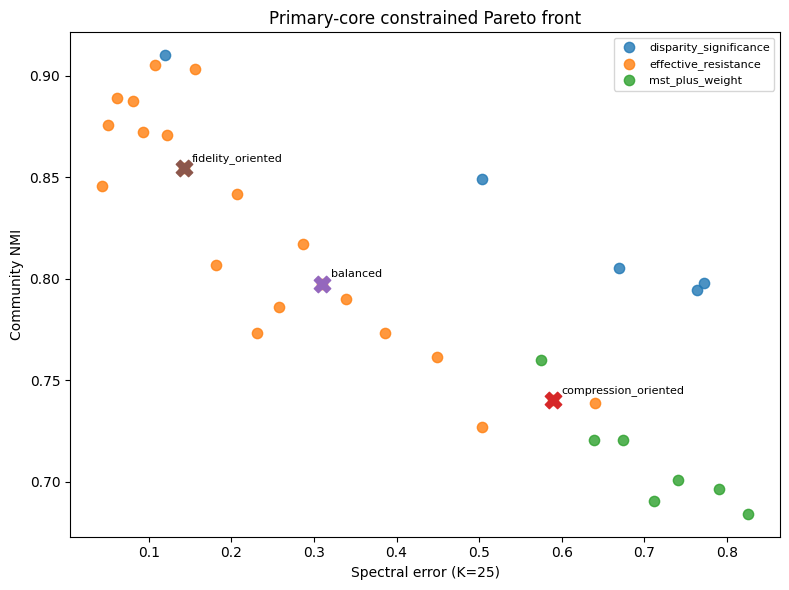

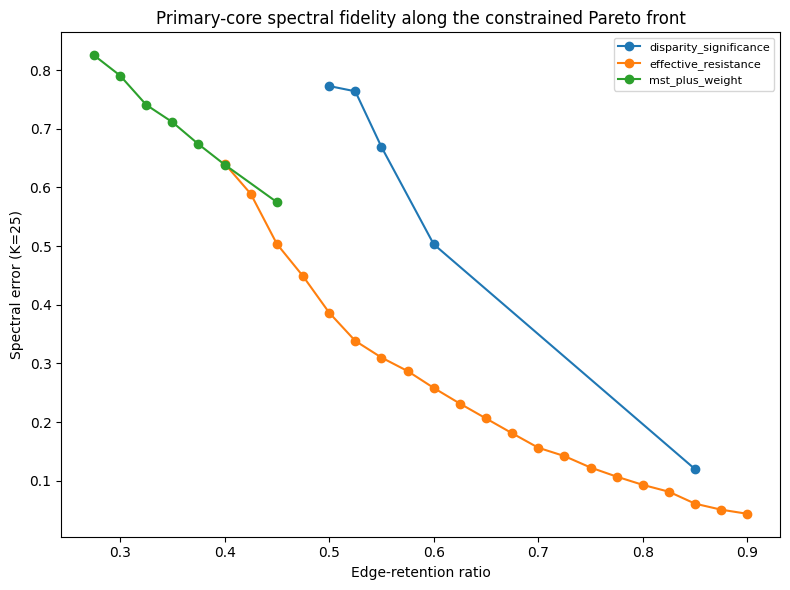

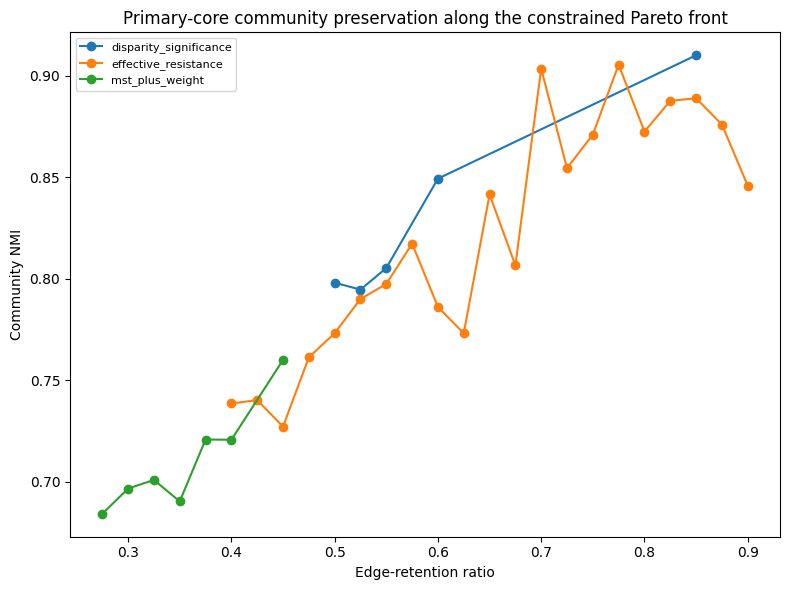

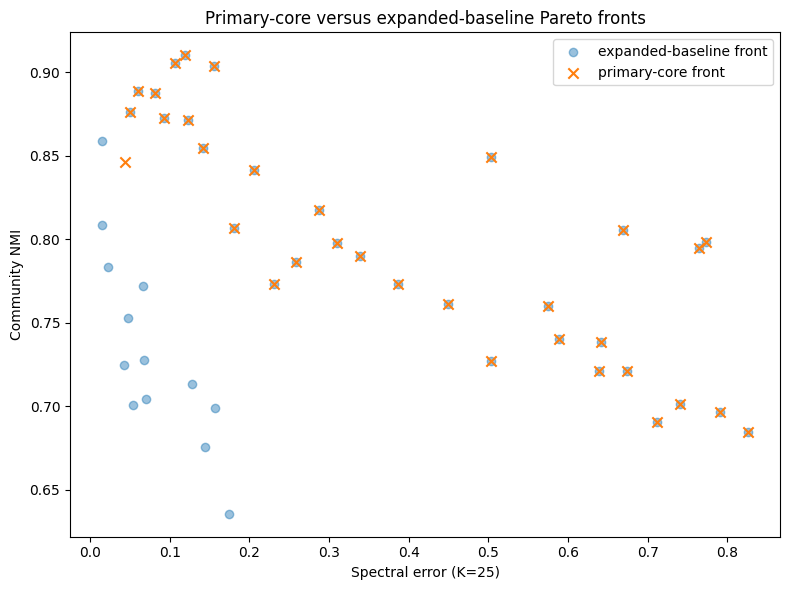

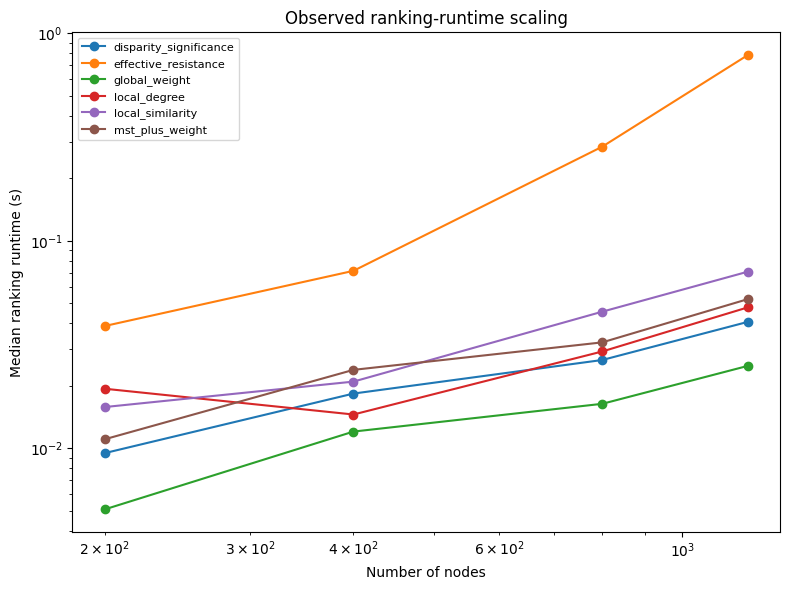


FINAL TABLE B — PRIMARY-CORE EPSILON-CONSTRAINT DECISIONS
             profile               method  retention  m_edges  spectral_error_K25  community_nmi_to_baseline_medoid  gcc_fraction  strength_spearman  detector_pareto_fraction  perturbation_pareto_self_rate  external_networks_with_pareto_point  ppgci_ranking_runtime_seconds
compression_oriented effective_resistance      0.425      680            0.589048                          0.740308      0.997525           0.946946                       1.0                           0.88                                  4.0                       0.509828
            balanced effective_resistance      0.550      880            0.309993                          0.797479      1.000000           0.981413                       1.0                           1.00                                  4.0                       0.509828
   fidelity_oriented effective_resistance      0.725     1160            0.141984                          0.854492    

In [ ]:

# Parte_14_Final_Figures_Tables_and_Reproducibility_Package.py
#
# Journal of Complex Networks — clean-room laboratory
# Part 14: Final figures, tables, and reproducibility package — REVISION 2 (inline figure display)
#
# PURPOSE
# -------
# Freeze the final manuscript-facing outputs after Parts 0–13.
#
# This script DOES NOT recompute expensive analyses. It reads validated outputs,
# assembles final publication tables/figures, and writes a reproducibility index.
#
# PRIMARY DECISION SCOPE
# ----------------------
# primary_core = original four deterministic methods:
#   global_weight
#   mst_plus_weight
#   effective_resistance
#   disparity_significance
#
# expanded_baseline = sensitivity layer including:
#   local_degree
#   local_similarity
#
# FINAL PREFERENCE MECHANISM
# --------------------------
# epsilon-constraint only. No weighted scalarization.
#
# OUTPUT
# ------
# .../14_final_manuscript_package/

from pathlib import Path
import json
import shutil
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ======================================================================================
# 1. PATHS
# ======================================================================================

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

RUN_ROOT = Path(
    "/content/drive/MyDrive/tese_doutoral/runs/"
    "jcn_pareto_sparsification_20261002"
)

OUTDIR = RUN_ROOT / "14_final_manuscript_package"
TABLEDIR = OUTDIR / "tables"
FIGDIR = OUTDIR / "figures"
ARTDIR = OUTDIR / "artifacts"
SUPPDIR = OUTDIR / "supplementary"
LOGDIR = OUTDIR / "logs"

for p in [OUTDIR, TABLEDIR, FIGDIR, ARTDIR, SUPPDIR, LOGDIR]:
    p.mkdir(parents=True, exist_ok=True)

# ======================================================================================
# 2. REQUIRED INPUTS
# ======================================================================================

P3 = RUN_ROOT / "03_primary_constrained_pareto" / "tables" / "Table_03_01_all_candidate_objectives.csv"
P5 = RUN_ROOT / "05_spectral_metric_robustness" / "tables"
P6 = RUN_ROOT / "06_community_detection_robustness" / "tables"
P7 = RUN_ROOT / "07_expanded_stochastic_baselines" / "tables"
P8 = RUN_ROOT / "08_perturbation_robustness" / "tables"
P9 = RUN_ROOT / "09_synthetic_ground_truth" / "tables"
P10 = RUN_ROOT / "10_multi_network_empirical_validation" / "tables"
P11 = RUN_ROOT / "11_statistical_synthesis_and_robustness_integration" / "tables"
P12 = RUN_ROOT / "12_computational_cost_and_scalability" / "tables"
P13 = RUN_ROOT / "13_final_pareto_decision" / "tables"

required_files = [
    P3,
    P11 / "Table_11_09_integrated_evidence_matrix_no_score.csv",
    P12 / "Table_12_06_empirical_scaling_slopes.csv",
    P13 / "Table_13_01a_primary_core_pareto_front.csv",
    P13 / "Table_13_01b_expanded_baseline_pareto_front.csv",
    P13 / "Table_13_02_epsilon_thresholds_by_scope.csv",
    P13 / "Table_13_03_epsilon_constraint_selections.csv",
    P13 / "Table_13_05_core_vs_expanded_scope_summary.csv",
]

for p in required_files:
    if not p.exists():
        raise FileNotFoundError(f"Missing required validated artifact: {p}")

# ======================================================================================
# 3. LOAD
# ======================================================================================

p3 = pd.read_csv(P3)
integrated = pd.read_csv(P11 / "Table_11_09_integrated_evidence_matrix_no_score.csv")
scaling = pd.read_csv(P12 / "Table_12_06_empirical_scaling_slopes.csv")

core_front = pd.read_csv(P13 / "Table_13_01a_primary_core_pareto_front.csv")
expanded_front = pd.read_csv(P13 / "Table_13_01b_expanded_baseline_pareto_front.csv")
eps = pd.read_csv(P13 / "Table_13_02_epsilon_thresholds_by_scope.csv")
sel = pd.read_csv(P13 / "Table_13_03_epsilon_constraint_selections.csv")
scope = pd.read_csv(P13 / "Table_13_05_core_vs_expanded_scope_summary.csv")

# Optional validated inputs
def read_optional(folder, name):
    p = folder / name
    return pd.read_csv(p) if p.exists() else None

p7_summary = read_optional(P7, "Table_07_05_stochastic_budget_summary.csv")
p8_method = read_optional(P8, "Table_08_07_method_perturbation_summary.csv")
p9_boot = read_optional(P9, "Table_09_03_synthetic_bootstrap_summary.csv")
p10_coverage = read_optional(P10, "Table_10_08_pareto_network_coverage.csv")
p10_earliest = read_optional(P10, "Table_10_05_earliest_feasible_retention.csv")
p12_summary = read_optional(P12, "Table_12_05_controlled_scaling_summary.csv")

# ======================================================================================
# 4. FINAL TABLE A — PRIMARY CORE PARETO FRONT
# ======================================================================================

table_primary = core_front[
    [
        "method",
        "retention",
        "m_edges",
        "spectral_error_K25",
        "community_nmi_to_baseline_medoid",
        "gcc_fraction",
        "strength_spearman",
    ]
].copy()

table_primary = table_primary.rename(
    columns={
        "retention": "edge_retention_ratio",
        "spectral_error_K25": "spectral_error_K25",
        "community_nmi_to_baseline_medoid": "community_NMI",
        "gcc_fraction": "GCC_fraction",
        "strength_spearman": "strength_Spearman",
    }
)

table_primary.to_csv(
    TABLEDIR / "Final_Table_A_Primary_Core_Pareto_Front.csv",
    index=False
)

# ======================================================================================
# 5. FINAL TABLE B — EPSILON-CONSTRAINT DECISIONS
# ======================================================================================

primary_sel = sel[sel["analysis_scope"] == "primary_core"].copy()
expanded_sel = sel[sel["analysis_scope"] == "expanded_baseline"].copy()

final_decision = primary_sel[
    [
        "profile",
        "method",
        "retention",
        "m_edges",
        "spectral_error_K25",
        "community_nmi_to_baseline_medoid",
        "gcc_fraction",
        "strength_spearman",
        "detector_pareto_fraction",
        "perturbation_pareto_self_rate",
        "external_networks_with_pareto_point",
        "ppgci_ranking_runtime_seconds",
    ]
].copy()

final_decision.to_csv(
    TABLEDIR / "Final_Table_B_Primary_Core_Epsilon_Decisions.csv",
    index=False
)

expanded_sel.to_csv(
    SUPPDIR / "Supplementary_Table_S1_Expanded_Baseline_Epsilon_Decisions.csv",
    index=False
)

# ======================================================================================
# 6. FINAL TABLE C — ROBUSTNESS SYNTHESIS
# ======================================================================================

robust_cols = [
    "method",
    "n_primary_pareto",
    "max_pareto_detector_fraction",
    "max_self_consistent_pareto_rate",
    "mean_self_feasibility_rate",
    "n_external_networks_with_feasible_candidate",
    "n_external_networks_with_pareto_point",
    "has_primary_pareto_point",
    "has_candidate_pareto_all_3_detectors",
    "has_candidate_pareto_all_50_perturbations",
    "has_pareto_point_all_external_networks",
    "has_feasible_candidate_all_external_networks",
]

available = [c for c in robust_cols if c in integrated.columns]
robust = integrated[available].copy()

robust.to_csv(
    TABLEDIR / "Final_Table_C_Robustness_Synthesis_No_Score.csv",
    index=False
)

# ======================================================================================
# 7. FINAL TABLE D — COMPUTATIONAL COST
# ======================================================================================

cost = scaling[
    [
        "method",
        "empirical_loglog_slope_runtime_vs_N",
        "loglog_fit_R2",
        "interpretation",
    ]
].copy()

if p12_summary is not None:
    nmax = int(p12_summary["n_nodes"].max())
    at_max = p12_summary[p12_summary["n_nodes"] == nmax][
        ["method", "runtime_median_seconds"]
    ].rename(
        columns={"runtime_median_seconds": f"median_runtime_seconds_N{nmax}"}
    )

    cost = cost.merge(
        at_max,
        on="method",
        how="left"
    )

cost.to_csv(
    TABLEDIR / "Final_Table_D_Computational_Cost.csv",
    index=False
)

# ======================================================================================
# 8. FINAL FIGURE 1 — PRIMARY CORE PARETO FRONT
# ======================================================================================

fig, ax = plt.subplots(figsize=(8,6))

for method, g in core_front.groupby("method"):
    ax.scatter(
        g["spectral_error_K25"],
        g["community_nmi_to_baseline_medoid"],
        s=55,
        label=method,
        alpha=.8
    )

for _, row in primary_sel.iterrows():
    ax.scatter(
        row["spectral_error_K25"],
        row["community_nmi_to_baseline_medoid"],
        marker="X",
        s=140
    )

    ax.annotate(
        row["profile"],
        (
            row["spectral_error_K25"],
            row["community_nmi_to_baseline_medoid"]
        ),
        xytext=(6,5),
        textcoords="offset points",
        fontsize=8
    )

ax.set_xlabel("Spectral error (K=25)")
ax.set_ylabel("Community NMI")
ax.set_title("Primary-core constrained Pareto front")
ax.legend(fontsize=8)
fig.tight_layout()

fig.savefig(
    FIGDIR / "Final_Figure_1_Primary_Core_Pareto.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()
plt.close(fig)

# ======================================================================================
# 9. FINAL FIGURE 2 — RETENTION VS SPECTRAL ERROR
# ======================================================================================

fig, ax = plt.subplots(figsize=(8,6))

for method, g in core_front.groupby("method"):
    g = g.sort_values("retention")

    ax.plot(
        g["retention"],
        g["spectral_error_K25"],
        marker="o",
        label=method
    )

ax.set_xlabel("Edge-retention ratio")
ax.set_ylabel("Spectral error (K=25)")
ax.set_title("Primary-core spectral fidelity along the constrained Pareto front")
ax.legend(fontsize=8)
fig.tight_layout()

fig.savefig(
    FIGDIR / "Final_Figure_2_Retention_vs_Spectral_Error.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()
plt.close(fig)

# ======================================================================================
# 10. FINAL FIGURE 3 — RETENTION VS COMMUNITY NMI
# ======================================================================================

fig, ax = plt.subplots(figsize=(8,6))

for method, g in core_front.groupby("method"):
    g = g.sort_values("retention")

    ax.plot(
        g["retention"],
        g["community_nmi_to_baseline_medoid"],
        marker="o",
        label=method
    )

ax.set_xlabel("Edge-retention ratio")
ax.set_ylabel("Community NMI")
ax.set_title("Primary-core community preservation along the constrained Pareto front")
ax.legend(fontsize=8)
fig.tight_layout()

fig.savefig(
    FIGDIR / "Final_Figure_3_Retention_vs_Community_NMI.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()
plt.close(fig)

# ======================================================================================
# 11. FINAL FIGURE 4 — CORE VS EXPANDED FRONT
# ======================================================================================

fig, ax = plt.subplots(figsize=(8,6))

ax.scatter(
    expanded_front["spectral_error_K25"],
    expanded_front["community_nmi_to_baseline_medoid"],
    marker="o",
    alpha=.45,
    label="expanded-baseline front"
)

ax.scatter(
    core_front["spectral_error_K25"],
    core_front["community_nmi_to_baseline_medoid"],
    marker="x",
    s=55,
    label="primary-core front"
)

ax.set_xlabel("Spectral error (K=25)")
ax.set_ylabel("Community NMI")
ax.set_title("Primary-core versus expanded-baseline Pareto fronts")
ax.legend()
fig.tight_layout()

fig.savefig(
    FIGDIR / "Final_Figure_4_Core_vs_Expanded_Pareto.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()
plt.close(fig)

# ======================================================================================
# 12. FINAL FIGURE 5 — COMPUTATIONAL SCALING
# ======================================================================================

if p12_summary is not None:
    fig, ax = plt.subplots(figsize=(8,6))

    for method, g in p12_summary.groupby("method"):
        g = g.sort_values("n_nodes")
        ax.plot(
            g["n_nodes"],
            g["runtime_median_seconds"],
            marker="o",
            label=method
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Number of nodes")
    ax.set_ylabel("Median ranking runtime (s)")
    ax.set_title("Observed ranking-runtime scaling")
    ax.legend(fontsize=8)
    fig.tight_layout()

    fig.savefig(
        FIGDIR / "Final_Figure_5_Computational_Scaling.png",
        dpi=600,
        bbox_inches="tight"
    )
    plt.show()
    plt.close(fig)

# ======================================================================================
# 13. MANUSCRIPT RESULT SNAPSHOT
# ======================================================================================

snapshot = {
    "primary_feasible_candidates": int(
        (
            (p3["gcc_fraction"] >= .95)
            & (p3["strength_spearman"] >= .90)
        ).sum()
    ),
    "primary_core_pareto_points": int(len(core_front)),
    "expanded_baseline_pareto_points": int(len(expanded_front)),
    "core_vs_expanded_front_jaccard": float(
        scope.iloc[0]["front_jaccard_core_vs_expanded"]
    ),
    "primary_core_selections": {
        row["profile"]: {
            "method": row["method"],
            "retention": float(row["retention"]),
            "m_edges": int(row["m_edges"]),
            "spectral_error_K25": float(row["spectral_error_K25"]),
            "community_nmi": float(
                row["community_nmi_to_baseline_medoid"]
            ),
            "gcc_fraction": float(row["gcc_fraction"]),
            "strength_spearman": float(row["strength_spearman"]),
        }
        for _,row in primary_sel.iterrows()
    },
    "expanded_baseline_selections": {
        row["profile"]: {
            "method": row["method"],
            "retention": float(row["retention"]),
            "m_edges": int(row["m_edges"]),
            "spectral_error_K25": float(row["spectral_error_K25"]),
            "community_nmi": float(
                row["community_nmi_to_baseline_medoid"]
            ),
        }
        for _,row in expanded_sel.iterrows()
    },
}

snapshot_path = ARTDIR / "Final_Manuscript_Result_Snapshot.json"
snapshot_path.write_text(
    json.dumps(snapshot, indent=2, ensure_ascii=False),
    encoding="utf-8"
)

# ======================================================================================
# 14. REPRODUCIBILITY INDEX
# ======================================================================================

index_rows = []

for part_num in range(0,15):
    matches = sorted(
        RUN_ROOT.glob(f"{part_num:02d}_*")
    )

    for p in matches:
        index_rows.append({
            "part": part_num,
            "path": str(p),
            "exists": p.exists(),
            "tables_dir_exists": (p/"tables").exists(),
            "figures_dir_exists": (p/"figures").exists(),
            "artifacts_dir_exists": (p/"artifacts").exists(),
        })

index_df = pd.DataFrame(index_rows)

index_df.to_csv(
    ARTDIR / "Reproducibility_Index.csv",
    index=False
)

# ======================================================================================
# 15. COPY SELECT MANIFESTS / AUDITS
# ======================================================================================

manifest_candidates = [
    RUN_ROOT / "00_canonical_baseline" / "artifacts" / "Part_0D_canonical_baseline_manifest.json",
    RUN_ROOT / "03_primary_constrained_pareto" / "artifacts" / "Part_3_primary_pareto_manifest.json",
    RUN_ROOT / "07_expanded_stochastic_baselines" / "artifacts" / "Part_7_stochastic_baselines_manifest.json",
    RUN_ROOT / "08_perturbation_robustness" / "artifacts" / "Part_8_perturbation_robustness_manifest.json",
    RUN_ROOT / "09_synthetic_ground_truth" / "artifacts" / "Part_9_synthetic_ground_truth_manifest.json",
    RUN_ROOT / "10_multi_network_empirical_validation" / "artifacts" / "Part_10_multi_network_empirical_validation_manifest.json",
    RUN_ROOT / "11_statistical_synthesis_and_robustness_integration" / "artifacts" / "Part_11_statistical_synthesis_manifest.json",
    RUN_ROOT / "12_computational_cost_and_scalability" / "artifacts" / "Part_12_computational_cost_manifest.json",
    RUN_ROOT / "13_final_pareto_decision" / "artifacts" / "Part_13_final_pareto_decision_manifest.json",
]

copied_manifests = []

for p in manifest_candidates:
    if p.exists():
        target = ARTDIR / p.name
        shutil.copy2(p,target)
        copied_manifests.append(str(target))

# ======================================================================================
# 16. FINAL PACKAGE MANIFEST
# ======================================================================================

manifest = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "part": "14_final_manuscript_package",
    "primary_decision_scope": "primary_core",
    "expanded_baseline_role": "secondary sensitivity",
    "preference_mechanism": "epsilon_constraint",
    "scalarization_used": False,
    "final_tables": [
        str(p) for p in sorted(TABLEDIR.glob("*.csv"))
    ],
    "final_figures": [
        str(p) for p in sorted(FIGDIR.glob("*.png"))
    ],
    "supplementary_tables": [
        str(p) for p in sorted(SUPPDIR.glob("*.csv"))
    ],
    "copied_manifests": copied_manifests,
    "result_snapshot": str(snapshot_path),
    "reproducibility_index": str(
        ARTDIR / "Reproducibility_Index.csv"
    ),
}

manifest_path = ARTDIR / "Part_14_final_package_manifest.json"
manifest_path.write_text(
    json.dumps(manifest, indent=2, ensure_ascii=False),
    encoding="utf-8"
)

# ======================================================================================
# 17. PRINT FINAL FREEZE SUMMARY
# ======================================================================================

pd.set_option("display.max_columns",100)
pd.set_option("display.width",360)

print("\n"+"="*125)
print("FINAL TABLE B — PRIMARY-CORE EPSILON-CONSTRAINT DECISIONS")
print("="*125)
print(final_decision.to_string(index=False))

print("\n"+"="*125)
print("FINAL TABLE C — ROBUSTNESS SYNTHESIS (NO SCORE)")
print("="*125)
print(robust.to_string(index=False))

print("\n"+"="*125)
print("FINAL TABLE D — COMPUTATIONAL COST")
print("="*125)
print(cost.to_string(index=False))

print("\n"+"="*125)
print("FINAL MANUSCRIPT RESULT SNAPSHOT")
print("="*125)
print(json.dumps(snapshot, indent=2, ensure_ascii=False))

print("\n"+"="*125)
print("PART 14 AUDIT")
print("="*125)
print(f"primary decision scope:          primary_core")
print(f"expanded baseline role:          secondary sensitivity")
print(f"preference mechanism:            epsilon_constraint")
print(f"scalarization used:              False")
print(f"primary-core Pareto size:        {len(core_front)}")
print(f"expanded Pareto size:            {len(expanded_front)}")
print(f"final tables:                    {len(list(TABLEDIR.glob('*.csv')))}")
print(f"final figures:                   {len(list(FIGDIR.glob('*.png')))}")
print(f"supplementary tables:            {len(list(SUPPDIR.glob('*.csv')))}")
print(f"package manifest:                {manifest_path}")
print("STATUS: PART_14_COMPLETE")

print("\nSEND BACK:")
print("1) FINAL TABLE B")
print("2) FINAL TABLE C")
print("3) FINAL TABLE D")
print("4) FINAL MANUSCRIPT RESULT SNAPSHOT")
print("5) PART 14 AUDIT")


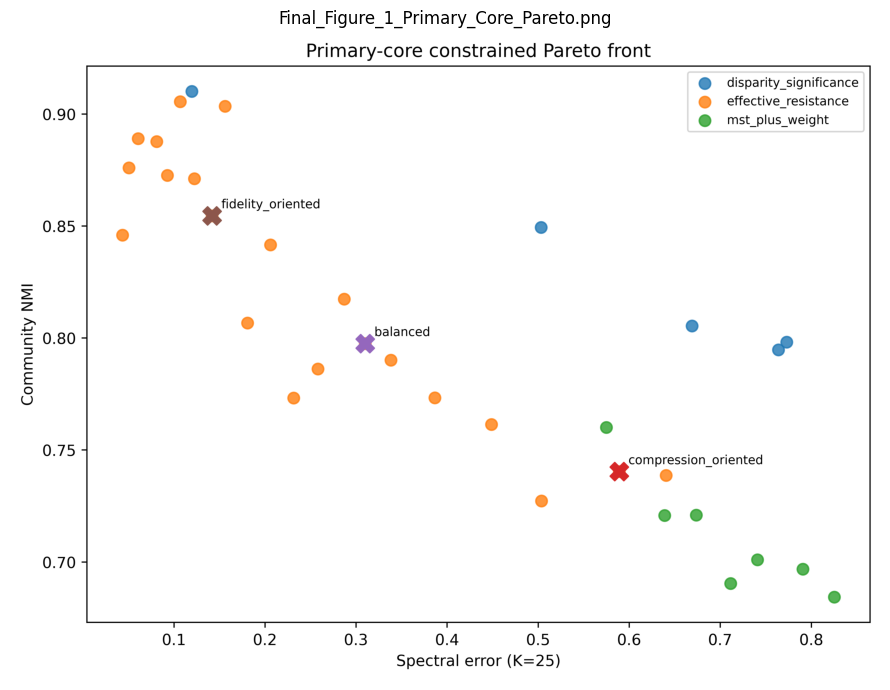

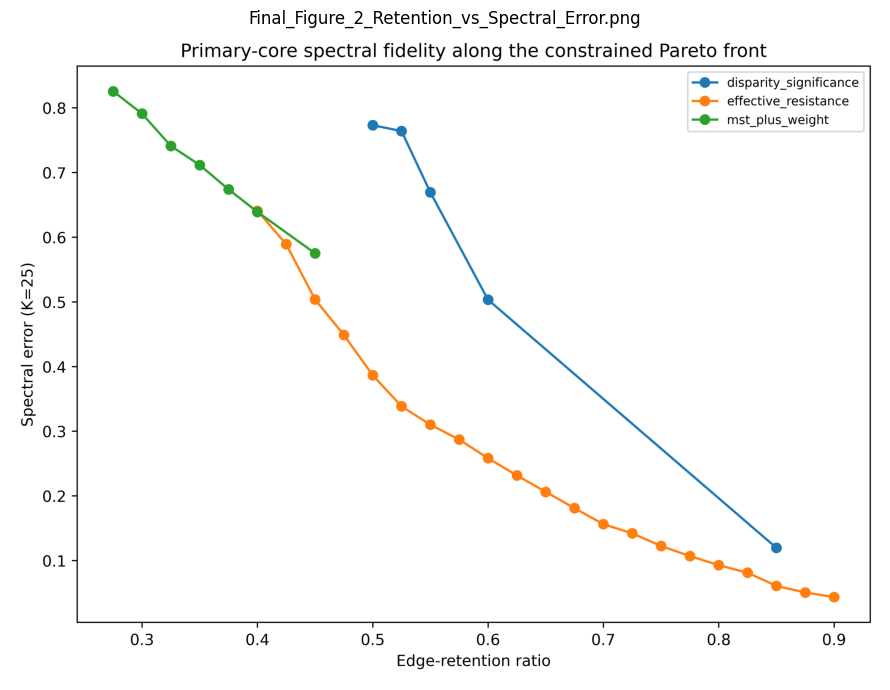

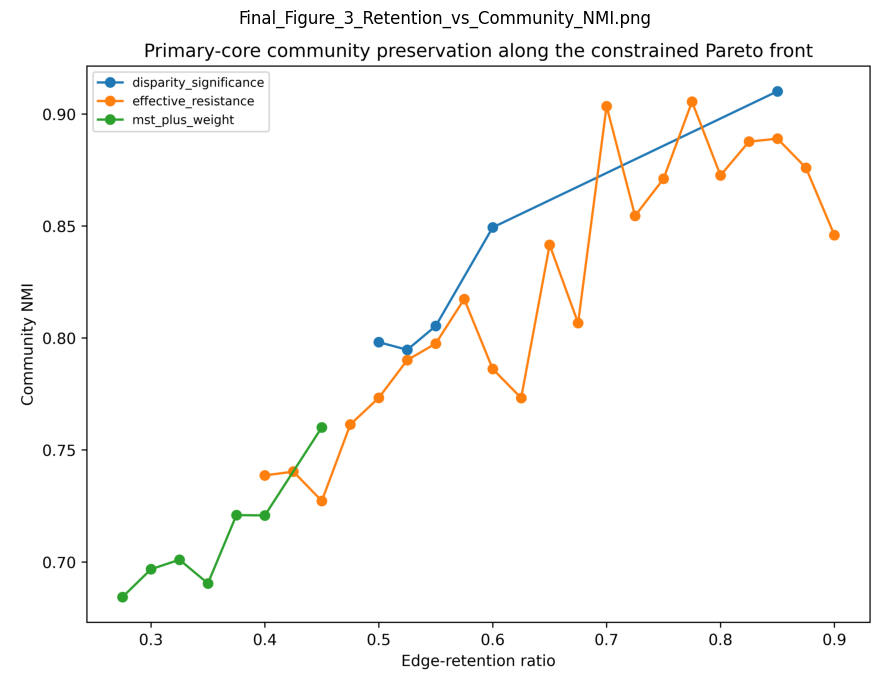

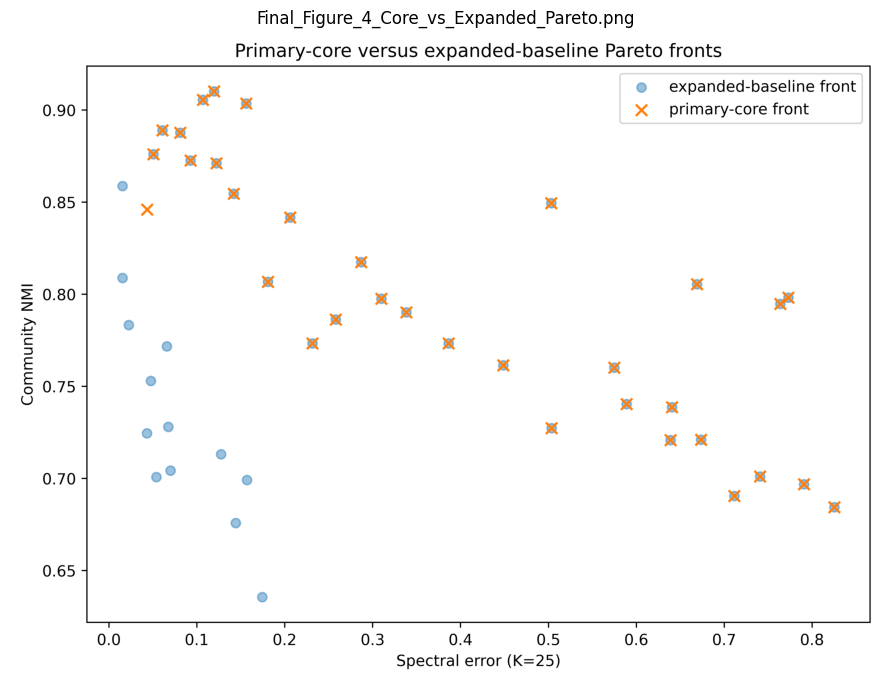

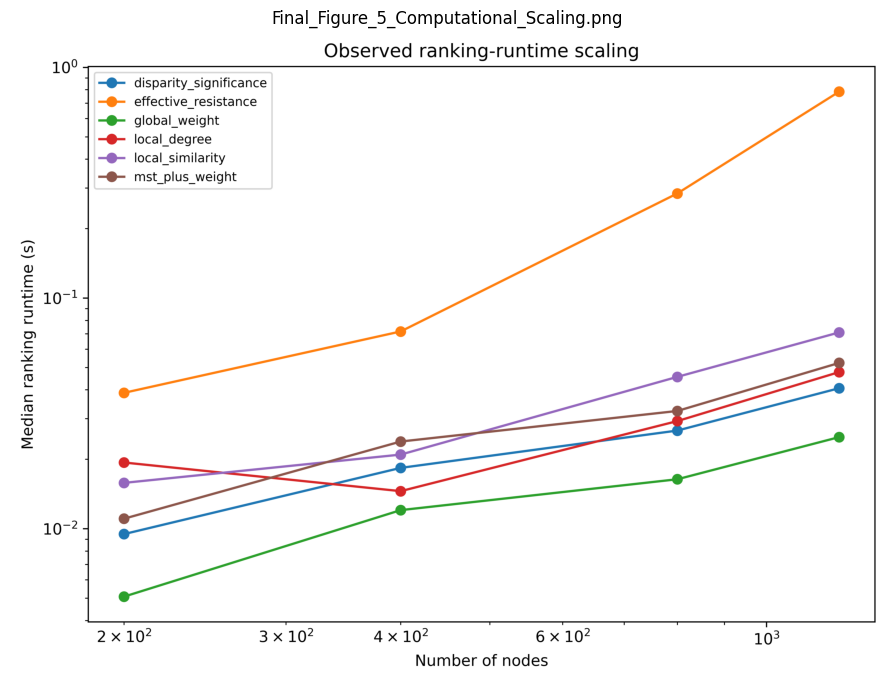

In [ ]:

from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

RUN_ROOT = Path(
    "/content/drive/MyDrive/tese_doutoral/runs/"
    "jcn_pareto_sparsification_20261002"
)
FIGDIR = RUN_ROOT / "14_final_manuscript_package" / "figures"

figures = [
    "Final_Figure_1_Primary_Core_Pareto.png",
    "Final_Figure_2_Retention_vs_Spectral_Error.png",
    "Final_Figure_3_Retention_vs_Community_NMI.png",
    "Final_Figure_4_Core_vs_Expanded_Pareto.png",
    "Final_Figure_5_Computational_Scaling.png",
]

for name in figures:
    path = FIGDIR / name
    if not path.exists():
        print(f"[missing] {path}")
        continue

    img = mpimg.imread(path)

    plt.figure(figsize=(10,7))
    plt.imshow(img)
    plt.axis("off")
    plt.title(name)
    plt.tight_layout()
    plt.show()
